In [1]:
import pandas as pd
pd.set_option("display.max_columns", None)   # 显示所有列
pd.set_option("display.max_rows", 200)       # 可选：显示更多行
pd.set_option("display.width", None)         # 自动适配宽度
pd.set_option("display.max_colwidth", None)  # 不截断单元格内容

In [104]:
####提取想要的分类信息，并提取序列信息####
import pandas as pd
import numpy as np

# 1) 读取 OpenProt 表
openprot_file = "/disk3/hejp/00_thesis/4_predict_translation/dataset/openprot/ensembl/human-openprot-2_2-refprots+altprots+isoforms-GRCh38.106-uniprot2022_06_01.tsv"
df = pd.read_csv(openprot_file, sep="\t", low_memory=False)
print(df.columns)
display(df.head(n=5))

Index(['protein accession', 'protein accession (others)', 'protein type',
       'protein length (a.a.)', 'molecular weight (kDa)', 'isoelectric point',
       'frame', 'gene symbol', 'chr', 'start genomic coordinates',
       'stop genomic coordinates', 'strand', 'transcript accession', 'type',
       'localization', 'start transcript coordinates',
       'stop transcript coordinates', 'MS score', 'TE Translation Event score',
       'Kozak motif', 'High-efficiency TIS motif', 'Domains'],
      dtype='object')


,protein accession,protein accession (others),protein type,protein length (a.a.),molecular weight (kDa),isoelectric point,frame,gene symbol,chr,start genomic coordinates,...,transcript accession,type,localization,start transcript coordinates,stop transcript coordinates,MS score,TE Translation Event score,Kozak motif,High-efficiency TIS motif,Domains
0,Q8NH21,NaN,NaN,305,34.33,8.32,NaN,OR4F5,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN,32
1,IP_057216,"IP_057216,IP_057216",AltProt,46,5.44,8.51,3.0,OR4F5,1,69446.0,...,NM_001005484.2,mRNA,CDS,480.0,621.0,0,0,-,-,0
2,IP_057216,"IP_057216,IP_057216",AltProt,46,5.44,8.51,3.0,OR4F5,1,69446.0,...,ENST00000641515.2,mRNA,CDS,480.0,621.0,0,0,-,-,0
3,NP_001005221.2,"NP_001005221.2,XP_024305760.1,XP_016857899.1,X...",RefProt,312,35.07,8.92,1.0,OR4F29,1,450739.0,...,NM_001005221.2,mRNA,-,1.0,940.0,0,0,-,-,32
4,XP_024305760.1,"NP_001005221.2,XP_024305760.1,XP_016857899.1,X...",RefProt,312,35.07,8.92,3.0,OR4F16,1,685715.0,...,XM_024449992.2,mRNA,-,2496.0,3435.0,0,0,-,-,32


In [105]:
print(df['localization'].value_counts())

localization
3'UTR       894473
-           801265
CDS         683925
5'UTR        86929
multiple      5742
Name: count, dtype: int64


In [22]:
####提取想要的分类信息，并提取序列信息####
import pandas as pd
import numpy as np

# 1) 读取 OpenProt 表
openprot_file = "/disk3/hejp/00_thesis/4_predict_translation/dataset/openprot/ensembl/human-openprot-2_2-refprots+altprots+isoforms-GRCh38.106-uniprot2022_06_01.tsv"
df = pd.read_csv(openprot_file, sep="\t", low_memory=False)
print(df.shape)
# 2) 基础清洗
df["protein type"] = df["protein type"].fillna("Unknown")
df["MS score"] = pd.to_numeric(df["MS score"], errors="coerce").fillna(0)
print(df.shape)
df["TE Translation Event score"] = pd.to_numeric(df["TE Translation Event score"], errors="coerce").fillna(0)

# 3) 只保留 AltProt
alt = df[df["protein type"] == "AltProt"].copy()

# 4) 定义你关心的 4 类
def assign_group(row):
    ms = row["MS score"]
    te = row["TE Translation Event score"]
    if ms == 0 and te >= 2:
        return "MS-|Ribo++"
    elif ms == 1 and te >= 2:
        return "MS+|Ribo++"
    elif ms >= 2 and te >= 2:
        return "MS++|Ribo++"
    elif ms >= 2 and te ==1:
        return "MS++|Ribo+"
    elif ms == 1 and te ==1:
        return "MS+|Ribo+"
    elif ms == 0 and te ==1:
        return "MS-|Ribo+"
    elif ms == 0 and te == 0:
        return "MS-|Ribo-"
    elif ms == 1 and te == 0:
        return "MS+|Ribo-"
    else:
        return np.nan

alt["group"] = alt.apply(assign_group, axis=1)

# 5) 只保留这 4 类
alt4 = alt[alt["group"].notna()].copy()

# 6) 看结果
print("原始表大小:", df.shape)
print("AltProt 数量:", alt.shape)
print("4 类 AltProt 数量:", alt4.shape)
print("\n各组数量：")
print(alt4["group"].value_counts(dropna=False))

# 7) 看后面提序列最关键的列是否存在
need_cols = [
    "protein accession (others)",
    "gene symbol",
    "transcript accession",
    "start transcript coordinates",
    "stop transcript coordinates",
    "protein length (a.a.)",
    "MS score",
    "TE Translation Event score",
    "group"
]

print("\n关键列是否都在：")
for c in need_cols:
    print(c, "->", c in alt4.columns)

# 8) 展示前几行
display(alt4[need_cols].head())

(2572995, 22)
(2572995, 22)
原始表大小: (2572995, 22)
AltProt 数量: (2140853, 23)
4 类 AltProt 数量: (1619198, 23)

各组数量：
group
MS-|Ribo-      904864
MS+|Ribo-      634568
MS-|Ribo+       16898
MS-|Ribo++      14521
MS++|Ribo+      12984
MS+|Ribo+       12355
MS++|Ribo++     11654
MS+|Ribo++      11354
Name: count, dtype: int64

关键列是否都在：
protein accession (others) -> True
gene symbol -> True
transcript accession -> True
start transcript coordinates -> True
stop transcript coordinates -> True
protein length (a.a.) -> True
MS score -> True
TE Translation Event score -> True
group -> True


,protein accession (others),gene symbol,transcript accession,start transcript coordinates,stop transcript coordinates,protein length (a.a.),MS score,TE Translation Event score,group
1,"IP_057216,IP_057216",OR4F5,NM_001005484.2,480.0,621.0,46,0,0,MS-|Ribo-
2,"IP_057216,IP_057216",OR4F5,ENST00000641515.2,480.0,621.0,46,0,0,MS-|Ribo-
31,"IP_057219,IP_057219,IP_057219,IP_057219,IP_057...",OR4F29,NM_001005221.2,60.0,156.0,31,0,0,MS-|Ribo-
32,"IP_057219,IP_057219,IP_057219,IP_057219,IP_057...",OR4F16,XM_024449992.2,2555.0,2651.0,31,0,0,MS-|Ribo-
33,"IP_057219,IP_057219,IP_057219,IP_057219,IP_057...",OR4F16,XM_017002410.2,2567.0,2663.0,31,0,0,MS-|Ribo-


In [23]:
#读取官方的2 unique peptide的微蛋白#
sample_info_file = "/disk3/hejp/00_thesis/4_predict_translation/dataset/openprot/human-openprot-2_2-refprots+altprots+isoforms-min_2_pep-uniprot2022_06_01.tsv"

#meta = pd.read_excel(sample_info_file)
openprot_hsapiens_all_2pep = pd.read_csv(sample_info_file,sep='\t')
print(openprot_hsapiens_all_2pep.shape)
display(openprot_hsapiens_all_2pep.head())
df_2pep=openprot_hsapiens_all_2pep.copy()
# 3) 只保留 AltProt
alt_2pep = df_2pep[df_2pep["protein type"] == "AltProt"].copy()

# 4) 定义你关心的 4 类
def assign_group(row):
    ms = row["MS score"]
    te = row["TE Translation Event score"]
    
    if ms >= 2 and te == 0:
        return "MS++|Ribo-"
    elif ms >= 2 and te == 1:
        return "MS++|Ribo+"
    elif ms >= 2 and te >= 2:
        return "MS++|Ribo++"
    elif ms == 0 and te == 0:
        return "MS-|Ribo-"
    elif ms == 1 and te == 0:
        return "MS+|Ribo-"
    else:
        return np.nan

alt_2pep["group"] = alt_2pep.apply(assign_group, axis=1)

# 5) 只保留这 4 类
alt4_2pep = alt_2pep[alt_2pep["group"].notna()].copy()

# 6) 看结果
print("原始表大小:", df_2pep.shape)
print("AltProt 数量:", alt_2pep.shape)
print("4 类 AltProt 数量:", alt4_2pep.shape)
print("\n各组数量：")
print(alt4_2pep["group"].value_counts(dropna=False))

# 7) 看后面提序列最关键的列是否存在
need_cols = [
    "protein accession (others)",
    "gene symbol",
    "transcript accession",
    "start transcript coordinates",
    "stop transcript coordinates",
    "protein length (a.a.)",
    "MS score",
    "TE Translation Event score",
    "group"
]

print("\n关键列是否都在：")
for c in need_cols:
    print(c, "->", c in alt4_2pep.columns)

# 8) 展示前几行
display(alt4_2pep[need_cols].head())


/tmp/ipykernel_7780/1617863612.py:5: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  openprot_hsapiens_all_2pep = pd.read_csv(sample_info_file,sep='\t')


(952313, 22)


,protein accession,protein accession (others),protein type,protein length (a.a.),molecular weight (kDa),isoelectric point,frame,gene symbol,chr,start genomic coordinates,...,transcript accession,type,localization,start transcript coordinates,stop transcript coordinates,MS score,TE Translation Event score,Kozak motif,High-efficiency TIS motif,Domains
0,IP_057218,"IP_057218,IP_057218,IP_057218,IP_057218,IP_057...",AltProt,33,3.51,8.04,2.0,OR4F29,1.0,451329.0,...,NM_001005221.2,mRNA,CDS,248.0,350.0,2,0,-,-,0
1,IP_057218,"IP_057218,IP_057218,IP_057218,IP_057218,IP_057...",AltProt,33,3.51,8.04,1.0,OR4F16,1.0,686305.0,...,XM_024449992.2,mRNA,CDS,2743.0,2845.0,2,0,-,-,0
2,IP_057218,"IP_057218,IP_057218,IP_057218,IP_057218,IP_057...",AltProt,33,3.51,8.04,1.0,OR4F16,1.0,686305.0,...,XM_017002410.2,mRNA,CDS,2755.0,2857.0,2,0,-,-,0
3,IP_057218,"IP_057218,IP_057218,IP_057218,IP_057218,IP_057...",AltProt,33,3.51,8.04,3.0,OR4F16,1.0,686305.0,...,XM_017002408.2,mRNA,CDS,2973.0,3075.0,2,0,-,-,0
4,IP_057218,"IP_057218,IP_057218,IP_057218,IP_057218,IP_057...",AltProt,33,3.51,8.04,1.0,OR4F16,1.0,686305.0,...,XM_047431162.1,mRNA,CDS,2692.0,2794.0,2,0,-,-,0


原始表大小: (952313, 22)
AltProt 数量: (617172, 23)
4 类 AltProt 数量: (617172, 23)

各组数量：
group
MS++|Ribo-     591692
MS++|Ribo+      13611
MS++|Ribo++     11869
Name: count, dtype: int64

关键列是否都在：
protein accession (others) -> True
gene symbol -> True
transcript accession -> True
start transcript coordinates -> True
stop transcript coordinates -> True
protein length (a.a.) -> True
MS score -> True
TE Translation Event score -> True
group -> True


,protein accession (others),gene symbol,transcript accession,start transcript coordinates,stop transcript coordinates,protein length (a.a.),MS score,TE Translation Event score,group
0,"IP_057218,IP_057218,IP_057218,IP_057218,IP_057...",OR4F29,NM_001005221.2,248.0,350.0,33,2,0,MS++|Ribo-
1,"IP_057218,IP_057218,IP_057218,IP_057218,IP_057...",OR4F16,XM_024449992.2,2743.0,2845.0,33,2,0,MS++|Ribo-
2,"IP_057218,IP_057218,IP_057218,IP_057218,IP_057...",OR4F16,XM_017002410.2,2755.0,2857.0,33,2,0,MS++|Ribo-
3,"IP_057218,IP_057218,IP_057218,IP_057218,IP_057...",OR4F16,XM_017002408.2,2973.0,3075.0,33,2,0,MS++|Ribo-
4,"IP_057218,IP_057218,IP_057218,IP_057218,IP_057...",OR4F16,XM_047431162.1,2692.0,2794.0,33,2,0,MS++|Ribo-


In [24]:
#合并大表alt4和小标2pep的alt4_2pep#
alt4_combined=pd.concat([alt4,alt4_2pep])

###去重复###
# 1) 只保留 Ensembl transcript
alt4_ens = alt4_combined.copy()
alt4_ens["transcript accession"] = alt4_ens["transcript accession"].astype(str).str.strip()
alt4_ens = alt4_ens[alt4_ens["transcript accession"].str.startswith("ENST", na=False)].copy()

print("只保留 ENST 后行数:", alt4_ens.shape[0])
print("唯一 protein accession 数:", alt4_ens["protein accession"].nunique())
display(alt4_ens[["protein accession", "transcript accession"]].head(10))
alt4_ens["tx_base"] = alt4_ens["transcript accession"].str.split(".").str[0]

##读取cDNA的fasta文件，引入transcript长度，然后去重##
from Bio import SeqIO
import pandas as pd

#cdna_fasta = "/disk3/hejp/00_thesis/4_predict_translation/dataset/openprot/ensembl/Homo_sapiens.GRCh38.cdna.all.fa"
cdna_fasta = "/disk3/hejp/00_thesis/4_predict_translation/dataset/openprot/ensembl/Homo_sapiens.GRCh38.cdna.ncrna.merge.fa"#这个是合并了cdna和ncrna之后的fa文件


# 1) 读取 fasta
tx_seq_dict = {}
tx_len_dict = {}

for record in SeqIO.parse(cdna_fasta, "fasta"):
    tx_id = record.id.split("|")[0]   # 保留完整 ENSTxxxx.x
    seq = str(record.seq).upper().replace("U", "T")
    
    tx_seq_dict[tx_id] = seq
    tx_len_dict[tx_id] = len(seq)

print("fasta中 transcript 数:", len(tx_seq_dict))

# 2) 直接用完整 accession 匹配
alt4_ens["transcript_length"] = alt4_ens["transcript accession"].map(tx_len_dict)

# 3) 检查匹配情况
print("\ntranscript_length 缺失情况：")
print(alt4_ens["transcript_length"].isna().value_counts())

print("\n匹配成功比例：", alt4_ens["transcript_length"].notna().mean())

# 4) 看前几行
display(
    alt4_ens[[
        "protein accession",
        "transcript accession",
        "transcript_length"
    ]].head(10)
)

# 5) 看没匹配到的（理论上应该接近 0）
not_found = alt4_ens[alt4_ens["transcript_length"].isna()]
display(not_found[["protein accession", "transcript accession"]].head(10))

alt4_ens_found=alt4_ens[alt4_ens['transcript_length'].notna()]
display(alt4_ens_found.head(10))


只保留 ENST 后行数: 917656
唯一 protein accession 数: 425772


,protein accession,transcript accession
2,IP_057216,ENST00000641515.2
38,IP_057219,ENST00000559128.1
39,IP_057219,ENST00000332831.5
40,IP_057219,ENST00000426406.4
41,IP_057219,ENST00000456475.1
42,IP_057219,ENST00000402444.2
43,IP_057219,ENST00000651688.1
44,IP_057219,ENST00000424047.1
45,IP_057219,ENST00000589943.1
49,IP_057220,ENST00000616016.5


fasta中 transcript 数: 267165

transcript_length 缺失情况：
transcript_length
False    912577
True       5079
Name: count, dtype: int64

匹配成功比例： 0.9944652462360624


,protein accession,transcript accession,transcript_length
2,IP_057216,ENST00000641515.2,2618.0
38,IP_057219,ENST00000559128.1,938.0
39,IP_057219,ENST00000332831.5,939.0
40,IP_057219,ENST00000426406.4,939.0
41,IP_057219,ENST00000456475.1,995.0
42,IP_057219,ENST00000402444.2,931.0
43,IP_057219,ENST00000651688.1,938.0
44,IP_057219,ENST00000424047.1,938.0
45,IP_057219,ENST00000589943.1,937.0
49,IP_057220,ENST00000616016.5,3465.0


,protein accession,transcript accession
86335,IP_069211,ENST00000638358.1
86336,IP_069211,ENST00000628937.1
86338,IP_069213,ENST00000638358.1
86339,IP_069213,ENST00000628937.1
86342,IP_069214,ENST00000638358.1
86343,IP_069214,ENST00000628937.1
86345,IP_069215,ENST00000638358.1
86346,IP_069215,ENST00000628937.1
188321,IP_084539,ENST00000624376.1
188366,IP_084550,ENST00000624376.1


,protein accession,protein accession (others),protein type,protein length (a.a.),molecular weight (kDa),isoelectric point,frame,gene symbol,chr,start genomic coordinates,...,start transcript coordinates,stop transcript coordinates,MS score,TE Translation Event score,Kozak motif,High-efficiency TIS motif,Domains,group,tx_base,transcript_length
2,IP_057216,"IP_057216,IP_057216",AltProt,46,5.44,8.51,3.0,OR4F5,1,69446.0,...,480.0,621.0,0,0,-,-,0,MS-|Ribo-,ENST00000641515,2618.0
38,IP_057219,"IP_057219,IP_057219,IP_057219,IP_057219,IP_057...",AltProt,31,3.49,7.45,3.0,OR4F28P,15,101876022.0,...,60.0,156.0,0,0,-,-,0,MS-|Ribo-,ENST00000559128,938.0
39,IP_057219,"IP_057219,IP_057219,IP_057219,IP_057219,IP_057...",AltProt,31,3.49,7.45,3.0,OR4F16,1,686499.0,...,60.0,156.0,0,0,-,-,0,MS-|Ribo-,ENST00000332831,939.0
40,IP_057219,"IP_057219,IP_057219,IP_057219,IP_057219,IP_057...",AltProt,31,3.49,7.45,3.0,OR4F29,1,451523.0,...,60.0,156.0,0,0,-,-,0,MS-|Ribo-,ENST00000426406,939.0
41,IP_057219,"IP_057219,IP_057219,IP_057219,IP_057219,IP_057...",AltProt,31,3.49,7.45,1.0,OR4F3,5,181367345.0,...,79.0,175.0,0,0,-,-,0,MS-|Ribo-,ENST00000456475,995.0
42,IP_057219,"IP_057219,IP_057219,IP_057219,IP_057219,IP_057...",AltProt,31,3.49,7.45,3.0,OR4F7P,6,170639664.0,...,60.0,156.0,0,0,-,-,0,MS-|Ribo-,ENST00000402444,931.0
43,IP_057219,"IP_057219,IP_057219,IP_057219,IP_057219,IP_057...",AltProt,31,3.49,7.45,3.0,OR4F8BP,9,138319956.0,...,60.0,156.0,0,0,-,-,0,MS-|Ribo-,ENST00000651688,938.0
44,IP_057219,"IP_057219,IP_057219,IP_057219,IP_057219,IP_057...",AltProt,31,3.49,7.45,3.0,OR4F2P,11,87431.0,...,60.0,156.0,0,0,-,-,0,MS-|Ribo-,ENST00000424047,938.0
45,IP_057219,"IP_057219,IP_057219,IP_057219,IP_057219,IP_057...",AltProt,31,3.49,7.45,2.0,OR4F8P,19,157061.0,...,59.0,155.0,0,0,-,-,0,MS-|Ribo-,ENST00000589943,937.0
49,IP_057220,"IP_057220,IP_057220,IP_057220,IP_057220,IP_057...",AltProt,73,8.30,11.08,1.0,SAMD11,1,944049.0,...,2941.0,3163.0,0,0,-,-,0,MS-|Ribo-,ENST00000616016,3465.0


In [25]:
# 先看去重前
print("去重前行数:", alt4_ens_found.shape[0])
print("唯一 protein accession 数:", alt4_ens_found["protein accession"].nunique())

# 按 transcript_length 从大到小排序，再按 protein accession 去重
alt4_ens_found_dedup = (
    alt4_ens_found
    .sort_values(["protein accession", "transcript_length"], ascending=[True, False])
    .drop_duplicates(subset=["protein accession"], keep="first")
    .copy()
)

# 看去重后
print("去重后行数:", alt4_ens_found_dedup.shape[0])

# 看前几行
display(
    alt4_ens_found_dedup[[
        "protein accession",
        "transcript accession",
        "transcript_length",
        "group"
    ]].head(10)
)
print(alt4_ens_found_dedup['group'].value_counts())

去重前行数: 912577
唯一 protein accession 数: 420967
去重后行数: 420967


,protein accession,transcript accession,transcript_length,group
2,IP_057216,ENST00000641515.2,2618.0,MS-|Ribo-
11,IP_057218,ENST00000456475.1,995.0,MS++|Ribo-
41,IP_057219,ENST00000456475.1,995.0,MS-|Ribo-
50,IP_057220,ENST00000618323.5,3468.0,MS-|Ribo-
57,IP_057221,ENST00000618323.5,3468.0,MS-|Ribo-
70,IP_057222,ENST00000618323.5,3468.0,MS-|Ribo-
83,IP_057223,ENST00000618323.5,3468.0,MS-|Ribo++
95,IP_057224,ENST00000618323.5,3468.0,MS-|Ribo-
22,IP_057225,ENST00000618323.5,3468.0,MS++|Ribo-
109,IP_057227,ENST00000477976.5,4201.0,MS-|Ribo-


group
MS-|Ribo-      182760
MS+|Ribo-      123857
MS++|Ribo-     102930
MS-|Ribo+        2491
MS++|Ribo+       1964
MS-|Ribo++       1944
MS+|Ribo+        1820
MS++|Ribo++      1676
MS+|Ribo++       1525
Name: count, dtype: int64


In [23]:
display(pd.crosstab(alt4_ens_found_dedup['protein type'],alt4_ens_found_dedup['group']))

group,MS++|Ribo+,MS++|Ribo++,MS++|Ribo-,MS+|Ribo+,MS+|Ribo++,MS-|Ribo+,MS-|Ribo++
protein type,,,,,,,
AltProt,1964,1676,102930,1820,1525,2491,1944


In [120]:
print(alt4_ens_found_dedup.columns)
display(pd.crosstab(alt4_ens_found_dedup['localization'],alt4_ens_found_dedup['group']))
alt4_ens_found_dedup.to_csv('/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/temp/openprot_table.csv.gz', index=False, compression="gzip")

Index(['protein accession', 'protein accession (others)', 'protein type',
       'protein length (a.a.)', 'molecular weight (kDa)', 'isoelectric point',
       'frame', 'gene symbol', 'chr', 'start genomic coordinates',
       'stop genomic coordinates', 'strand', 'transcript accession', 'type',
       'localization', 'start transcript coordinates',
       'stop transcript coordinates', 'MS score', 'TE Translation Event score',
       'Kozak motif', 'High-efficiency TIS motif', 'Domains', 'group',
       'tx_base', 'transcript_length'],
      dtype='object')


group,MS++|Ribo+,MS++|Ribo++,MS++|Ribo-,MS+|Ribo+,MS+|Ribo++,MS-|Ribo+,MS-|Ribo++
localization,,,,,,,
-,868,652,53658,771,538,1196,682
3'UTR,150,72,24943,164,65,231,110
5'UTR,416,669,5355,466,666,588,879
CDS,524,282,18863,417,254,472,269
multiple,6,1,111,2,2,4,4


In [26]:
print(alt4_ens_found_dedup.columns)
display(pd.crosstab(alt4_ens_found_dedup['localization'],alt4_ens_found_dedup['group']))
alt4_ens_found_dedup.to_csv('/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/temp/openprot_table_allgroup.csv.gz', index=False, compression="gzip")

Index(['protein accession', 'protein accession (others)', 'protein type',
       'protein length (a.a.)', 'molecular weight (kDa)', 'isoelectric point',
       'frame', 'gene symbol', 'chr', 'start genomic coordinates',
       'stop genomic coordinates', 'strand', 'transcript accession', 'type',
       'localization', 'start transcript coordinates',
       'stop transcript coordinates', 'MS score', 'TE Translation Event score',
       'Kozak motif', 'High-efficiency TIS motif', 'Domains', 'group',
       'tx_base', 'transcript_length'],
      dtype='object')


group,MS++|Ribo+,MS++|Ribo++,MS++|Ribo-,MS+|Ribo+,MS+|Ribo++,MS+|Ribo-,MS-|Ribo+,MS-|Ribo++,MS-|Ribo-
localization,,,,,,,,,
-,868,652,53658,771,538,63303,1196,682,94817
3'UTR,150,72,24943,164,65,34555,231,110,53033
5'UTR,416,669,5355,466,666,6547,588,879,9285
CDS,524,282,18863,417,254,19301,472,269,25363
multiple,6,1,111,2,2,151,4,4,262


In [27]:
alt4_ens_found_dedup=pd.read_csv('/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/temp/openprot_table_allgroup.csv.gz')
print(alt4_ens_found_dedup.columns)
display(pd.crosstab(alt4_ens_found_dedup['localization'],alt4_ens_found_dedup['group']))

import numpy as np
import pandas as pd

dftemp = alt4_ens_found_dedup.copy()
dftemp = dftemp[dftemp["group"].str.contains(r"Ribo\+", na=False) | dftemp["group"].eq("MS++|Ribo-")]
dftemp["class"] = np.where(dftemp["group"].eq("MS++|Ribo-"), "MS++Ribo-", "Ribo+")

n = pd.crosstab(dftemp["localization"].fillna("Unknown"), dftemp["class"])
display(n.astype(str) + " (" + n.div(n.sum()).mul(100).round(1).astype(str) + "%)")

/tmp/ipykernel_7780/415936972.py:1: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  alt4_ens_found_dedup=pd.read_csv('/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/temp/openprot_table_allgroup.csv.gz')


Index(['protein accession', 'protein accession (others)', 'protein type',
       'protein length (a.a.)', 'molecular weight (kDa)', 'isoelectric point',
       'frame', 'gene symbol', 'chr', 'start genomic coordinates',
       'stop genomic coordinates', 'strand', 'transcript accession', 'type',
       'localization', 'start transcript coordinates',
       'stop transcript coordinates', 'MS score', 'TE Translation Event score',
       'Kozak motif', 'High-efficiency TIS motif', 'Domains', 'group',
       'tx_base', 'transcript_length'],
      dtype='object')


group,MS++|Ribo+,MS++|Ribo++,MS++|Ribo-,MS+|Ribo+,MS+|Ribo++,MS+|Ribo-,MS-|Ribo+,MS-|Ribo++,MS-|Ribo-
localization,,,,,,,,,
-,868,652,53658,771,538,63303,1196,682,94817
3'UTR,150,72,24943,164,65,34555,231,110,53033
5'UTR,416,669,5355,466,666,6547,588,879,9285
CDS,524,282,18863,417,254,19301,472,269,25363
multiple,6,1,111,2,2,151,4,4,262


class,MS++Ribo-,Ribo+
localization,,
-,53658 (52.1%),4707 (41.2%)
3'UTR,24943 (24.2%),792 (6.9%)
5'UTR,5355 (5.2%),3684 (32.3%)
CDS,18863 (18.3%),2218 (19.4%)
multiple,111 (0.1%),19 (0.2%)


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

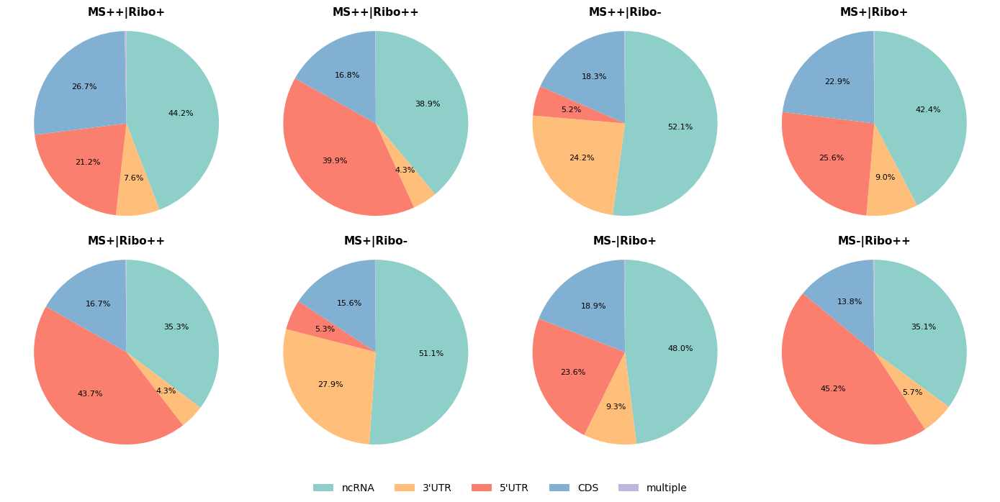

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# df为原始数据，包含group和localization两列
tab = pd.crosstab(alt4_ens_found_dedup["localization"], alt4_ens_found_dedup["group"])
tab = tab.rename(index={"-": "ncRNA"})

# 保证PDF中文字可编辑
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["font.family"] = "Arial"

colors = {
    "ncRNA":   "#8ECFC9",
    "3'UTR":   "#FFBE7A",
    "5'UTR":   "#FA7F6F",
    "CDS":     "#82B0D2",
    "multiple":"#BEB8DC"
}

order = ["ncRNA", "3'UTR", "5'UTR", "CDS", "multiple"]
tab = tab.reindex(order).fillna(0)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.ravel()

for ax, group in zip(axes, tab.columns):
    values = tab[group]
    wedges, _, _ = ax.pie(
        values,
        colors=[colors[x] for x in values.index],
        startangle=90,
        counterclock=False,
        autopct=lambda p: f"{p:.1f}%" if p >= 2 else "",
        textprops={"fontsize": 8}
    )
    ax.set_title(group, fontsize=11, fontweight="bold")
    ax.axis("equal")

for ax in axes[len(tab.columns):]:
    ax.axis("off")

fig.legend(
    wedges, tab.index,
    loc="lower center", ncol=5,
    frameon=False, fontsize=10
)

plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.savefig("/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/group_localization_piecharts_allgroup.pdf", bbox_inches="tight")
plt.show()



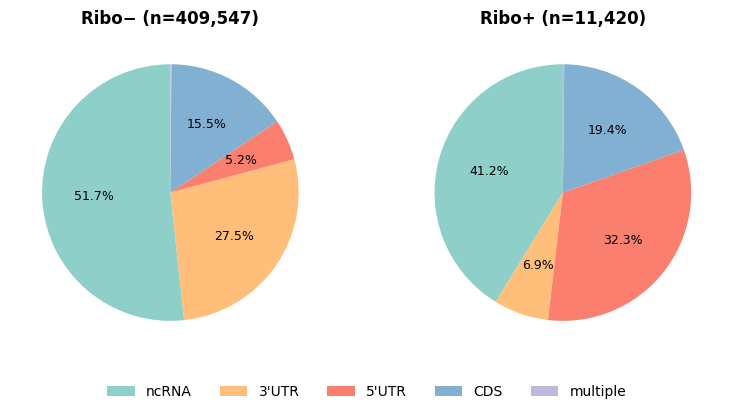

In [30]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
d=alt4_ens_found_dedup[["group","localization"]].copy()
d["localization"]=d["localization"].replace("-","ncRNA")
g=d["group"].astype(str).str.replace("−","-",regex=False).str.replace(" ","",regex=False)
d["Ribo"]=np.where(g.str.contains("Ribo-",regex=False),"Ribo−",np.where(g.str.contains("Ribo+",regex=False),"Ribo+",None))
d=d.dropna(subset=["Ribo"])
order=["ncRNA","3'UTR","5'UTR","CDS","multiple"]
tab=pd.crosstab(d["localization"],d["Ribo"]).reindex(index=order,columns=["Ribo−","Ribo+"],fill_value=0)
colors=["#8ECFC9","#FFBE7A","#FA7F6F","#82B0D2","#BEB8DC"]
plt.rcParams.update({"pdf.fonttype":42,"font.family":"DejaVu Sans"})
fig,axs=plt.subplots(1,2,figsize=(8,4))
for ax,status in zip(axs,tab.columns):
    v=tab[status]
    ax.pie(v,colors=colors,startangle=90,autopct=lambda p:f"{p:.1f}%" if p>=2 else "",textprops={"fontsize":9})
    ax.set_title(f"{status} (n={v.sum():,})",fontweight="bold")
fig.legend(order,loc="lower center",ncol=5,frameon=False)
plt.tight_layout(rect=[0,.1,1,1])
plt.savefig("/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/Ribo_localization_piecharts.pdf",bbox_inches="tight")
plt.show()

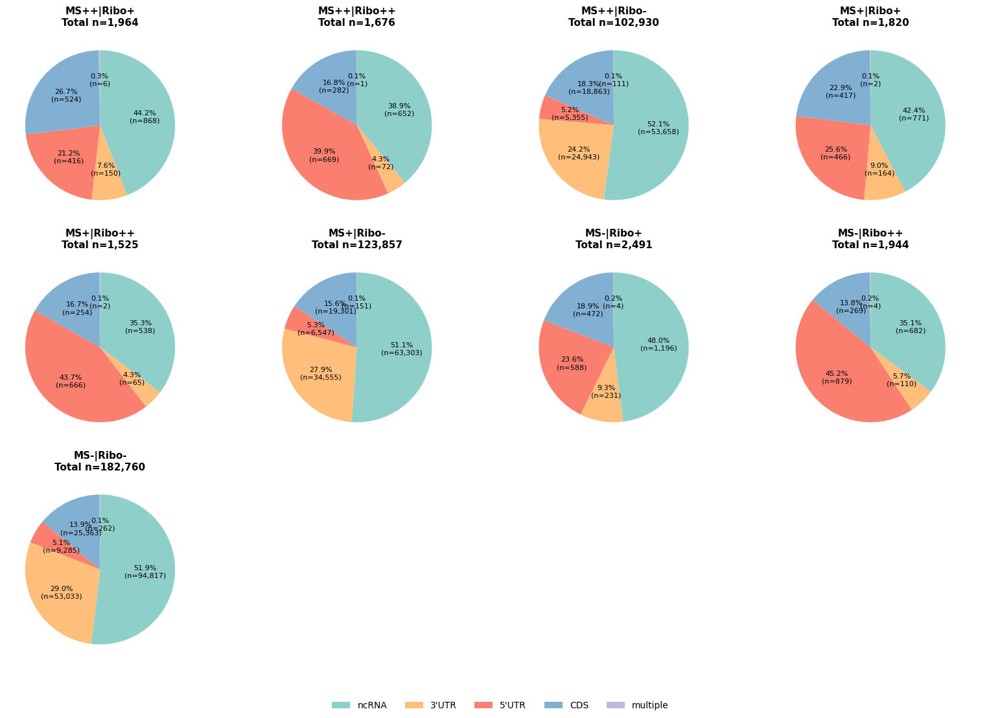

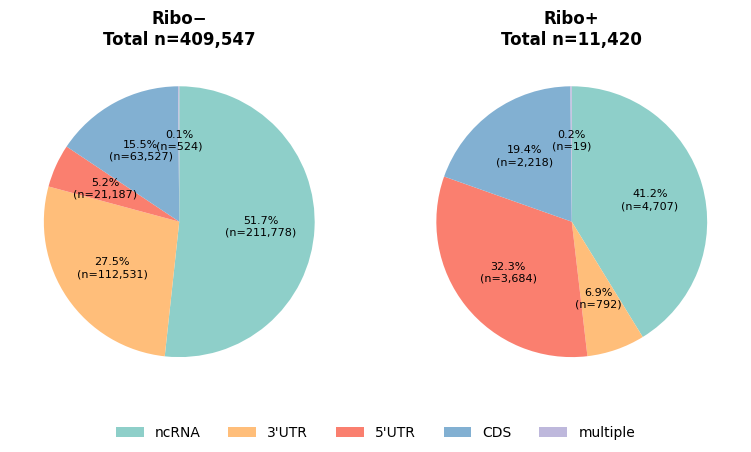

In [31]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.patches import Patch
from math import ceil
d=alt4_ens_found_dedup[["group","localization"]].dropna().copy()
d["localization"]=d["localization"].replace("-","ncRNA")
order=["ncRNA","3'UTR","5'UTR","CDS","multiple"]
colors={"ncRNA":"#8ECFC9","3'UTR":"#FFBE7A","5'UTR":"#FA7F6F","CDS":"#82B0D2","multiple":"#BEB8DC"}
plt.rcParams.update({"pdf.fonttype":42,"ps.fonttype":42,"font.family":"DejaVu Sans"})
def label(p,v):
    n=round(p*v.sum()/100)
    return f"{p:.1f}%\n(n={n:,})" if n else ""
handles=[Patch(facecolor=colors[x],label=x) for x in order]
tab=pd.crosstab(d["localization"],d["group"]).reindex(order,fill_value=0)
ncol=4
nrow=ceil(len(tab.columns)/ncol)
fig,axs=plt.subplots(nrow,ncol,figsize=(4*ncol,3.7*nrow))
axs=np.atleast_1d(axs).ravel()
for ax,group in zip(axs,tab.columns):
    v=tab[group]
    ax.pie(v,colors=[colors[x] for x in order],startangle=90,counterclock=False,autopct=lambda p,v=v:label(p,v),textprops={"fontsize":8})
    ax.set_title(f"{group}\nTotal n={v.sum():,}",fontsize=11,fontweight="bold")
for ax in axs[len(tab.columns):]: ax.axis("off")
fig.legend(handles=handles,loc="lower center",ncol=5,frameon=False)
plt.tight_layout(rect=[0,.06,1,1])
plt.savefig("/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/group_localization_piecharts_allgroup_v2.pdf",bbox_inches="tight")
plt.show()
g=d["group"].astype(str).str.replace("−","-",regex=False).str.replace("–","-",regex=False).str.replace(" ","",regex=False)
d["Ribo"]=np.select([g.str.contains("Ribo-",regex=False),g.str.contains("Ribo+",regex=False)],["Ribo−","Ribo+"],default=None)
dr=d.dropna(subset=["Ribo"])
tab2=pd.crosstab(dr["localization"],dr["Ribo"]).reindex(index=order,columns=["Ribo−","Ribo+"],fill_value=0)
fig,axs=plt.subplots(1,2,figsize=(8,4.3))
for ax,status in zip(axs,tab2.columns):
    v=tab2[status]
    ax.pie(v,colors=[colors[x] for x in order],startangle=90,counterclock=False,autopct=lambda p,v=v:label(p,v),textprops={"fontsize":8})
    ax.set_title(f"{status}\nTotal n={v.sum():,}",fontsize=12,fontweight="bold")
fig.legend(handles=handles,loc="lower center",ncol=5,frameon=False)
plt.tight_layout(rect=[0,.10,1,1])
plt.savefig("/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/Ribo_localization_piecharts_v2.pdf",bbox_inches="tight")
plt.show()

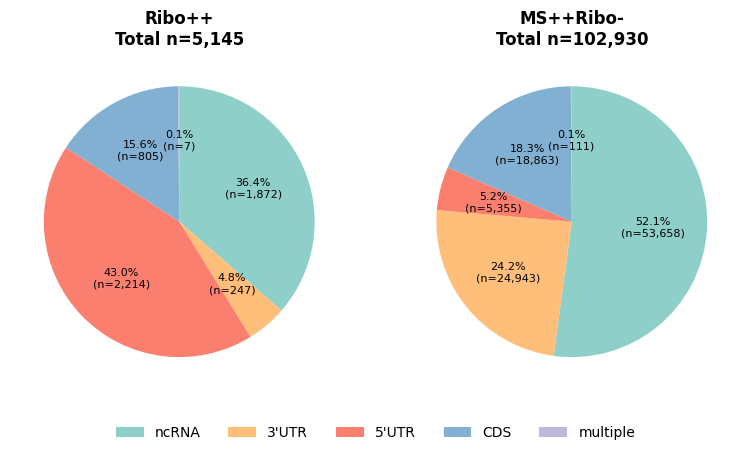

In [53]:
g=d["group"].astype(str).str.replace("−","-",regex=False).str.replace("–","-",regex=False).str.replace(" ","",regex=False)
d["Ribo"]=np.select([g.str.contains("Ribo++",regex=False),g.str.contains("MS++|Ribo-",regex=False)],["Ribo++","MS++Ribo-"],default=None)
dr=d.dropna(subset=["Ribo"])
tab2=pd.crosstab(dr["localization"],dr["Ribo"]).reindex(index=order,columns=["Ribo++","MS++Ribo-"],fill_value=0)
fig,axs=plt.subplots(1,2,figsize=(8,4.3))
for ax,status in zip(axs,tab2.columns):
    v=tab2[status]
    ax.pie(v,colors=[colors[x] for x in order],startangle=90,counterclock=False,autopct=lambda p,v=v:label(p,v),textprops={"fontsize":8})
    ax.set_title(f"{status}\nTotal n={v.sum():,}",fontsize=12,fontweight="bold")
fig.legend(handles=handles,loc="lower center",ncol=5,frameon=False)
plt.tight_layout(rect=[0,.10,1,1])
plt.savefig("/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/Ribo_localization_piecharts_v3.pdf",bbox_inches="tight")
plt.show()

In [54]:
import os,numpy as np,pandas as pd,matplotlib.pyplot as plt
from matplotlib_venn import venn2
OUT="/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/piechart/"
os.makedirs(OUT,exist_ok=True)
plt.rcParams.update({"font.family":"DejaVu Sans","pdf.fonttype":42,"ps.fonttype":42,"svg.fonttype":"none"})
df=alt4_ens_found_dedup.copy()
idc=next(c for c in ["protein accession","protein_accession","sample_id"] if c in df.columns)
df=df.dropna(subset=[idc]).drop_duplicates(idc).copy()
df["_group"]=df["group"].astype(str).str.replace("−","-",regex=False)
df["_loc"]=df["localization"].fillna("Unknown").replace("-","ncRNA")
ms=df["_group"].str.startswith("MS++|",na=False)
ribo=df["_group"].str.endswith("|Ribo++",na=False)
order=["ncRNA","3'UTR","5'UTR","CDS","multiple","Unknown"]
colors={"ncRNA":"#87C9C3","3'UTR":"#F5B66E","5'UTR":"#EE796B","CDS":"#82ADD0","multiple":"#AAA2CA","Unknown":"#C7C7C7"}
def save(fig,name):
    fig.savefig(f"{OUT}/{name}.pdf",bbox_inches="tight")
    fig.savefig(f"{OUT}/{name}.svg",bbox_inches="tight")
    fig.savefig(f"{OUT}/{name}.png",dpi=400,bbox_inches="tight")
    plt.close(fig)
def pie(mask,title,name):
    n=df.loc[mask,"_loc"].value_counts().reindex(order,fill_value=0);n=n[n>0];total=n.sum()
    fig,ax=plt.subplots(figsize=(6,5.5))
    w,_,_=ax.pie(n,colors=[colors.get(x,"#C7C7C7") for x in n.index],startangle=90,counterclock=False,autopct=lambda p:f"{p:.1f}%\n(n={round(p*total/100):,})",pctdistance=.68,wedgeprops={"edgecolor":"white","linewidth":.8})
    ax.legend(w,[f"{x}: n={v:,}" for x,v in n.items()],loc="lower center",bbox_to_anchor=(.5,-.12),ncol=3,frameon=False)
    ax.set_title(f"{title}\nTotal n={total:,}");ax.set_aspect("equal");save(fig,name)
pie(ms,"MS++","pie_MSpp_localization")
pie(ribo,"Ribo++","pie_Ribopp_localization")
MS=set(df.loc[ms,idc]);RIBO=set(df.loc[ribo,idc])
a,b,c=len(MS-RIBO),len(RIBO-MS),len(MS&RIBO)
labels=(f"MS++\n(n={len(MS):,})",f"Ribo++\n(n={len(RIBO):,})")
fig,ax=plt.subplots(figsize=(6,5))
v=venn2((a,b,c),set_labels=labels,set_colors=("#D9685A","#4B8EB8"),alpha=.65,ax=ax)
ax.set_title("MS++ and Ribo++ overlap\nCircle areas proportional to set sizes")
save(fig,"venn_MSpp_Ribopp_proportional")
fig,ax=plt.subplots(figsize=(6,5))
v=venn2((1,1,1),set_labels=labels,set_colors=("#D9685A","#4B8EB8"),alpha=.65,ax=ax)
for k,n in zip(["10","01","11"],[a,b,c]):v.get_label_by_id(k).set_text(f"{n:,}")
ax.set_title("MS++ and Ribo++ overlap\nEqual-size circles")
save(fig,"venn_MSpp_Ribopp_equal_circles")
pd.DataFrame({"MS++ only":[a],"Ribo++ only":[b],"MS++ and Ribo++":[c],"MS++ total":[len(MS)],"Ribo++ total":[len(RIBO)]}).to_csv(f"{OUT}/venn_counts.csv",index=False)
print(f"ID列：{idc}\nMS++：{len(MS):,}\nRibo++：{len(RIBO):,}\n交集：{c:,}\n输出目录：{OUT}")

ID列：protein accession
MS++：106,570
Ribo++：5,145
交集：1,676
输出目录：/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/piechart/


In [124]:
stage2_df = pd.read_pickle(
    "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/"
    "training_v3_2/stage2_v2_MSpp_ribotricer_strict_10runs/"
    "translation_strict_lenmatched_run00.pkl"
)
print(stage2_df.columns)
jc_df = pd.read_pickle(
    "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/JC_independent/JC_MS_pos_ribotricer_neg1w_with_rnafm_esm2_paths.pkl"
)
print(jc_df.columns)

Index(['sample_id', 'label_raw', 'binary_label', 'rnafm_up_path',
       'rnafm_orf_path', 'rnafm_down_path', 'orf_len', 'up_len', 'down_len',
       'orf_bin', 'up_bin', 'down_bin', 'len_bin', 'protein_accession',
       'transcript_accession', 'protein_len_aa', 'orf_nt_len', 'orf_seq',
       'upstream_seq_50nt', 'downstream_seq_50nt'],
      dtype='object')
Index(['sample_id', 'protein_accession', 'transcript_accession',
       'protein_len_aa', 'orf_seq', 'upstream_seq_50nt', 'downstream_seq_50nt',
       'orf_nt_len', 'label_raw', 'protein_len_a', 'label_id', 'rnafm_up_path',
       'rnafm_orf_path', 'rnafm_down_path', 'esm2_path', 'binary_label'],
      dtype='object')


In [128]:
##查看其他数据集的sORF定位比例##
import pandas as pd

# 1. 读取含 localization 的 OpenProt 注释表
anno = pd.read_csv("/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/temp/openprot_table.csv.gz")

# 2. 读取 Stage2 和 JC 数据
stage2_df = pd.read_pickle(
    "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/"
    "training_v3_2/stage2_v2_MSpp_ribotricer_strict_10runs/"
    "translation_strict_lenmatched_run00.pkl"
)
stage2_df['protein accession']=stage2_df['sample_id']

jc_df = pd.read_pickle(
    "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/JC_independent/JC_MS_pos_ribotricer_neg1w_with_rnafm_esm2_paths.pkl"
)

# 3. 提取阳性并添加 localization
stage2_pos = stage2_df.query("binary_label == 1").merge(
    anno[["protein accession", "localization"]],
    left_on="sample_id", right_on="protein accession", how="left"
)

jc_pos = jc_df.query("binary_label == 1").merge(
    anno[["protein accession", "localization"]],
    left_on="sample_id", right_on="protein accession", how="left"
)

# 4. 统计数量
result = pd.concat({
    "Stage2 positive": stage2_pos["localization"].fillna("Unknown").value_counts(),
    "JC positive": jc_pos["localization"].fillna("Unknown").value_counts()
}, axis=1).fillna(0).astype(int)

result.loc["Total"] = result.sum()
print('absolute numbers:')
display(result)
percent = result.iloc[:-1].div(result.iloc[:-1].sum()) * 100
print('percentage:')
display(percent.round(2))

/tmp/ipykernel_6468/604782292.py:5: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  anno = pd.read_csv("/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/temp/openprot_table.csv.gz")


absolute numbers:


,Stage2 positive,JC positive
localization,,
-,7050,319
3'UTR,4515,43
CDS,2756,43
5'UTR,357,9
multiple,19,0
Unknown,0,385
Total,14697,799


percentage:


,Stage2 positive,JC positive
localization,,
-,47.97,39.92
3'UTR,30.72,5.38
CDS,18.75,5.38
5'UTR,2.43,1.13
multiple,0.13,0.00
Unknown,0.00,48.19


In [133]:
import pandas as pd

# 完整OpenProt官方大表
anno = pd.read_csv(
    "/disk3/hejp/00_thesis/4_predict_translation/dataset/openprot/ensembl/"
    "human-openprot-2_2-refprots+altprots+isoforms-GRCh38.106-uniprot2022_06_01.tsv",
    sep="\t", low_memory=False,
    usecols=["protein accession", "localization"]
)

anno["protein accession"] = anno["protein accession"].astype(str).str.strip()

# JC阳性
jc_pos = jc_df.loc[
    jc_df["binary_label"].eq(1), ["sample_id"]
].drop_duplicates()

jc_pos["sample_id"] = jc_pos["sample_id"].astype(str).str.strip()

# 保留全部JC阳性，检查是否真正匹配
jc_pos = jc_pos.merge(
    anno.drop_duplicates("protein accession"),
    left_on="sample_id",
    right_on="protein accession",
    how="left",
    indicator=True
)

print(jc_pos["_merge"].value_counts())
print(jc_pos["localization"].value_counts(dropna=False))

display(jc_pos.loc[jc_pos["_merge"].eq("left_only"), "sample_id"].head(20))

_merge
both          799
left_only       0
right_only      0
Name: count, dtype: int64
localization
-           532
3'UTR       142
CDS          95
5'UTR        29
multiple      1
Name: count, dtype: int64


Series([], Name: sample_id, dtype: object)

In [137]:
import pandas as pd

# 1. 读取完整 OpenProt 注释表
anno = pd.read_csv(
    "/disk3/hejp/00_thesis/4_predict_translation/dataset/openprot/ensembl/"
    "human-openprot-2_2-refprots+altprots+isoforms-GRCh38.106-uniprot2022_06_01.tsv",
    sep="\t",
    low_memory=False,
    usecols=["protein accession", "localization"]
)

# 清理编号；同一蛋白优先保留具有 localization 的记录
anno["protein accession"] = anno["protein accession"].astype("string").str.strip()
anno["localization"] = anno["localization"].replace(r"^\s*$", pd.NA, regex=True)

anno = (
    anno.assign(has_loc=anno["localization"].notna())
        .sort_values("has_loc", ascending=False)
        .drop_duplicates("protein accession")
        .drop(columns="has_loc")
)


# 2. 读取 Stage2 和 JC 数据集
stage2_df = pd.read_pickle(
    "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/"
    "training_v3_2/stage2_v2_MSpp_ribotricer_strict_10runs/"
    "translation_strict_lenmatched_run00.pkl"
)

jc_df = pd.read_pickle(
    "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/"
    "training_v3_2/JC_independent/"
    "JC_MS_pos_ribotricer_neg1w_with_rnafm_esm2_paths.pkl"
)


# 3. 提取阳性，并根据 sample_id 匹配 OpenProt localization
def get_positive(df):
    x = df.loc[df["binary_label"].eq(1), ["sample_id"]].drop_duplicates()
    x["sample_id"] = x["sample_id"].astype("string").str.strip()

    return x.merge(
        anno,
        left_on="sample_id",
        right_on="protein accession",
        how="left",
        indicator=True,
        validate="one_to_one"
    )


stage2_pos = get_positive(stage2_df)
jc_pos = get_positive(jc_df)


# 4. 检查是否全部成功匹配 OpenProt
print("Stage2 positive:", len(stage2_pos))
print(stage2_pos["_merge"].value_counts())

print("\nJC positive:", len(jc_pos))
print(jc_pos["_merge"].value_counts())

# 显示未匹配的编号
unmatched = pd.concat({
    "Stage2_pos": stage2_pos.loc[
        stage2_pos["_merge"].eq("left_only"), "sample_id"
    ].reset_index(drop=True),

    "JC_pos": jc_pos.loc[
        jc_pos["_merge"].eq("left_only"), "sample_id"
    ].reset_index(drop=True)
}, axis=1)

if not unmatched.dropna(how="all").empty:
    print("\n未匹配的 protein accession：")
    display(unmatched.dropna(how="all").head(20))


# 5. 按 OpenProt localization 统计
# 不生成 Unknown；OpenProt 原始的 "-" 会保留
n = pd.concat({
    "Stage2_pos": stage2_pos["localization"].value_counts(),
    "JC_pos": jc_pos["localization"].value_counts()
}, axis=1).fillna(0).astype(int)

order = ["-", "3'UTR", "5'UTR", "CDS", "multiple"]

n = pd.concat({
    "Stage2_pos": stage2_pos["localization"].value_counts(),
    "JC_pos": jc_pos["localization"].value_counts()
}, axis=1).fillna(0).astype(int).reindex(order, fill_value=0)

pct = n.div(n.sum(), axis=1).mul(100)

result = n.astype(str) + " (" + pct.round(1).astype(str) + "%)"
result.loc["Total"] = n.sum().astype(str) + " (100.0%)"

display(result)


Stage2 positive: 14697
_merge
both          14697
left_only         0
right_only        0
Name: count, dtype: int64

JC positive: 799
_merge
both          799
left_only       0
right_only      0
Name: count, dtype: int64


,Stage2_pos,JC_pos
localization,,
-,6873 (46.8%),542 (67.8%)
3'UTR,4575 (31.1%),143 (17.9%)
5'UTR,425 (2.9%),29 (3.6%)
CDS,2797 (19.0%),84 (10.5%)
multiple,27 (0.2%),1 (0.1%)
Total,14697 (100.0%),799 (100.0%)


In [140]:
###看看stage1在stage2数据集的预测中，是否有localization的差异###
import pandas as pd

# 1. 读取之前保存的Stage1预测结果
pred = pd.read_csv(
    "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_v2_MSpp_ribotricer/stage1_external_eval_stage2_JC/stage2/"
    "stage2_run00_all_models_and_ensemble.csv.gz"
)

# 2. 读取OpenProt localization
anno = pd.read_csv(
    "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/"
    "training_v3_2/temp/openprot_table.csv.gz",
    usecols=["protein accession", "localization"]
).drop_duplicates("protein accession")

# 3. 只分析Stage2真实阳性，并匹配OpenProt标签
x = pred.loc[pred["y_true"].eq(1)].merge(
    anno, left_on="sample_id", right_on="protein accession", how="inner"
)

x["Stage1 prediction"] = x["ensemble_prediction"].map({
    0: "Predicted negative",
    1: "Predicted positive"
})

# 4. 数量（每个localization内部比例）
order = ["-", "3'UTR", "5'UTR", "CDS", "multiple"]

n = pd.crosstab(
    x["localization"], x["Stage1 prediction"]
).reindex(
    index=order,
    columns=["Predicted negative", "Predicted positive"],
    fill_value=0
)

pct = n.div(n.sum(axis=1), axis=0).mul(100)
display(n.astype(str) + " (" + pct.round(1).astype(str) + "%)")

Stage1 prediction,Predicted negative,Predicted positive
localization,,
-,5769 (81.8%),1281 (18.2%)
3'UTR,4029 (89.2%),486 (10.8%)
5'UTR,215 (60.2%),142 (39.8%)
CDS,2020 (73.3%),736 (26.7%)
multiple,14 (73.7%),5 (26.3%)


In [141]:
summary = x.groupby("localization").agg(
    n=("sample_id", "size"),
    mean_probability=("ensemble_probability", "mean"),
    median_probability=("ensemble_probability", "median"),
    predicted_positive=("ensemble_prediction", "sum")
).reindex(order)

summary["positive_rate_%"] = (
    summary["predicted_positive"] / summary["n"] * 100
)

display(summary.round(3))

,n,mean_probability,median_probability,predicted_positive,positive_rate_%
localization,,,,,
-,7050,0.287,0.217,1281,18.170
3'UTR,4515,0.223,0.159,486,10.764
5'UTR,357,0.425,0.334,142,39.776
CDS,2756,0.381,0.339,736,26.705
multiple,19,0.264,0.126,5,26.316


In [110]:
# 先复制一份，避免改原表
ml_df = alt4_ens_found_dedup.copy()

# 1) 坐标转成数值
ml_df["start transcript coordinates"] = pd.to_numeric(
    ml_df["start transcript coordinates"], errors="coerce"
)
ml_df["stop transcript coordinates"] = pd.to_numeric(
    ml_df["stop transcript coordinates"], errors="coerce"
)

# 2) 提取序列函数
#UP_LEN = 50
#DOWN_LEN = 50

UP_LEN = 450
DOWN_LEN = 450

def extract_tx_seqs(row):
    tx_id = row["transcript accession"]
    start = row["start transcript coordinates"]
    stop = row["stop transcript coordinates"]
    
    # transcript 序列字典：你前面已经建立过 tx_seq_dict
    tx_seq = tx_seq_dict.get(tx_id, None)
    
    if tx_seq is None or pd.isna(start) or pd.isna(stop):
        return pd.Series({
            "orf_rna_seq": pd.NA,
            "upstream_50nt": pd.NA,
            "downstream_50nt": pd.NA,
            "orf_nt_len": pd.NA,
            "seq_ok": 0
        })
    
    # transcript 坐标通常按 1-based, inclusive 处理
    s = int(min(start, stop))
    e = int(max(start, stop))
    
    # 转成 python 切片
    s0 = s - 1
    e0 = e-1
    
    # 边界检查
    if s0 < 0 or e0 > len(tx_seq):
        return pd.Series({
            "orf_rna_seq": pd.NA,
            "upstream_50nt": pd.NA,
            "downstream_50nt": pd.NA,
            "orf_nt_len": pd.NA,
            "seq_ok": 0
        })
    
    orf_seq = tx_seq[s0:e0]
    up_seq = tx_seq[max(0, s0 - UP_LEN): s0]
    down_seq = tx_seq[e0: min(len(tx_seq), e0 + DOWN_LEN)]
    
    return pd.Series({
        "orf_rna_seq": orf_seq,
        "upstream_50nt": up_seq,
        "downstream_50nt": down_seq,
        "orf_nt_len": len(orf_seq),
        "seq_ok": 1
    })

# 3) 批量提取
seq_df = ml_df.apply(extract_tx_seqs, axis=1)
ml_df = pd.concat([ml_df, seq_df], axis=1)

# 4) 看结果
print("成功提取比例：", ml_df["seq_ok"].mean())
print("\nseq_ok 计数：")
print(ml_df["seq_ok"].value_counts(dropna=False))

display(
    ml_df[[
        "protein accession",
        "transcript accession",
        "start transcript coordinates",
        "stop transcript coordinates",
        "transcript_length",
        "orf_nt_len",
        "orf_rna_seq",
        "upstream_50nt",
        "downstream_50nt",
        "group"
    ]].head(10)
)

成功提取比例： 1.0

seq_ok 计数：
seq_ok
1    114350
Name: count, dtype: int64


,protein accession,transcript accession,start transcript coordinates,stop transcript coordinates,transcript_length,orf_nt_len,orf_rna_seq,upstream_50nt,downstream_50nt,group
11,IP_057218,ENST00000456475.1,267.0,369.0,995.0,102,ATGACCTGTTCAGAAAGCGCAAAGTCATCTCCTTTGGAGGCTGCAT...,AGCCCAGTTGGCTGGACCAATGGATGGAGAGAATCACTCAGTGGTA...,CCATGGCCTTTGACAGATATGTGGCCCTATGTAAGCCCCTCCACTA...,MS++|Ribo-
83,IP_057223,ENST00000618323.5,1909.0,2203.0,3468.0,294,ATGCCCCTCACGTCGCCCTGGGCCCCCATCTCAGGCCCCCCTTCCT...,TTGGCCTGCGACCCGCCGGTGACCTGTTGGGCAAGAGGCTGGGCCG...,ACCACGGCGCGGCGCCACTGCTGGCCCTGCCCCCCCAGGGGCCCCC...,MS-|Ribo++
22,IP_057225,ENST00000618323.5,3105.0,3363.0,3468.0,258,ATGGCCCTGCCTCCCACCGCTTTATTTCTTTCGGTTTCGGATGCAA...,GTGGGGGGCCTGTCTGGCTGTGGAGAGTACACTCGGGTCTTCAGGG...,CTTCAGCAGCCCACAGCTGTGGGGCTTCAGCAGCCACACCAGCCCA...,MS++|Ribo-
28,IP_057228,ENST00000327044.7,528.0,873.0,2757.0,345,ATGAAGTGGTACAGGCGTTCCGAGCAGCTGTGGCCACCACCCGAGG...,CTTCGGGCTTTGACTCCGAGTCCGAATCCGAGTCCGAAAATTCTCC...,CCTTCCCCAAGCAGTGCCGCATGCTGCTCAAGAGAATGGTGATCGT...,MS++|Ribo-
37,IP_057233,ENST00000338591.8,715.0,817.0,2567.0,102,ATGCGCACTCCTGCAGCGACCTGCTCAAGGCCGCCCACAGGTACGT...,CCATGGAGGGAGCCGTGCAGCTGCTGAGCCGCGAGGGCCACAGCGT...,AACAGGTTCTGGAACTGGTCTCTAGCGACAGCCTGAACGTGCCTTC...,MS++|Ribo-
43,IP_057234,ENST00000338591.8,1819.0,2161.0,2567.0,342,ATGACCTGGTGGCCATGGACGGATGGTTGTACGCCGTGGGGGGTAA...,TGTCCATGGGCACAAGGCGAAGCTGCCTGGGTGTGGCCGCCTTGCA...,TTGTTTATTTATTTAGTTATTTATCTTATTTATTGAGGGGTGAGGA...,MS++|Ribo-
48,IP_057235,ENST00000338591.8,1534.0,1633.0,2567.0,99,ATGTGCGAGTGGCCACGCTTGATGGGAACCTGTATGCTGTGGGCGG...,GCGTCCTAGGCACCAGCCGCACACGTCCCCGGCGCTGCGAGGGGGC...,ACGTGTGGTCGCCCGTGGCGTCCATGCTGAGCCGACGCAGCTCAGC...,MS++|Ribo-
58,IP_057245,ENST00000379410.8,1375.0,1750.0,3176.0,375,ATGCCCCTGACCACACTTCGGAAACATCACACTCGCCCCTCTATGC...,TCAACACCATCCGCGTGGTGTGCGCCAGCTACGAGGACTACGGTCA...,CAGATGGTCGGTCCCCCAGGAGGAGCCGGGACCCCGGCTACGACCA...,MS++|Ribo-
69,IP_057246,ENST00000379410.8,1753.0,1951.0,3176.0,198,ATGGTCGGTCCCCCAGGAGGAGCCGGGACCCCGGCTACGACCACCT...,GCCGCGGCCCTGTCACCCCACTGCACCTGGACCTGACCCAGCTGCA...,CCCACTTCAAATTACAAGTCAGGGTCTGAACCCAGTGTGATGGGGG...,MS++|Ribo-
79,IP_057249,ENST00000379410.8,2279.0,2396.0,3176.0,117,ATGAGGGTCACAGGTCAGCAAGGTGTGAGGAGCACAAGCCAGGGTG...,GAAGTGCCCCCAGCTTGGAGGGCCTGAGGCCAGTGGGGGGCTTGTG...,CACCACCGGACGAGAAAGAAAAAAGAGAGAAGAGAGAGAGGAGAAG...,MS++|Ribo-


In [111]:
ml_df["protein length (a.a.)"] = pd.to_numeric(ml_df["protein length (a.a.)"], errors="coerce")
ml_df["expected_nt_len"] = ml_df["protein length (a.a.)"] * 3

display(
    ml_df[[
        "protein accession",
        "protein length (a.a.)",
        "expected_nt_len",
        "orf_nt_len",
        "group"
    ]].head(20)
)

,protein accession,protein length (a.a.),expected_nt_len,orf_nt_len,group
11,IP_057218,33,99,102,MS++|Ribo-
83,IP_057223,97,291,294,MS-|Ribo++
22,IP_057225,85,255,258,MS++|Ribo-
28,IP_057228,114,342,345,MS++|Ribo-
37,IP_057233,33,99,102,MS++|Ribo-
43,IP_057234,113,339,342,MS++|Ribo-
48,IP_057235,32,96,99,MS++|Ribo-
58,IP_057245,124,372,375,MS++|Ribo-
69,IP_057246,65,195,198,MS++|Ribo-
79,IP_057249,38,114,117,MS++|Ribo-


In [38]:
test=ml_df[ml_df['protein length (a.a.)']==30].copy()
display(test.shape)
display(test['group'].value_counts())

(3288, 31)

group
MS++|Ribo-     2943
MS-|Ribo++       89
MS-|Ribo+        72
MS+|Ribo+        65
MS+|Ribo++       57
MS++|Ribo+       33
MS++|Ribo++      29
Name: count, dtype: int64

In [ ]:
###看看各个分类中localization的比例###
# 保存用于训练的数据（带长度筛选和随机抽样）
import os
import json
import pandas as pd
import numpy as np

out_dir = "/disk3/hejp/00_thesis/4_predict_translation/data/processed/dataset_nt450_v3/test_local_percent"
os.makedirs(out_dir, exist_ok=True)

# 选取原始列
train_df = ml_df[[
    "protein accession",
    "transcript accession",
    "protein length (a.a.)",
    "orf_rna_seq",
    "upstream_50nt",
    "downstream_50nt",
    "orf_nt_len",
    "group",
    ""
]].copy()

# -------------------
# 序列清洗函数
# -------------------
def clean_seq(seq):
    if pd.isna(seq):
        return pd.NA
    seq = str(seq).upper().replace("U", "T")
    seq = "".join([x for x in seq if x in set("ATCGN")])
    return seq if len(seq) > 0 else pd.NA

for col in ["orf_rna_seq", "upstream_50nt", "downstream_50nt"]:
    train_df[col] = train_df[col].apply(clean_seq)

train_df["orf_nt_len"] = train_df["orf_rna_seq"].apply(lambda x: len(x) if pd.notna(x) else np.nan)

# -------------------
# 原始过滤
# -------------------
train_df = train_df[
    train_df["orf_rna_seq"].notna() &
    train_df["group"].notna() &
    (train_df["orf_nt_len"] >= 3)
].copy()

# -------------------
# 筛选 protein length 30-150 aa
# -------------------
train_df["protein_len_aa"] = pd.to_numeric(train_df["protein length (a.a.)"], errors="coerce")
train_df = train_df[(train_df["protein_len_aa"] >= 30) & (train_df["protein_len_aa"] <= 150)].copy()

# -------------------
# 对 group 列随机采样
# -------------------
# MS++|Ribo- 随机取样 20000
mspp_ribo_minus = train_df[train_df["group"] == "MS++|Ribo-"]
if len(mspp_ribo_minus) > 20000:
    mspp_ribo_minus = mspp_ribo_minus.sample(20000, random_state=42)

# 其他 group 全部保留
other_groups = train_df[train_df["group"] != "MS++|Ribo-"]

# 合并
train_df = pd.concat([mspp_ribo_minus, other_groups], axis=0).reset_index(drop=True)

# -------------------
# 重命名列
# -------------------
train_df = train_df.rename(columns={
    "protein accession": "protein_accession",
    "transcript accession": "transcript_accession",
    "protein length (a.a.)": "protein_len_aa",
    "orf_rna_seq": "orf_seq",
    "upstream_50nt": "upstream_seq_50nt",
    "downstream_50nt": "downstream_seq_50nt",
    "group": "label_raw"
})

train_df = train_df.reset_index(drop=True)
train_df.insert(0, "sample_id", [f"sample_{i:07d}" for i in range(len(train_df))])

# -------------------
# label id 映射
# -------------------
label_order = sorted(train_df["label_raw"].astype(str).unique().tolist())
label_map = {lab: i for i, lab in enumerate(label_order)}
train_df["label_id"] = train_df["label_raw"].map(label_map).astype(int)

# -------------------
# 强制转成字符串列
# -------------------
for col in ["sample_id", "protein_accession", "transcript_accession",
            "orf_seq", "upstream_seq_50nt", "downstream_seq_50nt", "label_raw"]:
    train_df[col] = train_df[col].astype("string").astype(str)

train_df["orf_nt_len"] = pd.to_numeric(train_df["orf_nt_len"], errors="coerce")
train_df["label_id"] = pd.to_numeric(train_df["label_id"], errors="coerce").astype(int)

# -------------------
# 输出
# -------------------
csv_gz_path = os.path.join(out_dir, "train_table_pos.csv.gz")
pkl_path = os.path.join(out_dir, "train_table_pos.pkl")
summary_path = os.path.join(out_dir, "train_table_pos_summary.json")

train_df.to_csv(csv_gz_path, index=False, compression="gzip")
train_df.to_pickle(pkl_path)

summary = {
    "n_rows": int(train_df.shape[0]),
    "n_cols": int(train_df.shape[1]),
    "columns": train_df.columns.tolist(),
    "label_order": label_order,
    "label_map": label_map,
    "label_raw_counts": {
        str(k): int(v) for k, v in train_df["label_raw"].value_counts().to_dict().items()
    }
}

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("导出完成：")
print(csv_gz_path)
print(pkl_path)
print(summary_path)

print("\nlabel_map:")
print(label_map)

print("\nlabel_raw 分布：")
print(train_df["label_raw"].value_counts())

display(train_df.head())

In [39]:
# 保存用于训练的数据（带长度筛选和随机抽样）
import os
import json
import pandas as pd
import numpy as np

out_dir = "/disk3/hejp/00_thesis/4_predict_translation/data/processed/dataset_nt450_v3"
os.makedirs(out_dir, exist_ok=True)

# 选取原始列
train_df = ml_df[[
    "protein accession",
    "transcript accession",
    "protein length (a.a.)",
    "orf_rna_seq",
    "upstream_50nt",
    "downstream_50nt",
    "orf_nt_len",
    "group"
]].copy()

# -------------------
# 序列清洗函数
# -------------------
def clean_seq(seq):
    if pd.isna(seq):
        return pd.NA
    seq = str(seq).upper().replace("U", "T")
    seq = "".join([x for x in seq if x in set("ATCGN")])
    return seq if len(seq) > 0 else pd.NA

for col in ["orf_rna_seq", "upstream_50nt", "downstream_50nt"]:
    train_df[col] = train_df[col].apply(clean_seq)

train_df["orf_nt_len"] = train_df["orf_rna_seq"].apply(lambda x: len(x) if pd.notna(x) else np.nan)

# -------------------
# 原始过滤
# -------------------
train_df = train_df[
    train_df["orf_rna_seq"].notna() &
    train_df["group"].notna() &
    (train_df["orf_nt_len"] >= 3)
].copy()

# -------------------
# 筛选 protein length 30-150 aa
# -------------------
train_df["protein_len_aa"] = pd.to_numeric(train_df["protein length (a.a.)"], errors="coerce")
train_df = train_df[(train_df["protein_len_aa"] >= 30) & (train_df["protein_len_aa"] <= 150)].copy()

# -------------------
# 对 group 列随机采样
# -------------------
# MS++|Ribo- 随机取样 20000
mspp_ribo_minus = train_df[train_df["group"] == "MS++|Ribo-"]
if len(mspp_ribo_minus) > 20000:
    mspp_ribo_minus = mspp_ribo_minus.sample(20000, random_state=42)

# 其他 group 全部保留
other_groups = train_df[train_df["group"] != "MS++|Ribo-"]

# 合并
train_df = pd.concat([mspp_ribo_minus, other_groups], axis=0).reset_index(drop=True)

# -------------------
# 重命名列
# -------------------
train_df = train_df.rename(columns={
    "protein accession": "protein_accession",
    "transcript accession": "transcript_accession",
    "protein length (a.a.)": "protein_len_aa",
    "orf_rna_seq": "orf_seq",
    "upstream_50nt": "upstream_seq_50nt",
    "downstream_50nt": "downstream_seq_50nt",
    "group": "label_raw"
})

train_df = train_df.reset_index(drop=True)
train_df.insert(0, "sample_id", [f"sample_{i:07d}" for i in range(len(train_df))])

# -------------------
# label id 映射
# -------------------
label_order = sorted(train_df["label_raw"].astype(str).unique().tolist())
label_map = {lab: i for i, lab in enumerate(label_order)}
train_df["label_id"] = train_df["label_raw"].map(label_map).astype(int)

# -------------------
# 强制转成字符串列
# -------------------
for col in ["sample_id", "protein_accession", "transcript_accession",
            "orf_seq", "upstream_seq_50nt", "downstream_seq_50nt", "label_raw"]:
    train_df[col] = train_df[col].astype("string").astype(str)

train_df["orf_nt_len"] = pd.to_numeric(train_df["orf_nt_len"], errors="coerce")
train_df["label_id"] = pd.to_numeric(train_df["label_id"], errors="coerce").astype(int)

# -------------------
# 输出
# -------------------
csv_gz_path = os.path.join(out_dir, "train_table_pos.csv.gz")
pkl_path = os.path.join(out_dir, "train_table_pos.pkl")
summary_path = os.path.join(out_dir, "train_table_pos_summary.json")

train_df.to_csv(csv_gz_path, index=False, compression="gzip")
train_df.to_pickle(pkl_path)

summary = {
    "n_rows": int(train_df.shape[0]),
    "n_cols": int(train_df.shape[1]),
    "columns": train_df.columns.tolist(),
    "label_order": label_order,
    "label_map": label_map,
    "label_raw_counts": {
        str(k): int(v) for k, v in train_df["label_raw"].value_counts().to_dict().items()
    }
}

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("导出完成：")
print(csv_gz_path)
print(pkl_path)
print(summary_path)

print("\nlabel_map:")
print(label_map)

print("\nlabel_raw 分布：")
print(train_df["label_raw"].value_counts())

display(train_df.head())

导出完成：
/disk3/hejp/00_thesis/4_predict_translation/data/processed/dataset_nt450_v3/train_table_pos.csv.gz
/disk3/hejp/00_thesis/4_predict_translation/data/processed/dataset_nt450_v3/train_table_pos.pkl
/disk3/hejp/00_thesis/4_predict_translation/data/processed/dataset_nt450_v3/train_table_pos_summary.json

label_map:
{'MS++|Ribo+': 0, 'MS++|Ribo++': 1, 'MS++|Ribo-': 2, 'MS+|Ribo+': 3, 'MS+|Ribo++': 4, 'MS-|Ribo+': 5, 'MS-|Ribo++': 6}

label_raw 分布：
label_raw
MS++|Ribo-     20000
MS-|Ribo+       2451
MS-|Ribo++      1912
MS++|Ribo+      1845
MS+|Ribo+       1787
MS++|Ribo++     1580
MS+|Ribo++      1499
Name: count, dtype: int64


,sample_id,protein_accession,transcript_accession,protein_len_aa,orf_seq,upstream_seq_50nt,downstream_seq_50nt,orf_nt_len,label_raw,protein_len_aa,label_id
0,sample_0000000,IP_3787180,ENST00000680249.1,108,ATGCTGCTGAAAAGATACCCGAAAACAGGGAAGCAACTTTGGAACT...,ATTCCTCCTTATAATACCATCAGATATTATGATACTTATTTGCTAT...,GGAATCTGGTGGAAGAAATTTCTAAGCAGCAAAGCATTCAAGAGGT...,327,MS++|Ribo-,108,2
1,sample_0000001,IP_664307,ENST00000494955.1,90,ATGGTGCTGTACCCACTTTTTGTTAATGATATTTATAGAGGCTATA...,ATGAGTTCAAGCAGTTCTCCTGCCTCATCCTCCCAAAGTATTGGGA...,GGCTCAGGGGTGACACAGCTGGTTTGCAGTCGCACATGGGAGCCAG...,273,MS++|Ribo-,90,2
2,sample_0000002,IP_2370990,ENST00000695368.1,44,ATGTTCAGGATATTAAATACTATTAAATTCTACCTCATTAGGTACA...,TCTTTTTATAGCCACACCGTCTTCATCGCCTGAATTGATCTCAAAT...,CAAAAACTACCATGCAGAATCAGGTTGAGGATAAATCTCCAGAATA...,135,MS++|Ribo-,44,2
3,sample_0000003,IP_070099,ENST00000439374.6,50,ATGACATTCCATTTAAGTTTTGGGGCATCTTTCCTGCCCTCTGCCA...,TGCCACCTGTTTTTAAACTCTTAAACCTGGAACTCCTTAAATGGGG...,GGATGGTGAGATAAATAGGTTGAAAACAATCATCTGTGAGTTTAGG...,153,MS++|Ribo-,50,2
4,sample_0000004,IP_131332,ENST00000353963.7,40,ATGAAACCACCAGGGACCCCTCGACCCCGCTACCCACAGAGCCTAA...,CTCTTCTCCTCAGGAACTGCTCAAACCTGTGCCCCAAAGATGAGGG...,CATGCTTCAGTGGTACCATCGCCGTGCCCTTCCTGCTGGCTGAGGC...,123,MS++|Ribo-,40,2


In [107]:
print(train_df["label_id"].value_counts())

label_id
2    20000
5     2451
6     1912
0     1845
3     1787
1     1580
4     1499
Name: count, dtype: int64


In [ ]:
!python /disk3/hejp/00_thesis/4_predict_translation/src/build_features_rnafm_token_nt450_ribotricer_openprot_transcript_5to3.py

In [41]:
!python /disk3/hejp/00_thesis/4_predict_translation/src/build_features_rnafm_token_nt450_ribotricer_openprot_transcript_5to3_v2.py \
  --input_table /disk3/hejp/00_thesis/4_predict_translation/data/processed/dataset_nt450_v3/train_table_pos.pkl \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_rnafm_token_pos \
  --local_model_dir /disk3/hejp/00_thesis/4_predict_translation/model/rnafm \
  --model_name rna-fm \
  --run_region all \
  --upstream_col upstream_seq_50nt \
  --orf_col orf_seq \
  --downstream_col downstream_seq_50nt \
  --id_col sample_id \
  --label_col label_raw \
  --min_aa 30 \
  --max_aa 150 \
  --dna_source coding \
  --batch_size 1 \
  --too_long skip \
  --device cuda

[INFO] RNA-FM token-level feature extraction
[INFO] input_table: /disk3/hejp/00_thesis/4_predict_translation/data/processed/dataset_nt450_v3/train_table_pos.pkl
[INFO] out_dir: /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_rnafm_token_pos
[INFO] local_model_dir: /disk3/hejp/00_thesis/4_predict_translation/model/rnafm
[INFO] model_name: rna-fm
[INFO] run_region: all
[INFO] dna_source: coding
[INFO] device: cuda

[INFO] Loading input table...
[INFO] Input shape: (31074, 11)
[INFO] Columns: ['sample_id', 'protein_accession', 'transcript_accession', 'protein_len_aa', 'orf_seq', 'upstream_seq_50nt', 'downstream_seq_50nt', 'orf_nt_len', 'label_raw', 'protein_len_aa', 'label_id']
[INFO] Infer aa length from ORF sequence

[INFO] Keep microproteins: 30 <= aa_len <= 150
[INFO] Remaining samples: 31074
[INFO] Filtered rows saved: /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_rnafm_token_pos/rnafm_filtered_30_150aa_rows.csv
[INFO] Use local

In [57]:
### neg dataset ###
#提取序列，去重，整理数据#
#pip install pyfaidx biopython pandas
import pandas as pd
from pyfaidx import Fasta
from Bio.Seq import Seq

genome = Fasta("/disk3/hejp/00_thesis/4_predict_translation/dataset/openprot/ensembl_for_ribotricer/Homo_sapiens_106.GRCh38.dna.toplevel.fa")

df = pd.read_csv("/disk3/hejp/00_thesis/4_predict_translation/dataset/openprot/ensembl_for_ribotricer/GRCh38_ribotricer_index/GRCh38_ribotricer_index_candidate_orfs.tsv", sep="\t")
df = df[df["ORF_type"] != "annotated"].copy()

def fetch_orf_seq(chrom, coord_str, strand):
    seq_parts = []
    for block in coord_str.split(","):
        s, e = block.split("-")
        s, e = int(s), int(e)

        start0 = min(s, e) - 1   # pyfaidx 0-based
        end0 = max(s, e)         # end-exclusive

        part = genome[str(chrom)][start0:end0].seq.upper()
        seq_parts.append(part)

    full_seq = "".join(seq_parts)

    if strand == "-":
        full_seq = str(Seq(full_seq).reverse_complement())

    return full_seq

df["nt_seq"] = df.apply(
    lambda x: fetch_orf_seq(x["chrom"], x["coordinate"], x["strand"]),
    axis=1
)

print(df[["ORF_ID", "ORF_type", "nt_seq"]].head(n=20))

/tmp/ipykernel_3484851/4230132476.py:10: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/disk3/hejp/00_thesis/4_predict_translation/dataset/openprot/ensembl_for_ribotricer/GRCh38_ribotricer_index/GRCh38_ribotricer_index_candidate_orfs.tsv", sep="\t")


                                    ORF_ID      ORF_type  \
95158   ENST00000379236_1211361_1211423_63    super_dORF   
95159   ENST00000379236_1211361_1211390_30    super_dORF   
95160  ENST00000497869_1213150_1213422_273         novel   
95161   ENST00000497869_1211361_1211423_63         novel   
95162   ENST00000497869_1211361_1211390_30         novel   
95163  ENST00000497869_1211558_1213373_921         novel   
95164  ENST00000497869_1211558_1211692_135         novel   
95165  ENST00000497869_1213394_1214127_537         novel   
95166  ENST00000497869_1213394_1213777_384         novel   
95167  ENST00000497869_1213394_1213585_192         novel   
95168   ENST00000497869_1211665_1211721_57         novel   
95169   ENST00000379268_1203610_1203690_81          dORF   
95170   ENST00000379268_1203610_1203636_27          dORF   
95171  ENST00000486728_1205450_1205680_231  overlap_uORF   
95172  ENST00000673477_1496085_1496219_135    super_dORF   
95173   ENST00000673477_1496460_1496483_

In [93]:
test=pd.read_csv("/disk3/hejp/00_thesis/4_predict_translation/dataset/openprot/ensembl_for_ribotricer/GRCh38_ribotricer_index/GRCh38_ribotricer_index_candidate_orfs.tsv", sep="\t")
display(test.head())

/tmp/ipykernel_3484851/186232537.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  test=pd.read_csv("/disk3/hejp/00_thesis/4_predict_translation/dataset/openprot/ensembl_for_ribotricer/GRCh38_ribotricer_index/GRCh38_ribotricer_index_candidate_orfs.tsv", sep="\t")


,ORF_ID,ORF_type,transcript_id,transcript_type,gene_id,gene_name,gene_type,chrom,strand,start_codon,coordinate
0,ENST00000379236_1211558_1214127_831,annotated,ENST00000379236,protein_coding,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,"1211558-1211625,1211704-1211832,1211942-1212138,1212638-1212704,1212992-1213093,1213663-1213785,1213983-1214127"
1,ENST00000328596_1203594_1206571_765,annotated,ENST00000328596,protein_coding,ENSG00000186891,TNFRSF18,protein_coding,1,-,ATG,"1203594-1203960,1204399-1204486,1205370-1205492,1206385-1206571"
2,ENST00000379268_1203847_1206571_723,annotated,ENST00000379268,protein_coding,ENSG00000186891,TNFRSF18,protein_coding,1,-,ATG,"1203847-1203968,1204034-1204236,1204399-1204486,1205370-1205492,1206385-1206571"
3,ENST00000486728_1203847_1205463_507,annotated,ENST00000486728,protein_coding,ENSG00000186891,TNFRSF18,protein_coding,1,-,ATG,"1203847-1203968,1204034-1204236,1204399-1204486,1205370-1205463"
4,ENST00000379265_1203847_1206571_702,annotated,ENST00000379265,protein_coding,ENSG00000186891,TNFRSF18,protein_coding,1,-,ATG,"1203847-1203968,1204055-1204236,1204399-1204486,1205370-1205492,1206385-1206571"


In [58]:
print(df[["ORF_ID", "ORF_type", "nt_seq"]].head(n=20))

                                    ORF_ID      ORF_type  \
95158   ENST00000379236_1211361_1211423_63    super_dORF   
95159   ENST00000379236_1211361_1211390_30    super_dORF   
95160  ENST00000497869_1213150_1213422_273         novel   
95161   ENST00000497869_1211361_1211423_63         novel   
95162   ENST00000497869_1211361_1211390_30         novel   
95163  ENST00000497869_1211558_1213373_921         novel   
95164  ENST00000497869_1211558_1211692_135         novel   
95165  ENST00000497869_1213394_1214127_537         novel   
95166  ENST00000497869_1213394_1213777_384         novel   
95167  ENST00000497869_1213394_1213585_192         novel   
95168   ENST00000497869_1211665_1211721_57         novel   
95169   ENST00000379268_1203610_1203690_81          dORF   
95170   ENST00000379268_1203610_1203636_27          dORF   
95171  ENST00000486728_1205450_1205680_231  overlap_uORF   
95172  ENST00000673477_1496085_1496219_135    super_dORF   
95173   ENST00000673477_1496460_1496483_

In [59]:
print(df.head())
df_novel = df[df["ORF_type"] != "annotated"].copy()

print(df.shape, df_novel.shape)
def get_nt_len(coord_str):
    total = 0
    for block in coord_str.split(","):
        s, e = block.split("-")
        total += abs(int(e) - int(s)) + 1
    return total

df_novel["nt_len"] = df_novel["coordinate"].apply(get_nt_len)
df_novel["aa_len"] = (df_novel["nt_len"] - 3) // 3   # 默认含stop前长度可再细调

df_novel_small = df_novel[df_novel["aa_len"] < 150].copy()
display(df_novel_small.head())

#翻译成蛋白序列#
from Bio.Seq import Seq

def translate_orf(nt_seq):
    seq = Seq(nt_seq)
    prot = str(seq.translate(to_stop=False))
    return prot

df_novel_small["aa_seq_full"] = df_novel_small["nt_seq"].apply(translate_orf)
display(df_novel_small.head(n=100))

                                    ORF_ID    ORF_type    transcript_id  \
95158   ENST00000379236_1211361_1211423_63  super_dORF  ENST00000379236   
95159   ENST00000379236_1211361_1211390_30  super_dORF  ENST00000379236   
95160  ENST00000497869_1213150_1213422_273       novel  ENST00000497869   
95161   ENST00000497869_1211361_1211423_63       novel  ENST00000497869   
95162   ENST00000497869_1211361_1211390_30       novel  ENST00000497869   

       transcript_type          gene_id gene_name       gene_type chrom  \
95158   protein_coding  ENSG00000186827   TNFRSF4  protein_coding     1   
95159   protein_coding  ENSG00000186827   TNFRSF4  protein_coding     1   
95160  retained_intron  ENSG00000186827   TNFRSF4  protein_coding     1   
95161  retained_intron  ENSG00000186827   TNFRSF4  protein_coding     1   
95162  retained_intron  ENSG00000186827   TNFRSF4  protein_coding     1   

      strand start_codon       coordinate  \
95158      -         ATG  1211361-1211423   
95159   

,ORF_ID,ORF_type,transcript_id,transcript_type,gene_id,gene_name,gene_type,chrom,strand,start_codon,coordinate,nt_seq,nt_len,aa_len
95158,ENST00000379236_1211361_1211423_63,super_dORF,ENST00000379236,protein_coding,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,1211361-1211423,ATGGCTGCCTCCGGCTCTCTGCTTACGTATGCCATGCATACCTCCTGCCCCGCGGGACCACAA,63,20
95159,ENST00000379236_1211361_1211390_30,super_dORF,ENST00000379236,protein_coding,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,1211361-1211390,ATGCATACCTCCTGCCCCGCGGGACCACAA,30,9
95160,ENST00000497869_1213150_1213422_273,novel,ENST00000497869,retained_intron,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,1213150-1213422,ATGTGGCCTGGCCTTGCTGGCCTGAGCAGTGAGGCTGGGGGGTTGGGCCATGGAGACCCTGCCGCAGGCGGGGCTGGCGGCTGGAGGCGGTGGAGGGGTAGGGAAGGGTGGCTGGGGCTGCCACGGAACCAGCCCCAGGTTGTGGCCAGGAAGGGAGGGCCCAGGAGCCTCGGGGGCTGCAGGGGCTCCAAGTCTCAGGGGAGGCCGCAGACCCCTGCCCACGGCCCTCTGTGTGGTGGGGAGGCCAACCTGTCCTCCAGTGCCCACGCTTCC,273,90
95161,ENST00000497869_1211361_1211423_63,novel,ENST00000497869,retained_intron,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,1211361-1211423,ATGGCTGCCTCCGGCTCTCTGCTTACGTATGCCATGCATACCTCCTGCCCCGCGGGACCACAA,63,20
95162,ENST00000497869_1211361_1211390_30,novel,ENST00000497869,retained_intron,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,1211361-1211390,ATGCATACCTCCTGCCCCGCGGGACCACAA,30,9


,ORF_ID,ORF_type,transcript_id,transcript_type,gene_id,gene_name,gene_type,chrom,strand,start_codon,coordinate,nt_seq,nt_len,aa_len,aa_seq_full
95158,ENST00000379236_1211361_1211423_63,super_dORF,ENST00000379236,protein_coding,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,1211361-1211423,ATGGCTGCCTCCGGCTCTCTGCTTACGTATGCCATGCATACCTCCTGCCCCGCGGGACCACAA,63,20,MAASGSLLTYAMHTSCPAGPQ
95159,ENST00000379236_1211361_1211390_30,super_dORF,ENST00000379236,protein_coding,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,1211361-1211390,ATGCATACCTCCTGCCCCGCGGGACCACAA,30,9,MHTSCPAGPQ
95160,ENST00000497869_1213150_1213422_273,novel,ENST00000497869,retained_intron,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,1213150-1213422,ATGTGGCCTGGCCTTGCTGGCCTGAGCAGTGAGGCTGGGGGGTTGGGCCATGGAGACCCTGCCGCAGGCGGGGCTGGCGGCTGGAGGCGGTGGAGGGGTAGGGAAGGGTGGCTGGGGCTGCCACGGAACCAGCCCCAGGTTGTGGCCAGGAAGGGAGGGCCCAGGAGCCTCGGGGGCTGCAGGGGCTCCAAGTCTCAGGGGAGGCCGCAGACCCCTGCCCACGGCCCTCTGTGTGGTGGGGAGGCCAACCTGTCCTCCAGTGCCCACGCTTCC,273,90,MWPGLAGLSSEAGGLGHGDPAAGGAGGWRRWRGREGWLGLPRNQPQVVARKGGPRSLGGCRGSKSQGRPQTPAHGPLCGGEANLSSSAHAS
95161,ENST00000497869_1211361_1211423_63,novel,ENST00000497869,retained_intron,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,1211361-1211423,ATGGCTGCCTCCGGCTCTCTGCTTACGTATGCCATGCATACCTCCTGCCCCGCGGGACCACAA,63,20,MAASGSLLTYAMHTSCPAGPQ
95162,ENST00000497869_1211361_1211390_30,novel,ENST00000497869,retained_intron,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,1211361-1211390,ATGCATACCTCCTGCCCCGCGGGACCACAA,30,9,MHTSCPAGPQ
95164,ENST00000497869_1211558_1211692_135,novel,ENST00000497869,retained_intron,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,1211558-1211692,ATGGCCCTGCCGCACTGCTCCTGGCGGGTGAGGCCCACCCACCAATCTCTCCTTTTTTCCTCCCCAGGGGGAGGCAGTTTCCGGACCCCCATCCAAGAGGAGCAGGCCGACGCCCACTCCACCCTGGCCAAGATC,135,44,MALPHCSWRVRPTHQSLLFSSPGGGSFRTPIQEEQADAHSTLAKI
95166,ENST00000497869_1213394_1213777_384,novel,ENST00000497869,retained_intron,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,1213394-1213777,ATGGTGAGCCGCTGCAGCCGCTCCCAGAACACGGTGTGCCGTCCGTGCGGGCCGGGCTTCTACAACGACGTGGTCAGCTCCAAGCCGTGCAAGCCCTGCACGTGGTGTAACCTCAGTGAGCTCCCACCTGGCCCCACAGCCCCACCCAGCACAGGGGGCGGCAGCCTGGCACCCACATTCCCACGCAGCAGCATGGGGCTCCCACAGCCGCAGAAACGAACCTCAAACCACAGCGGGGTCTGCTCCGCCACAGGGGTCCTTCGAGGAGCTGAGGCGTCTCCCAGGGGCACCCCCTCTCCCTCCGGGGGCCCAGACTCGGCCCAGGCCACGTGGAGTCGGGGAGACCACGCTGGCCATGTGGCCTGGCCTTGCTGGCCTGAGCAG,384,127,MVSRCSRSQNTVCRPCGPGFYNDVVSSKPCKPCTWCNLSELPPGPTAPPSTGGGSLAPTFPRSSMGLPQPQKRTSNHSGVCSATGVLRGAEASPRGTPSPSGGPDSAQATWSRGDHAGHVAWPCWPEQ
95167,ENST00000497869_1213394_1213585_192,novel,ENST00000497869,retained_intron,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,1213394-1213585,ATGGGGCTCCCACAGCCGCAGAAACGAACCTCAAACCACAGCGGGGTCTGCTCCGCCACAGGGGTCCTTCGAGGAGCTGAGGCGTCTCCCAGGGGCACCCCCTCTCCCTCCGGGGGCCCAGACTCGGCCCAGGCCACGTGGAGTCGGGGAGACCACGCTGGCCATGTGGCCTGGCCTTGCTGGCCTGAGCAG,192,63,MGLPQPQKRTSNHSGVCSATGVLRGAEASPRGTPSPSGGPDSAQATWSRGDHAGHVAWPCWPEQ
95168,ENST00000497869_1211665_1211721_57,novel,ENST00000497869,retained_intron,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,1211665-1211721,ATGCCCACAAGCCCCCTGGTGAGTGCCTCATGGCCCTGCCGCACTGCTCCTGGCGGG,57,18,MPTSPLVSASWPCRTAPGG
95169,ENST00000379268_1203610_1203690_81,dORF,ENST00000379268,protein_coding,ENSG00000186891,TNFRSF18,protein_coding,1,-,ATG,1203610-1203690,ATGCAGTTCGGCGGCCGCGGCTGGGCCCTGCAGGAGGGAGAGAGAGACACAGTCATGGCCCCCTTCCTCCCTTGCTGGCCC,81,26,MQFGGRGWALQEGERDTVMAPFLPCWP


In [60]:
import pandas as pd

openprot = pd.read_csv(
    "/disk3/hejp/00_thesis/4_predict_translation/dataset/openprot/ensembl/human-openprot-2_2-refprots+altprots+isoforms-GRCh38.106-uniprot2022_06_01.tsv",
    sep="\t",
    low_memory=False
)
# openprot = pd.read_csv(
#     "/disk3/hejp/00_thesis/4_predict_translation/dataset/openprot/ensembl/human-openprot-2_2-altprots+isoforms-GRCh38.106.tsv",
#     sep="\t",
#     low_memory=False
# )

cols_needed = [
    "protein accession",
    "protein type",
    "chr",
    "start genomic coordinates",
    "stop genomic coordinates",
    "strand",
    "transcript accession",
    "protein length (a.a.)"
]
display(openprot.head())
openprot_small = openprot[cols_needed].copy()

print(openprot_small.shape)
display(openprot_small.head())
print(openprot_small.columns.tolist())

openprot_small = openprot_small.rename(columns={
    "protein accession": "protein_accession",
    "protein type": "protein_type",
    "chr": "chrom",
    "start genomic coordinates": "openprot_start",
    "stop genomic coordinates": "openprot_stop",
    "strand": "strand",
    "transcript accession": "transcript_accession",
    "protein length (a.a.)": "aa_len_openprot"
})

,protein accession,protein accession (others),protein type,protein length (a.a.),molecular weight (kDa),isoelectric point,frame,gene symbol,chr,start genomic coordinates,stop genomic coordinates,strand,transcript accession,type,localization,start transcript coordinates,stop transcript coordinates,MS score,TE Translation Event score,Kozak motif,High-efficiency TIS motif,Domains
0,Q8NH21,NaN,NaN,305,34.33,8.32,NaN,OR4F5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN,32
1,IP_057216,"IP_057216,IP_057216",AltProt,46,5.44,8.51,3.0,OR4F5,1,69446.0,69586.0,1.0,NM_001005484.2,mRNA,CDS,480.0,621.0,0,0,-,-,0
2,IP_057216,"IP_057216,IP_057216",AltProt,46,5.44,8.51,3.0,OR4F5,1,69446.0,69586.0,1.0,ENST00000641515.2,mRNA,CDS,480.0,621.0,0,0,-,-,0
3,NP_001005221.2,"NP_001005221.2,XP_024305760.1,XP_016857899.1,XP_016857897.1,XP_047287118.1,NP_001005277.1,NP_001005224.1,ENSP00000329982.2,ENSP00000409316.1,ENSP00000394282.1",RefProt,312,35.07,8.92,1.0,OR4F29,1,450739.0,451677.0,-1.0,NM_001005221.2,mRNA,-,1.0,940.0,0,0,-,-,32
4,XP_024305760.1,"NP_001005221.2,XP_024305760.1,XP_016857899.1,XP_016857897.1,XP_047287118.1,NP_001005277.1,NP_001005224.1,ENSP00000329982.2,ENSP00000409316.1,ENSP00000394282.1",RefProt,312,35.07,8.92,3.0,OR4F16,1,685715.0,686653.0,-1.0,XM_024449992.2,mRNA,-,2496.0,3435.0,0,0,-,-,32


(2572995, 8)


,protein accession,protein type,chr,start genomic coordinates,stop genomic coordinates,strand,transcript accession,protein length (a.a.)
0,Q8NH21,NaN,NaN,NaN,NaN,NaN,NaN,305
1,IP_057216,AltProt,1,69446.0,69586.0,1.0,NM_001005484.2,46
2,IP_057216,AltProt,1,69446.0,69586.0,1.0,ENST00000641515.2,46
3,NP_001005221.2,RefProt,1,450739.0,451677.0,-1.0,NM_001005221.2,312
4,XP_024305760.1,RefProt,1,685715.0,686653.0,-1.0,XM_024449992.2,312


['protein accession', 'protein type', 'chr', 'start genomic coordinates', 'stop genomic coordinates', 'strand', 'transcript accession', 'protein length (a.a.)']


In [61]:
##检查正负链的方向是否正确##
from pyfaidx import Fasta
from Bio.Seq import Seq
import pandas as pd

# 改成你的 GRCh38.106 genome fasta 路径
genome_fa = "/disk3/hejp/00_thesis/4_predict_translation/dataset/openprot/ensembl_for_ribotricer/Homo_sapiens_106.GRCh38.dna.toplevel.fa"
genome = Fasta(genome_fa)

def check_orf_boundary(row):
    chrom = str(row["chrom"])
    if not chrom.startswith("chr") and chrom not in genome.keys():
        chrom_try = "chr" + chrom
    else:
        chrom_try = chrom

    start, end = map(int, str(row["coordinate"]).split("-"))
    strand = str(row["strand"])

    # 1-based closed -> pyfaidx 0-based half-open
    genomic_seq = str(genome[chrom_try][start-1:end]).upper()

    if strand in ["+", "1", 1]:
        translated_seq = genomic_seq
        left_codon = genomic_seq[:3]
        right_codon = genomic_seq[-3:]
        predicted_start_pos_if_plus = start
        return pd.Series({
            "left_codon_genome": left_codon,
            "right_codon_genome": right_codon,
            "translated_first_codon": translated_seq[:3],
            "start_codon_pos_by_sequence": predicted_start_pos_if_plus
        })

    else:
        translated_seq = str(Seq(genomic_seq).reverse_complement()).upper()
        left_codon = genomic_seq[:3]
        right_codon = genomic_seq[-3:]
        
        # 负链翻译时，genomic end 这一端反向互补后变成第一个密码子
        return pd.Series({
            "left_codon_genome": left_codon,
            "right_codon_genome": right_codon,
            "translated_first_codon": translated_seq[:3],
            "start_codon_pos_by_sequence": end
        })

# 抽一些负链 ORF 检查
neg_sample = df_novel_small[df_novel_small["strand"].astype(str).isin(["-", "-1"])].head(20).copy()
check_res = neg_sample.apply(check_orf_boundary, axis=1)

display(pd.concat([
    neg_sample[["ORF_ID", "chrom", "strand", "coordinate", "nt_seq"]].reset_index(drop=True),
    check_res.reset_index(drop=True)
], axis=1))

,ORF_ID,chrom,strand,coordinate,nt_seq,left_codon_genome,right_codon_genome,translated_first_codon,start_codon_pos_by_sequence
0,ENST00000379236_1211361_1211423_63,1,-,1211361-1211423,ATGGCTGCCTCCGGCTCTCTGCTTACGTATGCCATGCATACCTCCTGCCCCGCGGGACCACAA,TTG,CAT,ATG,1211423
1,ENST00000379236_1211361_1211390_30,1,-,1211361-1211390,ATGCATACCTCCTGCCCCGCGGGACCACAA,TTG,CAT,ATG,1211390
2,ENST00000497869_1213150_1213422_273,1,-,1213150-1213422,ATGTGGCCTGGCCTTGCTGGCCTGAGCAGTGAGGCTGGGGGGTTGGGCCATGGAGACCCTGCCGCAGGCGGGGCTGGCGGCTGGAGGCGGTGGAGGGGTAGGGAAGGGTGGCTGGGGCTGCCACGGAACCAGCCCCAGGTTGTGGCCAGGAAGGGAGGGCCCAGGAGCCTCGGGGGCTGCAGGGGCTCCAAGTCTCAGGGGAGGCCGCAGACCCCTGCCCACGGCCCTCTGTGTGGTGGGGAGGCCAACCTGTCCTCCAGTGCCCACGCTTCC,GGA,CAT,ATG,1213422
3,ENST00000497869_1211361_1211423_63,1,-,1211361-1211423,ATGGCTGCCTCCGGCTCTCTGCTTACGTATGCCATGCATACCTCCTGCCCCGCGGGACCACAA,TTG,CAT,ATG,1211423
4,ENST00000497869_1211361_1211390_30,1,-,1211361-1211390,ATGCATACCTCCTGCCCCGCGGGACCACAA,TTG,CAT,ATG,1211390
5,ENST00000497869_1211558_1211692_135,1,-,1211558-1211692,ATGGCCCTGCCGCACTGCTCCTGGCGGGTGAGGCCCACCCACCAATCTCTCCTTTTTTCCTCCCCAGGGGGAGGCAGTTTCCGGACCCCCATCCAAGAGGAGCAGGCCGACGCCCACTCCACCCTGGCCAAGATC,GAT,CAT,ATG,1211692
6,ENST00000497869_1213394_1213777_384,1,-,1213394-1213777,ATGGTGAGCCGCTGCAGCCGCTCCCAGAACACGGTGTGCCGTCCGTGCGGGCCGGGCTTCTACAACGACGTGGTCAGCTCCAAGCCGTGCAAGCCCTGCACGTGGTGTAACCTCAGTGAGCTCCCACCTGGCCCCACAGCCCCACCCAGCACAGGGGGCGGCAGCCTGGCACCCACATTCCCACGCAGCAGCATGGGGCTCCCACAGCCGCAGAAACGAACCTCAAACCACAGCGGGGTCTGCTCCGCCACAGGGGTCCTTCGAGGAGCTGAGGCGTCTCCCAGGGGCACCCCCTCTCCCTCCGGGGGCCCAGACTCGGCCCAGGCCACGTGGAGTCGGGGAGACCACGCTGGCCATGTGGCCTGGCCTTGCTGGCCTGAGCAG,CTG,CAT,ATG,1213777
7,ENST00000497869_1213394_1213585_192,1,-,1213394-1213585,ATGGGGCTCCCACAGCCGCAGAAACGAACCTCAAACCACAGCGGGGTCTGCTCCGCCACAGGGGTCCTTCGAGGAGCTGAGGCGTCTCCCAGGGGCACCCCCTCTCCCTCCGGGGGCCCAGACTCGGCCCAGGCCACGTGGAGTCGGGGAGACCACGCTGGCCATGTGGCCTGGCCTTGCTGGCCTGAGCAG,CTG,CAT,ATG,1213585
8,ENST00000497869_1211665_1211721_57,1,-,1211665-1211721,ATGCCCACAAGCCCCCTGGTGAGTGCCTCATGGCCCTGCCGCACTGCTCCTGGCGGG,CCC,CAT,ATG,1211721
9,ENST00000379268_1203610_1203690_81,1,-,1203610-1203690,ATGCAGTTCGGCGGCCGCGGCTGGGCCCTGCAGGAGGGAGAGAGAGACACAGTCATGGCCCCCTTCCTCCCTTGCTGGCCC,GGG,CAT,ATG,1203690


In [62]:
##去重复##
#第一步#
import pandas as pd
import re
# ========== 1. 准备 ribotricer 数据 ==========
df = df_novel_small.copy()

# 拆 coordinate
def get_orf_span(coord):
    """
    从 ribotricer coordinate 中提取整体 start/end。
    兼容：
    1211361-1211423
    1486565-1486668,1487863-1487914,...
    """
    if pd.isna(coord):
        return pd.Series([pd.NA, pd.NA])

    nums = re.findall(r"\d+", str(coord))
    nums = [int(x) for x in nums]

    if len(nums) < 2:
        return pd.Series([pd.NA, pd.NA])

    return pd.Series([min(nums), max(nums)])


df[["orf_start", "orf_end"]] = df["coordinate"].apply(get_orf_span)
df["orf_start"] = pd.to_numeric(df["orf_start"], errors="coerce")
df["orf_end"] = pd.to_numeric(df["orf_end"], errors="coerce")

# 统一染色体格式
df["chrom_std"] = (
    df["chrom"]
    .astype(str)
    .str.replace("^chr", "", regex=True)
)

# 统一链方向
df["strand_std"] = df["strand"].replace({
    "+": 1,
    "-": -1,
    "1": 1,
    "-1": -1,
    1: 1,
    -1: -1
}).astype(int)

# 根据链方向确定 ATG 第一个碱基的基因组坐标
# + 链：左端是 ATG
# - 链：右端是 ATG
df["start_codon_pos"] = df.apply(
    lambda x: x["orf_start"] if x["strand_std"] == 1 else x["orf_end"],
    axis=1
)

# 构建 ribotricer 起始密码子 key
df["start_key"] = (
    df["chrom_std"].astype(str) + "|" +
    df["strand_std"].astype(str) + "|" +
    df["start_codon_pos"].astype("Int64").astype(str)
)

display(df[["ORF_ID", "chrom", "strand", "coordinate", "start_codon_pos", "start_key"]].head())

# ========== 2. 准备 OpenProt 数据 ==========
op = openprot_small.copy()
# 如果你还没重命名列，可以先运行这段
op = op.rename(columns={
    "protein accession": "protein_accession",
    "protein type": "protein_type",
    "chr": "chrom",
    "start genomic coordinates": "openprot_start",
    "stop genomic coordinates": "openprot_stop",
    "strand": "strand",
    "transcript accession": "transcript_accession",
    "protein length (a.a.)": "aa_len_openprot"
})

op["chrom_std"] = (
    op["chrom"]
    .astype(str)
    .str.replace("^chr", "", regex=True)
)

op=op[~op["strand"].isna()].copy()
op["strand_std"] = op["strand"].astype(int)
op["start_codon_pos"] = pd.to_numeric(op["openprot_start"], errors="coerce")

op["start_key"] = (
    op["chrom_std"].astype(str) + "|" +
    op["strand_std"].astype(str) + "|" +
    op["start_codon_pos"].astype("Int64").astype(str)
)

display(op[["protein_accession", "protein_type", "chrom", "strand", "openprot_start", "start_key"]].head())

/tmp/ipykernel_3484851/2307756725.py:40: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["strand_std"] = df["strand"].replace({


,ORF_ID,chrom,strand,coordinate,start_codon_pos,start_key
95158,ENST00000379236_1211361_1211423_63,1,-,1211361-1211423,1211423,1|-1|1211423
95159,ENST00000379236_1211361_1211390_30,1,-,1211361-1211390,1211390,1|-1|1211390
95160,ENST00000497869_1213150_1213422_273,1,-,1213150-1213422,1213422,1|-1|1213422
95161,ENST00000497869_1211361_1211423_63,1,-,1211361-1211423,1211423,1|-1|1211423
95162,ENST00000497869_1211361_1211390_30,1,-,1211361-1211390,1211390,1|-1|1211390


,protein_accession,protein_type,chrom,strand,openprot_start,start_key
1,IP_057216,AltProt,1,1.0,69446.0,1|1|69446
2,IP_057216,AltProt,1,1.0,69446.0,1|1|69446
3,NP_001005221.2,RefProt,1,-1.0,450739.0,1|-1|450739
4,XP_024305760.1,RefProt,1,-1.0,685715.0,1|-1|685715
5,XP_016857899.1,RefProt,1,-1.0,685715.0,1|-1|685715


In [ ]:
# 1. 提取 OpenProt 中所有起始密码子 key
openprot_start_keys = set(op["start_key"].dropna().unique())

# 2. 标记 ribotricer 中哪些 ORF 的起始密码子在 OpenProt 出现过
df["in_openprot_by_start"] = df["start_key"].isin(openprot_start_keys)

# 3. 从 df 中去掉这些 ORF
df_remove_openprot_start = df.loc[~df["in_openprot_by_start"]].copy()

# 4. 被去掉的 ORF
df_openprot_start_dup = df.loc[df["in_openprot_by_start"]].copy()

print("ribotricer 原始 ORF 数:", df.shape[0])
print("OpenProt 起始密码子命中数:", df_openprot_start_dup.shape[0])
print("去掉 OpenProt 后剩余 ORF 数:", df_remove_openprot_start.shape[0])

print("\n命中比例：")
print(df["in_openprot_by_start"].value_counts())
df_after_start_filter = df_remove_openprot_start.copy()
df_after_start_filter.to_csv("/disk3/hejp/00_thesis/4_predict_translation/dataset/openprot/ensembl_for_ribotricer/GRCh38_ribotricer_index/ribotricer_remove_openprot_by_start_codon.tsv", sep="\t", index=False)

ribotricer 原始 ORF 数: 4326254
OpenProt 起始密码子命中数: 10884
去掉 OpenProt 后剩余 ORF 数: 4315370

命中比例：
in_openprot_by_start
False    4315370
True       10884
Name: count, dtype: int64


In [64]:
print(op.shape)
display(df.head(n=10))
display(df_remove_openprot_start.head(n=10))
display(
    df_openprot_start_dup[
        ["ORF_ID", "chrom", "strand", "coordinate", "start_codon_pos", "start_key"]
    ].head(20)
)

display(
    df_remove_openprot_start[
        ["ORF_ID", "chrom", "strand", "coordinate", "start_codon_pos", "start_key"]
    ].head(20)
)

(2472334, 12)


,ORF_ID,ORF_type,transcript_id,transcript_type,gene_id,gene_name,gene_type,chrom,strand,start_codon,coordinate,nt_seq,nt_len,aa_len,aa_seq_full,orf_start,orf_end,chrom_std,strand_std,start_codon_pos,start_key,in_openprot_by_start
95158,ENST00000379236_1211361_1211423_63,super_dORF,ENST00000379236,protein_coding,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,1211361-1211423,ATGGCTGCCTCCGGCTCTCTGCTTACGTATGCCATGCATACCTCCTGCCCCGCGGGACCACAA,63,20,MAASGSLLTYAMHTSCPAGPQ,1211361,1211423,1,-1,1211423,1|-1|1211423,False
95159,ENST00000379236_1211361_1211390_30,super_dORF,ENST00000379236,protein_coding,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,1211361-1211390,ATGCATACCTCCTGCCCCGCGGGACCACAA,30,9,MHTSCPAGPQ,1211361,1211390,1,-1,1211390,1|-1|1211390,False
95160,ENST00000497869_1213150_1213422_273,novel,ENST00000497869,retained_intron,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,1213150-1213422,ATGTGGCCTGGCCTTGCTGGCCTGAGCAGTGAGGCTGGGGGGTTGGGCCATGGAGACCCTGCCGCAGGCGGGGCTGGCGGCTGGAGGCGGTGGAGGGGTAGGGAAGGGTGGCTGGGGCTGCCACGGAACCAGCCCCAGGTTGTGGCCAGGAAGGGAGGGCCCAGGAGCCTCGGGGGCTGCAGGGGCTCCAAGTCTCAGGGGAGGCCGCAGACCCCTGCCCACGGCCCTCTGTGTGGTGGGGAGGCCAACCTGTCCTCCAGTGCCCACGCTTCC,273,90,MWPGLAGLSSEAGGLGHGDPAAGGAGGWRRWRGREGWLGLPRNQPQVVARKGGPRSLGGCRGSKSQGRPQTPAHGPLCGGEANLSSSAHAS,1213150,1213422,1,-1,1213422,1|-1|1213422,False
95161,ENST00000497869_1211361_1211423_63,novel,ENST00000497869,retained_intron,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,1211361-1211423,ATGGCTGCCTCCGGCTCTCTGCTTACGTATGCCATGCATACCTCCTGCCCCGCGGGACCACAA,63,20,MAASGSLLTYAMHTSCPAGPQ,1211361,1211423,1,-1,1211423,1|-1|1211423,False
95162,ENST00000497869_1211361_1211390_30,novel,ENST00000497869,retained_intron,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,1211361-1211390,ATGCATACCTCCTGCCCCGCGGGACCACAA,30,9,MHTSCPAGPQ,1211361,1211390,1,-1,1211390,1|-1|1211390,False
95164,ENST00000497869_1211558_1211692_135,novel,ENST00000497869,retained_intron,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,1211558-1211692,ATGGCCCTGCCGCACTGCTCCTGGCGGGTGAGGCCCACCCACCAATCTCTCCTTTTTTCCTCCCCAGGGGGAGGCAGTTTCCGGACCCCCATCCAAGAGGAGCAGGCCGACGCCCACTCCACCCTGGCCAAGATC,135,44,MALPHCSWRVRPTHQSLLFSSPGGGSFRTPIQEEQADAHSTLAKI,1211558,1211692,1,-1,1211692,1|-1|1211692,False
95166,ENST00000497869_1213394_1213777_384,novel,ENST00000497869,retained_intron,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,1213394-1213777,ATGGTGAGCCGCTGCAGCCGCTCCCAGAACACGGTGTGCCGTCCGTGCGGGCCGGGCTTCTACAACGACGTGGTCAGCTCCAAGCCGTGCAAGCCCTGCACGTGGTGTAACCTCAGTGAGCTCCCACCTGGCCCCACAGCCCCACCCAGCACAGGGGGCGGCAGCCTGGCACCCACATTCCCACGCAGCAGCATGGGGCTCCCACAGCCGCAGAAACGAACCTCAAACCACAGCGGGGTCTGCTCCGCCACAGGGGTCCTTCGAGGAGCTGAGGCGTCTCCCAGGGGCACCCCCTCTCCCTCCGGGGGCCCAGACTCGGCCCAGGCCACGTGGAGTCGGGGAGACCACGCTGGCCATGTGGCCTGGCCTTGCTGGCCTGAGCAG,384,127,MVSRCSRSQNTVCRPCGPGFYNDVVSSKPCKPCTWCNLSELPPGPTAPPSTGGGSLAPTFPRSSMGLPQPQKRTSNHSGVCSATGVLRGAEASPRGTPSPSGGPDSAQATWSRGDHAGHVAWPCWPEQ,1213394,1213777,1,-1,1213777,1|-1|1213777,False
95167,ENST00000497869_1213394_1213585_192,novel,ENST00000497869,retained_intron,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,1213394-1213585,ATGGGGCTCCCACAGCCGCAGAAACGAACCTCAAACCACAGCGGGGTCTGCTCCGCCACAGGGGTCCTTCGAGGAGCTGAGGCGTCTCCCAGGGGCACCCCCTCTCCCTCCGGGGGCCCAGACTCGGCCCAGGCCACGTGGAGTCGGGGAGACCACGCTGGCCATGTGGCCTGGCCTTGCTGGCCTGAGCAG,192,63,MGLPQPQKRTSNHSGVCSATGVLRGAEASPRGTPSPSGGPDSAQATWSRGDHAGHVAWPCWPEQ,1213394,1213585,1,-1,1213585,1|-1|1213585,False
95168,ENST00000497869_1211665_1211721_57,novel,ENST00000497869,retained_intron,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,1211665-1211721,ATGCCCACAAGCCCCCTGGTGAGTGCCTCATGGCCCTGCCGCACTGCTCCTGGCGGG,57,18,MPTSPLVSASWPCRTAPGG,1211665,1211721,1,-1,1211721,1|-1|1211721,False
95169,ENST00000379268_1203610_1203690_81,dORF,ENST00000379268,protein_coding,ENSG00000186891,TNFRSF18,protein_coding,1,-,ATG,1203610-1203690,ATGCAGTTCGGCGGCCGCGGCTGGGCCCTGCAGGAGGGAGAGAGAGACACAGTCATGGCCCCCTTCCTCCCTTGCTGGCCC,81,26,MQFGGRGWALQEGERDTVMAPFLPCWP,1203610,1203690,1,-1,1203690,1|-1|1203690,False


,ORF_ID,ORF_type,transcript_id,transcript_type,gene_id,gene_name,gene_type,chrom,strand,start_codon,coordinate,nt_seq,nt_len,aa_len,aa_seq_full,orf_start,orf_end,chrom_std,strand_std,start_codon_pos,start_key,in_openprot_by_start
95158,ENST00000379236_1211361_1211423_63,super_dORF,ENST00000379236,protein_coding,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,1211361-1211423,ATGGCTGCCTCCGGCTCTCTGCTTACGTATGCCATGCATACCTCCTGCCCCGCGGGACCACAA,63,20,MAASGSLLTYAMHTSCPAGPQ,1211361,1211423,1,-1,1211423,1|-1|1211423,False
95159,ENST00000379236_1211361_1211390_30,super_dORF,ENST00000379236,protein_coding,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,1211361-1211390,ATGCATACCTCCTGCCCCGCGGGACCACAA,30,9,MHTSCPAGPQ,1211361,1211390,1,-1,1211390,1|-1|1211390,False
95160,ENST00000497869_1213150_1213422_273,novel,ENST00000497869,retained_intron,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,1213150-1213422,ATGTGGCCTGGCCTTGCTGGCCTGAGCAGTGAGGCTGGGGGGTTGGGCCATGGAGACCCTGCCGCAGGCGGGGCTGGCGGCTGGAGGCGGTGGAGGGGTAGGGAAGGGTGGCTGGGGCTGCCACGGAACCAGCCCCAGGTTGTGGCCAGGAAGGGAGGGCCCAGGAGCCTCGGGGGCTGCAGGGGCTCCAAGTCTCAGGGGAGGCCGCAGACCCCTGCCCACGGCCCTCTGTGTGGTGGGGAGGCCAACCTGTCCTCCAGTGCCCACGCTTCC,273,90,MWPGLAGLSSEAGGLGHGDPAAGGAGGWRRWRGREGWLGLPRNQPQVVARKGGPRSLGGCRGSKSQGRPQTPAHGPLCGGEANLSSSAHAS,1213150,1213422,1,-1,1213422,1|-1|1213422,False
95161,ENST00000497869_1211361_1211423_63,novel,ENST00000497869,retained_intron,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,1211361-1211423,ATGGCTGCCTCCGGCTCTCTGCTTACGTATGCCATGCATACCTCCTGCCCCGCGGGACCACAA,63,20,MAASGSLLTYAMHTSCPAGPQ,1211361,1211423,1,-1,1211423,1|-1|1211423,False
95162,ENST00000497869_1211361_1211390_30,novel,ENST00000497869,retained_intron,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,1211361-1211390,ATGCATACCTCCTGCCCCGCGGGACCACAA,30,9,MHTSCPAGPQ,1211361,1211390,1,-1,1211390,1|-1|1211390,False
95164,ENST00000497869_1211558_1211692_135,novel,ENST00000497869,retained_intron,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,1211558-1211692,ATGGCCCTGCCGCACTGCTCCTGGCGGGTGAGGCCCACCCACCAATCTCTCCTTTTTTCCTCCCCAGGGGGAGGCAGTTTCCGGACCCCCATCCAAGAGGAGCAGGCCGACGCCCACTCCACCCTGGCCAAGATC,135,44,MALPHCSWRVRPTHQSLLFSSPGGGSFRTPIQEEQADAHSTLAKI,1211558,1211692,1,-1,1211692,1|-1|1211692,False
95166,ENST00000497869_1213394_1213777_384,novel,ENST00000497869,retained_intron,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,1213394-1213777,ATGGTGAGCCGCTGCAGCCGCTCCCAGAACACGGTGTGCCGTCCGTGCGGGCCGGGCTTCTACAACGACGTGGTCAGCTCCAAGCCGTGCAAGCCCTGCACGTGGTGTAACCTCAGTGAGCTCCCACCTGGCCCCACAGCCCCACCCAGCACAGGGGGCGGCAGCCTGGCACCCACATTCCCACGCAGCAGCATGGGGCTCCCACAGCCGCAGAAACGAACCTCAAACCACAGCGGGGTCTGCTCCGCCACAGGGGTCCTTCGAGGAGCTGAGGCGTCTCCCAGGGGCACCCCCTCTCCCTCCGGGGGCCCAGACTCGGCCCAGGCCACGTGGAGTCGGGGAGACCACGCTGGCCATGTGGCCTGGCCTTGCTGGCCTGAGCAG,384,127,MVSRCSRSQNTVCRPCGPGFYNDVVSSKPCKPCTWCNLSELPPGPTAPPSTGGGSLAPTFPRSSMGLPQPQKRTSNHSGVCSATGVLRGAEASPRGTPSPSGGPDSAQATWSRGDHAGHVAWPCWPEQ,1213394,1213777,1,-1,1213777,1|-1|1213777,False
95167,ENST00000497869_1213394_1213585_192,novel,ENST00000497869,retained_intron,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,1213394-1213585,ATGGGGCTCCCACAGCCGCAGAAACGAACCTCAAACCACAGCGGGGTCTGCTCCGCCACAGGGGTCCTTCGAGGAGCTGAGGCGTCTCCCAGGGGCACCCCCTCTCCCTCCGGGGGCCCAGACTCGGCCCAGGCCACGTGGAGTCGGGGAGACCACGCTGGCCATGTGGCCTGGCCTTGCTGGCCTGAGCAG,192,63,MGLPQPQKRTSNHSGVCSATGVLRGAEASPRGTPSPSGGPDSAQATWSRGDHAGHVAWPCWPEQ,1213394,1213585,1,-1,1213585,1|-1|1213585,False
95168,ENST00000497869_1211665_1211721_57,novel,ENST00000497869,retained_intron,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,1211665-1211721,ATGCCCACAAGCCCCCTGGTGAGTGCCTCATGGCCCTGCCGCACTGCTCCTGGCGGG,57,18,MPTSPLVSASWPCRTAPGG,1211665,1211721,1,-1,1211721,1|-1|1211721,False
95169,ENST00000379268_1203610_1203690_81,dORF,ENST00000379268,protein_coding,ENSG00000186891,TNFRSF18,protein_coding,1,-,ATG,1203610-1203690,ATGCAGTTCGGCGGCCGCGGCTGGGCCCTGCAGGAGGGAGAGAGAGACACAGTCATGGCCCCCTTCCTCCCTTGCTGGCCC,81,26,MQFGGRGWALQEGERDTVMAPFLPCWP,1203610,1203690,1,-1,1203690,1|-1|1203690,False


,ORF_ID,chrom,strand,coordinate,start_codon_pos,start_key
95669,ENST00000472541_1298810_1299037_228,1,-,1298810-1299037,1299037,1|-1|1299037
96439,ENST00000467067_8014211_8014237_27,1,-,8014211-8014237,8014237,1|-1|8014237
96454,ENST00000469499_8014211_8014237_27,1,-,8014211-8014237,8014237,1|-1|8014237
96470,ENST00000487559_8014211_8014237_27,1,-,8014211-8014237,8014237,1|-1|8014237
97277,ENST00000377223_9930290_9930355_66,1,-,9930290-9930355,9930355,1|-1|9930355
97305,ENST00000377213_9930290_9930355_66,1,-,9930290-9930355,9930355,1|-1|9930355
97314,ENST00000471853_9930290_9930355_66,1,-,9930290-9930355,9930355,1|-1|9930355
97323,ENST00000400903_9930290_9930355_66,1,-,9930290-9930355,9930355,1|-1|9930355
97609,ENST00000418088_3746419_3746523_105,1,-,3746419-3746523,3746523,1|-1|3746523
97647,ENST00000648432_3746419_3746523_105,1,-,3746419-3746523,3746523,1|-1|3746523


,ORF_ID,chrom,strand,coordinate,start_codon_pos,start_key
95158,ENST00000379236_1211361_1211423_63,1,-,1211361-1211423,1211423,1|-1|1211423
95159,ENST00000379236_1211361_1211390_30,1,-,1211361-1211390,1211390,1|-1|1211390
95160,ENST00000497869_1213150_1213422_273,1,-,1213150-1213422,1213422,1|-1|1213422
95161,ENST00000497869_1211361_1211423_63,1,-,1211361-1211423,1211423,1|-1|1211423
95162,ENST00000497869_1211361_1211390_30,1,-,1211361-1211390,1211390,1|-1|1211390
95164,ENST00000497869_1211558_1211692_135,1,-,1211558-1211692,1211692,1|-1|1211692
95166,ENST00000497869_1213394_1213777_384,1,-,1213394-1213777,1213777,1|-1|1213777
95167,ENST00000497869_1213394_1213585_192,1,-,1213394-1213585,1213585,1|-1|1213585
95168,ENST00000497869_1211665_1211721_57,1,-,1211665-1211721,1211721,1|-1|1211721
95169,ENST00000379268_1203610_1203690_81,1,-,1203610-1203690,1203690,1|-1|1203690


In [65]:
df_after_start_filter = df_remove_openprot_start.copy()
#df_after_start_filter.to_csv("/disk3/hejp/00_thesis/4_predict_translation/dataset/openprot/ensembl_for_ribotricer/GRCh38_ribotricer_index/ribotricer_remove_openprot_by_start_codon.tsv", sep="\t", index=False)
#df_openprot_start_dup.to_csv("/disk3/hejp/00_thesis/4_predict_translation/dataset/openprot/ensembl_for_ribotricer/GRCh38_ribotricer_index/ribotricer_openprot_duplicates_by_start_codon.tsv", sep="\t", index=False)

In [ ]:
df_sim = df_after_start_filter.copy()

df_sim["aa_seq_clean"] = (
    df_sim["aa_seq_full"]
    .astype(str)
    .str.upper()
    .str.replace("*", "", regex=False)
)

df_sim = df_sim[df_sim["aa_seq_clean"].str.len() >= 10].copy()


In [ ]:
display(df_sim.head(n=30))

In [ ]:
with open("/disk3/hejp/00_thesis/4_predict_translation/dataset/openprot/ensembl_for_ribotricer/GRCh38_ribotricer_index/ribotricer_after_start_filter.fa", "w") as f:
    for idx, row in df_sim.iterrows():
        f.write(f">RB|{idx}|{row['ORF_ID']}\n")
        f.write(f"{row['aa_seq_clean']}\n")

In [ ]:
###要加入smprot，7264，进来进行去重###
#整理一下smprot，做成fasta格式#
import pandas as pd
from pathlib import Path

# 文件路径
input_file = "/disk3/hejp/00_thesis/4_predict_translation/dataset/smprot/SmProt2_human_Ribo.txt"  # 你实际的 txt 文件路径
output_fasta = "/disk3/hejp/00_thesis/4_predict_translation/dataset/smprot/SmProt_ATG_only.fasta"

# 读取表格
df = pd.read_csv(input_file, sep="\t")

# 检查列名
print(df.columns)

# 挑选 ORF 起始密码子为 ATG
df["StartCodon"] = df["StartCodon"].astype(str)
df_atg = df[df["StartCodon"] == "ATG"].copy()

print("符合 ATG 的条目数量:", len(df_atg))

# 输出 FASTA
with open(output_fasta, "w") as f:
    for idx, row in df_atg.iterrows():
        fasta_id = row["SmProtID"]
        seq = row["AAseq"]  # 如果你想输出核酸序列，用 RNAseq 列
        f.write(f">{fasta_id}\n")
        for i in range(0, len(seq), 60):
            f.write(seq[i:i+60] + "\n")

print("FASTA 文件已生成:", output_fasta)

In [3]:
rpfdb_table=pd.read_table('/disk3/hejp/00_thesis/4_predict_translation/dataset/rpfdb/merge_hsapiens_ORF.txt')
display(rpfdb_table.head(n=10))

,orfID,chrom,strand,codon5,codon3,length,studyID,sampleID
0,ENST00000000233.10:chr7:+|11|1032:161:632|truncation|TTG,chr7,+,127589087,127591299,471,GSE163279;SRA061778,SRX205667;SRX9688548
1,ENST00000000233.10:chr7:+|14|1032:188:632|truncation|CTG,chr7,+,127589114,127591299,444,GSE129305;GSE70802;GSE83493,SRX1092012;SRX1853585;SRX5635944
2,ENST00000000233.10:chr7:+|15|1032:197:632|truncation|CTG,chr7,+,127589123,127591299,435,GSE142822;GSE56924,SRX522478;SRX7487574
3,ENST00000000233.10:chr7:+|16|1032:203:632|truncation|TTG,chr7,+,127589129,127591299,429,GSE93052,SRX2457073
4,ENST00000000233.10:chr7:+|18|1032:243:249|iORF|ATG,chr7,+,127589490,127589496,6,GSE129701;GSE140997;GSE178242;GSE182371;GSE75947,SRX11811942;SRX11811943;SRX11811944;SRX11811945;SRX11811946;SRX11812013;SRX13767472;SRX1478977;SRX5672899;SRX7214139
5,ENST00000000233.10:chr7:+|24|1032:317:632|truncation|CTG,chr7,+,127589564,127591299,315,GSE129701;GSE148636;GSE37744;GSE62247,SRX1080127;SRX145829;SRX5672897;SRX8112246
6,ENST00000000233.10:chr7:+|25|1032:319:373|iORF|GTG,chr7,+,127589566,127590091,54,GSE143393,SRX7693091
7,ENST00000000233.10:chr7:+|28|1032:362:632|truncation|GTG,chr7,+,127590080,127591299,270,GSE148965;GSE149973,SRX10863224;SRX8727231
8,ENST00000000233.10:chr7:+|32|1032:402:498|iORF|ATG,chr7,+,127590120,127591041,96,GSE131074,SRX5823713
9,ENST00000000233.10:chr7:+|33|1032:416:632|truncation|ATG,chr7,+,127590134,127591299,216,GSE124737;GSE129701;GSE148965;GSE162730;GSE167223;GSE48933;GSE59095;GSE61742;GSE70211;GSE70802,SRX10149506;SRX1070860;SRX1070862;SRX10863222;SRX1092018;SRX323404;SRX5213372;SRX5672898;SRX646184;SRX646185;SRX709844;SRX709848;SRX709866;SRX9635944


In [ ]:
from Bio import SeqIO

openprot_fa = "/disk3/hejp/00_thesis/4_predict_translation/dataset/openprot/ensembl/human-openprot-2_2-altprots+isoforms-GRCh38.106.fasta"
smprot_fa = '/disk3/hejp/00_thesis/4_predict_translation/dataset/smprot/SmProt_ATG_only.fasta'
the7264_fa = '/disk3/hejp/00_thesis/4_predict_translation/dataset/ncORFs7264.fasta'

with open("/disk3/hejp/00_thesis/4_predict_translation/dataset/openprot/ensembl_for_ribotricer/combined_ribotricer_openprot_smprot_7264.fa", "w") as out:
    for rec_smprot in SeqIO.parse(smprot_fa, "fasta"):
        seq_smprot = str(rec_smprot.seq).upper().replace("*","")
        if len(seq_smprot) >= 10:
            op_id_smprot = rec_smprot.id
            out.write(f">OP|SmProt|{op_id_smprot}\n{seq_smprot}\n")
            
    for rec_7264 in SeqIO.parse(the7264_fa, "fasta"):
        seq_7264 = str(rec_7264.seq).upper().replace("*","")
        if len(seq_7264) >= 10:
            op_id_7264 = rec_7264.id
            out.write(f">OP|ncORFs7264|{op_id_7264}\n{seq_7264}\n")
            
    for rec in SeqIO.parse(openprot_fa, "fasta"):
        seq = str(rec.seq).upper().replace("*", "")
        if len(seq) >= 10:
            op_id = rec.id.split("|")[0]
            out.write(f">OP|OpenProt|{op_id}\n{seq}\n")

    for idx, row in df_sim.iterrows():
        orf_id = str(row["ORF_ID"])
        seq = str(row["aa_seq_clean"])
        if len(seq) >= 10:
            out.write(f">RB|{orf_id}\n{seq}\n")


In [ ]:
#bash
#conda install cd-hit
cd-hit \
  -i /disk3/hejp/00_thesis/4_predict_translation/dataset/openprot/ensembl_for_ribotricer/combined_ribotricer_openprot_smprot_7264.fa \
  -o /disk3/hejp/00_thesis/4_predict_translation/dataset/openprot/ensembl_for_ribotricer/combined_rb_op_smprot_7264_cdhit80 \
  -c 0.80 \
  -n 5 \
  -aS 0.8 \
  -aL 0.8 \
  -T 64 \
  -M 0 \
  -d 0
  
# -c 0.90   序列 identity ≥90% 聚到一起
# -n 5      适合 0.7–1.0 的蛋白相似度阈值
# -aS 0.8   短序列至少 80% 被比对覆盖
# -aL 0.8   长序列至少 80% 被比对覆盖
# -T 16     使用 16 线程
# -M 0      不限制内存
# -d 0      header 不截断

In [71]:
df_after_start_filter_copy=df_after_start_filter.copy()

In [73]:
print(df_after_start_filter_copy.head(n=2))

                                   ORF_ID    ORF_type    transcript_id  \
95158  ENST00000379236_1211361_1211423_63  super_dORF  ENST00000379236   
95159  ENST00000379236_1211361_1211390_30  super_dORF  ENST00000379236   

      transcript_type          gene_id gene_name       gene_type chrom strand  \
95158  protein_coding  ENSG00000186827   TNFRSF4  protein_coding     1      -   
95159  protein_coding  ENSG00000186827   TNFRSF4  protein_coding     1      -   

      start_codon       coordinate  \
95158         ATG  1211361-1211423   
95159         ATG  1211361-1211390   

                                                                nt_seq  \
95158  ATGGCTGCCTCCGGCTCTCTGCTTACGTATGCCATGCATACCTCCTGCCCCGCGGGACCACAA   
95159                                   ATGCATACCTCCTGCCCCGCGGGACCACAA   

       nt_len  aa_len            aa_seq_full  orf_start  orf_end chrom_std  \
95158      63      20  MAASGSLLTYAMHTSCPAGPQ    1211361  1211423         1   
95159      30       9             MHTSC

In [77]:
df_after_start_filter=pd.read_csv("/disk3/hejp/00_thesis/4_predict_translation/dataset/openprot/ensembl_for_ribotricer/GRCh38_ribotricer_index/ribotricer_remove_openprot_by_start_codon.tsv", sep="\t")

/tmp/ipykernel_3484851/3188753135.py:1: DtypeWarning: Columns (7,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df_after_start_filter=pd.read_csv("/disk3/hejp/00_thesis/4_predict_translation/dataset/openprot/ensembl_for_ribotricer/GRCh38_ribotricer_index/ribotricer_remove_openprot_by_start_codon.tsv", sep="\t")


In [79]:
print(df_after_start_filter.shape)
display(df_after_start_filter.head())
print(df_after_start_filter_copy.shape)
display(df_after_start_filter_copy.head())

(4315370, 22)


,ORF_ID,ORF_type,transcript_id,transcript_type,gene_id,gene_name,gene_type,chrom,strand,start_codon,coordinate,nt_seq,nt_len,aa_len,aa_seq_full,orf_start,orf_end,chrom_std,strand_std,start_codon_pos,start_key,in_openprot_by_start
0,ENST00000379236_1211361_1211423_63,super_dORF,ENST00000379236,protein_coding,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,1211361-1211423,ATGGCTGCCTCCGGCTCTCTGCTTACGTATGCCATGCATACCTCCTGCCCCGCGGGACCACAA,63,20,MAASGSLLTYAMHTSCPAGPQ,1211361,1211423,1,-1,1211423,1|-1|1211423,False
1,ENST00000379236_1211361_1211390_30,super_dORF,ENST00000379236,protein_coding,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,1211361-1211390,ATGCATACCTCCTGCCCCGCGGGACCACAA,30,9,MHTSCPAGPQ,1211361,1211390,1,-1,1211390,1|-1|1211390,False
2,ENST00000497869_1213150_1213422_273,novel,ENST00000497869,retained_intron,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,1213150-1213422,ATGTGGCCTGGCCTTGCTGGCCTGAGCAGTGAGGCTGGGGGGTTGGGCCATGGAGACCCTGCCGCAGGCGGGGCTGGCGGCTGGAGGCGGTGGAGGGGTAGGGAAGGGTGGCTGGGGCTGCCACGGAACCAGCCCCAGGTTGTGGCCAGGAAGGGAGGGCCCAGGAGCCTCGGGGGCTGCAGGGGCTCCAAGTCTCAGGGGAGGCCGCAGACCCCTGCCCACGGCCCTCTGTGTGGTGGGGAGGCCAACCTGTCCTCCAGTGCCCACGCTTCC,273,90,MWPGLAGLSSEAGGLGHGDPAAGGAGGWRRWRGREGWLGLPRNQPQVVARKGGPRSLGGCRGSKSQGRPQTPAHGPLCGGEANLSSSAHAS,1213150,1213422,1,-1,1213422,1|-1|1213422,False
3,ENST00000497869_1211361_1211423_63,novel,ENST00000497869,retained_intron,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,1211361-1211423,ATGGCTGCCTCCGGCTCTCTGCTTACGTATGCCATGCATACCTCCTGCCCCGCGGGACCACAA,63,20,MAASGSLLTYAMHTSCPAGPQ,1211361,1211423,1,-1,1211423,1|-1|1211423,False
4,ENST00000497869_1211361_1211390_30,novel,ENST00000497869,retained_intron,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,1211361-1211390,ATGCATACCTCCTGCCCCGCGGGACCACAA,30,9,MHTSCPAGPQ,1211361,1211390,1,-1,1211390,1|-1|1211390,False


(4315370, 22)


,ORF_ID,ORF_type,transcript_id,transcript_type,gene_id,gene_name,gene_type,chrom,strand,start_codon,coordinate,nt_seq,nt_len,aa_len,aa_seq_full,orf_start,orf_end,chrom_std,strand_std,start_codon_pos,start_key,in_openprot_by_start
95158,ENST00000379236_1211361_1211423_63,super_dORF,ENST00000379236,protein_coding,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,1211361-1211423,ATGGCTGCCTCCGGCTCTCTGCTTACGTATGCCATGCATACCTCCTGCCCCGCGGGACCACAA,63,20,MAASGSLLTYAMHTSCPAGPQ,1211361,1211423,1,-1,1211423,1|-1|1211423,False
95159,ENST00000379236_1211361_1211390_30,super_dORF,ENST00000379236,protein_coding,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,1211361-1211390,ATGCATACCTCCTGCCCCGCGGGACCACAA,30,9,MHTSCPAGPQ,1211361,1211390,1,-1,1211390,1|-1|1211390,False
95160,ENST00000497869_1213150_1213422_273,novel,ENST00000497869,retained_intron,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,1213150-1213422,ATGTGGCCTGGCCTTGCTGGCCTGAGCAGTGAGGCTGGGGGGTTGGGCCATGGAGACCCTGCCGCAGGCGGGGCTGGCGGCTGGAGGCGGTGGAGGGGTAGGGAAGGGTGGCTGGGGCTGCCACGGAACCAGCCCCAGGTTGTGGCCAGGAAGGGAGGGCCCAGGAGCCTCGGGGGCTGCAGGGGCTCCAAGTCTCAGGGGAGGCCGCAGACCCCTGCCCACGGCCCTCTGTGTGGTGGGGAGGCCAACCTGTCCTCCAGTGCCCACGCTTCC,273,90,MWPGLAGLSSEAGGLGHGDPAAGGAGGWRRWRGREGWLGLPRNQPQVVARKGGPRSLGGCRGSKSQGRPQTPAHGPLCGGEANLSSSAHAS,1213150,1213422,1,-1,1213422,1|-1|1213422,False
95161,ENST00000497869_1211361_1211423_63,novel,ENST00000497869,retained_intron,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,1211361-1211423,ATGGCTGCCTCCGGCTCTCTGCTTACGTATGCCATGCATACCTCCTGCCCCGCGGGACCACAA,63,20,MAASGSLLTYAMHTSCPAGPQ,1211361,1211423,1,-1,1211423,1|-1|1211423,False
95162,ENST00000497869_1211361_1211390_30,novel,ENST00000497869,retained_intron,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,1211361-1211390,ATGCATACCTCCTGCCCCGCGGGACCACAA,30,9,MHTSCPAGPQ,1211361,1211390,1,-1,1211390,1|-1|1211390,False


In [91]:
import re
import pandas as pd
import os

# ======================
# 输入输出路径
# ======================
clstr_file = "/disk3/hejp/00_thesis/4_predict_translation/dataset/openprot/ensembl_for_ribotricer/combined_rb_op_smprot_7264_cdhit80.clstr"
out_tsv    = "/disk3/hejp/00_thesis/4_predict_translation/dataset/openprot/ensembl_for_ribotricer/GRCh38_ribotricer_index/dataset_v3/ribotricer_pure_RB_cluster_representatives.tsv"
out_fa     = "/disk3/hejp/00_thesis/4_predict_translation/dataset/openprot/ensembl_for_ribotricer/GRCh38_ribotricer_index/dataset_v3/ribotricer_pure_RB_cluster_representatives.fa"

# RB 数据
df = df_after_start_filter_copy.copy()
df["ORF_ID"] = df["ORF_ID"].astype(str)
df["aa_seq_clean"] = df["aa_seq_full"].astype(str).str.upper().str.replace("*","", regex=False)

# 确保 ORF_ID 唯一
if not df["ORF_ID"].is_unique:
    raise ValueError("ORF_ID 必须唯一才能匹配 CD-HIT 结果")

df_by_orf = df.set_index("ORF_ID", drop=False)

# ======================
# 解析 CD-HIT .clstr
# ======================
clusters = []
cur = []

def parse_id(line):
    """从 clstr 成员行提取序列 ID"""
    m = re.search(r">(.+?)(?:\.{3}|\s)", line)
    return m.group(1) if m else None

with open(clstr_file) as f:
    for line in f:
        line = line.strip()
        if line.startswith(">Cluster"):
            if cur: clusters.append(cur)
            cur = []
        else:
            seq_id = parse_id(line)
            if seq_id: cur.append(seq_id)
if cur: clusters.append(cur)

print("解析到 cluster 数:", len(clusters))

# ======================
# 筛选 RB
# ======================
rb_delete_by_op = set()           # 含 OP 的 cluster 全部删除 RB
rb_all_in_pure_cluster = set()    # 纯 RB cluster 所有 RB
rb_keep = set()                   # 纯 RB cluster 中最长的 RB
missing_rb = set()                # clstr 中 RB 在 df 中找不到

for cluster in clusters:
    # cluster 中是否有 OP
    has_op = any(x.startswith("OP|") for x in cluster)

    # 提取 RB 的 ORF_ID
    rb_ids = [x.split("|",1)[1] for x in cluster if x.startswith("RB|")]
    if not rb_ids: continue

    # 只保留 df 中存在的 ORF_ID
    rb_ids_exist = [x for x in rb_ids if x in df_by_orf.index]
    missing_rb.update(set(rb_ids) - set(rb_ids_exist))
    if not rb_ids_exist: continue

    if has_op:
        rb_delete_by_op.update(rb_ids_exist)
    else:
        rb_all_in_pure_cluster.update(rb_ids_exist)
        # 保留 aa_seq_clean 最长的 RB
        best_rb = max(rb_ids_exist, key=lambda x: len(df_by_orf.loc[x,"aa_seq_clean"]))
        rb_keep.add(best_rb)

# ======================
# 得到最终 RB 代表序列
# ======================
df_final = df_by_orf.loc[sorted(rb_keep)].copy()

# ======================
# 输出统计
# ======================
input_rb_n = df.shape[0]
remove_by_op_n = len(rb_delete_by_op)
remove_by_rb_dedup_n = len(rb_all_in_pure_cluster - rb_keep)
keep_rb_n = df_final.shape[0]

print("CD-HIT 输入 RB 数:", input_rb_n)
print("因含 OP 删除 RB 数:", remove_by_op_n)
print("因 RB 内部聚类删除 RB 数:", remove_by_rb_dedup_n)
print("最终保留 RB 数:", keep_rb_n)
print("clstr 中找不到的 RB 数:", len(missing_rb))
print("重复 ORF_ID 数:", keep_rb_n - df_final["ORF_ID"].nunique())
print("重复 aa 序列数:", keep_rb_n - df_final["aa_seq_clean"].nunique())

before_n = df_final.shape[0]
df_final = df_final[(df_final["aa_seq_clean"].str.len() >= 30) & 
                    (df_final["aa_seq_clean"].str.len() <= 150)].copy()
after_n = df_final.shape[0]
print(f"df_final 长度筛选 30–150 aa: {before_n} -> {after_n}")

# ======================
# 保存结果
# ======================
df_final.to_csv(out_tsv, sep="\t", index=False)

with open(out_fa, "w") as f:
    for _, row in df_final.iterrows():
        f.write(f">RB|{row['ORF_ID']}\n")
        f.write(f"{row['aa_seq_clean']}\n")

print("\n已保存 TSV:", out_tsv)
print("已保存 FASTA:", out_fa)

解析到 cluster 数: 1260973
CD-HIT 输入 RB 数: 4315370
因含 OP 删除 RB 数: 1045761
因 RB 内部聚类删除 RB 数: 907905
最终保留 RB 数: 759168
clstr 中找不到的 RB 数: 0
重复 ORF_ID 数: 0
重复 aa 序列数: 0
df_final 长度筛选 30–150 aa: 759168 -> 102630

已保存 TSV: /disk3/hejp/00_thesis/4_predict_translation/dataset/openprot/ensembl_for_ribotricer/GRCh38_ribotricer_index/dataset_v3/ribotricer_pure_RB_cluster_representatives.tsv
已保存 FASTA: /disk3/hejp/00_thesis/4_predict_translation/dataset/openprot/ensembl_for_ribotricer/GRCh38_ribotricer_index/dataset_v3/ribotricer_pure_RB_cluster_representatives.fa


In [92]:
display(df_final.head())

,ORF_ID,ORF_type,transcript_id,transcript_type,gene_id,gene_name,gene_type,chrom,strand,start_codon,coordinate,nt_seq,nt_len,aa_len,aa_seq_full,orf_start,orf_end,chrom_std,strand_std,start_codon_pos,start_key,in_openprot_by_start,aa_seq_clean
ORF_ID,,,,,,,,,,,,,,,,,,,,,,,
ENST00000000412_8941688_8941873_186,ENST00000000412_8941688_8941873_186,overlap_dORF,ENST00000000412,protein_coding,ENSG00000003056,M6PR,protein_coding,12,-,ATG,8941688-8941873,ATGACCAGCTGGGGGAGGAGTCAGAAGAAAGGGATGACCATTTATTACCAATGTAGATTGCACTTTATATGTCCAGCCTCTTCCTCAGTCCCCCAAACCAAAGCTACACAGCCAGATTTCTCAAGCAGTCTCAACTCCAGTCCCTCATCTCACCCTTACTATTGCTCTTGCTTTCCAGTTTGCTTT,186,61,MTSWGRSQKKGMTIYYQCRLHFICPASSSVPQTKATQPDFSSSLNSSPSSHPYYCSCFPVCF,8941688,8941873,12,-1,8941873,12|-1|8941873,False,MTSWGRSQKKGMTIYYQCRLHFICPASSSVPQTKATQPDFSSSLNSSPSSHPYYCSCFPVCF
ENST00000001008_2803763_2804008_246,ENST00000001008_2803763_2804008_246,dORF,ENST00000001008,protein_coding,ENSG00000004478,FKBP4,protein_coding,12,+,ATG,2803763-2804008,ATGATGTCTTCTGGTGTCATGGTGACCACCCCCTGTTCCCTGTTCTGGTATTTCCCCTGTCAGTTTCCCCTCTCGGCCAGGTTGTGTCCCAAAATCCCCTCAGCCTCTTCTCTGCACGTTGCTGAAGGTCCAGGCTTGCCTCAAGTTCCATGCTTGAGCAATAAAGTGGAAACAATAAAACCTGGGTGTCAGACAACCCTTTCTGTTCAGCCTTGGAGTGGTGGGTATGGGTGGGTACATAATGGG,246,81,MMSSGVMVTTPCSLFWYFPCQFPLSARLCPKIPSASSLHVAEGPGLPQVPCLSNKVETIKPGCQTTLSVQPWSGGYGWVHNG,2803763,2804008,12,1,2803763,12|1|2803763,False,MMSSGVMVTTPCSLFWYFPCQFPLSARLCPKIPSASSLHVAEGPGLPQVPCLSNKVETIKPGCQTTLSVQPWSGGYGWVHNG
ENST00000001008_2804409_2804567_159,ENST00000001008_2804409_2804567_159,dORF,ENST00000001008,protein_coding,ENSG00000004478,FKBP4,protein_coding,12,+,ATG,2804409-2804567,ATGATTAAGGTTAAGAGTAAAGCAGAGTGTTCACGTCCAGCTTCCTTCTCAGCCTTAACAGGAAAAGGCTTGTGCTTTTTTTCTAACTATGCTTTGACCCTTAACTCCTATGGCATGATGGGGCCCTGGGAGAAGCCAGGCAGCACAAGCCAGTCATGC,159,52,MIKVKSKAECSRPASFSALTGKGLCFFSNYALTLNSYGMMGPWEKPGSTSQSC,2804409,2804567,12,1,2804409,12|1|2804409,False,MIKVKSKAECSRPASFSALTGKGLCFFSNYALTLNSYGMMGPWEKPGSTSQSC
ENST00000002596_11396619_11396747_129,ENST00000002596_11396619_11396747_129,super_dORF,ENST00000002596,protein_coding,ENSG00000002587,HS3ST1,protein_coding,4,-,ATG,11396619-11396747,ATGAGCAAGGGATCAGAGGTCCTAGTGGCACTATCTGTTCATTCATTTTTGGTACAACCCCAGCCAGTCATTGAGAAGGTACACTGTGTAAGAAACCATCACTCCAGACTTACCCAAGGTATTTATTGC,129,42,MSKGSEVLVALSVHSFLVQPQPVIEKVHCVRNHHSRLTQGIYC,11396619,11396747,4,-1,11396747,4|-1|11396747,False,MSKGSEVLVALSVHSFLVQPQPVIEKVHCVRNHHSRLTQGIYC
ENST00000002596_11396619_11396804_186,ENST00000002596_11396619_11396804_186,super_dORF,ENST00000002596,protein_coding,ENSG00000002587,HS3ST1,protein_coding,4,-,ATG,11396619-11396804,ATGTTTTCATTTGGGGGTGCAGAGTCGTGGCTAAAGGAATGTTCAAATGAGTCTACCATGAGCAAGGGATCAGAGGTCCTAGTGGCACTATCTGTTCATTCATTTTTGGTACAACCCCAGCCAGTCATTGAGAAGGTACACTGTGTAAGAAACCATCACTCCAGACTTACCCAAGGTATTTATTGC,186,61,MFSFGGAESWLKECSNESTMSKGSEVLVALSVHSFLVQPQPVIEKVHCVRNHHSRLTQGIYC,11396619,11396804,4,-1,11396804,4|-1|11396804,False,MFSFGGAESWLKECSNESTMSKGSEVLVALSVHSFLVQPQPVIEKVHCVRNHHSRLTQGIYC


In [103]:
# 按 start_key 去重，保留 aa_seq_full 最长的 ORF
df_final_dedup=df_final
df_final_dedup["aa_len"] = df_final_dedup["aa_seq_full"].astype(str).str.len()

df_final_dedup = (
    df_final_dedup.sort_values("aa_len", ascending=False)
            .drop_duplicates(subset="start_key", keep="first")
            .copy()
)

print(df_final_dedup.shape)
display(df_final_dedup.head())

(97358, 23)


,ORF_ID,ORF_type,transcript_id,transcript_type,gene_id,gene_name,gene_type,chrom,strand,start_codon,coordinate,nt_seq,nt_len,aa_len,aa_seq_full,orf_start,orf_end,chrom_std,strand_std,start_codon_pos,start_key,in_openprot_by_start,aa_seq_clean
ORF_ID,,,,,,,,,,,,,,,,,,,,,,,
ENST00000470668_47792662_47795231_450,ENST00000470668_47792662_47795231_450,novel,ENST00000470668,retained_intron,ENSG00000061273,HDAC7,protein_coding,12,-,ATG,"47792662-47792669,47793369-47793588,47794760-47794933,47795184-47795231",ATGCAGCCCCGCCTGGAGCAGCTCAAAACTCACGTCCAGGTGATCAAGAGGTCAGCCAAGCCGAGTGAGAAGCCCCGGCTGCGGCAGATACCCTCGGCTGAAGACCTGGAGACAGATGGCGGGGGACCGGGCCAGGTGGTGGACGATGGCCTGGAGCACAGGGAGCTGGGCCATGGGCAGCCTGAGGCCAGAGGCCCCGCTCCTCTCCAGCAGCACCCTCAGGTGTTGCTCTGGGAACAGCAGCGACTGGCTGGGCGGCTCCCCCGGGGCAGCACCGGGGACACTGTGCTGCTTCCTCTGGCCCAGGGTGGGCACCGGCCTCTGTCCCGGGCTCAGTCTTCCCCAGCCGCACCTGCCTCACTGTCAGCCCCAGAGCCTGCCAGCCAGGCCCGAGTCCTCTCCAGCTCAGAGACCCCTGCCAGGACCCTGCCCTTCACCACAGGTTCACTC,450,150,MQPRLEQLKTHVQVIKRSAKPSEKPRLRQIPSAEDLETDGGGPGQVVDDGLEHRELGHGQPEARGPAPLQQHPQVLLWEQQRLAGRLPRGSTGDTVLLPLAQGGHRPLSRAQSSPAAPASLSAPEPASQARVLSSSETPARTLPFTTGSL,47792662,47795231,12,-1,47795231,12|-1|47795231,False,MQPRLEQLKTHVQVIKRSAKPSEKPRLRQIPSAEDLETDGGGPGQVVDDGLEHRELGHGQPEARGPAPLQQHPQVLLWEQQRLAGRLPRGSTGDTVLLPLAQGGHRPLSRAQSSPAAPASLSAPEPASQARVLSSSETPARTLPFTTGSL
ENST00000470978_26734688_26746470_450,ENST00000470978_26734688_26746470_450,novel,ENST00000470978,processed_transcript,ENSG00000148459,PDSS1,protein_coding,10,+,ATG,"26734688-26734723,26735240-26735320,26735466-26735579,26742497-26742577,26746333-26746470",ATGGACACACCAAGAAATAACTGCATTCAGAAACAGGTCTCTGTTCTAGGATGTCCCGACCCAGTGGTGCATGAGATCGCCTATCAGTACGGAAAAAATGTAGGAATAGCTTTTCAGCTAATAGATGATGTATTGGACTTCACCTCGTGTTCTGACCAGATGGGCAAACCAACATCAGCTGATCTGAAGCTCGGGTTAGCCACTGGTCCTGTCCTGTTTGCCTGTCAGCAGTTCCCAGAAATGAATGCTATGATCATGCGACGGTTCAGTTTGCCTGGAGATGTAGACAGAGCTCGACAGTATGTACTACAGAGTGATGGTGTGCAACAAACAACCTACCTCGCCCAGCAGTACTGCCATGAAGCAATAAGAGAGATCAGTAAACTTCGACCATCCCCAGAAAGAGATGCCCTCATTCAGCTTTCAGAAATTGTACTCACAAGAGATAAA,450,150,MDTPRNNCIQKQVSVLGCPDPVVHEIAYQYGKNVGIAFQLIDDVLDFTSCSDQMGKPTSADLKLGLATGPVLFACQQFPEMNAMIMRRFSLPGDVDRARQYVLQSDGVQQTTYLAQQYCHEAIREISKLRPSPERDALIQLSEIVLTRDK,26734688,26746470,10,1,26734688,10|1|26734688,False,MDTPRNNCIQKQVSVLGCPDPVVHEIAYQYGKNVGIAFQLIDDVLDFTSCSDQMGKPTSADLKLGLATGPVLFACQQFPEMNAMIMRRFSLPGDVDRARQYVLQSDGVQQTTYLAQQYCHEAIREISKLRPSPERDALIQLSEIVLTRDK
ENST00000470951_9060138_9080066_450,ENST00000470951_9060138_9080066_450,novel,ENST00000470951,retained_intron,ENSG00000196220,SRGAP3,protein_coding,3,-,ATG,"9060138-9060359,9064396-9064581,9080025-9080066",ATGCACGAGGAGCTCCTGAAGGTGACCAATGAGCTCTACACAGTCATGAAAACCTACCACATGTACCATGCAGAGAGCATCAGTGCGGAAAGCAAGCTGAAGGAGGCTGAGAAGCAGGAGGAGAAGCAGTTCAATAAGTCAGGAGACCTCAGCATGAACCTGCTCCGGCACGAGGACCGGCCCCAGCGCCGCAGCTCTGTGAAGAAGATTGAGAAGATGAAGGAGAAGAGGCAGGCCAAGTACTCTGAGAACAAGCTGAAATGCACAAAGGCCCGGAATGACTACTTGCTCAATCTGGCAGCCACCAACGCAGCTATAAGCAAATACTACATCCATGATGTCTCTGATCTGATCGATGTGAGCTCCCTGGGGAGTCTGGGACTGAGCAGGGCCCACACCAGGGCTGGCACATGTCACTGGCTGAAGGAGGGGCTGGTCTTTGTCTTTACC,450,150,MHEELLKVTNELYTVMKTYHMYHAESISAESKLKEAEKQEEKQFNKSGDLSMNLLRHEDRPQRRSSVKKIEKMKEKRQAKYSENKLKCTKARNDYLLNLAATNAAISKYYIHDVSDLIDVSSLGSLGLSRAHTRAGTCHWLKEGLVFVFT,9060138,9080066,3,-1,9080066,3|-1|9080066,False,MHEELLKVTNELYTVMKTYHMYHAESISAESKLKEAEKQEEKQFNKSGDLSMNLLRHEDRPQRRSSVKKIEKMKEKRQAKYSENKLKCTKARNDYLLNLAATNAAISKYYIHDVSDLIDVSSLGSLGLSRAHTRAGTCHWLKEGLVFVFT
ENST00000643051_95055799_95073248_450,ENST00000643051_95055799_95073248_450,dORF,ENST00000643051,nonsense_mediated_decay,ENSG00000125257,ABCC4,protein_coding,13,-,ATG,"95055799-95055855,95062704-95062859,95071662-95071853,95073204-95073248",ATGTTTCAGTGGTGTGTTCGACAAAGTGCTGAAGTTGAGAATATGATGATCTCAGTAGAAAGGGTCATTGAATACACAGACCTTGAAAAAGAAGCACCTTGGGAATATCAGAAACGCCCACCACCAGCCTGGCCCCATGAAGGAGTGATAATCTTTGACAATGTGAACTTCATGTACAGTCCAGGTGGGCCTCTGGTACTGAAGCATCTGACAGCACTCATTAAATCACAAGAAAAGGTTGGCATTGTGGGAAGAACCGGAGCTGGAAAAAGTTCCCTCATCTCAGCCCTTTTTAGATTGTCAGAACCCGAAGGTAAAATTTGGATTGATAAGATCTTGACAACTGAAATTG

In [110]:
### neg dataset: ORF + stop + upstream/downstream 450nt ###

import pandas as pd
from pyfaidx import Fasta
from Bio.Seq import Seq

genome_fa = "/disk3/hejp/00_thesis/4_predict_translation/dataset/openprot/ensembl_for_ribotricer/Homo_sapiens_106.GRCh38.dna.toplevel.fa"
tx_fa     = "/disk3/hejp/00_thesis/4_predict_translation/dataset/openprot/ensembl/Homo_sapiens.GRCh38.cdna.ncrna.merge.fa"

ribotricer_tsv = "/disk3/hejp/00_thesis/4_predict_translation/dataset/openprot/ensembl_for_ribotricer/GRCh38_ribotricer_index/GRCh38_ribotricer_index_candidate_orfs.tsv"

genome = Fasta(genome_fa)
tx_db  = Fasta(tx_fa)

df = pd.read_csv(ribotricer_tsv, sep="\t", low_memory=False)
df = df[df["ORF_type"] != "annotated"].copy()

print(df.shape)
display(df.head())

# 只保留 df_final 中的 ORF_ID
df["ORF_ID"] = df["ORF_ID"].astype(str)
df_final_dedup["ORF_ID"] = df_final_dedup["ORF_ID"].astype(str)

df_neg = df[df["ORF_ID"].isin(df_final_dedup["ORF_ID"])].copy()

print(df_neg.shape)
display(df_neg.head())

missing = set(df_final_dedup["ORF_ID"]) - set(df_neg["ORF_ID"])
print("missing ORF_ID:", len(missing))

(4489578, 11)


,ORF_ID,ORF_type,transcript_id,transcript_type,gene_id,gene_name,gene_type,chrom,strand,start_codon,coordinate
95158,ENST00000379236_1211361_1211423_63,super_dORF,ENST00000379236,protein_coding,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,1211361-1211423
95159,ENST00000379236_1211361_1211390_30,super_dORF,ENST00000379236,protein_coding,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,1211361-1211390
95160,ENST00000497869_1213150_1213422_273,novel,ENST00000497869,retained_intron,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,1213150-1213422
95161,ENST00000497869_1211361_1211423_63,novel,ENST00000497869,retained_intron,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,1211361-1211423
95162,ENST00000497869_1211361_1211390_30,novel,ENST00000497869,retained_intron,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,1211361-1211390


(97358, 11)


,ORF_ID,ORF_type,transcript_id,transcript_type,gene_id,gene_name,gene_type,chrom,strand,start_codon,coordinate
95164,ENST00000497869_1211558_1211692_135,novel,ENST00000497869,retained_intron,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,1211558-1211692
95166,ENST00000497869_1213394_1213777_384,novel,ENST00000497869,retained_intron,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,1213394-1213777
95167,ENST00000497869_1213394_1213585_192,novel,ENST00000497869,retained_intron,ENSG00000186827,TNFRSF4,protein_coding,1,-,ATG,1213394-1213585
95186,ENST00000673477_1496537_1496704_168,super_dORF,ENST00000673477,protein_coding,ENSG00000160072,ATAD3B,protein_coding,1,+,ATG,1496537-1496704
95207,ENST00000472194_1490630_1495814_372,novel,ENST00000472194,retained_intron,ENSG00000160072,ATAD3B,protein_coding,1,+,ATG,"1490630-1490671,1495485-1495814"


missing ORF_ID: 0


In [111]:
#先提取不含 stop codon 的 ORF 序列：
def fetch_orf_seq_from_genome(chrom, coord_str, strand):
    seq_parts = []

    for block in str(coord_str).split(","):
        s, e = block.split("-")
        s, e = int(s), int(e)

        start0 = min(s, e) - 1      # pyfaidx 0-based
        end0   = max(s, e)          # end-exclusive

        part = genome[str(chrom)][start0:end0].seq.upper()
        seq_parts.append(part)

    seq = "".join(seq_parts)

    if strand == "-":
        seq = str(Seq(seq).reverse_complement())

    return seq


df_neg["orf_seq_no_stop"] = df_neg.apply(
    lambda x: fetch_orf_seq_from_genome(
        x["chrom"],
        x["coordinate"],
        x["strand"]
    ),
    axis=1
)

df_neg["orf_len_nt_no_stop"] = df_neg["orf_seq_no_stop"].str.len()

display(df_neg[[
    "ORF_ID", "transcript_id", "chrom", "strand",
    "start_codon", "coordinate", "orf_seq_no_stop", "orf_len_nt_no_stop"
]].head(10))

,ORF_ID,transcript_id,chrom,strand,start_codon,coordinate,orf_seq_no_stop,orf_len_nt_no_stop
95164,ENST00000497869_1211558_1211692_135,ENST00000497869,1,-,ATG,1211558-1211692,ATGGCCCTGCCGCACTGCTCCTGGCGGGTGAGGCCCACCCACCAATCTCTCCTTTTTTCCTCCCCAGGGGGAGGCAGTTTCCGGACCCCCATCCAAGAGGAGCAGGCCGACGCCCACTCCACCCTGGCCAAGATC,135
95166,ENST00000497869_1213394_1213777_384,ENST00000497869,1,-,ATG,1213394-1213777,ATGGTGAGCCGCTGCAGCCGCTCCCAGAACACGGTGTGCCGTCCGTGCGGGCCGGGCTTCTACAACGACGTGGTCAGCTCCAAGCCGTGCAAGCCCTGCACGTGGTGTAACCTCAGTGAGCTCCCACCTGGCCCCACAGCCCCACCCAGCACAGGGGGCGGCAGCCTGGCACCCACATTCCCACGCAGCAGCATGGGGCTCCCACAGCCGCAGAAACGAACCTCAAACCACAGCGGGGTCTGCTCCGCCACAGGGGTCCTTCGAGGAGCTGAGGCGTCTCCCAGGGGCACCCCCTCTCCCTCCGGGGGCCCAGACTCGGCCCAGGCCACGTGGAGTCGGGGAGACCACGCTGGCCATGTGGCCTGGCCTTGCTGGCCTGAGCAG,384
95167,ENST00000497869_1213394_1213585_192,ENST00000497869,1,-,ATG,1213394-1213585,ATGGGGCTCCCACAGCCGCAGAAACGAACCTCAAACCACAGCGGGGTCTGCTCCGCCACAGGGGTCCTTCGAGGAGCTGAGGCGTCTCCCAGGGGCACCCCCTCTCCCTCCGGGGGCCCAGACTCGGCCCAGGCCACGTGGAGTCGGGGAGACCACGCTGGCCATGTGGCCTGGCCTTGCTGGCCTGAGCAG,192
95186,ENST00000673477_1496537_1496704_168,ENST00000673477,1,+,ATG,1496537-1496704,ATGGAAGACACGCAGTCGGCCACTGCAGCCTCGGTCCTGGGTGCCCTGGGGCTGGGTCACTGGGGGCCACAGGCCACACTGGGAGACCACAGTCCTGGCATGCCATGCAGCTCCCTGTCCCCAGAGGTCTGCTCAGATGCAGAGAGCTCAGGAACCACACTCGCTGCC,168
95207,ENST00000472194_1490630_1495814_372,ENST00000472194,1,+,ATG,"1490630-1490671,1495485-1495814",ATGTCGGGCCGGGAGATCGCTCAGCTGGCCGTGTCCTGGCAGGCCACGGCATATGCCTCCAAGGACGGGGTCCTCACTGAGGCCATGATGGACGCCTGTGTGCAAGATGCTGTCCAGCAGTACCGACAGAAGATGCGCTGGCTGAAGGCGGAGGGGCCTGGGCGCGGGGTCGAGCACCCCCTATCCGGAGTCCAAGGCGAGACCCTCACCTCATGGAGCCTGGCCACGGACCCCTCCTACCCCTGCCTTGCCGGCCCCTGCACATTTAGGATATGCTCCTGGATGGGGACTGGGCTGTGCCCAGGGCCTCTGTCCCCCAGGATGTCTTGTGGTGGCGGTCGGCCGTTCTGCCCCCCAGGGCACCCCCTGTTG,372
95208,ENST00000472194_1495527_1495814_288,ENST00000472194,1,+,ATG,1495527-1495814,ATGATGGACGCCTGTGTGCAAGATGCTGTCCAGCAGTACCGACAGAAGATGCGCTGGCTGAAGGCGGAGGGGCCTGGGCGCGGGGTCGAGCACCCCCTATCCGGAGTCCAAGGCGAGACCCTCACCTCATGGAGCCTGGCCACGGACCCCTCCTACCCCTGCCTTGCCGGCCCCTGCACATTTAGGATATGCTCCTGGATGGGGACTGGGCTGTGCCCAGGGCCTCTGTCCCCCAGGATGTCTTGTGGTGGCGGTCGGCCGTTCTGCCCCCCAGGGCACCCCCTGTTG,288
95252,ENST00000485748_1484820_1485834_405,ENST00000485748,1,+,ATG,"1484820-1485171,1485782-1485834",ATGACTGCCCCACCTGCCTCCTGTAACCGCGTGGCTGTGGGATTCGGGGCTGGGAATTCGGGTTCCTGTGGGGCCAGCACACGGCCCTGTGCTTCTCCCTCAGGCGGAGAGAGGGTGGGGGCAGCCCCGTGCGTCTCCTGCTCTAGGAGGGAGGGACGGTGGGGGCCGGTGCGCCAGTGCGGTGTCTCTGCTGCAGGTGGCTGGGCTGACGCTGCTGGCTGTCGGGGTCTACTCAGCCAAGAATGCGACAGCCGTCACTGGCCGCTTCATCGAGGCTCGGCTGGGGAAGCCGTCCCTAGTGAGGGAGACGTCCCGCATCACGGTGCTGGAGGCGCTGCGGCACCCCATCCAGGTCAGCCGGCGGCTCCTCAGTCGACCCCAGGACGTGCTGGAGGGTGTTGTGCT,405
95266,ENST00000485748_1487876_1489803_222,ENST00000485748,1,+,ATG,"1487876-1487914,1489204-1489274,1489692-1489803",ATGGATGAAGCAGACGCCTTCCTTCGGAAGCGAGCCACTGAGGAGATAAGCAAGGACCTCAGAGCCACACTGAACGCCTTCCTGTACCACATGGGCCAACACAGCAACAACCCCAGTCACGTGTCACACGGAGGATCAAGTCCTGCTGGTCGGCCGTGGCTGACTCTTCAGGCACGTTGGGCTCCTGGGTCAGCTGCTGCCGTTCGACGCTCCCTGGAGCCC,222
95267,ENST00000485748_1489255_1489803_132,ENST00000485748,1,+,ATG,"1489255-1489274,1489692-1489803",ATGGGCCAACACAGCAACAACCCCAGTCACGTGTCACACGGAGGATCAAGTCCTGCTGGTCGGCCGTGGCTGACTCTTCAGGCACGTTGGGCTCCTGGGTCAGCTGCTGCCGTTCGACGCTCCCTGGAGCCC,132
95296,ENST00000474481_1490327_1490425_99,ENST00000474481,1,+,ATG,1490327-1490425,ATGGTCCACTTCGACCTGCCGCAGCAGGAGGAGCGGGAGCGCCTGGTGAGACTGCATTTTGACAACTGTGTTCTTAAGCCGGCCACAGAAGGAAAACGG,99


In [112]:
# 建立 transcript_id: fasta_key 的映射
tx_key_map = {}

for key in tx_db.keys():
    base_id = key.split(".")[0]
    tx_key_map[base_id] = key
    tx_key_map[key] = key


def get_tx_seq(transcript_id):
    transcript_id = str(transcript_id)

    if transcript_id in tx_key_map:
        key = tx_key_map[transcript_id]
    elif transcript_id.split(".")[0] in tx_key_map:
        key = tx_key_map[transcript_id.split(".")[0]]
    else:
        return None

    return tx_db[key][:].seq.upper()

#在 transcript 中定位 ORF，并提取 upstream / ORF+stop / downstream
def extract_tx_regions(row, flank=450):
    tx_seq = get_tx_seq(row["transcript_id"])

    if tx_seq is None:
        return pd.Series({
            "tx_match_status": "no_transcript",
            "tx_orf_start_0based": None,
            "tx_orf_end_0based_excl": None,
            "upstream_seq_450nt": None,
            "orf_seq_with_stop": None,
            "stop_codon": None,
            "downstream_seq_450nt": None,
            "upstream_len": 0,
            "orf_with_stop_len": 0,
            "downstream_len": 0,
        })

    orf_seq = str(row["orf_seq_no_stop"]).upper()

    # 在转录本 5'->3' 序列中寻找 ORF
    pos = tx_seq.find(orf_seq)

    # 保险：如果因为方向问题没找到，尝试反向互补
    if pos < 0:
        rc_orf_seq = str(Seq(orf_seq).reverse_complement())
        pos_rc = tx_seq.find(rc_orf_seq)

        if pos_rc >= 0:
            orf_seq = rc_orf_seq
            pos = pos_rc
        else:
            return pd.Series({
                "tx_match_status": "orf_not_found",
                "tx_orf_start_0based": None,
                "tx_orf_end_0based_excl": None,
                "upstream_seq_450nt": None,
                "orf_seq_with_stop": None,
                "stop_codon": None,
                "downstream_seq_450nt": None,
                "upstream_len": 0,
                "orf_with_stop_len": 0,
                "downstream_len": 0,
            })

    orf_start = pos
    orf_end   = pos + len(orf_seq)

    upstream = tx_seq[max(0, orf_start - flank):orf_start]

    stop_codon = tx_seq[orf_end:orf_end + 3]
    orf_with_stop = tx_seq[orf_start:orf_end + 3]

    downstream = tx_seq[orf_end + 3:orf_end + 3 + flank]

    status = "ok"
    if len(stop_codon) < 3:
        status = "no_full_stop_codon"

    return pd.Series({
        "tx_match_status": status,
        "tx_orf_start_0based": orf_start,
        "tx_orf_end_0based_excl": orf_end,
        "upstream_seq_450nt": upstream,
        "orf_seq_with_stop": orf_with_stop,
        "stop_codon": stop_codon,
        "downstream_seq_450nt": downstream,
        "upstream_len": len(upstream),
        "orf_with_stop_len": len(orf_with_stop),
        "downstream_len": len(downstream),
    })


tx_regions = df_neg.apply(extract_tx_regions, axis=1)
df_neg = pd.concat([df_neg, tx_regions], axis=1)

print(df_neg["tx_match_status"].value_counts(dropna=False))
display(df_neg[[
    "ORF_ID", "transcript_id", "strand",
    "orf_seq_no_stop", "orf_seq_with_stop", "stop_codon",
    "upstream_len", "orf_with_stop_len", "downstream_len",
    "tx_match_status"
]].head(10))

tx_match_status
ok               96303
no_transcript     1055
Name: count, dtype: int64


,ORF_ID,transcript_id,strand,orf_seq_no_stop,orf_seq_with_stop,stop_codon,upstream_len,orf_with_stop_len,downstream_len,tx_match_status
95164,ENST00000497869_1211558_1211692_135,ENST00000497869,-,ATGGCCCTGCCGCACTGCTCCTGGCGGGTGAGGCCCACCCACCAATCTCTCCTTTTTTCCTCCCCAGGGGGAGGCAGTTTCCGGACCCCCATCCAAGAGGAGCAGGCCGACGCCCACTCCACCCTGGCCAAGATC,ATGGCCCTGCCGCACTGCTCCTGGCGGGTGAGGCCCACCCACCAATCTCTCCTTTTTTCCTCCCCAGGGGGAGGCAGTTTCCGGACCCCCATCCAAGAGGAGCAGGCCGACGCCCACTCCACCCTGGCCAAGATCTGA,TGA,450,138,215,ok
95166,ENST00000497869_1213394_1213777_384,ENST00000497869,-,ATGGTGAGCCGCTGCAGCCGCTCCCAGAACACGGTGTGCCGTCCGTGCGGGCCGGGCTTCTACAACGACGTGGTCAGCTCCAAGCCGTGCAAGCCCTGCACGTGGTGTAACCTCAGTGAGCTCCCACCTGGCCCCACAGCCCCACCCAGCACAGGGGGCGGCAGCCTGGCACCCACATTCCCACGCAGCAGCATGGGGCTCCCACAGCCGCAGAAACGAACCTCAAACCACAGCGGGGTCTGCTCCGCCACAGGGGTCCTTCGAGGAGCTGAGGCGTCTCCCAGGGGCACCCCCTCTCCCTCCGGGGGCCCAGACTCGGCCCAGGCCACGTGGAGTCGGGGAGACCACGCTGGCCATGTGGCCTGGCCTTGCTGGCCTGAGCAG,ATGGTGAGCCGCTGCAGCCGCTCCCAGAACACGGTGTGCCGTCCGTGCGGGCCGGGCTTCTACAACGACGTGGTCAGCTCCAAGCCGTGCAAGCCCTGCACGTGGTGTAACCTCAGTGAGCTCCCACCTGGCCCCACAGCCCCACCCAGCACAGGGGGCGGCAGCCTGGCACCCACATTCCCACGCAGCAGCATGGGGCTCCCACAGCCGCAGAAACGAACCTCAAACCACAGCGGGGTCTGCTCCGCCACAGGGGTCCTTCGAGGAGCTGAGGCGTCTCCCAGGGGCACCCCCTCTCCCTCCGGGGGCCCAGACTCGGCCCAGGCCACGTGGAGTCGGGGAGACCACGCTGGCCATGTGGCCTGGCCTTGCTGGCCTGAGCAGTGA,TGA,164,387,450,ok
95167,ENST00000497869_1213394_1213585_192,ENST00000497869,-,ATGGGGCTCCCACAGCCGCAGAAACGAACCTCAAACCACAGCGGGGTCTGCTCCGCCACAGGGGTCCTTCGAGGAGCTGAGGCGTCTCCCAGGGGCACCCCCTCTCCCTCCGGGGGCCCAGACTCGGCCCAGGCCACGTGGAGTCGGGGAGACCACGCTGGCCATGTGGCCTGGCCTTGCTGGCCTGAGCAG,ATGGGGCTCCCACAGCCGCAGAAACGAACCTCAAACCACAGCGGGGTCTGCTCCGCCACAGGGGTCCTTCGAGGAGCTGAGGCGTCTCCCAGGGGCACCCCCTCTCCCTCCGGGGGCCCAGACTCGGCCCAGGCCACGTGGAGTCGGGGAGACCACGCTGGCCATGTGGCCTGGCCTTGCTGGCCTGAGCAGTGA,TGA,356,195,450,ok
95186,ENST00000673477_1496537_1496704_168,ENST00000673477,+,ATGGAAGACACGCAGTCGGCCACTGCAGCCTCGGTCCTGGGTGCCCTGGGGCTGGGTCACTGGGGGCCACAGGCCACACTGGGAGACCACAGTCCTGGCATGCCATGCAGCTCCCTGTCCCCAGAGGTCTGCTCAGATGCAGAGAGCTCAGGAACCACACTCGCTGCC,ATGGAAGACACGCAGTCGGCCACTGCAGCCTCGGTCCTGGGTGCCCTGGGGCTGGGTCACTGGGGGCCACAGGCCACACTGGGAGACCACAGTCCTGGCATGCCATGCAGCTCCCTGTCCCCAGAGGTCTGCTCAGATGCAGAGAGCTCAGGAACCACACTCGCTGCCTGA,TGA,450,171,450,ok
95207,ENST00000472194_1490630_1495814_372,ENST00000472194,+,ATGTCGGGCCGGGAGATCGCTCAGCTGGCCGTGTCCTGGCAGGCCACGGCATATGCCTCCAAGGACGGGGTCCTCACTGAGGCCATGATGGACGCCTGTGTGCAAGATGCTGTCCAGCAGTACCGACAGAAGATGCGCTGGCTGAAGGCGGAGGGGCCTGGGCGCGGGGTCGAGCACCCCCTATCCGGAGTCCAAGGCGAGACCCTCACCTCATGGAGCCTGGCCACGGACCCCTCCTACCCCTGCCTTGCCGGCCCCTGCACATTTAGGATATGCTCCTGGATGGGGACTGGGCTGTGCCCAGGGCCTCTGTCCCCCAGGATGTCTTGTGGTGGCGGTCGGCCGTTCTGCCCCCCAGGGCACCCCCTGTTG,ATGTCGGGCCGGGAGATCGCTCAGCTGGCCGTGTCCTGGCAGGCCACGGCATATGCCTCCAAGGACGGGGTCCTCACTGAGGCCATGATGGACGCCTGTGTGCAAGATGCTGTCCAGCAGTACCGACAGAAGATGCGCTGGCTGAAGGCGGAGGGGCCTGGGCGCGGGGTCGAGCACCCCCTATCCGGAGTCCAAGGCGAGACCCTCACCTCATGGAGCCTGGCCACGGACCCCTCCTACCCCTGCCTTGCCGGCCCCTGCACATTTAGGATATGCTCCTGGATGGGGACTGGGCTGTGCCCAGGGCCTCTGTCCCCCAGGATGTCTTGTGGTGGCGGTCGGCCGTTCTGCCCCCCAGGGCACCCCCTGTTGTAG,TAG,450,375,450,ok
95208,ENST00000472194_1495527_1495814_288,ENST00000472194,+,ATGATGGACGCCTGTGTGCAAGATGCTGTCCAGCAGTACCGACAGAAGATGCGCTGGCTGAAGGCGGAGGGGCCTGGGCGCGGGGTCGAGCACCCCCTATCCGGAGTCCAAGGCGAGACCCTCACCTCATGGAGCCTGGCCACGGACCCCTCCTACCCCTGCCTTGCCGGCCCCTGCACATTTAGGATATGCTCCTGGATGGGGACTGGGCTGTGCCCAGGGCCTCTGTCCCCCAGGATGTCTTGTGGTGGCGGTCGGCCGTTCTGCCCCCCAGGGCACCCCCTGTTG,ATGATGGACGCCTGTGTGCAAGATGCTGTCCAGCAGTACCGACAGAAGATGCGCTGGCTGAAGGCGGAGGGGCCTGGGCGCGGGGTCGAGCACCCCCTATCCGGAGTCCAAGGCGAGACCCTCACCTCATGGAGCCTGGCCACGGACCCCTCCTACCCCTGCCTTGCCGGCCCCTGCACATTTAGGATATGCTCCTGGATGGGGACTGGGCTGTGCCCAGGGCCTCTGTCCCCCAGGATGTCTTGTGGTGGCGGTCGGCCGTTCTGCCCCCCAGGGCACCCCCTGTTGTAG,TAG,450,291,450,ok
95252,ENST00000485748_1484820_1485834_405,ENST00000485748,+,ATGACTGCCCCACCTGCCTCCTGTAACCGCGTGGCTGTGGGATTCGGGGCTGGGAATTCGGGTTCCTGTGGGGCCAGCACACGGCCCTGTGCTTCTCCCTCAGGCGGAGAGAGGGTGGGGGCAGCCCCGTGCGTCTCCTGCTCTAGGAGGGAGGGACGGTGGGGGCCGGTGCGCCAGTGCGGTGTCTCTGCTGCAGGTGGCTGGGCTGACGCTGCTGGCTGT

In [113]:
# 从 ORF_ID 提取 ENST、start、end
tmp = df_neg["ORF_ID"].str.extract(r"^(ENST\d+)_(\d+)_(\d+)_")
df_neg["enst_from_orfid"] = tmp[0]
df_neg["orf_start_from_id"] = tmp[1].astype(int)
df_neg["orf_end_from_id"] = tmp[2].astype(int)

# ORF 长度
df_neg["orf_len_from_id"] = (df_neg["orf_end_from_id"] - df_neg["orf_start_from_id"]).abs() + 1

print("before:", df_neg.shape)

# 1. 根据 ENST + 起始位置去重，保留最长
df_neg = (
    df_neg.sort_values("orf_len_from_id", ascending=False)
          .drop_duplicates(subset=["enst_from_orfid", "orf_start_from_id"], keep="first")
          .copy()
)

# 2. 根据 ENST + 结束位置去重，保留最长
df_neg = (
    df_neg.sort_values("orf_len_from_id", ascending=False)
          .drop_duplicates(subset=["enst_from_orfid", "orf_end_from_id"], keep="first")
          .copy()
)

print("after:", df_neg.shape)
display(df_neg.head())

before: (97358, 27)
after: (76700, 27)


,ORF_ID,ORF_type,transcript_id,transcript_type,gene_id,gene_name,gene_type,chrom,strand,start_codon,coordinate,orf_seq_no_stop,orf_len_nt_no_stop,tx_match_status,tx_orf_start_0based,tx_orf_end_0based_excl,upstream_seq_450nt,orf_seq_with_stop,stop_codon,downstream_seq_450nt,upstream_len,orf_with_stop_len,downstream_len,enst_from_orfid,orf_start_from_id,orf_end_from_id,orf_len_from_id
1583912,ENST00000405053_58993464_59893262_450,novel,ENST00000405053,processed_transcript,ENSG00000113448,PDE4D,protein_coding,5,-,ATG,"58993464-58993465,59180595-59180644,59185189-59185262,59193500-59193536,59215777-59215968,59893168-59893262",ATGGACCGCACCTCCTACGCGGTGGAGACCGGCCACCGGCCCGGCCTGAAGAAATCCAGGATGTCCTGGCCCTCCTCGTTCCAGGGACTCAGGCGTTTTGATGTGGACAATGGCACATCTGCGGGACGGAGTCCCTTGGATCCCATGACCAGCCCAGGATCCGGGCTAATTCTCCAAGCAAATTTTGTCCACAGTCAACGACGGGAGTCCTTCCTGTATCGATCCGACAGCGATTATGACCTCTCTCCAAAGTCTATGTCCCGGAACTCCTCCATTGCCAGTGATATACACGGAGATGACTTGATTGTGACTCCATTTGCTCAGGTCTTGGCCAGTCTGCGAACTGTACGAAACAACTTTGCTGCATTAACTAATTTGCAAGATCGAGCACCTAGCAAAAGATCACCCATGTGCAACCAACCATCCATCAACAAAGCCACCATAACAGTT,450,ok,23.0,473.0,AGCGCTACCTGTACTGTCGCGCC,ATGGACCGCACCTCCTACGCGGTGGAGACCGGCCACCGGCCCGGCCTGAAGAAATCCAGGATGTCCTGGCCCTCCTCGTTCCAGGGACTCAGGCGTTTTGATGTGGACAATGGCACATCTGCGGGACGGAGTCCCTTGGATCCCATGACCAGCCCAGGATCCGGGCTAATTCTCCAAGCAAATTTTGTCCACAGTCAACGACGGGAGTCCTTCCTGTATCGATCCGACAGCGATTATGACCTCTCTCCAAAGTCTATGTCCCGGAACTCCTCCATTGCCAGTGATATACACGGAGATGACTTGATTGTGACTCCATTTGCTCAGGTCTTGGCCAGTCTGCGAACTGTACGAAACAACTTTGCTGCATTAACTAATTTGCAAGATCGAGCACCTAGCAAAAGATCACCCATGTGCAACCAACCATCCATCAACAAAGCCACCATAACAGTTTAA,TAA,AAGGATGCTTAATCGGGAGCTCACCCATCTCTCTGA,23,453,36,ENST00000405053,58993464,59893262,899799
2976776,ENST00000683624_66379317_67180325_372,dORF,ENST00000683624,nonsense_mediated_decay,ENSG00000183230,CTNNA3,protein_coding,10,-,ATG,"66379317-66379352,66621692-66621784,66766264-66766416,66775444-66775524,67180317-67180325",ATGAACAACGCTGGAAAAAAAGAAAGGAGTAATACCCTGAATATTGCTTTAGACAACATGTGTAAGAAGACAAGAGACCTTCGCAGACAGCTCCGCAAGGCTATTATAGATCATGTGTCAGACTCTTTCCTGGATACGACAGTCCCTCTTTTGGTTCTCATTGAAGCTGCTAAGAATGGCCGGGAAAAGGAAATAAAAGAATATGCTGCGATATTTCATGAACACACCAGCAGGCTTGTAGAGGTGGCAAATCTTGCTTGTTCCATGTCAACAAATGAAGATGGAATTAAAATTGTCAAAATTGCAGCCAATCATTTGGAAACCTTGTGTCCACAGAAAGCCATATCTTGGAAGATGTCAACAAGTGTATCA,372,ok,896.0,1268.0,TCTCCAAATCAGAGAGATGAAATTGCAGGAGCCCGAGCTTCACTGAAGGAGAACTCTCCCCTCTTGCATTCAATTTGTTCAGCTTGTTTGGAGCATTCTGATGTTGCTTCCCTCAAAGCAAGCAAGGACACAGTTTGTGAAGAAATTCAGAATGCTCTCAATGTAATTTCAAATGCTTCACAAGGGATCCAGAATATGACAACCCCACCAGAACCTCAGGCAGCAACCCTGGGAAGTGCCCTTGATGAGCTGGAGAATTTAATTGTCCTGAATCCACTCACAGTAACTGAGGAGGAAATACGACCATCACTAGAGAAACGCCTTGAAGCCATTATCAGTGGGGCTGCTCTGCTGGCGGATTCTTCATGTACGAGGGACTTACACCGAGAGCGGATTATCGCAGAATGCAACGCCATTCGCCAGGCTCTTCAGGATCTGCTTTCAGAGTAC,ATGAACAACGCTGGAAAAAAAGAAAGGAGTAATACCCTGAATATTGCTTTAGACAACATGTGTAAGAAGACAAGAGACCTTCGCAGACAGCTCCGCAAGGCTATTATAGATCATGTGTCAGACTCTTTCCTGGATACGACAGTCCCTCTTTTGGTTCTCATTGAAGCTGCTAAGAATGGCCGGGAAAAGGAAATAAAAGAATATGCTGCGATATTTCATGAACACACCAGCAGGCTTGTAGAGGTGGCAAATCTTGCTTGTTCCATGTCAACAAATGAAGATGGAATTAAAATTGTCAAAATTGCAGCCAATCATTTGGAAACCTTGTGTCCACAGAAAGCCATATCTTGGAAGATGTCAACAAGTGTATCATAG,TAG,CCTTAAGAGACCAGGATGCTGATAATTTAGACCGTGCTGCGGGTGCTATCAGAGGCCGGGCAGCAAGAGTTGCTCACATCGTCACGGGTGAAATGGACAGTTACGAGCCAGGGGCTTACACGGAAGGTGTAATGAGAAATGTTAACTTCCTTACAAGTACTGTAATTCCTGAATTTGTAACACAAGTGAATGTTGCCTTGGAAGCCTTAAGCAAAAGCTCATTGAATGTGTTGGATGATAATCAATTTGTGGACATCTCAAAGAAGATCTATGATACAATTCATGATATCAGATGTTCAGTCATGATGATTCGGACCCCAGAGGAACTGGAGGATGTTTCTGACCTTGAAGAGGAACACGAGGTCCGCAGTCACACCAGCATTCAGACCGAAGGGAAAACTGATAGGGCTAAGATGACTCAACTGCCTGAGGCAGAAAAAGAAAAGATTG,450,375,450,ENST00000683624,66379317,67180325,801009
3804705,ENST00000569332_78432564_79211793_375,dORF,ENST00000569332,nonsense_mediated_decay,ENSG00000186153,WWOX,protein_coding,16,+,ATG,"78432564-78432752,79211608-79211793",ATGCTGGCTTATAACAGGTCCAAGCTCTGCAACATCCTCTTCTCCAACGAGCTGCACCGTCGCCTCTCCCCACGCGGGGTCACGTCGAACGCAGTGCATCCTGGAAATATGATGTACTCCAACATTCATCGCAGCTGGTGGGTGTACACACTGCTGTTTACCTTGGCGAGGCCTTTCACCAAGTCCATGCAACAGGGAG

In [114]:
def pick_col(df, cols):
    for c in cols:
        if c in df.columns:
            return c
    raise ValueError(f"找不到这些列: {cols}")

orf_col  = pick_col(df_neg, ["orf_seq_with_stop", "tx_orf_seq_with_stop"])
up_col   = pick_col(df_neg, ["upstream_seq_450nt", "upstream_450nt", "upstream_seq_50nt"])
down_col = pick_col(df_neg, ["downstream_seq_450nt", "downstream_450nt_after_stop", "downstream_seq_50nt"])

train_neg = pd.DataFrame({
    "sample_id": df_neg["ORF_ID"].astype(str),
    "protein_accession": df_neg["ORF_ID"].astype(str),
    "transcript_accession": df_neg["transcript_id"].astype(str),
    "protein_len_aa": (df_neg[orf_col].astype(str).str.len() // 3 - 1),
    "orf_seq": df_neg[orf_col].astype(str),
    "upstream_seq_50nt": df_neg[up_col].astype(str),
    "downstream_seq_50nt": df_neg[down_col].astype(str),
    "orf_nt_len": df_neg[orf_col].astype(str).str.len(),
    "label_raw": "ribotricer",
    "protein_len_a": (df_neg[orf_col].astype(str).str.len() // 3 - 1),
    "label_id": 7,
})

print(train_neg.shape)
display(train_neg.head())

(76700, 11)


,sample_id,protein_accession,transcript_accession,protein_len_aa,orf_seq,upstream_seq_50nt,downstream_seq_50nt,orf_nt_len,label_raw,protein_len_a,label_id
1583912,ENST00000405053_58993464_59893262_450,ENST00000405053_58993464_59893262_450,ENST00000405053,150,ATGGACCGCACCTCCTACGCGGTGGAGACCGGCCACCGGCCCGGCCTGAAGAAATCCAGGATGTCCTGGCCCTCCTCGTTCCAGGGACTCAGGCGTTTTGATGTGGACAATGGCACATCTGCGGGACGGAGTCCCTTGGATCCCATGACCAGCCCAGGATCCGGGCTAATTCTCCAAGCAAATTTTGTCCACAGTCAACGACGGGAGTCCTTCCTGTATCGATCCGACAGCGATTATGACCTCTCTCCAAAGTCTATGTCCCGGAACTCCTCCATTGCCAGTGATATACACGGAGATGACTTGATTGTGACTCCATTTGCTCAGGTCTTGGCCAGTCTGCGAACTGTACGAAACAACTTTGCTGCATTAACTAATTTGCAAGATCGAGCACCTAGCAAAAGATCACCCATGTGCAACCAACCATCCATCAACAAAGCCACCATAACAGTTTAA,AGCGCTACCTGTACTGTCGCGCC,AAGGATGCTTAATCGGGAGCTCACCCATCTCTCTGA,453,ribotricer,150,7
2976776,ENST00000683624_66379317_67180325_372,ENST00000683624_66379317_67180325_372,ENST00000683624,124,ATGAACAACGCTGGAAAAAAAGAAAGGAGTAATACCCTGAATATTGCTTTAGACAACATGTGTAAGAAGACAAGAGACCTTCGCAGACAGCTCCGCAAGGCTATTATAGATCATGTGTCAGACTCTTTCCTGGATACGACAGTCCCTCTTTTGGTTCTCATTGAAGCTGCTAAGAATGGCCGGGAAAAGGAAATAAAAGAATATGCTGCGATATTTCATGAACACACCAGCAGGCTTGTAGAGGTGGCAAATCTTGCTTGTTCCATGTCAACAAATGAAGATGGAATTAAAATTGTCAAAATTGCAGCCAATCATTTGGAAACCTTGTGTCCACAGAAAGCCATATCTTGGAAGATGTCAACAAGTGTATCATAG,TCTCCAAATCAGAGAGATGAAATTGCAGGAGCCCGAGCTTCACTGAAGGAGAACTCTCCCCTCTTGCATTCAATTTGTTCAGCTTGTTTGGAGCATTCTGATGTTGCTTCCCTCAAAGCAAGCAAGGACACAGTTTGTGAAGAAATTCAGAATGCTCTCAATGTAATTTCAAATGCTTCACAAGGGATCCAGAATATGACAACCCCACCAGAACCTCAGGCAGCAACCCTGGGAAGTGCCCTTGATGAGCTGGAGAATTTAATTGTCCTGAATCCACTCACAGTAACTGAGGAGGAAATACGACCATCACTAGAGAAACGCCTTGAAGCCATTATCAGTGGGGCTGCTCTGCTGGCGGATTCTTCATGTACGAGGGACTTACACCGAGAGCGGATTATCGCAGAATGCAACGCCATTCGCCAGGCTCTTCAGGATCTGCTTTCAGAGTAC,CCTTAAGAGACCAGGATGCTGATAATTTAGACCGTGCTGCGGGTGCTATCAGAGGCCGGGCAGCAAGAGTTGCTCACATCGTCACGGGTGAAATGGACAGTTACGAGCCAGGGGCTTACACGGAAGGTGTAATGAGAAATGTTAACTTCCTTACAAGTACTGTAATTCCTGAATTTGTAACACAAGTGAATGTTGCCTTGGAAGCCTTAAGCAAAAGCTCATTGAATGTGTTGGATGATAATCAATTTGTGGACATCTCAAAGAAGATCTATGATACAATTCATGATATCAGATGTTCAGTCATGATGATTCGGACCCCAGAGGAACTGGAGGATGTTTCTGACCTTGAAGAGGAACACGAGGTCCGCAGTCACACCAGCATTCAGACCGAAGGGAAAACTGATAGGGCTAAGATGACTCAACTGCCTGAGGCAGAAAAAGAAAAGATTG,375,ribotricer,124,7
3804705,ENST00000569332_78432564_79211793_375,ENST00000569332_78432564_79211793_375,ENST00000569332,125,ATGCTGGCTTATAACAGGTCCAAGCTCTGCAACATCCTCTTCTCCAACGAGCTGCACCGTCGCCTCTCCCCACGCGGGGTCACGTCGAACGCAGTGCATCCTGGAAATATGATGTACTCCAACATTCATCGCAGCTGGTGGGTGTACACACTGCTGTTTACCTTGGCGAGGCCTTTCACCAAGTCCATGCAACAGGGAGCTGCCACCACCGTGTACTGTGCTGCTGTCCCAGAACTGGAGGGTCTGGGAGGGATGTACTTCAACAACTGCTGCCGCTGCATGCCCTCACCAGAAGCTCAGAGCGAAGAGACGGCCCGGACCCTGTGGGCGCTCAGCGAGAGGCTGATCCAAGAACGGCTTGGCAGCCAGTCCGGCTAA,ACCGCCAAGTCTTTTGCCCTCCATGGTGCACATGTGATCTTGGCCTGCAGGAACATGGCAAGGGCGAGTGAAGCAGTGTCACGCATTTTAGAAGAATGGCATAAAGCCAAGGTAGAAGCAATGACCCTGGACCTCGCTCTGCTCCGTAGCGTGCAGCATTTTGCTGAAGCATTCAAGGCCAAGAATGTGCCTCTTCATGTGCTTGTGTGCAACGCAGCAACTTTTGCTCTACCCTGGAGTCTCACCAAAGATGGCCTGGAGACCACCTTTCAAGTGAATCATCTGGGGCACTTCTACCTTGTCCAGCTCCTCCAGGATGTTTTGTGCCGCTCAGCTCCTGCCCGTGTCATTGTGGTCTCCTCAGAGTCCCATCGATTTACAGATATTAACGACTCCTTGGGAAAACTGGACTTCAGTCGCCTCTCTCCAACAAAAAACGACTATTGGGCG,GTGGAGCTCAGAGCGGATGGGCACACACACCCGCCCTGTGTGTGTCCCCTCACGCAAGTGCCAGGGCTGGGCCCCTTCCAAATGTCCCTCCAACACAGATCCGCAAGAGTAAAGGAAATAAGAGCAGTCACAACAGAGTGAAAAATCTTAAGTACCAATGGGAAGCAGGGAATTCCTGGGGTAAAGTATCACTTTTCTGGGGCTGGGCTAGGCATAGGTCTCTTTGCTTTCTGGTGGTGGCCTGTTTGAAAGTAAAAACCTGCTTGGTGTGTAGGTTCCGTATCTCCCTGGAGAAGCACCAGCAATTCTCTTTCTTTTACTGTTATAGAATAGCCTGAGGTCCCCTCGTCCCATCCAGCTACCACCACGGCCACCACTGCAGCCGGGGGCTGGCCTTCTCCTACTTAGGGAAGAAAAAGCAAGTGTTCACTGCTCCTTGCTGCATTGATC,378,ribotricer,125,7
4222877,ENST00000490428_14002380_14684970_291,ENST00000490428_14002380_14684970_291,ENST00000490428,97,ATGAAGGGCAAGGGCCAAAATGATGAAGAAAATACTCAGGAAACATCCCAGGTGAAGAAAAGTTTGACTGAAAAAGTTTCTCTCTATAGAGGTGACATCACATTGCTAGAGGTAGATGCTATAGTCAATGCCGCAAATGCCAGTCTTCTTGGAGGAGGAGGTGTGGATGGCTGTATTCATAGAGCAGCCGGCCCCTGTTTGCTAGCTGAATGTCGTAACCTGAATGGCTGTGATACTGGACATGCAAAAATCACATGTGGCTATGACCTTCCTGCAAAATGTGAGTACAACTG

In [118]:
print(train_df.head())

        sample_id protein_accession transcript_accession  protein_len_aa  \
0  sample_0000000        IP_3787180    ENST00000680249.1             108   
1  sample_0000001         IP_664307    ENST00000494955.1              90   
2  sample_0000002        IP_2370990    ENST00000695368.1              44   
3  sample_0000003         IP_070099    ENST00000439374.6              50   
4  sample_0000004         IP_131332    ENST00000353963.7              40   

                                                                                                                                                                                                                                                                                                                                   orf_seq  \
0  ATGCTGCTGAAAAGATACCCGAAAACAGGGAAGCAACTTTGGAACTGGGTAACAGACAGAGGTTGGAACAGTTTGGAGGGCTCAAAAGAAGCCAGAACAATGTGGGAAAGTTTGGAATGCCCTAGAGACTTGTTGAATGGCTTTGCCCAAAATGCAGATAGCAATATGGACAATAAAGTCCAGGCTAAGGTGGTCTCAAATGGAGA

In [119]:
print(train_df['protein_len_aa'])

       protein_len_aa  protein_len_aa
0                 108             108
1                  90              90
2                  44              44
3                  50              50
4                  40              40
...               ...             ...
31069              52              52
31070              96              96
31071              39              39
31072              37              37
31073              42              42

[31074 rows x 2 columns]


In [115]:
print(train_neg['protein_len_aa'].value_counts())

protein_len_aa
30     3076
31     2955
32     2721
33     2646
34     2439
35     2428
36     2163
38     1988
37     1972
39     1865
40     1660
42     1643
41     1642
43     1522
44     1434
45     1428
46     1360
47     1316
48     1198
49     1171
51     1143
50     1090
52      977
53      960
55      945
0       879
54      874
56      845
59      837
58      804
57      797
62      713
61      700
63      670
60      637
66      593
67      570
64      564
65      561
68      549
71      503
70      479
69      479
73      458
74      456
72      433
75      408
76      403
79      398
78      387
77      384
82      353
80      349
81      335
83      323
86      316
84      313
87      300
149     298
85      292
88      286
148     275
150     274
89      270
147     268
144     266
92      264
90      264
146     264
94      259
122     257
97      256
140     254
96      251
99      251
134     251
138     250
109     249
136     249
91      248
129     247
95      245
1

In [120]:
out_pkl = "/disk3/hejp/00_thesis/4_predict_translation/data/processed/dataset_nt450_v3/train_table_neg.pkl"
out_csv = "/disk3/hejp/00_thesis/4_predict_translation/data/processed/dataset_nt450_v3/train_table_neg.csv.gz"
train_neg.to_pickle(out_pkl)
train_neg.to_csv(out_csv, index=False, compression="gzip")

print(out_pkl)
print(out_csv)

/disk3/hejp/00_thesis/4_predict_translation/data/processed/dataset_nt450_v3/train_table_neg.pkl
/disk3/hejp/00_thesis/4_predict_translation/data/processed/dataset_nt450_v3/train_table_neg.csv.gz


In [121]:
!python /disk3/hejp/00_thesis/4_predict_translation/src/build_features_rnafm_token_nt450_ribotricer_openprot_transcript_5to3_v2.py \
  --input_table /disk3/hejp/00_thesis/4_predict_translation/data/processed/dataset_nt450_v3/train_table_neg.pkl \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_rnafm_token_neg \
  --local_model_dir /disk3/hejp/00_thesis/4_predict_translation/model/rnafm \
  --model_name rna-fm \
  --run_region all \
  --upstream_col upstream_seq_50nt \
  --orf_col orf_seq \
  --downstream_col downstream_seq_50nt \
  --id_col sample_id \
  --label_col label_raw \
  --min_aa 30 \
  --max_aa 150 \
  --dna_source coding \
  --batch_size 1 \
  --too_long skip \
  --device cuda

[INFO] RNA-FM token-level feature extraction
[INFO] input_table: /disk3/hejp/00_thesis/4_predict_translation/data/processed/dataset_nt450_v3/train_table_neg.pkl
[INFO] out_dir: /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_rnafm_token_neg
[INFO] local_model_dir: /disk3/hejp/00_thesis/4_predict_translation/model/rnafm
[INFO] model_name: rna-fm
[INFO] run_region: all
[INFO] dna_source: coding
[INFO] device: cuda

[INFO] Loading input table...
[INFO] Input shape: (76700, 11)
[INFO] Columns: ['sample_id', 'protein_accession', 'transcript_accession', 'protein_len_aa', 'orf_seq', 'upstream_seq_50nt', 'downstream_seq_50nt', 'orf_nt_len', 'label_raw', 'protein_len_a', 'label_id']
[INFO] Infer aa length from ORF sequence

[INFO] Keep microproteins: 30 <= aa_len <= 150
[INFO] Remaining samples: 75821
[INFO] Filtered rows saved: /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_rnafm_token_neg/rnafm_filtered_30_150aa_rows.csv
[INFO] Use local 

In [9]:
###合并pos和neg###
import pandas as pd

# 输入文件
train_pos_pkl = "/disk3/hejp/00_thesis/4_predict_translation/data/processed/dataset_nt450_v3/train_table_pos.pkl"
train_neg_pkl = "/disk3/hejp/00_thesis/4_predict_translation/data/processed/dataset_nt450_v3/train_table_neg.pkl"

train_pos_csv = "/disk3/hejp/00_thesis/4_predict_translation/data/processed/dataset_nt450_v3/train_table_pos.csv.gz"
train_neg_csv = "/disk3/hejp/00_thesis/4_predict_translation/data/processed/dataset_nt450_v3/train_table_neg.csv.gz"

# 输出文件
out_pkl = "/disk3/hejp/00_thesis/4_predict_translation/data/processed/dataset_nt450_v3/train_pos_neg_merged.pkl"
out_csv = "/disk3/hejp/00_thesis/4_predict_translation/data/processed/dataset_nt450_v3/train_pos_neg_merged.csv.gz"

# 读取 pkl
pos = pd.read_pickle(train_pos_pkl)
neg = pd.read_pickle(train_neg_pkl)
cols = pos.columns.tolist()
cols[-2] = "protein_len_a"
pos.columns = cols
# 合并
train_all = pd.concat([pos, neg], axis=0, ignore_index=True)

print("pos:", pos.shape)
print("neg:", neg.shape)
print("merged:", train_all.shape)

print(train_all["label_raw"].value_counts(dropna=False))
print(train_all["label_id"].value_counts(dropna=False))

display(train_all.head())

# 保存 pkl 和 csv.gz
train_all.to_pickle(out_pkl)
train_all.to_csv(out_csv, index=False, compression="gzip")

print("saved:")
print(out_pkl)
print(out_csv)

pos: (31074, 11)
neg: (76700, 11)
merged: (107774, 11)
label_raw
ribotricer     76700
MS++|Ribo-     20000
MS-|Ribo+       2451
MS-|Ribo++      1912
MS++|Ribo+      1845
MS+|Ribo+       1787
MS++|Ribo++     1580
MS+|Ribo++      1499
Name: count, dtype: int64
label_id
7    76700
2    20000
5     2451
6     1912
0     1845
3     1787
1     1580
4     1499
Name: count, dtype: int64


,sample_id,protein_accession,transcript_accession,protein_len_aa,orf_seq,upstream_seq_50nt,downstream_seq_50nt,orf_nt_len,label_raw,protein_len_a,label_id
0,sample_0000000,IP_3787180,ENST00000680249.1,108,ATGCTGCTGAAAAGATACCCGAAAACAGGGAAGCAACTTTGGAACT...,ATTCCTCCTTATAATACCATCAGATATTATGATACTTATTTGCTAT...,GGAATCTGGTGGAAGAAATTTCTAAGCAGCAAAGCATTCAAGAGGT...,327,MS++|Ribo-,108,2
1,sample_0000001,IP_664307,ENST00000494955.1,90,ATGGTGCTGTACCCACTTTTTGTTAATGATATTTATAGAGGCTATA...,ATGAGTTCAAGCAGTTCTCCTGCCTCATCCTCCCAAAGTATTGGGA...,GGCTCAGGGGTGACACAGCTGGTTTGCAGTCGCACATGGGAGCCAG...,273,MS++|Ribo-,90,2
2,sample_0000002,IP_2370990,ENST00000695368.1,44,ATGTTCAGGATATTAAATACTATTAAATTCTACCTCATTAGGTACA...,TCTTTTTATAGCCACACCGTCTTCATCGCCTGAATTGATCTCAAAT...,CAAAAACTACCATGCAGAATCAGGTTGAGGATAAATCTCCAGAATA...,135,MS++|Ribo-,44,2
3,sample_0000003,IP_070099,ENST00000439374.6,50,ATGACATTCCATTTAAGTTTTGGGGCATCTTTCCTGCCCTCTGCCA...,TGCCACCTGTTTTTAAACTCTTAAACCTGGAACTCCTTAAATGGGG...,GGATGGTGAGATAAATAGGTTGAAAACAATCATCTGTGAGTTTAGG...,153,MS++|Ribo-,50,2
4,sample_0000004,IP_131332,ENST00000353963.7,40,ATGAAACCACCAGGGACCCCTCGACCCCGCTACCCACAGAGCCTAA...,CTCTTCTCCTCAGGAACTGCTCAAACCTGTGCCCCAAAGATGAGGG...,CATGCTTCAGTGGTACCATCGCCGTGCCCTTCCTGCTGGCTGAGGC...,123,MS++|Ribo-,40,2


saved:
/disk3/hejp/00_thesis/4_predict_translation/data/processed/dataset_nt450_v3/train_pos_neg_merged.pkl
/disk3/hejp/00_thesis/4_predict_translation/data/processed/dataset_nt450_v3/train_pos_neg_merged.csv.gz


In [16]:
!python /disk3/hejp/00_thesis/4_predict_translation/src/build_features_esm2_token_embedding_nt450_ribotricer_openprot.py \
  --DATA_PATH /disk3/hejp/00_thesis/4_predict_translation/data/processed/dataset_nt450_v3/train_pos_neg_merged.pkl \
  --SAVE_DIR /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_esm2_token_pos_neg

Loading input table...
Input shape: (107774, 11)
Valid protein count: 106895
Loading ESM2 tokenizer/model...
Loading weights: 100%|███████████████████████| 566/566 [00:01<00:00, 413.89it/s]
EsmModel LOAD REPORT from: /disk3/hejp/00_thesis/4_predict_translation/model/esm2_t33_650M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Model loaded on cuda:0
Pr

In [2]:
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/build_translation_len_matched_10runs.py \
  --metadata_csv /disk3/hejp/00_thesis/4_predict_translation/data/processed/dataset_nt450_v3/train_pos_neg_merged.csv.gz \
  --rnafm_token_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_rnafm_token_pos_neg \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only/ \
  --prefix translation_strict_lenmatched \
  --match_mode strict_pair \
  --n_runs 10 \
  --seed 42


Before ORF filter
Shape: (87774, 15)

Binary label counts:
binary_label
0    76700
1    11074

label_raw counts:
label_raw
ribotricer     76700
MS-|Ribo+       2451
MS-|Ribo++      1912
MS++|Ribo+      1845
MS+|Ribo+       1787
MS++|Ribo++     1580
MS+|Ribo++      1499

Length summary by binary_label:
             orf_len                                  up_len                                   down_len                                  
               count     mean     std median min  max  count     mean      std median min  max    count     mean      std median min  max
binary_label                                                                                                                             
0              76700  185.701  99.324  150.0   0  453  76700  385.922  117.544  450.0   0  450    76700  347.458  151.995  450.0   0  450
1              11074  174.618  74.432  153.0  93  453  11074  258.235  170.111  256.0   0  450    11074  410.077  101.199  450.0   0  450

Lengt

In [ ]:
python train_10runs.py

In [ ]:
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/run_10runs_and_summary.py \
  --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_rnafm_self_attention.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only \
  --dataset_prefix translation_strict_lenmatched \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_5runs \
  --run_name_prefix rnafm_self_attention_strict \
  --n_runs 5 \
  --batch_size 32 \
  --epochs 25 \
  --num_heads 16 \
  --num_layers 2 \
  --dropout 0.5


Running: rnafm_self_attention_strict_run00
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_rnafm_self_attention.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only/translation_strict_lenmatched_run00.pkl --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_5runs/rnafm_self_attention_strict_run00 --run_name rnafm_self_attention_strict_run00 --seed 42 --epochs 25 --batch_size 32 --lr 0.0001 --weight_decay 0.0001 --patience 10 --num_workers 2 --dropout 0.5 --branch_hidden_dim 256 --fusion_hidden_dim 256 --num_heads 16 --num_layers 2 --ff_mult 4 --valid_size 0.15 --test_size 0.15 --grad_clip 1.0
2026-06-24 09:07:01,876 | INFO | args: {'dataset_pkl': '/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only/tran

In [ ]:
###展示结果###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_paper_figures_scripts/plot_paper_figures.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only \
  --dataset_prefix translation_strict_lenmatched \
  --result_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_5runs \
  --run_name_prefix rnafm_self_attention_strict \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_5runs/paper_figures_strict \
  --n_runs 5

Reading datasets...
(95790, 21)
Reading predictions...
(14370, 6)
Reading metrics...
(5, 17)
Reading histories...
(116, 28)
/disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_paper_figures_scripts/plot_paper_figures.py:141: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data_neg, data_pos], labels=["Negative", "Positive"], showfliers=False)
/disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_paper_figures_scripts/plot_paper_figures.py:141: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data_neg, data_pos], labels=["Negative", "Positive"], showfliers=False)
/disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_at

In [21]:
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/run_10runs_and_summary.py \
  --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_rnafm_self_attention.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only \
  --dataset_prefix translation_strict_lenmatched \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs \
  --run_name_prefix rnafm_self_attention_strict \
  --n_runs 10 \
  --batch_size 32 \
  --epochs 25 \
  --num_heads 16 \
  --num_layers 2 \
  --dropout 0.5


Running: rnafm_self_attention_strict_run00
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_rnafm_self_attention.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only/translation_strict_lenmatched_run00.pkl --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/rnafm_self_attention_strict_run00 --run_name rnafm_self_attention_strict_run00 --seed 42 --epochs 25 --batch_size 32 --lr 0.0001 --weight_decay 0.0001 --patience 10 --num_workers 2 --dropout 0.5 --branch_hidden_dim 256 --fusion_hidden_dim 256 --num_heads 16 --num_layers 2 --ff_mult 4 --valid_size 0.15 --test_size 0.15 --grad_clip 1.0
2026-06-25 10:13:13,446 | INFO | args: {'dataset_pkl': '/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only/tra

In [ ]:
##0.860##
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/run_10runs_and_summary.py \
  --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_rnafm_self_attention.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only \
  --dataset_prefix translation_strict_lenmatched \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/optimize/batch64_head16_layer2_dp02 \
  --run_name_prefix rnafm_self_attention_strict \
  --n_runs 10 \
  --batch_size 32 \
  --epochs 50 \
  --num_heads 16 \
  --num_layers 2 \
  --dropout 0.2


Running: rnafm_self_attention_strict_run00
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_rnafm_self_attention.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only/translation_strict_lenmatched_run00.pkl --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/optimize/batch64_head16_layer2_dp02/rnafm_self_attention_strict_run00 --run_name rnafm_self_attention_strict_run00 --seed 42 --epochs 50 --batch_size 32 --lr 0.0001 --weight_decay 0.0001 --patience 10 --num_workers 2 --dropout 0.2 --branch_hidden_dim 256 --fusion_hidden_dim 256 --num_heads 16 --num_layers 2 --ff_mult 4 --valid_size 0.15 --test_size 0.15 --grad_clip 1.0
2026-06-26 11:52:02,694 | INFO | args: {'dataset_pkl': '/disk4hu/hejp/00_thesis/4_predict_translation/results/training

In [ ]:
##0.867##
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/run_10runs_and_summary.py \
  --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_rnafm_self_attention.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only \
  --dataset_prefix translation_strict_lenmatched \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/optimize/batch64_head8_layer2_dp02 \
  --run_name_prefix rnafm_self_attention_strict \
  --n_runs 1 \
  --batch_size 64 \
  --epochs 50 \
  --num_heads 8 \
  --num_layers 2 \
  --dropout 0.2


Running: rnafm_self_attention_strict_run00
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_rnafm_self_attention.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only/translation_strict_lenmatched_run00.pkl --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/optimize/batch64_head8_layer2_dp02/rnafm_self_attention_strict_run00 --run_name rnafm_self_attention_strict_run00 --seed 42 --epochs 50 --batch_size 64 --lr 0.0001 --weight_decay 0.0001 --patience 10 --num_workers 2 --dropout 0.2 --branch_hidden_dim 256 --fusion_hidden_dim 256 --num_heads 8 --num_layers 2 --ff_mult 4 --valid_size 0.15 --test_size 0.15 --grad_clip 1.0
2026-06-26 12:35:31,170 | INFO | args: {'dataset_pkl': '/disk4hu/hejp/00_thesis/4_predict_translation/results/training_r

In [27]:
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/run_10runs_and_summary.py \
  --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_rnafm_self_attention.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only \
  --dataset_prefix translation_strict_lenmatched \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/optimize/batch64_head8_layer1_dp02 \
  --run_name_prefix rnafm_self_attention_strict \
  --n_runs 1 \
  --batch_size 64 \
  --epochs 50 \
  --num_heads 8 \
  --num_layers 1 \
  --dropout 0.2


Running: rnafm_self_attention_strict_run00
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_rnafm_self_attention.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only/translation_strict_lenmatched_run00.pkl --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/optimize/batch64_head8_layer1_dp02/rnafm_self_attention_strict_run00 --run_name rnafm_self_attention_strict_run00 --seed 42 --epochs 50 --batch_size 64 --lr 0.0001 --weight_decay 0.0001 --patience 10 --num_workers 2 --dropout 0.2 --branch_hidden_dim 256 --fusion_hidden_dim 256 --num_heads 8 --num_layers 1 --ff_mult 4 --valid_size 0.15 --test_size 0.15 --grad_clip 1.0
2026-06-26 13:12:46,180 | INFO | args: {'dataset_pkl': '/disk4hu/hejp/00_thesis/4_predict_translation/results/training_r

In [ ]:
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/run_10runs_and_summary.py \
  --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_rnafm_self_attention.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only \
  --dataset_prefix translation_strict_lenmatched \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/optimize/batch64_head8_layer4_dp02 \
  --run_name_prefix rnafm_self_attention_strict \
  --n_runs 1 \
  --batch_size 64 \
  --epochs 50 \
  --num_heads 8 \
  --num_layers 4 \
  --dropout 0.2


Running: rnafm_self_attention_strict_run00
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_rnafm_self_attention.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only/translation_strict_lenmatched_run00.pkl --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/optimize/batch64_head8_layer4_dp02/rnafm_self_attention_strict_run00 --run_name rnafm_self_attention_strict_run00 --seed 42 --epochs 50 --batch_size 64 --lr 0.0001 --weight_decay 0.0001 --patience 10 --num_workers 2 --dropout 0.2 --branch_hidden_dim 256 --fusion_hidden_dim 256 --num_heads 8 --num_layers 4 --ff_mult 4 --valid_size 0.15 --test_size 0.15 --grad_clip 1.0
2026-06-26 13:31:34,774 | INFO | args: {'dataset_pkl': '/disk4hu/hejp/00_thesis/4_predict_translation/results/training_r

In [2]:
####
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/run_10runs_and_summary.py \
  --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_rnafm_self_attention.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only \
  --dataset_prefix translation_strict_lenmatched \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/optimize/batch64_head4_layer2_dp02 \
  --run_name_prefix rnafm_self_attention_strict \
  --n_runs 1 \
  --batch_size 64 \
  --epochs 50 \
  --num_heads 4 \
  --num_layers 2 \
  --dropout 0.2


Running: rnafm_self_attention_strict_run00
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_rnafm_self_attention.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only/translation_strict_lenmatched_run00.pkl --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/optimize/batch64_head4_layer2_dp02/rnafm_self_attention_strict_run00 --run_name rnafm_self_attention_strict_run00 --seed 42 --epochs 50 --batch_size 64 --lr 0.0001 --weight_decay 0.0001 --patience 10 --num_workers 2 --dropout 0.2 --branch_hidden_dim 256 --fusion_hidden_dim 256 --num_heads 4 --num_layers 2 --ff_mult 4 --valid_size 0.15 --test_size 0.15 --grad_clip 1.0
2026-06-26 16:26:08,962 | INFO | args: {'dataset_pkl': '/disk4hu/hejp/00_thesis/4_predict_translation/results/training_r

In [7]:
####
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/run_10runs_and_summary.py \
  --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_rnafm_self_attention.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only \
  --dataset_prefix translation_strict_lenmatched \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/optimize/batch64_head8_layer2_dp02_lr1e4_weightdecay5e4 \
  --run_name_prefix rnafm_self_attention_strict \
  --n_runs 1 \
  --batch_size 64 \
  --epochs 50 \
  --num_heads 8 \
  --num_layers 2 \
  --dropout 0.2 \
  --lr 1e-4 \
  --weight_decay 5e-4


Running: rnafm_self_attention_strict_run00
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_rnafm_self_attention.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only/translation_strict_lenmatched_run00.pkl --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/optimize/batch64_head8_layer2_dp02_lr1e4_weightdecay5e4/rnafm_self_attention_strict_run00 --run_name rnafm_self_attention_strict_run00 --seed 42 --epochs 50 --batch_size 64 --lr 0.0001 --weight_decay 0.0005 --patience 10 --num_workers 2 --dropout 0.2 --branch_hidden_dim 256 --fusion_hidden_dim 256 --num_heads 8 --num_layers 2 --ff_mult 4 --valid_size 0.15 --test_size 0.15 --grad_clip 1.0
2026-06-26 20:15:24,509 | INFO | args: {'dataset_pkl': '/disk4hu/hejp/00_thesis/4_predict_translati

In [1]:
##太烦了，要批量测试##
import os
import subprocess
import pandas as pd

run_script = "/disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/run_10runs_and_summary.py"
train_script = "/disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_rnafm_self_attention.py"

dataset_dir = "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only"
dataset_prefix = "translation_strict_lenmatched"

base_out = "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/optimize/grid_v1"
os.makedirs(base_out, exist_ok=True)

# 当前最佳基础参数
base_cfg = dict(
    batch_size=64,
    epochs=50,
    num_heads=8,
    num_layers=2,
    dropout=0.2,
    lr=1e-4,
    weight_decay=5e-4,
    branch_hidden_dim=256,
    fusion_hidden_dim=256,
    ff_mult=4,
    grad_clip=1.0,
)

# 建议优先测试这些，不要一次弄太多
configs = [
    ("base_wd5e4", {}),

    # 1. 分类头容量
    ("fusion512", {"fusion_hidden_dim": 512}),
    ("fusion1024", {"fusion_hidden_dim": 1024}),

    # 2. Transformer FFN 宽度
    ("ffmult2", {"ff_mult": 2}),
    ("ffmult6", {"ff_mult": 6}),

    # 3. weight decay 细调
    ("wd2e4", {"weight_decay": 2e-4}),
    ("wd7e4", {"weight_decay": 7e-4}),

    # 4. 梯度裁剪
    ("gradclip05", {"grad_clip": 0.5}),
    ("gradclip20", {"grad_clip": 2.0}),

    # 5. branch hidden dim，显存压力更大，放后面
    ("branch512_fusion512_bs32", {
        "batch_size": 32,
        "branch_hidden_dim": 512,
        "fusion_hidden_dim": 512,
    }),
]

rows = []

for name, update in configs:
    cfg = base_cfg.copy()
    cfg.update(update)

    out_dir = os.path.join(base_out, name)
    os.makedirs(out_dir, exist_ok=True)

    summary_csv = os.path.join(out_dir, "all_runs_test_metrics.csv")

    cmd = [
        "python", run_script,
        "--train_script", train_script,
        "--dataset_dir", dataset_dir,
        "--dataset_prefix", dataset_prefix,
        "--out_dir", out_dir,
        "--run_name_prefix", "rnafm_self_attention_strict",
        "--n_runs", "1",
        "--skip_existing",
    ]

    for k, v in cfg.items():
        cmd += [f"--{k}", str(v)]

    print("\n" + "=" * 100)
    print("Running:", name)
    print(" ".join(cmd))
    print("=" * 100)

    subprocess.run(cmd, check=True)

    if os.path.exists(summary_csv):
        tmp = pd.read_csv(summary_csv)
        row = tmp.iloc[0].to_dict()
        row["config_name"] = name
        for k, v in cfg.items():
            row[k] = v
        rows.append(row)

result = pd.DataFrame(rows)

metric_cols = [
    "config_name",
    "roc_auc",
    "average_precision",
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
    "mcc",
    "tn", "fp", "fn", "tp",
    "batch_size",
    "lr",
    "weight_decay",
    "dropout",
    "num_heads",
    "num_layers",
    "branch_hidden_dim",
    "fusion_hidden_dim",
    "ff_mult",
    "grad_clip",
]

show_cols = [c for c in metric_cols if c in result.columns]
result = result[show_cols].sort_values(["roc_auc", "mcc", "f1"], ascending=False)

out_table = os.path.join(base_out, "grid_v1_summary_sorted.csv")
result.to_csv(out_table, index=False)

display(result)
print("Saved:", out_table)



Running: base_wd5e4
python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/run_10runs_and_summary.py --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_rnafm_self_attention.py --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only --dataset_prefix translation_strict_lenmatched --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/optimize/grid_v1/base_wd5e4 --run_name_prefix rnafm_self_attention_strict --n_runs 1 --skip_existing --batch_size 64 --epochs 50 --num_heads 8 --num_layers 2 --dropout 0.2 --lr 0.0001 --weight_decay 0.0005 --branch_hidden_dim 256 --fusion_hidden_dim 256 --ff_mult 4 --grad_clip 1.0

Running: rnafm_self_attention_strict_run00
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis

2026-06-26 21:15:30,693 | INFO | args: {'dataset_pkl': '/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only/translation_strict_lenmatched_run00.pkl', 'out_dir': '/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/optimize/grid_v1/base_wd5e4/rnafm_self_attention_strict_run00', 'run_name': 'rnafm_self_attention_strict_run00', 'seed': 42, 'epochs': 50, 'batch_size': 64, 'lr': 0.0001, 'weight_decay': 0.0005, 'patience': 10, 'num_workers': 2, 'dropout': 0.2, 'branch_hidden_dim': 256, 'fusion_hidden_dim': 256, 'num_heads': 8, 'num_layers': 2, 'ff_mult': 4, 'valid_size': 0.15, 'test_size': 0.15, 'grad_clip': 1.0, 'no_preload': False}
2026-06-26 21:15:30,704 | INFO | device: cuda
2026-06-26 21:15:30,836 | INFO | loaded: (19158, 20)
2026-06-26 21:15:30,839 | INFO | label_raw:
label_raw
ribotricer     9579
MS-|Ribo+      2208
MS++|Ribo+     1634
MS-|Ribo++     1613
MS+|Ribo+      1584
M


Saved: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/optimize/grid_v1/base_wd5e4/all_runs_test_metrics.csv
Saved: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/optimize/grid_v1/base_wd5e4/summary_mean_std.csv

Mean ± std:
           metric        mean±std
             loss    0.5796 ± nan
         accuracy    0.7693 ± nan
balanced_accuracy    0.7693 ± nan
        precision    0.8518 ± nan
           recall    0.6521 ± nan
               f1    0.7387 ± nan
              mcc    0.5541 ± nan
          roc_auc    0.8644 ± nan
average_precision    0.8721 ± nan
               tn 1274.0000 ± nan
               fp  163.0000 ± nan
               fn  500.0000 ± nan
               tp  937.0000 ± nan

Running: fusion512
python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/run_10runs_and_su

2026-06-26 22:05:49,959 | INFO | args: {'dataset_pkl': '/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only/translation_strict_lenmatched_run00.pkl', 'out_dir': '/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/optimize/grid_v1/fusion512/rnafm_self_attention_strict_run00', 'run_name': 'rnafm_self_attention_strict_run00', 'seed': 42, 'epochs': 50, 'batch_size': 64, 'lr': 0.0001, 'weight_decay': 0.0005, 'patience': 10, 'num_workers': 2, 'dropout': 0.2, 'branch_hidden_dim': 256, 'fusion_hidden_dim': 512, 'num_heads': 8, 'num_layers': 2, 'ff_mult': 4, 'valid_size': 0.15, 'test_size': 0.15, 'grad_clip': 1.0, 'no_preload': False}
2026-06-26 22:05:49,960 | INFO | device: cuda
2026-06-26 22:05:49,993 | INFO | loaded: (19158, 20)
2026-06-26 22:05:49,995 | INFO | label_raw:
label_raw
ribotricer     9579
MS-|Ribo+      2208
MS++|Ribo+     1634
MS-|Ribo++     1613
MS+|Ribo+      1584
MS


Saved: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/optimize/grid_v1/fusion512/all_runs_test_metrics.csv
Saved: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/optimize/grid_v1/fusion512/summary_mean_std.csv

Mean ± std:
           metric        mean±std
             loss    0.5726 ± nan
         accuracy    0.7383 ± nan
balanced_accuracy    0.7383 ± nan
        precision    0.9112 ± nan
           recall    0.5282 ± nan
               f1    0.6687 ± nan
              mcc    0.5253 ± nan
          roc_auc    0.8579 ± nan
average_precision    0.8713 ± nan
               tn 1363.0000 ± nan
               fp   74.0000 ± nan
               fn  678.0000 ± nan
               tp  759.0000 ± nan

Running: fusion1024
python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/run_10runs_and_sum

...


Saved: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/optimize/grid_v1/gradclip20/all_runs_test_metrics.csv
Saved: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/optimize/grid_v1/gradclip20/summary_mean_std.csv

Mean ± std:
           metric        mean±std
             loss    0.6450 ± nan
         accuracy    0.7575 ± nan
balanced_accuracy    0.7575 ± nan
        precision    0.8830 ± nan
           recall    0.5936 ± nan
               f1    0.7099 ± nan
              mcc    0.5451 ± nan
          roc_auc    0.8616 ± nan
average_precision    0.8713 ± nan
               tn 1324.0000 ± nan
               fp  113.0000 ± nan
               fn  584.0000 ± nan
               tp  853.0000 ± nan

Running: branch512_fusion512_bs32
python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/ru

2026-06-27 02:16:02,128 | INFO | args: {'dataset_pkl': '/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only/translation_strict_lenmatched_run00.pkl', 'out_dir': '/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/optimize/grid_v1/branch512_fusion512_bs32/rnafm_self_attention_strict_run00', 'run_name': 'rnafm_self_attention_strict_run00', 'seed': 42, 'epochs': 50, 'batch_size': 32, 'lr': 0.0001, 'weight_decay': 0.0005, 'patience': 10, 'num_workers': 2, 'dropout': 0.2, 'branch_hidden_dim': 512, 'fusion_hidden_dim': 512, 'num_heads': 8, 'num_layers': 2, 'ff_mult': 4, 'valid_size': 0.15, 'test_size': 0.15, 'grad_clip': 1.0, 'no_preload': False}
2026-06-27 02:16:02,129 | INFO | device: cuda
2026-06-27 02:16:02,162 | INFO | loaded: (19158, 20)
2026-06-27 02:16:02,165 | INFO | label_raw:
label_raw
ribotricer     9579
MS-|Ribo+      2208
MS++|Ribo+     1634
MS-|Ribo++     1613
MS+|Rib


Saved: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/optimize/grid_v1/branch512_fusion512_bs32/all_runs_test_metrics.csv
Saved: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/optimize/grid_v1/branch512_fusion512_bs32/summary_mean_std.csv

Mean ± std:
           metric        mean±std
             loss    0.5047 ± nan
         accuracy    0.7700 ± nan
balanced_accuracy    0.7700 ± nan
        precision    0.8233 ± nan
           recall    0.6875 ± nan
               f1    0.7493 ± nan
              mcc    0.5475 ± nan
          roc_auc    0.8509 ± nan
average_precision    0.8631 ± nan
               tn 1225.0000 ± nan
               fp  212.0000 ± nan
               fn  449.0000 ± nan
               tp  988.0000 ± nan


,config_name,roc_auc,average_precision,accuracy,balanced_accuracy,precision,recall,f1,mcc,tn,...,batch_size,lr,weight_decay,dropout,num_heads,num_layers,branch_hidden_dim,fusion_hidden_dim,ff_mult,grad_clip
0,base_wd5e4,0.864426,0.872146,0.769311,0.769311,0.851818,0.652053,0.738668,0.554074,1274,...,64,0.0001,0.0005,0.2,8,2,256,256,4,1.0
6,wd7e4,0.862915,0.874133,0.713292,0.713292,0.937233,0.457203,0.614593,0.496674,1393,...,64,0.0001,0.0007,0.2,8,2,256,256,4,1.0
2,fusion1024,0.862764,0.872476,0.721990,0.721990,0.932249,0.478775,0.632644,0.508150,1387,...,64,0.0001,0.0005,0.2,8,2,256,1024,4,1.0
3,ffmult2,0.862681,0.874405,0.774530,0.774530,0.843342,0.674322,0.749420,0.560431,1257,...,64,0.0001,0.0005,0.2,8,2,256,256,2,1.0
8,gradclip20,0.861606,0.871346,0.757481,0.757481,0.883023,0.593598,0.709946,0.545072,1324,...,64,0.0001,0.0005,0.2,8,2,256,256,4,2.0
7,gradclip05,0.861170,0.873776,0.721990,0.721990,0.934605,0.477383,0.631967,0.509056,1389,...,64,0.0001,0.0005,0.2,8,2,256,256,4,0.5
5,wd2e4,0.860687,0.873221,0.756089,0.756089,0.878601,0.594294,0.709008,0.541302,1319,...,64,0.0001,0.0002,0.2,8,2,256,256,4,1.0
1,fusion512,0.857921,0.871272,0.738344,0.738344,0.911164,0.528184,0.668722,0.525347,1363,...,64,0.0001,0.0005,0.2,8,2,256,512,4,1.0
4,ffmult6,0.857707,0.868026,0.761656,0.761656,0.873757,0.611691,0.719607,0.548568,1310,...,64,0.0001,0.0005,0.2,8,2,256,256,6,1.0
9,branch512_fusion512_bs32,0.850889,0.863090,0.770007,0.770007,0.823333,0.687543,0.749336,0.547512,1225,...,32,0.0001,0.0005,0.2,8,2,512,512,4,1.0


Saved: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/optimize/grid_v1/grid_v1_summary_sorted.csv


In [2]:
###用新参数跑10次###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/run_10runs_and_summary.py \
  --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_rnafm_self_attention.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only \
  --dataset_prefix translation_strict_lenmatched \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/afteroptimize/ffmult2_wd5e4_10runs \
  --run_name_prefix rnafm_self_attention_strict \
  --n_runs 10 \
  --batch_size 64 \
  --epochs 50 \
  --num_heads 8 \
  --num_layers 2 \
  --dropout 0.2 \
  --lr 1e-4 \
  --weight_decay 5e-4 \
  --ff_mult 2


Running: rnafm_self_attention_strict_run00
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_rnafm_self_attention.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only/translation_strict_lenmatched_run00.pkl --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/afteroptimize/ffmult2_wd5e4_10runs/rnafm_self_attention_strict_run00 --run_name rnafm_self_attention_strict_run00 --seed 42 --epochs 50 --batch_size 64 --lr 0.0001 --weight_decay 0.0005 --patience 10 --num_workers 2 --dropout 0.2 --branch_hidden_dim 256 --fusion_hidden_dim 256 --num_heads 8 --num_layers 2 --ff_mult 2 --valid_size 0.15 --test_size 0.15 --grad_clip 1.0
2026-06-27 10:01:45,050 | INFO | args: {'dataset_pkl': '/disk4hu/hejp/00_thesis/4_predict_translation/results/training_r

In [1]:
###用新参数跑10次###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/run_10runs_and_summary.py \
  --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_rnafm_self_attention.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only \
  --dataset_prefix translation_strict_lenmatched \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/afteroptimize/ffmult2_wd5e4_10runs_seed777 \
  --run_name_prefix rnafm_self_attention_strict \
  --n_runs 10 \
  --batch_size 64 \
  --epochs 50 \
  --num_heads 8 \
  --num_layers 2 \
  --dropout 0.2 \
  --lr 1e-4 \
  --weight_decay 5e-4 \
  --ff_mult 2 \
  --seed 777


Running: rnafm_self_attention_strict_run00
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_rnafm_self_attention.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only/translation_strict_lenmatched_run00.pkl --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/afteroptimize/ffmult2_wd5e4_10runs_seed777/rnafm_self_attention_strict_run00 --run_name rnafm_self_attention_strict_run00 --seed 777 --epochs 50 --batch_size 64 --lr 0.0001 --weight_decay 0.0005 --patience 10 --num_workers 2 --dropout 0.2 --branch_hidden_dim 256 --fusion_hidden_dim 256 --num_heads 8 --num_layers 2 --ff_mult 2 --valid_size 0.15 --test_size 0.15 --grad_clip 1.0
2026-06-29 20:43:38,046 | INFO | args: {'dataset_pkl': '/disk4hu/hejp/00_thesis/4_predict_translation/results/t

In [142]:
###用triple transformer with left padding###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage1_rnafm_triple_transformer_leftpad_v1/run_10runs_rnafm_three_transformer.py \
  --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage1_rnafm_triple_transformer_leftpad_v1/train_rnafm_three_transformer.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only \
  --dataset_prefix translation_strict_lenmatched \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_triple_transformer_leftpad/v1 \
  --run_name_prefix rnafm_three_transformer_leftpad_strict \
  --start_run 0 \
  --n_runs 10 \
  --seed 42 \
  --batch_size 64 \
  --epochs 50 \
  --num_heads 8 \
  --num_layers 2 \
  --dropout 0.2 \
  --lr 1e-4 \
  --weight_decay 5e-4 \
  --ff_mult 2 \
  --branch_hidden_dim 256 \
  --fusion_hidden_dim 256 \
  --patience 10 \
  --grad_clip 1.0 \
  --num_workers 2 \
  --skip_existing


Running: rnafm_three_transformer_leftpad_strict_run00
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage1_rnafm_triple_transformer_leftpad_v1/train_rnafm_three_transformer.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only/translation_strict_lenmatched_run00.pkl --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_triple_transformer_leftpad/v1/rnafm_three_transformer_leftpad_strict_run00 --run_name rnafm_three_transformer_leftpad_strict_run00 --seed 42 --epochs 50 --batch_size 64 --lr 0.0001 --weight_decay 0.0005 --patience 10 --num_workers 2 --dropout 0.2 --branch_hidden_dim 256 --fusion_hidden_dim 256 --num_heads 8 --num_layers 2 --ff_mult 2 --valid_size 0.15 --test_size 0.15 --grad_clip 1.0
2026-07-31 11:55:32,051 | INFO | args: {'dataset_pkl': '/disk4hu/hejp/00_th

In [1]:
###优化使用Transformer enhanced position###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage1_rnafm_trans_position_v1/run_10runs_enhanced_position.py \
  --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage1_rnafm_trans_position_v1/train_rnafm_self_attention_enhanced_position.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only \
  --dataset_prefix translation_strict_lenmatched \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/afteroptimize/enhanced_position_ffmult2_wd5e4_10runs \
  --run_name_prefix rnafm_self_attention_enhanced_position_strict \
  --position_mode enhanced \
  --start_run 0 \
  --n_runs 10 \
  --seed 42 \
  --batch_size 64 \
  --epochs 50 \
  --num_heads 8 \
  --num_layers 2 \
  --dropout 0.2 \
  --lr 1e-4 \
  --weight_decay 5e-4 \
  --ff_mult 2 \
  --branch_hidden_dim 256 \
  --fusion_hidden_dim 256 \
  --patience 10 \
  --grad_clip 1.0 \
  --num_workers 2 \
  --skip_existing


Running: rnafm_self_attention_enhanced_position_strict_run00
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage1_rnafm_trans_position_v1/train_rnafm_self_attention_enhanced_position.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only/translation_strict_lenmatched_run00.pkl --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/afteroptimize/enhanced_position_ffmult2_wd5e4_10runs/rnafm_self_attention_enhanced_position_strict_run00 --run_name rnafm_self_attention_enhanced_position_strict_run00 --seed 42 --epochs 50 --batch_size 64 --lr 0.0001 --weight_decay 0.0005 --patience 10 --num_workers 2 --dropout 0.2 --branch_hidden_dim 256 --fusion_hidden_dim 256 --num_heads 8 --num_layers 2 --ff_mult 2 --position_mode enhanced --valid_size 0.15 --test_

In [2]:
###优化使用Transformer enhanced position 用ROC筛选###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage1_rnafm_trans_position_v1_roc/run_10runs_enhanced_position.py \
  --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage1_rnafm_trans_position_v1_roc/train_rnafm_self_attention_enhanced_position.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only \
  --dataset_prefix translation_strict_lenmatched \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/afteroptimize/enhanced_position_ffmult2_wd5e4_10runs_roc \
  --run_name_prefix rnafm_self_attention_enhanced_position_select_strict_roc \
  --position_mode enhanced \
  --monitor_metric roc_auc \
  --start_run 0 \
  --n_runs 10 \
  --seed 42 \
  --batch_size 64 \
  --epochs 50 \
  --num_heads 8 \
  --num_layers 2 \
  --dropout 0.2 \
  --lr 1e-4 \
  --weight_decay 5e-4 \
  --ff_mult 2 \
  --branch_hidden_dim 256 \
  --fusion_hidden_dim 256 \
  --patience 10 \
  --grad_clip 1.0 \
  --num_workers 2 \
  --skip_existing


Running: rnafm_self_attention_enhanced_position_select_strict_roc_run00
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage1_rnafm_trans_position_v1_roc/train_rnafm_self_attention_enhanced_position.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only/translation_strict_lenmatched_run00.pkl --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/afteroptimize/enhanced_position_ffmult2_wd5e4_10runs_roc/rnafm_self_attention_enhanced_position_select_strict_roc_run00 --run_name rnafm_self_attention_enhanced_position_select_strict_roc_run00 --seed 42 --epochs 50 --batch_size 64 --lr 0.0001 --weight_decay 0.0005 --patience 10 --num_workers 2 --dropout 0.2 --branch_hidden_dim 256 --fusion_hidden_dim 256 --num_heads 8 --num_layers 2 --ff_mult 2 --positio

In [33]:
### why use 2 module? in this part we will provide the answer ###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/why_use_2module/build_translation_len_matched_10runs_v2.py \
  --metadata_csv /disk3/hejp/00_thesis/4_predict_translation/data/processed/dataset_nt450_v3/train_pos_neg_merged.csv.gz \
  --rnafm_token_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_rnafm_token_pos_neg \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/why_use_2module/ \
  --prefix translation_why_2module_v1_lenmatched \
  --match_mode strict_pair \
  --n_runs 10 \
  --seed 42 \
  --allow_positive_drop


Selected labels before sequence filtering
Shape: (99779, 15)

Binary label counts:
binary_label
0    76700
1    23079

label_raw counts:
label_raw
ribotricer     76700
MS++|Ribo-     20000
MS++|Ribo++     1580
MS+|Ribo++      1499

Length summary by binary_label:
             orf_len                                  up_len                                   down_len                                  
               count     mean     std median min  max  count     mean      std median min  max    count     mean      std median min  max
binary_label                                                                                                                             
0              76700  185.701  99.324  150.0   0  453  76700  385.922  117.544  450.0   0  450    76700  347.458  151.995  450.0   0  450
1              23079  184.210  80.980  162.0  93  453  23079  350.287  152.380  450.0   0  450    23079  383.142  128.907  450.0   0  450

Available samples after all pre-sampling fil

In [34]:
### why use 2 module? in this part we will provide the answer ###
###使用相同模型来进行测试，优化使用Transformer enhanced position 用ROC筛选###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage1_rnafm_trans_position_v1_roc/run_10runs_enhanced_position.py \
  --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage1_rnafm_trans_position_v1_roc/train_rnafm_self_attention_enhanced_position.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/why_use_2module \
  --dataset_prefix translation_why_2module_v1_lenmatched \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/why_use_2module \
  --run_name_prefix rnafm_why2module_transformerEP_strict_roc \
  --position_mode enhanced \
  --monitor_metric roc_auc \
  --start_run 0 \
  --n_runs 10 \
  --seed 42 \
  --batch_size 64 \
  --epochs 50 \
  --num_heads 8 \
  --num_layers 2 \
  --dropout 0.2 \
  --lr 1e-4 \
  --weight_decay 5e-4 \
  --ff_mult 2 \
  --branch_hidden_dim 256 \
  --fusion_hidden_dim 256 \
  --patience 10 \
  --grad_clip 1.0 \
  --num_workers 2 \
  --skip_existing


Running: rnafm_why2module_transformerEP_strict_roc_run00
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage1_rnafm_trans_position_v1_roc/train_rnafm_self_attention_enhanced_position.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/why_use_2module/translation_why_2module_v1_lenmatched_run00.pkl --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/why_use_2module/rnafm_why2module_transformerEP_strict_roc_run00 --run_name rnafm_why2module_transformerEP_strict_roc_run00 --seed 42 --epochs 50 --batch_size 64 --lr 0.0001 --weight_decay 0.0005 --patience 10 --num_workers 2 --dropout 0.2 --branch_hidden_dim 256 --fusion_hidden_dim 256 --num_heads 8 --num_layers 2 --ff_mult 2 --position_mode enhanced --monitor_metric roc_auc --valid_size 0.15 --test_size 0.

In [38]:
### why use 2 module? in this part we will provide the answer ###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/why_use_2module/build_translation_len_matched_10runs_v2.py \
  --metadata_csv /disk3/hejp/00_thesis/4_predict_translation/data/processed/dataset_nt450_v3/train_pos_neg_merged.csv.gz \
  --rnafm_token_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_rnafm_token_pos_neg \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/why_use_2module/v2 \
  --prefix translation_why_2module_v1_lenmatched \
  --match_mode strict_pair \
  --n_runs 10 \
  --seed 42 \
  --allow_positive_drop \
  --core_positive_labels 'MS+|Ribo++' 'MS++|Ribo++' 'MS-|Ribo++'


Selected labels before sequence filtering
Shape: (101691, 15)

Binary label counts:
binary_label
0    76700
1    24991

label_raw counts:
label_raw
ribotricer     76700
MS++|Ribo-     20000
MS-|Ribo++      1912
MS++|Ribo++     1580
MS+|Ribo++      1499

Length summary by binary_label:
             orf_len                                  up_len                                   down_len                                  
               count     mean     std median min  max  count     mean      std median min  max    count     mean      std median min  max
binary_label                                                                                                                             
0              76700  185.701  99.324  150.0   0  453  76700  385.922  117.544  450.0   0  450    76700  347.458  151.995  450.0   0  450
1              24991  182.000  79.925  159.0  93  453  24991  340.983  157.008  450.0   0  450    24991  386.040  126.635  450.0   0  450

Available samples afte

In [39]:
### why use 2 module? in this part we will provide the answer ###
###使用相同模型来进行测试，优化使用Transformer enhanced position 用ROC筛选###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage1_rnafm_trans_position_v1_roc/run_10runs_enhanced_position.py \
  --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage1_rnafm_trans_position_v1_roc/train_rnafm_self_attention_enhanced_position.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/why_use_2module/v2 \
  --dataset_prefix translation_why_2module_v1_lenmatched \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/why_use_2module/v2 \
  --run_name_prefix rnafm_why2module_transformerEP_strict_roc \
  --position_mode enhanced \
  --monitor_metric roc_auc \
  --start_run 0 \
  --n_runs 10 \
  --seed 42 \
  --batch_size 64 \
  --epochs 50 \
  --num_heads 8 \
  --num_layers 2 \
  --dropout 0.2 \
  --lr 1e-4 \
  --weight_decay 5e-4 \
  --ff_mult 2 \
  --branch_hidden_dim 256 \
  --fusion_hidden_dim 256 \
  --patience 10 \
  --grad_clip 1.0 \
  --num_workers 2 \
  --skip_existing


Running: rnafm_why2module_transformerEP_strict_roc_run00
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage1_rnafm_trans_position_v1_roc/train_rnafm_self_attention_enhanced_position.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/why_use_2module/v2/translation_why_2module_v1_lenmatched_run00.pkl --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/why_use_2module/v2/rnafm_why2module_transformerEP_strict_roc_run00 --run_name rnafm_why2module_transformerEP_strict_roc_run00 --seed 42 --epochs 50 --batch_size 64 --lr 0.0001 --weight_decay 0.0005 --patience 10 --num_workers 2 --dropout 0.2 --branch_hidden_dim 256 --fusion_hidden_dim 256 --num_heads 8 --num_layers 2 --ff_mult 2 --position_mode enhanced --monitor_metric roc_auc --valid_size 0.15 --test_s

In [ ]:
### why use 2 module? in this part we will provide the answer ###
### 10000 version 2_3 MS++|Ribo++ MS++|Ribo+###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/why_use_2module/build_translation_1w_len_matched_10runs_v2.2.py \
  --metadata_csv /disk3/hejp/00_thesis/4_predict_translation/data/processed/dataset_nt450_v3/train_pos_neg_merged.csv.gz \
  --rnafm_token_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_rnafm_token_pos_neg \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/why_use_2module/v2_2 \
  --prefix translation_why_2module_v1_lenmatched \
  --match_mode strict_pair \
  --n_runs 10 \
  --seed 42 \
  --allow_positive_drop \
  --core_positive_labels 'MS++|Ribo++' 'MS++|Ribo+'


Selected labels before sequence filtering
Shape: (100125, 15)

Binary label counts:
binary_label
0    76700
1    23425

label_raw counts:
label_raw
ribotricer     76700
MS++|Ribo-     20000
MS++|Ribo+      1845
MS++|Ribo++     1580

Length summary by binary_label:
             orf_len                                  up_len                                   down_len                                  
               count     mean     std median min  max  count     mean      std median min  max    count     mean      std median min  max
binary_label                                                                                                                             
0              76700  185.701  99.324  150.0   0  453  76700  385.922  117.544  450.0   0  450    76700  347.458  151.995  450.0   0  450
1              23425  186.860  82.103  165.0  93  453  23425  352.904  150.655  450.0   0  450    23425  381.768  129.882  450.0   0  450

Available samples after all pre-sampling fi

In [ ]:
### why use 2 module? in this part we will provide the answer ###
###使用相同模型来进行测试，优化使用Transformer enhanced position 用ROC筛选###

### 10000 version 2_3 MS++|Ribo++ MS++|Ribo+
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage1_rnafm_trans_position_v1_roc/run_10runs_enhanced_position.py \
  --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage1_rnafm_trans_position_v1_roc/train_rnafm_self_attention_enhanced_position.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/why_use_2module/v2_2 \
  --dataset_prefix translation_why_2module_v1_lenmatched \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/why_use_2module/v2_2 \
  --run_name_prefix rnafm_why2module_transformerEP_strict_roc \
  --position_mode enhanced \
  --monitor_metric roc_auc \
  --start_run 0 \
  --n_runs 10 \
  --seed 42 \
  --batch_size 64 \
  --epochs 50 \
  --num_heads 8 \
  --num_layers 2 \
  --dropout 0.2 \
  --lr 1e-4 \
  --weight_decay 5e-4 \
  --ff_mult 2 \
  --branch_hidden_dim 256 \
  --fusion_hidden_dim 256 \
  --patience 10 \
  --grad_clip 1.0 \
  --num_workers 2 \
  --skip_existing


Running: rnafm_why2module_transformerEP_strict_roc_run00
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage1_rnafm_trans_position_v1_roc/train_rnafm_self_attention_enhanced_position.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/why_use_2module/v2_2/translation_why_2module_v1_lenmatched_run00.pkl --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/why_use_2module/v2_2/rnafm_why2module_transformerEP_strict_roc_run00 --run_name rnafm_why2module_transformerEP_strict_roc_run00 --seed 42 --epochs 50 --batch_size 64 --lr 0.0001 --weight_decay 0.0005 --patience 10 --num_workers 2 --dropout 0.2 --branch_hidden_dim 256 --fusion_hidden_dim 256 --num_heads 8 --num_layers 2 --ff_mult 2 --position_mode enhanced --monitor_metric roc_auc --valid_size 0.15 --te

In [42]:
### why use 2 module? in this part we will provide the answer ###
### 10000 version 2_3 MS++|Ribo++###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/why_use_2module/build_translation_1w_len_matched_10runs_v2.2.py \
  --metadata_csv /disk3/hejp/00_thesis/4_predict_translation/data/processed/dataset_nt450_v3/train_pos_neg_merged.csv.gz \
  --rnafm_token_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_rnafm_token_pos_neg \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/why_use_2module/v2_3 \
  --prefix translation_why_2module_v1_lenmatched \
  --match_mode strict_pair \
  --n_runs 10 \
  --seed 42 \
  --allow_positive_drop \
  --core_positive_labels 'MS++|Ribo++'


Selected labels before sequence filtering
Shape: (98280, 15)

Binary label counts:
binary_label
0    76700
1    21580

label_raw counts:
label_raw
ribotricer     76700
MS++|Ribo-     20000
MS++|Ribo++     1580

Length summary by binary_label:
             orf_len                                  up_len                                   down_len                                  
               count     mean     std median min  max  count     mean      std median min  max    count     mean      std median min  max
binary_label                                                                                                                             
0              76700  185.701  99.324  150.0   0  453  76700  385.922  117.544  450.0   0  450    76700  347.458  151.995  450.0   0  450
1              21580  185.536  81.695  162.0  93  453  21580  358.794  147.481  450.0   0  450    21580  380.298  131.078  450.0   0  450

Available samples after all pre-sampling filters
Shape: (97401, 2

In [43]:
### why use 2 module? in this part we will provide the answer ###
###使用相同模型来进行测试，优化使用Transformer enhanced position 用ROC筛选###

### 10000 version 2_3 MS++|Ribo++
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage1_rnafm_trans_position_v1_roc/run_10runs_enhanced_position.py \
  --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage1_rnafm_trans_position_v1_roc/train_rnafm_self_attention_enhanced_position.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/why_use_2module/v2_3 \
  --dataset_prefix translation_why_2module_v1_lenmatched \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/why_use_2module/v2_3 \
  --run_name_prefix rnafm_why2module_transformerEP_strict_roc \
  --position_mode enhanced \
  --monitor_metric roc_auc \
  --start_run 0 \
  --n_runs 10 \
  --seed 42 \
  --batch_size 64 \
  --epochs 50 \
  --num_heads 8 \
  --num_layers 2 \
  --dropout 0.2 \
  --lr 1e-4 \
  --weight_decay 5e-4 \
  --ff_mult 2 \
  --branch_hidden_dim 256 \
  --fusion_hidden_dim 256 \
  --patience 10 \
  --grad_clip 1.0 \
  --num_workers 2 \
  --skip_existing


Running: rnafm_why2module_transformerEP_strict_roc_run00
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage1_rnafm_trans_position_v1_roc/train_rnafm_self_attention_enhanced_position.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/why_use_2module/v2_3/translation_why_2module_v1_lenmatched_run00.pkl --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/why_use_2module/v2_3/rnafm_why2module_transformerEP_strict_roc_run00 --run_name rnafm_why2module_transformerEP_strict_roc_run00 --seed 42 --epochs 50 --batch_size 64 --lr 0.0001 --weight_decay 0.0005 --patience 10 --num_workers 2 --dropout 0.2 --branch_hidden_dim 256 --fusion_hidden_dim 256 --num_heads 8 --num_layers 2 --ff_mult 2 --position_mode enhanced --monitor_metric roc_auc --valid_size 0.15 --te

In [45]:
import pandas as pd

p = "/disk3/hejp/00_thesis/4_predict_translation/data/processed/dataset_nt450_v3/train_pos_neg_merged.csv.gz"
df = pd.read_csv(p, low_memory=False)

print(df.columns.tolist())

for c in df.columns:
    s = df[c].astype(str)
    if s.str.contains(r"5.?UTR|3.?UTR|ncRNA|CDS|multiple", case=False, regex=True).any():
        print(f"\n可能的区域列：{c}")
        print(s.value_counts().head(20))

['sample_id', 'protein_accession', 'transcript_accession', 'protein_len_aa', 'orf_seq', 'upstream_seq_50nt', 'downstream_seq_50nt', 'orf_nt_len', 'label_raw', 'protein_len_a', 'label_id']


In [44]:
###做图 why use two module###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/why_use_2module/two_module_rationale_analysis_v1/analyze_two_module_rationale.py \
  --manifest /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/why_use_2module/two_module_rationale_analysis_v1/two_module_manifest.csv \
  --metadata_csv /disk3/hejp/00_thesis/4_predict_translation/data/processed/dataset_nt450_v3/train_pos_neg_merged.csv.gz \
  --outdir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/why_use_2module/two_module_rationale_analysis \
  --metadata_id_col sample_id \
  --location_col group \
  --evidence_col label_raw \
  --reference_experiment ribo_only \
  --threshold 0.5

Traceback (most recent call last):
  File "/disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/why_use_2module/two_module_rationale_analysis_v1/analyze_two_module_rationale.py", line 683, in <module>
    main()
  File "/disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/why_use_2module/two_module_rationale_analysis_v1/analyze_two_module_rationale.py", line 639, in main
    raise ValueError(f"Metadata missing columns: {missing}")
ValueError: Metadata missing columns: ['group']


In [51]:
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/why_use_2module/two_module_rationale_analysis_v1/analyze_two_module_rationale_v2.py \
  --manifest /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/why_use_2module/two_module_rationale_analysis_v1/two_module_manifest.csv \
  --metadata_csv /disk3/hejp/00_thesis/4_predict_translation/data/processed/dataset_nt450_v3/train_pos_neg_merged.csv.gz \
  --location_metadata_csv /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/temp/openprot_table_allgroup.csv.gz \
  --metadata_join_cols protein_accession \
  --location_metadata_join_cols protein\ accession \
  --location_col localization \
  --evidence_col label_raw \
  --outdir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/why_use_2module/two_module_rationale_analysis

Location annotation merge: 31,074/107,774 rows matched (28.83%).
Finished. Results saved to: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/why_use_2module/two_module_rationale_analysis


In [52]:
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/why_use_2module/two_module_rationale_analysis_v1/analyze_two_module_rationale_v3.py \
  --manifest /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/why_use_2module/two_module_rationale_analysis_v1/two_module_manifest.csv \
  --metadata_csv /disk3/hejp/00_thesis/4_predict_translation/data/processed/dataset_nt450_v3/train_pos_neg_merged.csv.gz \
  --location_metadata_csv /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/temp/openprot_table_allgroup.csv.gz \
  --metadata_join_cols protein_accession \
  --location_metadata_join_cols protein\ accession \
  --location_col localization \
  --evidence_col label_raw \
  --reference_experiment ribo_only \
  --threshold 0.5 \
  --subgroup_source performance \
  --outdir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/why_use_2module/two_module_rationale_analysis_v3

Location annotation merge: 31,074/107,774 rows matched (28.83%).
Finished. Results saved to: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/why_use_2module/two_module_rationale_analysis_v3


(19158, 20)
['sample_id', 'label_raw', 'binary_label', 'rnafm_up_path', 'rnafm_orf_path', 'rnafm_down_path', 'orf_len', 'up_len', 'down_len', 'orf_bin', 'up_bin', 'down_bin', 'len_bin', 'protein_accession', 'transcript_accession', 'protein_len_aa', 'orf_nt_len', 'orf_seq', 'upstream_seq_50nt', 'downstream_seq_50nt']
                                 sample_id  binary_label    label_raw
0  ENST00000520378_151139086_151140165_375             0   ribotricer
1  ENST00000650977_145699957_145700151_195             0   ribotricer
2                           sample_0024666             1  MS++|Ribo++
3                           sample_0020646             1   MS++|Ribo+
4                           sample_0025256             1   MS+|Ribo++
                                 sample_id    label_raw  binary_label  \
0  ENST00000520378_151139086_151140165_375   ribotricer             0   
1  ENST00000650977_145699957_145700151_195   ribotricer             0   
2                           sample_0024666 

In [ ]:
###use enhanced position stage1 version for architecture ablation###
%%bash
CODE=/disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/model_explanable/stage1_ep_architecture_ablation_v1
DATA=/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only
OUT=/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage1_ep_architecture_ablation_kbs
FULL=/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/afteroptimize/enhanced_position_ffmult2_wd5e4_10runs_roc

python $CODE/run_stage1_ablation_suite.py \
  --runner_script $CODE/run_10runs_stage1_ablation.py \
  --train_script $CODE/train_stage1_ablation.py \
  --dataset_dir $DATA \
  --dataset_prefix translation_strict_lenmatched \
  --out_dir $OUT \
  --variants no_position position_only no_segment no_transformer mean_only \
  --start_run 0 \
  --n_runs 5 \
  --seed 42 \
  --batch_size 64 \
  --epochs 50 \
  --num_heads 8 \
  --num_layers 2 \
  --dropout 0.2 \
  --lr 1e-4 \
  --weight_decay 5e-4 \
  --ff_mult 2 \
  --branch_hidden_dim 256 \
  --fusion_hidden_dim 256 \
  --monitor_metric roc_auc \
  --patience 10 \
  --grad_clip 1.0 \
  --num_workers 2 \
  --skip_existing

python $CODE/plot_stage1_ablation.py \
  --ablation_root $OUT \
  --full_metrics_dir $FULL \
  --out_dir $OUT/figures \
  --variants no_position position_only no_segment no_transformer mean_only

SyntaxError: invalid decimal literal (1846125400.py, line 3)

In [19]:
##testing architecture ablation model in gencode dataset##
CODE="/disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/model_explanable/stage1_ep_architecture_ablation_v1"

DATA="/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/gencode_pos_ribotricer_neg1w_merged_cdhit80_noOpenProt_with_rnafm_paths.pkl"

ABL_ROOT="/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage1_ep_architecture_ablation_kbs"

FULL_PRED="/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/baseline_models/our_model/rnafm_self_attention_eproc_gencode_cdhit80_noOpenProt_predictions.csv.gz"

OUT="/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage1_ep_architecture_ablation_gencode"

MODEL_DEF=f"{CODE}/build_model_stage1_ablation.py"
SCRIPT=f"{CODE}/evaluate_stage1_ablation_gencode_fixed.py"

!python {SCRIPT} \
  --dataset_table {DATA} \
  --checkpoint_root {ABL_ROOT} \
  --model_def {MODEL_DEF} \
  --full_predictions {FULL_PRED} \
  --out_dir {OUT} \
  --batch_size 64 \
  --num_workers 2 \
  --branch_hidden_dim 256 \
  --fusion_hidden_dim 256 \
  --dropout 0.2 \
  --num_heads 8 \
  --num_layers 2 \
  --ff_mult 2 \
  --expected_models 5 \
  --pos_label gencode \
  --label_col label_raw


Checkpoint discovery:

[no_position]
  /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage1_ep_architecture_ablation_kbs/no_position/stage1_architecture_ablation_no_position_run00/stage1_architecture_ablation_no_position_run00_best_model.pt
  /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage1_ep_architecture_ablation_kbs/no_position/stage1_architecture_ablation_no_position_run01/stage1_architecture_ablation_no_position_run01_best_model.pt
  /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage1_ep_architecture_ablation_kbs/no_position/stage1_architecture_ablation_no_position_run02/stage1_architecture_ablation_no_position_run02_best_model.pt
  /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage1_ep_architecture_ablation_kbs/no_position/stage1_architecture_ablation_no_position_run03/stage1_architecture_ablation_no_position_run03_best_model.pt
  /disk4hu/hejp/00_thesis/4_pr

In [15]:
import importlib.util, inspect

MODEL_DEF="/disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/model_explanable/stage1_ep_architecture_ablation_v1/build_model_stage1_ablation.py"

spec=importlib.util.spec_from_file_location("abl",MODEL_DEF)
m=importlib.util.module_from_spec(spec)
spec.loader.exec_module(m)

print("Classes:")
for name,obj in vars(m).items():
    if inspect.isclass(obj) and obj.__module__==m.__name__:
        print(name, inspect.signature(obj))

print("\nRNAFMSelfAttentionEnhancedPositionModel:")
print(inspect.signature(m.RNAFMSelfAttentionEnhancedPositionModel))

print(inspect.getsource(m.RNAFMSelfAttentionEnhancedPositionModel.__init__))
print(m.RNAFMSelfAttentionEnhancedPositionModel)

Classes:
SegmentProjector (input_dim=640, hidden_dim=256, dropout=0.2, position_mode='enhanced', region='upstream', pad_side='right')
Stage1RNAFMAblationModel (rna_dim=640, branch_hidden_dim=256, fusion_hidden_dim=256, dropout=0.2, num_heads=8, num_layers=2, ff_mult=2, ablation='full')
RNAFMSelfAttentionEnhancedPositionModel (rna_dim=640, branch_hidden_dim=256, fusion_hidden_dim=256, dropout=0.2, num_heads=8, num_layers=2, ff_mult=2, ablation='full')
RNAFMSelfAttentionModel (rna_dim=640, branch_hidden_dim=256, fusion_hidden_dim=256, dropout=0.2, num_heads=8, num_layers=2, ff_mult=2, ablation='full')

RNAFMSelfAttentionEnhancedPositionModel:
(rna_dim=640, branch_hidden_dim=256, fusion_hidden_dim=256, dropout=0.2, num_heads=8, num_layers=2, ff_mult=2, ablation='full')
    def __init__(
        self,
        rna_dim=640,
        branch_hidden_dim=256,
        fusion_hidden_dim=256,
        dropout=0.2,
        num_heads=8,
        num_layers=2,
        ff_mult=2,
        ablation="full",


,variant,AUROC,AUPR,Model
0,full,0.863078,0.873369,Full model
1,no_position,0.861999,0.866490,No position
2,no_segment,0.861107,0.863014,No segment
3,no_transformer,0.857502,0.859968,No Transformer


,variant,AUROC,AUPR,delta_roc_auc_vs_full,delta_average_precision_vs_full,Model
0,full,0.929611,0.903033,0.000000,0.000000,Full model
1,no_position,0.915624,0.891388,-0.013988,-0.011645,No position
2,no_segment,0.915639,0.896851,-0.013973,-0.006182,No segment
3,no_transformer,0.911908,0.875023,-0.017703,-0.028010,No Transformer


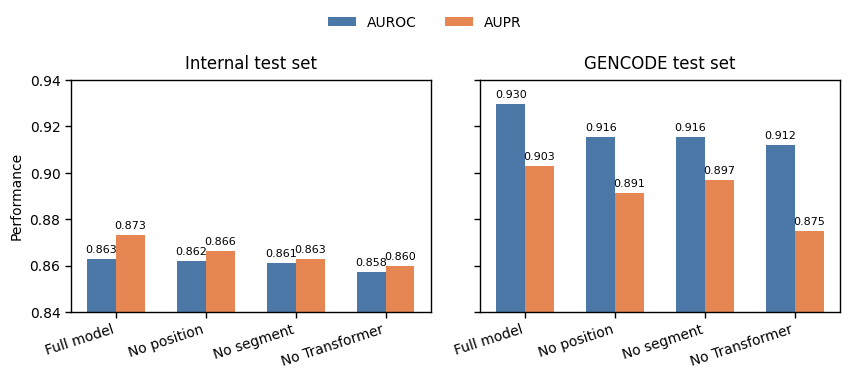

In [11]:
### visualize the architecture ablation result ###
### Architecture ablation: absolute grouped barplot ###
import pandas as pd,numpy as np,glob,re,os,matplotlib.pyplot as plt
plt.rcParams.update({"font.family":"DejaVu Sans","font.size":10,"pdf.fonttype":42,"ps.fonttype":42})

ARCH="/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage1_ep_architecture_ablation_kbs"
REG="/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/ablation_stage1_enhanced_position_roc_ws9_nrun10_test"
EXT="/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage1_ep_architecture_ablation_gencode/external_ablation_ensemble.csv"
OUT="/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage1_ep_architecture_ablation_fig"
os.makedirs(OUT,exist_ok=True)

def pm(v):
    a=re.findall(r"\d+\.\d+|\d+",str(v))
    return float(a[0]),float(a[1]) if len(a)>1 else np.nan

# internal ablation
for f in glob.glob(ARCH+"/**/*.csv",recursive=True):
    try:
        x=pd.read_csv(f)
        if {"variant","metric"}.issubset(x.columns): break
    except: pass

if {"mean","std"}.issubset(x.columns):
    x["mean"]=pd.to_numeric(x["mean"])
else:
    c=[c for c in x.columns if "mean" in c.lower()][0]
    x["mean"]=x[c].apply(lambda v:pm(v)[0])

p=x.pivot(index="variant",columns="metric",values="mean")

# full internal model
for f in glob.glob(REG+"/**/*.csv",recursive=True):
    try:
        q=pd.read_csv(f)
        if "condition" in q.columns and (q.condition.astype(str)=="full_model").any():
            r=q[q.condition.astype(str)=="full_model"].iloc[0];break
    except: pass

auc=pm(r["roc_auc"])[0]
ap=pm(r["average_precision"])[0]

keep=["full","no_position","no_segment","no_transformer"]
names={"full":"Full model","no_position":"No position","no_segment":"No segment","no_transformer":"No Transformer"}

I=pd.DataFrame(
    [["full",auc,ap]]+
    [[v,p.loc[v,"roc_auc"],p.loc[v,"average_precision"]] for v in keep[1:]],
    columns=["variant","AUROC","AUPR"]
)

E=pd.read_csv(EXT)
E=E[E.variant.isin(keep)].rename(columns={"roc_auc":"AUROC","average_precision":"AUPR"})

I["Model"]=I.variant.map(names)
E["Model"]=E.variant.map(names)
I=I.set_index("variant").loc[keep].reset_index()
E=E.set_index("variant").loc[keep].reset_index()

display(I)
display(E)

# plot
blue,orange="#4C78A8","#E68653"
fig,axs=plt.subplots(1,2,figsize=(8.6,3.7),sharey=True)
w=.32
ymin=np.floor((min(I.AUROC.min(),I.AUPR.min(),E.AUROC.min(),E.AUPR.min())-.01)*100)/100
ymax=np.ceil((max(I.AUROC.max(),I.AUPR.max(),E.AUROC.max(),E.AUPR.max())+.005)*100)/100

def barplot(ax,d,title):
    x=np.arange(len(d))
    b1=ax.bar(x-w/2,d.AUROC,w,color=blue,label="AUROC")
    b2=ax.bar(x+w/2,d.AUPR,w,color=orange,label="AUPR")
    ax.set_xticks(x,d.Model,rotation=18,ha="right")
    ax.set_ylim(ymin,ymax)
    ax.set_title(title,pad=8)
    ax.set_ylabel("Performance")
    ax.tick_params(direction="out",length=4,width=1)
    ax.grid(False)
    for s in ax.spines.values():
        s.set_visible(True);s.set_linewidth(1)
    ax.bar_label(b1,fmt="%.3f",padding=3,fontsize=8)
    ax.bar_label(b2,fmt="%.3f",padding=3,fontsize=8)

barplot(axs[0],I,"Internal test set")
barplot(axs[1],E,"GENCODE test set")
axs[1].set_ylabel("")

handles,labels=axs[0].get_legend_handles_labels()
fig.legend(handles,labels,ncol=2,frameon=False,loc="upper center",bbox_to_anchor=(0.5,1.03))

plt.tight_layout(rect=[0,0,1,.93])
plt.savefig(f"{OUT}/architecture_ablation_absolute_barplot.pdf",bbox_inches="tight")
plt.savefig(f"{OUT}/architecture_ablation_absolute_barplot.png",dpi=300,bbox_inches="tight")
plt.show()

In [ ]:
### identify the -50nt motif and structural differnet between pos and neg

In [ ]:
import pandas as pd

f="/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only/translation_strict_lenmatched_run00.pkl"
df=pd.read_pickle(f)

print(df.shape)
print(df.columns.tolist())
print(df[["sample_id","binary_label","label_raw"]].head())
print(df.head(n=5))

In [3]:
import pandas as pd, os, re

f="/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only/translation_strict_lenmatched_run00.pkl"
out_dir="/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/module1_rna_structure/run00"
os.makedirs(out_dir,exist_ok=True)

df=pd.read_pickle(f).copy()

def clean_seq(x):
    x=str(x).upper().replace("T","U")
    return re.sub(r"[^ACGU]","N",x)

df["up_seq"]=df["upstream_seq_50nt"].fillna("").map(clean_seq)
df["orf_seq_clean"]=df["orf_seq"].fillna("").map(clean_seq)

# 固定取 AUG 上游120 nt + ORF前30 nt
df["rnafold_seq"]=df["up_seq"].str[-120:] + df["orf_seq_clean"].str[:30]
df["rnafold_len"]=df["rnafold_seq"].str.len()
df["up120_len"]=df["up_seq"].str[-120:].str.len()
df["orf30_len"]=df["orf_seq_clean"].str[:30].str.len()

print("Total:",len(df))
print("\nRNAfold length:")
print(df["rnafold_len"].value_counts().sort_index())

print("\nPositive / negative:")
print(df["binary_label"].value_counts())

print("\nORF start codons:")
print(df.groupby("binary_label")["orf_seq_clean"].apply(lambda x:x.str[:3].value_counts().head(10)))

print("\nSequences containing N:")
print(df["rnafold_seq"].str.contains("N").value_counts())

# 只保留完整150 nt且没有N的样本
fold=df[(df["rnafold_len"]==150)&(~df["rnafold_seq"].str.contains("N"))].copy()

print("\nAfter QC:",len(fold))
print(fold["binary_label"].value_counts())

cols=["sample_id","label_raw","binary_label","protein_accession",
      "transcript_accession","rnafold_seq"]
fold[cols].to_csv(f"{out_dir}/run00_rnafold_120up_30orf.csv",index=False)

# 分别输出 positive / negative FASTA
for label,name in [(1,"positive"),(0,"negative")]:
    sub=fold[fold["binary_label"]==label]
    with open(f"{out_dir}/run00_{name}_120up_30orf.fa","w") as fw:
        for _,r in sub.iterrows():
            fw.write(f">{r['sample_id']}\n{r['rnafold_seq']}\n")

print("\nSaved:")
print(f"{out_dir}/run00_rnafold_120up_30orf.csv")
print(f"{out_dir}/run00_positive_120up_30orf.fa")
print(f"{out_dir}/run00_negative_120up_30orf.fa")

Total: 19158

RNAfold length:
rnafold_len
30        43
31         4
32        11
33        11
34        12
       ...  
146       38
147       41
148       30
149       46
150    15451
Name: count, Length: 121, dtype: int64

Positive / negative:
binary_label
0    9579
1    9579
Name: count, dtype: int64

ORF start codons:
binary_label  0  
0             AUG    9579
1             AUG    9579
Name: orf_seq_clean, dtype: int64

Sequences containing N:
rnafold_seq
False    19158
Name: count, dtype: int64

After QC: 15451
binary_label
0    7752
1    7699
Name: count, dtype: int64

Saved:
/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/module1_rna_structure/run00/run00_rnafold_120up_30orf.csv
/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/module1_rna_structure/run00/run00_positive_120up_30orf.fa
/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/module1_rna_structure/run00/run00_negative_120up_30orf.fa


In [ ]:
### execute in shell ###
DIR=/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/module1_rna_structure/run00

RNAfold --noPS --temp=37 \
  $DIR/run00_positive_120up_30orf.fa \
  > $DIR/run00_positive_120up_30orf_rnafold.txt

RNAfold -j8 --noPS --temp=37 \
  $DIR/run00_negative_120up_30orf.fa \
  > $DIR/run00_negative_120up_30orf_rnafold.txt


In [ ]:
## para version ##
DIR=/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/module1_rna_structure/run00
TMP=$DIR/tmp_fold

rm -rf $TMP
mkdir -p $TMP

split -l 250 -d -a 3 \
$DIR/run00_positive_120up_30orf.fa \
$TMP/positive_

split -l 250 -d -a 3 \
$DIR/run00_negative_120up_30orf.fa \
$TMP/negative_

find $TMP -type f ! -name '*.out' | sort | \
xargs -I{} -P 64 bash -c \
'RNAfold --noPS < "$1" > "$1.out"' _ {}

for f in $TMP/positive_[0-9][0-9][0-9]; do
    cat "$f.out"
done > $DIR/run00_positive_120up_30orf_rnafold.txt

for f in $TMP/negative_[0-9][0-9][0-9]; do
    cat "$f.out"
done > $DIR/run00_negative_120up_30orf_rnafold.txt

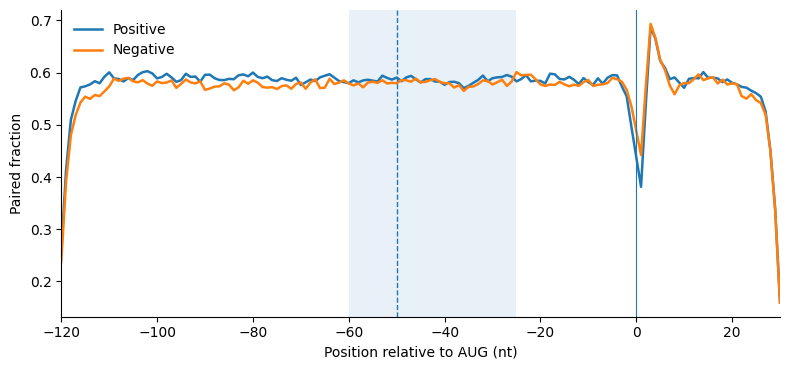

Positive n = 7699  Negative n = 7752
-50 nt paired fraction: positive=0.5906, negative=0.5796, Δ=0.0110
-60 to -25 nt: positive=0.5855, negative=0.5807, Δ=0.0048
Mann-Whitney P = 0.00358
Saved: /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/module1_rna_structure/run00/rna_structure_paired_fraction.pdf


In [33]:
import re,numpy as np,pandas as pd,matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
pos_file="/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/module1_rna_structure/run00/run00_positive_120up_30orf_rnafold.txt"
neg_file="/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/module1_rna_structure/run00/run00_negative_120up_30orf_rnafold.txt"

OUT="/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/module1_rna_structure/run00"
os.makedirs(OUT,exist_ok=True)

def read_fold(f):
    x=[]
    pat=re.compile(r"^([().]+)\s+\(\s*([-+0-9.]+)\s*\)$")
    with open(f) as h:
        while True:
            head=h.readline()
            if not head: break
            seq=h.readline().strip()
            line=h.readline().strip()
            m=pat.match(line)
            if m:x.append([head.strip()[1:],seq,m.group(1),float(m.group(2))])
    return pd.DataFrame(x,columns=["id","seq","structure","mfe"])

pos,neg=read_fold(pos_file),read_fold(neg_file)
coords=np.r_[np.arange(-120,0),np.arange(1,31)]
pm=lambda df:np.array([[c!="." for c in s] for s in df.structure],dtype=float)
P,N=pm(pos),pm(neg)
pmean,nmean=P.mean(0),N.mean(0)

plt.figure(figsize=(8,3.8))
plt.plot(coords,pmean,label="Positive",lw=1.8)
plt.plot(coords,nmean,label="Negative",lw=1.8)
plt.axvline(-50,ls="--",lw=1)
plt.axvspan(-60,-25,alpha=.10)
plt.axvline(0,lw=.8)
plt.xlabel("Position relative to AUG (nt)")
plt.ylabel("Paired fraction")
plt.xlim(-120,30)
plt.legend(frameon=False)
plt.grid(False)
plt.gca().spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{OUT}/rna_structure_paired_fraction.pdf",bbox_inches="tight")
plt.show()

i50=np.where(coords==-50)[0][0]
region=np.where((coords>=-60)&(coords<=-25))[0]
p_region=P[:,region].mean(1)
n_region=N[:,region].mean(1)
stat,p=mannwhitneyu(p_region,n_region,alternative="two-sided")

print("Positive n =",len(pos)," Negative n =",len(neg))
print(f"-50 nt paired fraction: positive={pmean[i50]:.4f}, negative={nmean[i50]:.4f}, Δ={pmean[i50]-nmean[i50]:.4f}")
print(f"-60 to -25 nt: positive={p_region.mean():.4f}, negative={n_region.mean():.4f}, Δ={p_region.mean()-n_region.mean():.4f}")
print(f"Mann-Whitney P = {p:.3g}")
print("Saved:",f"{OUT}/rna_structure_paired_fraction.pdf")

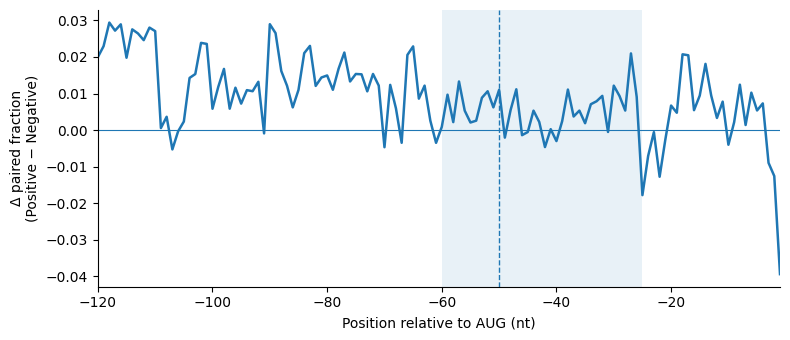

    position  delta_paired
1       -118      0.029412
2        -90      0.028971
3       -116      0.028934
4       -111      0.028042
5       -114      0.027554
6       -117      0.027209
7       -110      0.027068
8        -89      0.026522
9       -113      0.026436
10      -112      0.024603
11      -102      0.023858
12      -101      0.023571
13       -83      0.023030
14      -119      0.022951
0         -1     -0.039439


In [ ]:
delta=pmean-nmean

plt.figure(figsize=(8,3.5))
plt.plot(coords[coords<0],delta[coords<0],lw=1.8)
plt.axhline(0,lw=.8)
plt.axvline(-50,ls="--",lw=1)
plt.axvspan(-60,-25,alpha=.10)
plt.xlabel("Position relative to AUG (nt)")
plt.ylabel("Δ paired fraction\n(Positive − Negative)")
plt.xlim(-120,-1)
plt.grid(False)
plt.gca().spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()

up=coords<0
d=delta[up]
c=coords[up]

idx=np.argsort(np.abs(d))[::-1][:15]
print(pd.DataFrame({
    "position":c[idx],
    "delta_paired":d[idx]
}).sort_values("delta_paired",ascending=False))

In [40]:
import RNA
import pandas as pd

def classify_element(c):
    if c.isupper(): return "Stem"
    if c=="h": return "Hairpin"
    if c=="i": return "Interior/Bulge"
    if c=="m": return "Multiloop"
    if c=="e": return "Exterior"
    return "Other"

for df in [pos,neg]:
    df["element"]=df["structure"].map(RNA.db_to_element_string)

# -50 nt = Python index 70
idx50=70

pos["structure_m50"]=pos["element"].str[idx50].map(classify_element)
neg["structure_m50"]=neg["element"].str[idx50].map(classify_element)

order=["Stem","Hairpin","Interior/Bulge","Multiloop","Exterior"]

result=pd.DataFrame({
    "Positive_n":pos["structure_m50"].value_counts().reindex(order,fill_value=0),
    "Negative_n":neg["structure_m50"].value_counts().reindex(order,fill_value=0),
    "Positive_%":pos["structure_m50"].value_counts(normalize=True).reindex(order,fill_value=0)*100,
    "Negative_%":neg["structure_m50"].value_counts(normalize=True).reindex(order,fill_value=0)*100
})

print(result.round(2))

                Positive_n  Negative_n  Positive_%  Negative_%
structure_m50                                                 
Stem                  4547        4493       59.06       57.96
Hairpin               1135        1093       14.74       14.10
Interior/Bulge        1325        1439       17.21       18.56
Multiloop              489         525        6.35        6.77
Exterior               203         202        2.64        2.61


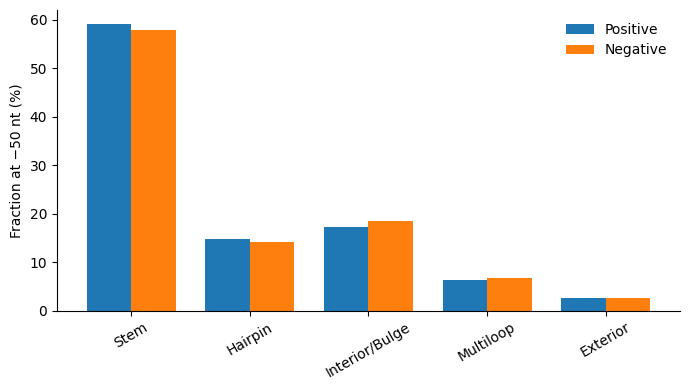

In [41]:
plot_df=result[["Positive_%","Negative_%"]]
ax=plot_df.plot(kind="bar",figsize=(7,4),width=.75)
ax.set_ylabel("Fraction at −50 nt (%)")
ax.set_xlabel("")
ax.tick_params(axis="x",rotation=30)
ax.spines[["top","right"]].set_visible(False)
ax.legend(["Positive","Negative"],frameon=False)
plt.tight_layout()
plt.savefig(f"{OUT}/rna_structure_barplot.pdf",bbox_inches="tight")
plt.show()



In [42]:
import numpy as np,pandas as pd
from scipy.stats import mannwhitneyu

# -60 ~ -25，对应 index 60:96
start,end=60,96
classes=["Stem","Hairpin","Interior/Bulge","Multiloop","Exterior"]

def classify_region(row):
    struct=row["structure"][start:end]
    elem=row["element"][start:end]
    out=[]
    for s,e in zip(struct,elem):
        if s!=".":
            out.append("Stem")
        elif e=="h":
            out.append("Hairpin")
        elif e=="i":
            out.append("Interior/Bulge")
        elif e=="m":
            out.append("Multiloop")
        elif e=="e":
            out.append("Exterior")
        else:
            out.append("Other")
    return out

def region_fraction(df):
    types=df.apply(classify_region,axis=1)
    return pd.DataFrame({
        c:types.map(lambda x:x.count(c)/len(x)) for c in classes
    })

pos_frac=region_fraction(pos)
neg_frac=region_fraction(neg)

rows=[]
for c in classes:
    stat,p=mannwhitneyu(pos_frac[c],neg_frac[c],alternative="two-sided")
    rows.append([
        c,
        pos_frac[c].mean()*100,
        neg_frac[c].mean()*100,
        (pos_frac[c].mean()-neg_frac[c].mean())*100,
        p
    ])

region_result=pd.DataFrame(
    rows,
    columns=["Structure","Positive_%","Negative_%","Delta_%","P"]
)

print(region_result.round({
    "Positive_%":2,
    "Negative_%":2,
    "Delta_%":2,
    "P":4
}))

        Structure  Positive_%  Negative_%  Delta_%       P
0            Stem       58.55       58.07     0.48  0.0036
1         Hairpin       14.75       14.75    -0.00  0.5709
2  Interior/Bulge       17.78       18.00    -0.22  0.4581
3       Multiloop        6.34        6.55    -0.21  0.6952
4        Exterior        2.58        2.63    -0.05  0.5802


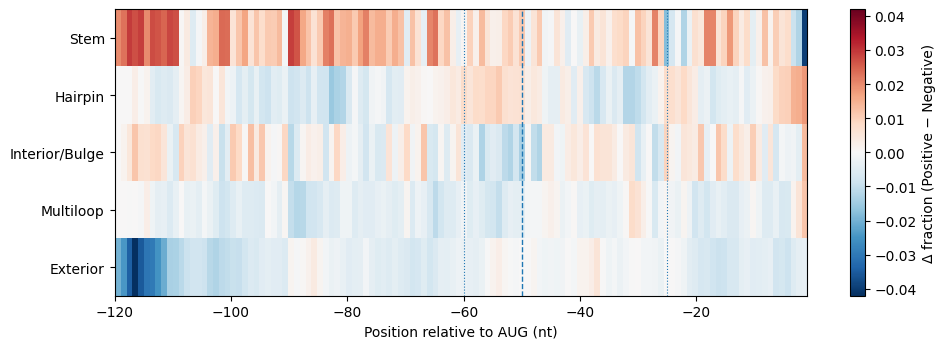

Saved: /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/module1_rna_structure/run00/rna_structure_heatmap.pdf


In [44]:
import numpy as np,pandas as pd,matplotlib.pyplot as plt

classes=["Stem","Hairpin","Interior/Bulge","Multiloop","Exterior"]
coords=np.r_[np.arange(-120,0),np.arange(1,31)]

def element_matrix(df):
    out={c:np.zeros((len(df),150),dtype=float) for c in classes}
    for r,(struct,elem) in enumerate(zip(df["structure"],df["element"])):
        for i,(s,e) in enumerate(zip(struct,elem)):
            if s!=".": c="Stem"
            elif e=="h": c="Hairpin"
            elif e=="i": c="Interior/Bulge"
            elif e=="m": c="Multiloop"
            elif e=="e": c="Exterior"
            else: continue
            out[c][r,i]=1
    return out

PM=element_matrix(pos)
NM=element_matrix(neg)

delta=np.array([
    PM[c].mean(0)-NM[c].mean(0)
    for c in classes
])

# 先只看 upstream −120~-1
mask=coords<0
x=coords[mask]
D=delta[:,mask]

plt.figure(figsize=(10,3.6))
im=plt.imshow(
    D,aspect="auto",interpolation="nearest",
    extent=[x[0],x[-1],len(classes)-0.5,-0.5],
    vmin=-np.abs(D).max(),vmax=np.abs(D).max(),
    cmap="RdBu_r"
)
plt.yticks(range(len(classes)),classes)
plt.axvline(-50,ls="--",lw=1)
plt.axvline(-60,ls=":",lw=.8)
plt.axvline(-25,ls=":",lw=.8)
plt.xlabel("Position relative to AUG (nt)")
plt.colorbar(im,label="Δ fraction (Positive − Negative)")
plt.tight_layout()
plt.savefig(f"{OUT}/rna_structure_heatmap.pdf",bbox_inches="tight")
plt.show()

print("Saved:",f"{OUT}/rna_structure_heatmap.pdf")

In [ ]:
####结构的结果中没有看到差异####

In [ ]:
###use streme for identifying motif###

In [10]:
#generate input file for streme#
import pandas as pd,os,re
f="/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only/translation_strict_lenmatched_run00.pkl"
out="/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/module1_motif/run00/input"
os.makedirs(out,exist_ok=True)
df=pd.read_pickle(f).copy()

def clean(x):
    return re.sub(r"[^ACGU]","N",str(x).upper().replace("T","U"))

df["up"]=df["upstream_seq_50nt"].fillna("").map(clean)
df["orf"]=df["orf_seq"].fillna("").map(clean)

# 为保证所有区域公平比较，只保留至少120 nt upstream且无N的样本
df=df[(df["up"].str.len()>=120)&(~df["up"].str[-120:].str.contains("N"))].copy()

# upstream[-120:] 中：index0=-120，index119=-1
regions={
    "m120_m91":(0,30),     # -120~-91
    "m90_m61":(30,60),     # -90~-61
    "m60_m31":(60,90),     # -60~-31
    "m30_m1":(90,120),     # -30~-1
    "m60_m25":(60,96)      # 主分析区 -60~-25，共36 nt
}

for name,(s,e) in regions.items():
    df[name]=df["up"].str[-120:].str[s:e]
    for label,group in [(1,"positive"),(0,"negative")]:
        sub=df[df["binary_label"]==label]
        with open(f"{out}/run00_{group}_{name}.fa","w") as fw:
            for _,r in sub.iterrows():
                fw.write(f">{r['sample_id']}\n{r[name]}\n")

print("Samples:")
print(df["binary_label"].value_counts())
print("\nSequence lengths:")
for name in regions:
    print(name,sorted(df[name].str.len().unique()))

Samples:
binary_label
0    7752
1    7699
Name: count, dtype: int64

Sequence lengths:
m120_m91 [np.int64(30)]
m90_m61 [np.int64(30)]
m60_m31 [np.int64(30)]
m30_m1 [np.int64(30)]
m60_m25 [np.int64(36)]


In [ ]:
IN=/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/module1_motif/run00/input
OUT=/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/module1_motif/run00/streme_m60_m25

streme \
  --p $IN/run00_positive_m60_m25.fa \
  --n $IN/run00_negative_m60_m25.fa \
  --rna \
  --objfun de \
  --minw 5 \
  --maxw 10 \
  --order 2 \
  --seed 42 \
  --oc $OUT

column -t -s $'\t' $OUT/streme.txt | head -20
column -t -s $'\t' $OUT/sequences.tsv | head -30

In [15]:
### multi region ###
import pandas as pd,os,re
BASE="/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/module1_motif_10runs"
PKL="/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only/translation_strict_lenmatched_run{:02d}.pkl"
regions={"m120_m85":(0,36),"m96_m61":(24,60),"m60_m25":(60,96),"m36_m1":(84,120),"m24_m1":(96,120)}
def clean(s): return re.sub("[^ACGU]","N",str(s).upper().replace("T","U"))
for run in range(10):
    df=pd.read_pickle(PKL.format(run))
    df["up"]=df["upstream_seq_50nt"].map(clean)
    df=df[(df["up"].str.len()>=120)&(~df["up"].str[-120:].str.contains("N"))].copy()
    df["up120"]=df["up"].str[-120:]
    out=f"{BASE}/run{run:02d}/input"; os.makedirs(out,exist_ok=True)
    for region,(a,b) in regions.items():
        df["seq"]=df["up120"].str[a:b]
        for lab,name in [(1,"positive"),(0,"negative")]:
            x=df[df["binary_label"]==lab]
            with open(f"{out}/run{run:02d}_{name}_{region}.fa","w") as f:
                for _,r in x.iterrows(): f.write(f">{r['sample_id']}\n{r['seq']}\n")
    print(f"run{run:02d}: positive={(df.binary_label==1).sum()}, negative={(df.binary_label==0).sum()}")

run00: positive=7699, negative=7752
run01: positive=7699, negative=7743
run02: positive=7699, negative=7755
run03: positive=7699, negative=7757
run04: positive=7699, negative=7765
run05: positive=7699, negative=7740
run06: positive=7699, negative=7730
run07: positive=7699, negative=7742
run08: positive=7699, negative=7745
run09: positive=7699, negative=7748


In [ ]:
IN=/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/module1_motif_10runs/run00/input
BASE=/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/module1_motif_10runs/run00


# −24 ~ −1
OUT=$BASE/streme_m24_m1

streme \
  --p $IN/run00_positive_m24_m1.fa \
  --n $IN/run00_negative_m24_m1.fa \
  --rna \
  --objfun de \
  --minw 5 \
  --maxw 10 \
  --order 2 \
  --seed 42 \
  --oc $OUT

echo "===== -24~-1 ====="
grep '^MOTIF' $OUT/streme.txt
head -30 $OUT/sequences.tsv

# −120 ~ −85
OUT=$BASE/streme_m120_m85

streme \
  --p $IN/run00_positive_m120_m85.fa \
  --n $IN/run00_negative_m120_m85.fa \
  --rna \
  --objfun de \
  --minw 5 \
  --maxw 10 \
  --order 2 \
  --seed 42 \
  --oc $OUT

echo "===== -120~-85 ====="
grep '^MOTIF' $OUT/streme.txt
head -30 $OUT/sequences.tsv


# −96 ~ −61
OUT=$BASE/streme_m96_m61

streme \
  --p $IN/run00_positive_m96_m61.fa \
  --n $IN/run00_negative_m96_m61.fa \
  --rna \
  --objfun de \
  --minw 5 \
  --maxw 10 \
  --order 2 \
  --seed 42 \
  --oc $OUT

echo "===== -96~-61 ====="
grep '^MOTIF' $OUT/streme.txt
head -30 $OUT/sequences.tsv


# −36 ~ −1
OUT=$BASE/streme_m36_m1

streme \
  --p $IN/run00_positive_m36_m1.fa \
  --n $IN/run00_negative_m36_m1.fa \
  --rna \
  --objfun de \
  --minw 5 \
  --maxw 10 \
  --order 2 \
  --seed 42 \
  --oc $OUT

echo "===== -36~-1 ====="
grep '^MOTIF' $OUT/streme.txt
head -30 $OUT/sequences.tsv


######## m120_m85 ########
run00


FileNotFoundError: [Errno 2] No such file or directory: '/disk3/hejp/soft/meme/bin/streme'

In [16]:
import re,pandas as pd,os
BASE="/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/module1_motif_10runs/run00"
regions={"m120_m85":"−120~−85","m96_m61":"−96~−61","m60_m25":"−60~−25","m36_m1":"−36~−1","m24_m1":"−24~−1"}
rows=[]
for r,pos in regions.items():
    fn=f"{BASE}/streme_{r}/streme.txt"
    txt=open(fn).read()
    pat=r"MOTIF\s+(\d+)-(\S+)\s+STREME-\d+\nletter-probability matrix:.*?w=\s*(\d+)\s+nsites=\s*(\d+)\s+E=\s*([0-9.eE+-]+)"
    for no,cons,w,n,e in re.findall(pat,txt):
        rows.append([pos,r,int(no),cons,int(w),int(n),float(e),float(e)<=0.05])
res=pd.DataFrame(rows,columns=["region","region_id","motif_no","consensus","width","nsites","E_value","significant"])
display(res)

sig=res[res["significant"]].copy()
display(sig.sort_values(["region_id","E_value"]))

,region,region_id,motif_no,consensus,width,nsites,E_value,significant
0,−120~−85,m120_m85,1,SGCSGCGSS,9,1973,2.200000e-16,True
1,−120~−85,m120_m85,2,VSCGG,5,3999,3.300000e-12,True
2,−120~−85,m120_m85,3,CGGAA,5,136,1.800000e-01,False
3,−120~−85,m120_m85,4,GCGCC,5,43,2.000000e+00,False
4,−120~−85,m120_m85,5,GRKCG,5,45,3.000000e+00,False
5,−120~−85,m120_m85,6,AACCCACAA,9,27,5.200000e+00,False
6,−96~−61,m96_m61,1,CGCGSCSG,8,2008,7.700000e-17,True
7,−96~−61,m96_m61,2,CGCCG,5,3508,2.600000e-03,True
8,−96~−61,m96_m61,3,CGGDS,5,231,5.100000e-02,False
9,−96~−61,m96_m61,4,CGGAA,5,162,1.100000e-01,False


,region,region_id,motif_no,consensus,width,nsites,E_value,significant
0,−120~−85,m120_m85,1,SGCSGCGSS,9,1973,2.200000e-16,True
1,−120~−85,m120_m85,2,VSCGG,5,3999,3.300000e-12,True
25,−24~−1,m24_m1,1,SCGCG,5,2908,2.400000e-08,True
26,−24~−1,m24_m1,2,CCURA,5,2104,2.700000e-06,True
19,−36~−1,m36_m1,1,CCGCCGCSG,9,1328,4.000000e-13,True
20,−36~−1,m36_m1,2,CCUGA,5,4079,5.000000e-06,True
21,−36~−1,m36_m1,3,GCGCG,5,1821,1.600000e-02,True
13,−60~−25,m60_m25,1,CCGCCGCSG,9,1515,6.400000e-15,True
14,−60~−25,m60_m25,2,CCGGH,5,3580,4.800000e-06,True
15,−60~−25,m60_m25,3,CUGMG,5,961,4.600000e-02,True


In [17]:
for r,pos in regions.items():
    x=sig[sig["region_id"]==r]
    print(f"\n===== {pos} =====")
    if len(x)==0:
        print("No significant motif")
    else:
        for _,z in x.iterrows():
            print(f"M{z.motif_no}: {z.consensus:12s}  E={z.E_value:.2e}  nsites={z.nsites}")


===== −120~−85 =====
M1: SGCSGCGSS     E=2.20e-16  nsites=1973
M2: VSCGG         E=3.30e-12  nsites=3999

===== −96~−61 =====
M1: CGCGSCSG      E=7.70e-17  nsites=2008
M2: CGCCG         E=2.60e-03  nsites=3508

===== −60~−25 =====
M1: CCGCCGCSG     E=6.40e-15  nsites=1515
M2: CCGGH         E=4.80e-06  nsites=3580
M3: CUGMG         E=4.60e-02  nsites=961

===== −36~−1 =====
M1: CCGCCGCSG     E=4.00e-13  nsites=1328
M2: CCUGA         E=5.00e-06  nsites=4079
M3: GCGCG         E=1.60e-02  nsites=1821

===== −24~−1 =====
M1: SCGCG         E=2.40e-08  nsites=2908
M2: CCURA         E=2.70e-06  nsites=2104


,Region,Rank,Motif,E-value,Sites
0,−120 to −85,1,SGCSGCGSS,2.200000e-16,1973
1,−120 to −85,2,VSCGG,3.300000e-12,3999
2,−120 to −85,3,CGGAA,1.800000e-01,136
3,−120 to −85,4,GCGCC,2.000000e+00,43
4,−120 to −85,5,GRKCG,3.000000e+00,45
5,−120 to −85,6,AACCCACAA,5.200000e+00,27
6,−96 to −61,1,CGCGSCSG,7.700000e-17,2008
7,−96 to −61,2,CGCCG,2.600000e-03,3508
8,−96 to −61,3,CGGDS,5.100000e-02,231
9,−96 to −61,4,CGGAA,1.100000e-01,162


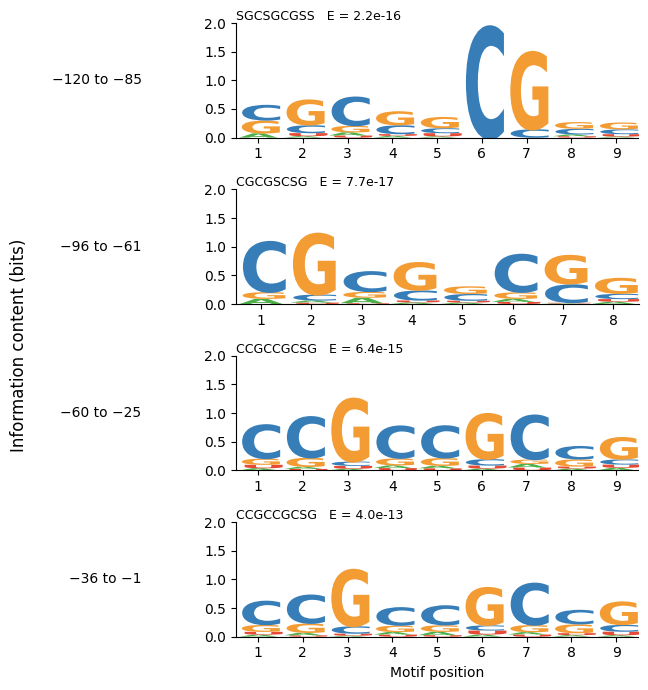

In [19]:
### Module I motif visualization without logomaker ###
import os,re,numpy as np,pandas as pd,matplotlib.pyplot as plt
from matplotlib.textpath import TextPath
from matplotlib.patches import PathPatch
from matplotlib.transforms import Affine2D
from matplotlib.font_manager import FontProperties

plt.rcParams.update({"font.family":"DejaVu Sans","font.size":10,"pdf.fonttype":42,"ps.fonttype":42})

BASE="/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/module1_motif_10runs/run00"
OUT=BASE+"/motif_figure";os.makedirs(OUT,exist_ok=True)

wins={
"streme_m120_m85":"−120 to −85",
"streme_m96_m61":"−96 to −61",
"streme_m60_m25":"−60 to −25",
"streme_m36_m1":"−36 to −1",
"streme_m24_m1":"−24 to −1"
}

def read_streme(f):
    s=open(f).read().splitlines();out=[]
    for i,x in enumerate(s):
        if not x.startswith("MOTIF "): continue
        name=x.split()[1];cons=name.split("-",1)[-1]
        j=i+1
        while j<len(s) and "letter-probability matrix" not in s[j]: j+=1
        if j==len(s): continue
        h=s[j];w=int(re.search(r"w=\s*(\d+)",h).group(1))
        E=float(re.search(r"E=\s*([\deE.+-]+)",h).group(1))
        n=int(re.search(r"nsites=\s*(\d+)",h).group(1))
        pwm=pd.DataFrame([[float(v) for v in s[j+1+k].split()] for k in range(w)],columns=list("ACGU"))
        out.append({"motif":cons,"E":E,"nsites":n,"pwm":pwm})
    return out

def info_matrix(pwm):
    p=pwm.clip(1e-9,1)
    H=-(p*np.log2(p)).sum(axis=1)
    R=2-H
    return p.mul(R,axis=0)

colors={"A":"#4DAF4A","C":"#377EB8","G":"#F39C34","U":"#E64B35"}
fp=FontProperties(family="DejaVu Sans",weight="bold")

def draw_logo(ax,mat):
    for x,row in mat.iterrows():
        y=0
        for base,h in sorted(row.items(),key=lambda z:z[1]):
            if h<=0: continue
            tp=TextPath((0,0),base,size=1,prop=fp)
            bb=tp.get_extents()
            trans=Affine2D().scale(.85/bb.width,h/bb.height).translate(x+.075,y)
            ax.add_patch(PathPatch(tp,transform=trans+ax.transData,color=colors[base],lw=0))
            y+=h
    ax.set_xlim(0,len(mat));ax.set_ylim(0,2)
    ax.set_xticks(np.arange(len(mat))+.5,np.arange(1,len(mat)+1))
    ax.spines[["top","right"]].set_visible(False)

R={}
for folder,label in wins.items():
    f=f"{BASE}/{folder}/streme.txt"
    if os.path.exists(f): R[folder]=read_streme(f)
    else: print("Missing:",f)

# summary
summary=[]
for folder,label in wins.items():
    for rank,m in enumerate(sorted(R.get(folder,[]),key=lambda x:x["E"]),1):
        summary.append([label,rank,m["motif"],m["E"],m["nsites"]])
summary=pd.DataFrame(summary,columns=["Region","Rank","Motif","E-value","Sites"])
display(summary)
summary.to_csv(f"{OUT}/run00_motif_summary.csv",index=False)

# top motif from each region
fig,axs=plt.subplots(4,1,figsize=(6.5,7))
for ax,(folder,label) in zip(axs,wins.items()):
    m=sorted(R[folder],key=lambda x:x["E"])[0]
    draw_logo(ax,info_matrix(m["pwm"]))
    ax.set_ylabel(label,rotation=0,ha="right",va="center",labelpad=45)
    ax.set_title(f'{m["motif"]}   E = {m["E"]:.1e}',loc="left",fontsize=9,pad=2)
axs[-1].set_xlabel("Motif position")
fig.supylabel("Information content (bits)",x=.01)
plt.tight_layout()
plt.savefig(f"{OUT}/run00_top_motifs.pdf",bbox_inches="tight")
plt.savefig(f"{OUT}/run00_top_motifs.png",dpi=300,bbox_inches="tight")
plt.show()

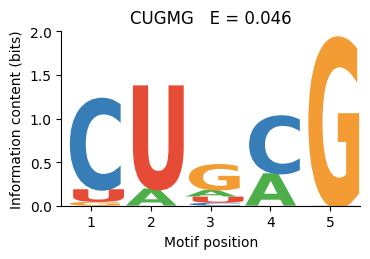

In [2]:
m=[x for x in R["streme_m60_m25"] if x["motif"]=="CUGMG"][0]

fig,ax=plt.subplots(figsize=(3.8,2.7))
draw_logo(ax,info_matrix(m["pwm"]))
ax.set_xlabel("Motif position")
ax.set_ylabel("Information content (bits)")
ax.set_title(f'CUGMG   E = {m["E"]:.2g}')
plt.tight_layout()
plt.savefig(f"{OUT}/run00_CUGMG_m60_m25.pdf",bbox_inches="tight")
plt.savefig(f"{OUT}/run00_CUGMG_m60_m25.png",dpi=300,bbox_inches="tight")
plt.show()

In [3]:
ls /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/module1_motif_10runs/run00/streme_m60_m25

sequences.tsv  sites.tsv  streme.html  streme.txt  streme.xml


In [20]:
BASE=/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/module1_motif_10runs/run00
OUT=$BASE/official_logos
mkdir -p $OUT

for R in m120_m85 m96_m61 m60_m25 m36_m1 m24_m1
do
  mkdir -p $OUT/$R
  meme2images -eps $BASE/streme_$R/streme.txt $OUT/$R
done

find $OUT -name "*.eps"

SyntaxError: invalid decimal literal (1877277939.py, line 1)

In [ ]:
BASE=/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/module1_motif_10runs/run00/official_logos

find $BASE -name "*.eps" | while read f
do
  ps2pdf -dEPSCrop "$f" "${f%.eps}.pdf"
done

In [5]:
### validate the CUGMG ###
### CUGMG fixed-motif validation across 10 runs ###
import pandas as pd,numpy as np,re,os
from scipy.stats import fisher_exact
import matplotlib.pyplot as plt

BASE="/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/module1_motif_10runs"
OUT=BASE+"/CUGMG_validation";os.makedirs(OUT,exist_ok=True)
plt.rcParams.update({"font.family":"DejaVu Sans","font.size":10,"pdf.fonttype":42,"ps.fonttype":42})

def readfa(f):
    seq=[];s=""
    for x in open(f):
        x=x.strip()
        if x.startswith(">"):
            if s: seq.append(s.upper())
            s=""
        else:s+=x
    if s:seq.append(s.upper())
    return seq

pat=re.compile(r"CUG[AC]G")
rows=[]

for i in range(10):
    run=f"run{i:02d}"
    d=f"{BASE}/{run}/input"
    pf=f"{d}/{run}_positive_m60_m25.fa"
    nf=f"{d}/{run}_negative_m60_m25.fa"
    P,N=readfa(pf),readfa(nf)
    ph=np.array([bool(pat.search(s.replace("T","U"))) for s in P])
    nh=np.array([bool(pat.search(s.replace("T","U"))) for s in N])
    a,b=ph.sum(),len(ph)-ph.sum()
    c,dn=nh.sum(),len(nh)-nh.sum()
    OR,p=fisher_exact([[a,b],[c,dn]])
    se=np.sqrt(1/(a+.5)+1/(b+.5)+1/(c+.5)+1/(dn+.5))
    lo,hi=np.exp(np.log((a+.5)*(dn+.5)/((b+.5)*(c+.5)))+np.array([-1,1])*1.96*se)
    fp,fn=a/len(ph),c/len(nh)
    rows.append([run,len(P),len(N),a,c,fp,fn,fp/fn if fn else np.nan,OR,lo,hi,p])

R=pd.DataFrame(rows,columns=["Run","N_pos","N_neg","Hit_pos","Hit_neg","Freq_pos","Freq_neg","Fold","OR","CI_low","CI_high","P"])
R["FDR"]=np.minimum(1,R["P"].rank(method="min")/np.arange(1,len(R)+1)) # display only; below recalc BH properly

# proper BH
p=R.P.values;order=np.argsort(p);q=np.empty(len(p));q[order]=np.minimum.accumulate((p[order]*len(p)/np.arange(1,len(p)+1))[::-1])[::-1]
R["FDR"]=np.minimum(q,1)

display(R.round(4))
R.to_csv(f"{OUT}/CUGMG_m60_m25_10runs.csv",index=False)

print("Positive enrichment runs:",(R.OR>1).sum(),"/",len(R))
print("Median fold enrichment:",R.Fold.median())
print("Median odds ratio:",R.OR.median())
display(R[["Run","Freq_pos","Freq_neg","Fold","OR","CI_low","CI_high","P","FDR"]].round(4))

,Run,N_pos,N_neg,Hit_pos,Hit_neg,Freq_pos,Freq_neg,Fold,OR,CI_low,CI_high,P,FDR
0,run00,7699,7752,806,543,0.1047,0.0700,1.4946,1.5524,1.3852,1.7388,0.0,0.0
1,run01,7699,7743,806,529,0.1047,0.0683,1.5323,1.5946,1.4216,1.7874,0.0,0.0
2,run02,7699,7755,806,529,0.1047,0.0682,1.5347,1.5972,1.4240,1.7904,0.0,0.0
3,run03,7699,7757,806,533,0.1047,0.0687,1.5236,1.5848,1.4133,1.7761,0.0,0.0
4,run04,7699,7765,806,558,0.1047,0.0719,1.4568,1.5102,1.3487,1.6902,0.0,0.0
5,run05,7699,7740,806,542,0.1047,0.0700,1.4950,1.5529,1.3855,1.7394,0.0,0.0
6,run06,7699,7730,806,536,0.1047,0.0693,1.5098,1.5694,1.3997,1.7585,0.0,0.0
7,run07,7699,7742,806,522,0.1047,0.0674,1.5527,1.6173,1.4413,1.8136,0.0,0.0
8,run08,7699,7745,806,542,0.1047,0.0700,1.4960,1.5540,1.3865,1.7406,0.0,0.0
9,run09,7699,7748,806,522,0.1047,0.0674,1.5539,1.6187,1.4425,1.8151,0.0,0.0


Positive enrichment runs: 10 / 10
Median fold enrichment: 1.5166866375216066
Median odds ratio: 1.5771029192338388


,Run,Freq_pos,Freq_neg,Fold,OR,CI_low,CI_high,P,FDR
0,run00,0.1047,0.0700,1.4946,1.5524,1.3852,1.7388,0.0,0.0
1,run01,0.1047,0.0683,1.5323,1.5946,1.4216,1.7874,0.0,0.0
2,run02,0.1047,0.0682,1.5347,1.5972,1.4240,1.7904,0.0,0.0
3,run03,0.1047,0.0687,1.5236,1.5848,1.4133,1.7761,0.0,0.0
4,run04,0.1047,0.0719,1.4568,1.5102,1.3487,1.6902,0.0,0.0
5,run05,0.1047,0.0700,1.4950,1.5529,1.3855,1.7394,0.0,0.0
6,run06,0.1047,0.0693,1.5098,1.5694,1.3997,1.7585,0.0,0.0
7,run07,0.1047,0.0674,1.5527,1.6173,1.4413,1.8136,0.0,0.0
8,run08,0.1047,0.0700,1.4960,1.5540,1.3865,1.7406,0.0,0.0
9,run09,0.1047,0.0674,1.5539,1.6187,1.4425,1.8151,0.0,0.0


In [21]:
### CUGMG enrichment across four upstream regions, 10 runs ###
import os,re,numpy as np,pandas as pd
from scipy.stats import fisher_exact

BASE="/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/module1_motif_10runs"
OUT=BASE+"/CUGMG_validation";os.makedirs(OUT,exist_ok=True)

regions={
"m120_m85":"−120 to −85",
"m96_m61":"−96 to −61",
"m60_m25":"−60 to −25",
"m36_m1":"−36 to −1",
"m24_m1":"−24 to −1"
}

def readfa(f):
    seq=[];s=""
    for x in open(f):
        x=x.strip()
        if x.startswith(">"):
            if s: seq.append(s.upper().replace("T","U"))
            s=""
        else:s+=x
    if s:seq.append(s.upper().replace("T","U"))
    return seq

pat=re.compile(r"CUG[AC]G")
rows=[]

for i in range(10):
    run=f"run{i:02d}";d=f"{BASE}/{run}/input"
    for tag,region in regions.items():
        pf=f"{d}/{run}_positive_{tag}.fa"
        nf=f"{d}/{run}_negative_{tag}.fa"
        if not os.path.exists(pf) or not os.path.exists(nf):
            print("Missing:",run,tag);continue
        P,N=readfa(pf),readfa(nf)
        ph=np.array([bool(pat.search(s)) for s in P]);nh=np.array([bool(pat.search(s)) for s in N])
        a,b=ph.sum(),len(ph)-ph.sum();c,dn=nh.sum(),len(nh)-nh.sum()
        OR,p=fisher_exact([[a,b],[c,dn]])
        aa,bb,cc,dd=np.array([a,b,c,dn],float)+0.5
        se=np.sqrt(1/aa+1/bb+1/cc+1/dd)
        lo,hi=np.exp(np.log(aa*dd/(bb*cc))+np.array([-1,1])*1.96*se)
        fp,fn=a/len(P),c/len(N)
        rows.append([run,region,len(P),len(N),a,c,fp,fn,fp/fn if fn else np.nan,OR,lo,hi,p])

R4=pd.DataFrame(rows,columns=["Run","Region","N_pos","N_neg","Hit_pos","Hit_neg","Freq_pos","Freq_neg","Fold","OR","CI_low","CI_high","P"])

# BH correction across all 40 tests
p=R4.P.values;order=np.argsort(p);rank=np.arange(1,len(p)+1)
q=np.empty(len(p));q[order]=np.minimum.accumulate((p[order]*len(p)/rank)[::-1])[::-1]
R4["FDR"]=np.minimum(q,1)

# summary across 10 runs
S=R4.groupby("Region",sort=False).agg(
    Pos_freq=("Freq_pos","median"),
    Neg_freq=("Freq_neg","median"),
    Fold=("Fold","median"),
    OR=("OR","median"),
    OR_min=("OR","min"),
    OR_max=("OR","max"),
    Positive_runs=("OR",lambda x:(x>1).sum()),
    Significant_runs=("FDR",lambda x:(x<0.05).sum())
).reset_index()

R4.to_csv(f"{OUT}/CUGMG_four_regions_10runs.csv",index=False)
S.to_csv(f"{OUT}/CUGMG_four_regions_summary.csv",index=False)

show=S.copy()
for c in ["Pos_freq","Neg_freq","Fold","OR","OR_min","OR_max"]:
    show[c]=show[c].map(lambda x:f"{x:.4f}")
display(show)

# detailed table, scientific notation for P/FDR
detail=R4[["Run","Region","Freq_pos","Freq_neg","Fold","OR","CI_low","CI_high","P","FDR"]].copy()
for c in ["Freq_pos","Freq_neg","Fold","OR","CI_low","CI_high"]:
    detail[c]=detail[c].map(lambda x:f"{x:.4f}")
for c in ["P","FDR"]:
    detail[c]=detail[c].map(lambda x:f"{x:.2e}")
display(detail)

,Region,Pos_freq,Neg_freq,Fold,OR,OR_min,OR_max,Positive_runs,Significant_runs
0,−120 to −85,0.1095,0.0766,1.4293,1.4821,1.3337,1.5652,10,10
1,−96 to −61,0.1033,0.0765,1.3501,1.3904,1.3299,1.5424,10,10
2,−60 to −25,0.1047,0.0690,1.5167,1.5771,1.5102,1.6187,10,10
3,−36 to −1,0.1088,0.0714,1.5238,1.5877,1.5359,1.6896,10,10
4,−24 to −1,0.0674,0.0474,1.4214,1.4519,1.3669,1.5389,10,10


,Run,Region,Freq_pos,Freq_neg,Fold,OR,CI_low,CI_high,P,FDR
0,run00,−120 to −85,0.1095,0.0770,1.4218,1.4736,1.3199,1.6444,4.09e-12,7.58e-12
1,run00,−96 to −61,0.1033,0.0777,1.3297,1.3677,1.2238,1.5277,3.12e-08,3.82e-08
2,run00,−60 to −25,0.1047,0.0700,1.4946,1.5524,1.3852,1.7388,2.32e-14,5.53e-14
3,run00,−36 to −1,0.1088,0.0737,1.4777,1.5361,1.3738,1.7165,3.10e-14,6.87e-14
4,run00,−24 to −1,0.0674,0.0501,1.3468,1.3719,1.1978,1.5704,4.40e-06,4.49e-06
5,run01,−120 to −85,0.1095,0.0794,1.3786,1.4251,1.2776,1.5890,1.61e-10,2.50e-10
6,run01,−96 to −61,0.1033,0.0797,1.2959,1.3299,1.1909,1.4846,3.67e-07,3.98e-07
7,run01,−60 to −25,0.1047,0.0683,1.5323,1.5946,1.4216,1.7874,8.66e-16,4.33e-15
8,run01,−36 to −1,0.1088,0.0674,1.6145,1.6896,1.5068,1.8932,9.35e-20,4.67e-18
9,run01,−24 to −1,0.0674,0.0468,1.4419,1.4738,1.2833,1.6912,3.21e-08,3.82e-08


In [9]:
!which fimo
!grep '^MOTIF' /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/module1_motif_10runs/run00/streme_m60_m25/streme.txt

/usr/bin/which: no fimo in (/home/hejp/anaconda3/envs/smorf_lmm/bin:/home/hejp/.vscode-server/cli/servers/Stable-ce099c1ed25d9eb3076c11e4a280f3eb52b4fbeb/server/bin/remote-cli:/disk1/software/fastp:/disk1/software:/disk2raid1/hejp/00_thesis/proteomic.software/DIA-NN-2.1.0-Academia-Linux/diann-2.1.0:/disk2raid1/hejp/software/maxquant.depend.dotnet/dotnet:/disk1/software/sratoolkit.3.0.7-centos_linux64/bin:/disk1/pipeline/scRNAseq/cellranger/cellranger-7.1.0:/disk1/referrence/WESindex/jdk-17.0.8+7/bin:/disk1/referrence/WESindex/gatk-4.4.0.0:/disk1/software/fastp:/disk1/software:/disk2raid1/hejp/00_thesis/proteomic.software/DIA-NN-2.1.0-Academia-Linux/diann-2.1.0:/disk2raid1/hejp/software/maxquant.depend.dotnet/dotnet:/disk1/software/sratoolkit.3.0.7-centos_linux64/bin:/disk1/pipeline/scRNAseq/cellranger/cellranger-7.1.0:/disk1/referrence/WESindex/jdk-17.0.8+7/bin:/disk1/referrence/WESindex/gatk-4.4.0.0:/home/hejp/anaconda3/envs/smorf_lmm/bin:/home/hejp/anaconda3/condabin:/home/hejp/.loca

In [10]:
### inspect the real PWM of STREME-3 CUGMG ###
import re,itertools,numpy as np,pandas as pd

F="/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/module1_motif_10runs/run00/streme_m60_m25/streme.txt"

lines=open(F).read().splitlines()

# background frequencies
bg={"A":0.25,"C":0.25,"G":0.25,"U":0.25}
for i,x in enumerate(lines):
    if "Background letter frequencies" in x:
        s=" ".join(lines[i:i+3])
        for b in "ACGU":
            m=re.search(rf"{b}\s+([\d.]+)",s)
            if m: bg[b]=float(m.group(1))
        break

# STREME-3 PWM
for i,x in enumerate(lines):
    if x.startswith("MOTIF 3-CUGMG"):
        j=i+1
        while "letter-probability matrix" not in lines[j]: j+=1
        w=int(re.search(r"w=\s*(\d+)",lines[j]).group(1))
        pwm=pd.DataFrame([[float(v) for v in lines[j+1+k].split()] for k in range(w)],
                         columns=list("ACGU"))
        break

print("Background:",bg)
display(pwm.round(4))

# PWM log-odds scores
lod=np.log2(pwm/np.array([bg[b] for b in "ACGU"]))

def score(seq):
    return sum(lod.iloc[i]["ACGU".index(b)] for i,b in enumerate(seq))

all5=pd.DataFrame([(s,score(s)) for s in map("".join,itertools.product("ACGU",repeat=w))],
                  columns=["5mer","score"]).sort_values("score",ascending=False)

display(all5.head(20).reset_index(drop=True))

Background: {'A': 0.255, 'C': 0.246, 'G': 0.256, 'U': 0.243}


,A,C,G,U
0,0.0006,0.8477,0.0359,0.1158
1,0.1397,0.0005,0.0006,0.8592
2,0.1535,0.0715,0.6274,0.1477
3,0.3533,0.6456,0.0006,0.0005
4,0.0006,0.0005,0.9984,0.0005


/tmp/ipykernel_79327/2015788642.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return sum(lod.iloc[i]["ACGU".index(b)] for i,b in enumerate(seq))


,5mer,score
0,CUGCG,8.255642
1,CUGAG,7.333907
2,CUUCG,6.243798
3,CUACG,6.229914
4,CAGCG,5.565860
5,UUGCG,5.401364
6,CUUAG,5.322062
7,CUAAG,5.308178
8,CUCCG,5.179238
9,CAGAG,4.644124


In [22]:
### Fixed CUGMG PWM scan across four upstream regions ###
import os,re,numpy as np,pandas as pd
from scipy.stats import fisher_exact

BASE="/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/module1_motif_10runs"
OUT=BASE+"/CUGMG_validation";os.makedirs(OUT,exist_ok=True)

regions={"m120_m85":"−120 to −85","m96_m61":"−96 to −61","m60_m25":"−60 to −25","m36_m1":"−36 to −1","m24_m1":"−24 to −1"}
thresholds=[0.75,0.80,0.85,0.90]
lod=np.log2(pwm/np.array([bg[b] for b in "ACGU"]))
smin=lod.min(axis=1).sum();smax=lod.max(axis=1).sum()

def readfa(f):
    seq=[];s=""
    for x in open(f):
        x=x.strip()
        if x.startswith(">"):
            if s:seq.append(s.upper().replace("T","U"))
            s=""
        else:s+=x
    if s:seq.append(s.upper().replace("T","U"))
    return seq

def bestscore(s):
    scores=[]
    for i in range(len(s)-4):
        k=s[i:i+5]
        if set(k)<=set("ACGU"):
            raw=sum(lod.iloc[j]["ACGU".index(b)] for j,b in enumerate(k))
            scores.append((raw-smin)/(smax-smin))
    return max(scores) if scores else np.nan

rows=[]
for r in range(10):
    run=f"run{r:02d}";d=f"{BASE}/{run}/input"
    for tag,region in regions.items():
        P=readfa(f"{d}/{run}_positive_{tag}.fa");N=readfa(f"{d}/{run}_negative_{tag}.fa")
        ps=np.array([bestscore(s) for s in P]);ns=np.array([bestscore(s) for s in N])
        for t in thresholds:
            ph=ps>=t;nh=ns>=t
            a,b=ph.sum(),len(ph)-ph.sum();c,dn=nh.sum(),len(nh)-nh.sum()
            OR,p=fisher_exact([[a,b],[c,dn]])
            fp,fn=ph.mean(),nh.mean()
            rows.append([run,region,t,fp,fn,fp/fn if fn else np.nan,OR,p])

R=pd.DataFrame(rows,columns=["Run","Region","Threshold","Freq_pos","Freq_neg","Fold","OR","P"])

# BH within each threshold
R["FDR"]=np.nan
for t in thresholds:
    ix=R.Threshold==t;p=R.loc[ix,"P"].values;o=np.argsort(p);q=np.empty(len(p))
    q[o]=np.minimum.accumulate((p[o]*len(p)/np.arange(1,len(p)+1))[::-1])[::-1]
    R.loc[ix,"FDR"]=np.minimum(q,1)

S=R.groupby(["Threshold","Region"],sort=False).agg(
    Pos_freq=("Freq_pos","median"),
    Neg_freq=("Freq_neg","median"),
    Fold=("Fold","median"),
    OR=("OR","median"),
    OR_min=("OR","min"),
    OR_max=("OR","max"),
    Positive_runs=("OR",lambda x:(x>1).sum()),
    Significant_runs=("FDR",lambda x:(x<.05).sum())
).reset_index()

R.to_csv(f"{OUT}/CUGMG_PWM_four_regions_10runs.csv",index=False)
S.to_csv(f"{OUT}/CUGMG_PWM_four_regions_summary.csv",index=False)

display(S.round(4))

/tmp/ipykernel_79327/1636012956.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  raw=sum(lod.iloc[j]["ACGU".index(b)] for j,b in enumerate(k))


KeyboardInterrupt: 

In [23]:
### quicker version ###
### Fast fixed CUGMG PWM scan across four regions ###
import os,itertools,numpy as np,pandas as pd
from scipy.stats import fisher_exact

BASE="/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/module1_motif_10runs"
OUT=BASE+"/CUGMG_validation";os.makedirs(OUT,exist_ok=True)
regions={"m120_m85":"−120 to −85","m96_m61":"−96 to −61","m60_m25":"−60 to −25","m36_m1":"−36 to −1","m24_m1":"−24 to −1"}
thresholds=[0.75,0.80,0.85,0.90]

# PWM -> normalized score lookup for all 1024 possible 5-mers
bases="ACGU"
lod=np.log2(pwm.values/np.array([bg[b] for b in bases]))
smin=lod.min(1).sum();smax=lod.max(1).sum()
score5={}
for k in map("".join,itertools.product(bases,repeat=5)):
    raw=sum(lod[i,bases.index(b)] for i,b in enumerate(k))
    score5[k]=(raw-smin)/(smax-smin)

def readfa(f):
    seq=[];s=""
    for x in open(f):
        x=x.strip()
        if x.startswith(">"):
            if s:seq.append(s.upper().replace("T","U"))
            s=""
        else:s+=x
    if s:seq.append(s.upper().replace("T","U"))
    return seq

def best_scores(seqs):
    return np.array([max(score5.get(s[i:i+5],-np.inf) for i in range(len(s)-4)) for s in seqs])

rows=[]
for r in range(10):
    run=f"run{r:02d}";d=f"{BASE}/{run}/input"
    print(run,end=" ")
    for tag,region in regions.items():
        P=readfa(f"{d}/{run}_positive_{tag}.fa")
        N=readfa(f"{d}/{run}_negative_{tag}.fa")
        ps,ns=best_scores(P),best_scores(N)

        for t in thresholds:
            ph,nh=ps>=t,ns>=t
            a,c=ph.sum(),nh.sum();b=len(P)-a;dn=len(N)-c
            OR,p=fisher_exact([[a,b],[c,dn]])
            fp,fn=ph.mean(),nh.mean()
            rows.append([run,region,t,fp,fn,fp/fn if fn else np.nan,OR,p])
    print("done")

R=pd.DataFrame(rows,columns=["Run","Region","Threshold","Freq_pos","Freq_neg","Fold","OR","P"])

# BH correction within each threshold
R["FDR"]=np.nan
for t in thresholds:
    ix=R.Threshold==t
    p=R.loc[ix,"P"].values;o=np.argsort(p);q=np.empty(len(p))
    q[o]=np.minimum.accumulate((p[o]*len(p)/np.arange(1,len(p)+1))[::-1])[::-1]
    R.loc[ix,"FDR"]=np.minimum(q,1)

S=R.groupby(["Threshold","Region"],sort=False).agg(
    Pos_freq=("Freq_pos","median"),
    Neg_freq=("Freq_neg","median"),
    Fold=("Fold","median"),
    OR=("OR","median"),
    OR_min=("OR","min"),
    OR_max=("OR","max"),
    Positive_runs=("OR",lambda x:(x>1).sum()),
    Significant_runs=("FDR",lambda x:(x<0.05).sum())
).reset_index()

R.to_csv(f"{OUT}/CUGMG_PWM_four_regions_10runs.csv",index=False)
S.to_csv(f"{OUT}/CUGMG_PWM_four_regions_summary.csv",index=False)
display(S.round(4))

run00 done
run01 done
run02 done
run03 done
run04 done
run05 done
run06 done
run07 done
run08 done
run09 done


,Threshold,Region,Pos_freq,Neg_freq,Fold,OR,OR_min,OR_max,Positive_runs,Significant_runs
0,0.75,−120 to −85,0.8445,0.7968,1.0599,1.3852,1.3296,1.4017,10,10
1,0.80,−120 to −85,0.6707,0.6176,1.0860,1.2613,1.2293,1.2957,10,10
2,0.85,−120 to −85,0.5668,0.5101,1.1112,1.2567,1.2299,1.2854,10,10
3,0.90,−120 to −85,0.3641,0.3011,1.2093,1.3291,1.2928,1.3596,10,10
4,0.75,−96 to −61,0.8363,0.7939,1.0535,1.3267,1.2653,1.3818,10,10
5,0.80,−96 to −61,0.6640,0.6120,1.0850,1.2529,1.2206,1.2808,10,10
6,0.85,−96 to −61,0.5620,0.5048,1.1133,1.2588,1.2109,1.2829,10,10
7,0.90,−96 to −61,0.3571,0.3005,1.1882,1.2926,1.2727,1.3258,10,10
8,0.75,−60 to −25,0.8422,0.7842,1.0739,1.4684,1.4058,1.4956,10,10
9,0.80,−60 to −25,0.6713,0.5975,1.1235,1.3756,1.3258,1.4279,10,10


In [25]:
### paired comparison of CUGMG enrichment across regions ###
import pandas as pd,numpy as np
from scipy.stats import wilcoxon

F="/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/module1_motif_10runs/CUGMG_validation/CUGMG_PWM_four_regions_10runs.csv"
R=pd.read_csv(F)
target="−60 to −25"
rows=[]

for t in sorted(R.Threshold.unique()):
    x=R[R.Threshold==t].pivot(index="Run",columns="Region",values="OR")
    for r in ["−120 to −85","−96 to −61","−36 to −1","−24 to −1"]:
        d=np.log(x[target])-np.log(x[r])
        p=wilcoxon(d,alternative="greater").pvalue
        rows.append([t,r,x[target].median(),x[r].median(),(d>0).sum(),np.exp(d.median()),p])

S=pd.DataFrame(rows,columns=["Threshold","Compared_with","OR_m60_m25","OR_other","Higher_runs","Median_OR_ratio","P"])

# BH correction within each threshold
S["FDR"]=np.nan
for t in S.Threshold.unique():
    i=S.Threshold==t;p=S.loc[i,"P"].values;o=np.argsort(p);q=np.empty(len(p))
    q[o]=np.minimum.accumulate((p[o]*len(p)/np.arange(1,len(p)+1))[::-1])[::-1]
    S.loc[i,"FDR"]=np.minimum(q,1)

display(S.round({"OR_m60_m25":4,"OR_other":4,"Median_OR_ratio":4}))

,Threshold,Compared_with,OR_m60_m25,OR_other,Higher_runs,Median_OR_ratio,P,FDR
0,0.75,−120 to −85,1.4684,1.3852,10,1.0662,0.000977,0.001302
1,0.75,−96 to −61,1.4684,1.3267,10,1.0998,0.000977,0.001302
2,0.75,−36 to −1,1.4684,1.4464,5,1.0056,0.422852,0.422852
3,0.75,−24 to −1,1.4684,1.2944,10,1.1314,0.000977,0.001302
4,0.80,−120 to −85,1.3756,1.2613,10,1.0900,0.000977,0.001302
5,0.80,−96 to −61,1.3756,1.2529,10,1.0937,0.000977,0.001302
6,0.80,−36 to −1,1.3756,1.3312,9,1.0255,0.002930,0.002930
7,0.80,−24 to −1,1.3756,1.2827,10,1.0743,0.000977,0.001302
8,0.85,−120 to −85,1.3574,1.2567,10,1.0833,0.000977,0.001302
9,0.85,−96 to −61,1.3574,1.2588,10,1.0824,0.000977,0.001302


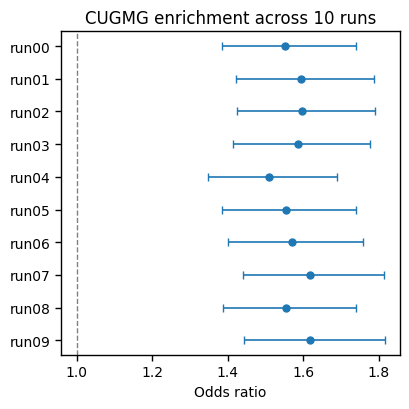

In [14]:
### Panel E: CUGMG enrichment across 10 runs ###
import pandas as pd,numpy as np,matplotlib.pyplot as plt,os
plt.rcParams.update({"font.family":"DejaVu Sans","font.size":10,"pdf.fonttype":42,"ps.fonttype":42})

F="/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/module1_motif_10runs/CUGMG_validation/CUGMG_m60_m25_10runs.csv"
OUT="/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/module1_motif_10runs/CUGMG_validation"
R=pd.read_csv(F)
y=np.arange(len(R))

fig,ax=plt.subplots(figsize=(4.2,4.2))
ax.errorbar(R.OR,y,xerr=[R.OR-R.CI_low,R.CI_high-R.OR],fmt="o",ms=5,capsize=3,lw=1.2)
ax.axvline(1,color="0.5",ls="--",lw=1)
ax.set(yticks=y,yticklabels=R.Run,xlabel="Odds ratio",title="CUGMG enrichment across 10 runs")
ax.invert_yaxis()
for s in ax.spines.values(): s.set_visible(True);s.set_linewidth(1)
ax.tick_params(direction="out",length=4,width=1)
ax.grid(False)
plt.tight_layout()
plt.savefig(f"{OUT}/panelE_CUGMG_forest.pdf",bbox_inches="tight")
plt.savefig(f"{OUT}/panelE_CUGMG_forest.png",dpi=300,bbox_inches="tight")
plt.show()

In [20]:
### prepare 10 run input for streme ###
import pandas as pd, os, re
BASE="/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/module1_motif_10runs"
PKL="/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only/translation_strict_lenmatched_run{:02d}.pkl"

def clean(s):
    return re.sub("[^ACGU]","N",str(s).upper().replace("T","U"))

for run in range(10):
    df=pd.read_pickle(PKL.format(run))
    df["up"]=df["upstream_seq_50nt"].map(clean)
    df=df[(df["up"].str.len()>=120)&(~df["up"].str[-120:].str.contains("N"))].copy()
    df["seq"]=df["up"].str[-120:].str[60:96]
    out=f"{BASE}/run{run:02d}/input"; os.makedirs(out,exist_ok=True)
    for lab,name in [(1,"positive"),(0,"negative")]:
        x=df[df["binary_label"]==lab]
        with open(f"{out}/run{run:02d}_{name}_m60_m25.fa","w") as f:
            for _,r in x.iterrows(): f.write(f">{r['sample_id']}\n{r['seq']}\n")
        print(f"run{run:02d} {name}: n={len(x)}")

run00 positive: n=7699
run00 negative: n=7752
run01 positive: n=7699
run01 negative: n=7743
run02 positive: n=7699
run02 negative: n=7755
run03 positive: n=7699
run03 negative: n=7757
run04 positive: n=7699
run04 negative: n=7765
run05 positive: n=7699
run05 negative: n=7740
run06 positive: n=7699
run06 negative: n=7730
run07 positive: n=7699
run07 negative: n=7742
run08 positive: n=7699
run08 negative: n=7745
run09 positive: n=7699
run09 negative: n=7748


In [1]:
import os, subprocess

BASE="/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/module1_motif_10runs"

for run in range(10):
    IN=f"{BASE}/run{run:02d}/input"
    OUT=f"{BASE}/run{run:02d}/streme_m60_m25"
    pos=f"{IN}/run{run:02d}_positive_m60_m25.fa"
    neg=f"{IN}/run{run:02d}_negative_m60_m25.fa"
    print(f"\n===== run{run:02d} =====")
    subprocess.run([
        "streme","--p",pos,"--n",neg,"--rna","--objfun","de",
        "--minw","5","--maxw","10","--order","2","--seed","42","--oc",OUT
    ],check=True)


===== run00 =====


# NOTE: Will convert any DNA sequences to RNA.
# Positive sequences "/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/module1_motif_10runs/run00/input/run00_positive_m60_m25.fa" - training: 6930 hold-out: 769
# Negative sequences "/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/module1_motif_10runs/run00/input/run00_negative_m60_m25.fa" - training: 6977 hold-out: 775
# Estimating background model from control sequences.
# Background: A 0.255 C 0.246 G 0.256 U 0.243
# Background order: 2 Background size: 84
# Using Fisher Exact test for p-values.
# Building suffix tree of positive and negative sequences...
# SUFFIXTREE	0.00 seconds 	(cumulative 0.08 seconds)
# Adding sequence counts and p-values to nodes using depth first search...
# ADDCOUNTS	0.00 seconds 	(cumulative 0.66 seconds)
# Sorting 239651 initial seed nodes by p-value...
# SORTSEEDS	0.00 seconds 	(cumulative 0.72 seconds)
#   Evaluating the top 25 seeds (out of 239651) of e


===== run01 =====


# ADDCOUNTS	0.00 seconds 	(cumulative 0.66 seconds)
# Sorting 239625 initial seed nodes by p-value...
# SORTSEEDS	0.00 seconds 	(cumulative 0.73 seconds)
#   Evaluating the top 25 seeds (out of 239625) of each width in range [3, 10] ...

# EVALUATESEEDS	0.00 seconds 	(cumulative 1.14 seconds)
# Refining the 4 best evaluated seeds of each width in range [5, 10]
#   using score-based refinement (1149 evaluated seeds)...
#   Refining evaluated seed 1: CCGGC log_pvalue -196.27 width 5 w0 5
#     ITER 1 pvalue 5.3e-090 pos 2543 neg 1484 score_threshold 3.076
#     ITER 2 pvalue 3.0e-093 pos 2420 neg 1362 score_threshold 4.300
#     ITER 3 pvalue 2.3e-094 pos 2516 neg 1437 score_threshold 3.744
#     ITER 4 pvalue 2.3e-096 pos 2448 neg 1369 score_threshold 4.339
#   CAND-1-1 w 5 w0 5 'CCGGC' 'SCGGC' sd_pos 327 sd_neg 131 sd_pv -48.01 tr_pos 2448 tr_neg 1369 tr_pv 2.3e-096 tr_rat 1.8 test_pos 294 test_neg 178 test_pv 5.2e-011 test_rat 1.7 score_threshold 4.33948
#   Refining evaluated seed 2:


===== run02 =====


...

# ADDCOUNTS	0.00 seconds 	(cumulative 0.66 seconds)
# Sorting 239639 initial seed nodes by p-value...
# SORTSEEDS	0.00 seconds 	(cumulative 0.73 seconds)
#   Evaluating the top 25 seeds (out of 239639) of each width in range [3, 10] ...

# EVALUATESEEDS	0.00 seconds 	(cumulative 1.13 seconds)
# Refining the 4 best evaluated seeds of each width in range [5, 10]
#   using score-based refinement (1137 evaluated seeds)...
#   Refining evaluated seed 1: CGGCG log_pvalue -206.05 width 5 w0 5
#   CAND-1-1 w 5 w0 5 'CGGCG' 'CGGCG' sd_pos 278 sd_neg 68 sd_pv -73.23 tr_pos 2421 tr_neg 1318 tr_pv 7.4e-102 tr_rat 1.8 test_pos 294 test_neg 153 test_pv 6.9e-016 test_rat 1.9 score_threshold 0.95719
#   Refining evaluated seed 2: CGCCG log_pvalue -199.27 width 5 w0 5
#     ITER 1 pvalue 4.6e-093 pos 1813 neg 876 score_threshold 4.825
#     ITER 2 pvalue 2.1e-096 pos 2310 neg 1254 score_threshold 3.601
#   CAND-1-2 w 5 w0 5 'CGCCG' 'CGCCG' sd_pos 259 sd_neg 81 sd_pv -53.28 tr_pos 2310 tr_neg 1254 tr_pv


===== run08 =====


# ADDCOUNTS	0.00 seconds 	(cumulative 0.66 seconds)
# Sorting 239854 initial seed nodes by p-value...
# SORTSEEDS	0.00 seconds 	(cumulative 0.73 seconds)
#   Evaluating the top 25 seeds (out of 239854) of each width in range [3, 10] ...

# EVALUATESEEDS	0.00 seconds 	(cumulative 1.14 seconds)
# Refining the 4 best evaluated seeds of each width in range [5, 10]
#   using score-based refinement (1137 evaluated seeds)...
#   Refining evaluated seed 1: CGGCG log_pvalue -190.12 width 5 w0 5
#     ITER 1 pvalue 3.7e-097 pos 1539 neg 657 score_threshold 5.259
#     ITER 2 pvalue 2.3e-101 pos 1590 neg 677 score_threshold 5.531
#   CAND-1-1 w 5 w0 5 'CGGCG' 'CGGCG' sd_pos 278 sd_neg 83 sd_pv -60.23 tr_pos 1590 tr_neg 677 tr_pv 2.3e-101 tr_rat 2.3 test_pos 182 test_neg 74 test_pv 3.9e-014 test_rat 2.5 score_threshold 5.53097
#   Refining evaluated seed 2: CGCCG log_pvalue -188.31 width 5 w0 5
#   CAND-1-2 w 5 w0 5 'CGCCG' 'CGCCG' sd_pos 259 sd_neg 76 sd_pv -57.23 tr_pos 2393 tr_neg 1375 tr_pv 8.


===== run09 =====


# ADDCOUNTS	0.00 seconds 	(cumulative 0.66 seconds)
# Sorting 239872 initial seed nodes by p-value...
# SORTSEEDS	0.00 seconds 	(cumulative 0.73 seconds)
#   Evaluating the top 25 seeds (out of 239872) of each width in range [3, 10] ...

# EVALUATESEEDS	0.00 seconds 	(cumulative 1.14 seconds)
# Refining the 4 best evaluated seeds of each width in range [5, 10]
#   using score-based refinement (1135 evaluated seeds)...
#   Refining evaluated seed 1: CGGCG log_pvalue -197.67 width 5 w0 5
#     ITER 1 pvalue 2.2e-098 pos 1890 neg 912 score_threshold 5.067
#     ITER 2 pvalue 8.5e-110 pos 1863 neg 843 score_threshold 4.907
#   CAND-1-1 w 5 w0 5 'CGGCG' 'CGGCG' sd_pos 278 sd_neg 78 sd_pv -64.36 tr_pos 1863 tr_neg 843 tr_pv 8.5e-110 tr_rat 2.2 test_pos 220 test_neg 94 test_pv 3.9e-016 test_rat 2.3 score_threshold 4.9068
#   Refining evaluated seed 2: CCGCG log_pvalue -181.35 width 5 w0 5
#     ITER 1 pvalue 1.8e-100 pos 2214 neg 1157 score_threshold 4.303
#     ITER 2 pvalue 6.7e-102 pos 175

In [1]:
import re, pandas as pd

BASE="/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/module1_motif_10runs"
rows=[]

for run in range(10):
    txt=open(f"{BASE}/run{run:02d}/streme_m60_m25/streme.txt").read()
    pat=r"MOTIF\s+(\d+)-(\S+)\s+STREME-\d+\nletter-probability matrix:.*?w=\s*(\d+)\s+nsites=\s*(\d+)\s+E=\s*([0-9.eE+-]+)"
    for num,cons,w,n,e in re.findall(pat,txt):
        e=float(e)
        if e<=0.05:
            rows.append([run,int(num),cons,int(w),int(n),e])

motifs=pd.DataFrame(rows,columns=["run","motif_no","consensus","width","nsites","E_value"])
display(motifs)
motifs.to_csv(f"{BASE}/streme_significant_motifs_10runs.csv",index=False)

,run,motif_no,consensus,width,nsites,E_value
0,0,1,CCGCCGCSG,9,1515,6.400000e-15
1,0,2,CCGGH,5,3580,4.800000e-06
2,0,3,CUGMG,5,961,4.600000e-02
3,1,1,CCGCCGCSG,9,1388,2.000000e-13
4,1,2,HSCGGH,6,3874,4.700000e-05
5,2,1,CCGCCGCS,8,1465,3.100000e-13
6,2,2,SCGGV,5,3747,1.900000e-07
7,3,1,BCGNNN,6,4079,2.800000e-12
8,3,2,CGCGGCSSSS,10,959,7.100000e-12
9,4,1,SCSGCSGCSG,10,1394,5.100000e-20


In [2]:
### using TOMTOM ###
import os,re,pandas as pd

BASE="/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/module1_motif_10runs"
OUT=f"{BASE}/tomtom_all"
os.makedirs(OUT,exist_ok=True)

motifs=[]
for run in range(10):
    fn=f"{BASE}/run{run:02d}/streme_m60_m25/streme.txt"
    lines=open(fn).readlines()
    i=0
    while i<len(lines):
        m=re.match(r"MOTIF\s+(\d+)-(\S+)\s+STREME-\d+",lines[i])
        if not m:
            i+=1; continue
        no,cons=int(m.group(1)),m.group(2)
        mat=lines[i+1]
        w=int(re.search(r"w=\s*(\d+)",mat).group(1))
        nsites=int(re.search(r"nsites=\s*(\d+)",mat).group(1))
        E=float(re.search(r"E=\s*([0-9.eE+-]+)",mat).group(1))
        pwm=[[float(x) for x in lines[i+2+j].split()] for j in range(w)]
        if E<=0.05:
            motifs.append(dict(id=f"run{run:02d}_M{no}",run=run,motif_no=no,
                               consensus=cons,width=w,nsites=nsites,E_value=E,pwm=pwm))
        i+=2+w

meta=pd.DataFrame([{k:v for k,v in x.items() if k!="pwm"} for x in motifs])
meta.to_csv(f"{OUT}/motif_metadata.csv",index=False)

with open(f"{OUT}/all_significant_motifs.meme","w") as f:
    f.write("MEME version 5\n\nALPHABET= ACGU\n\nstrands: +\n\n")
    f.write("Background letter frequencies\nA 0.25 C 0.25 G 0.25 U 0.25\n\n")
    for x in motifs:
        f.write(f"MOTIF {x['id']} {x['consensus']}\n")
        f.write(f"letter-probability matrix: alength= 4 w= {x['width']} nsites= {x['nsites']} E= {x['E_value']}\n")
        for row in x["pwm"]:
            f.write(" ".join(f"{v:.6f}" for v in row)+"\n")
        f.write("\n")

print("Significant motifs:",len(motifs))
display(meta)
print(f"{OUT}/all_significant_motifs.meme")

Significant motifs: 23


,id,run,motif_no,consensus,width,nsites,E_value
0,run00_M1,0,1,CCGCCGCSG,9,1515,6.400000e-15
1,run00_M2,0,2,CCGGH,5,3580,4.800000e-06
2,run00_M3,0,3,CUGMG,5,961,4.600000e-02
3,run01_M1,1,1,CCGCCGCSG,9,1388,2.000000e-13
4,run01_M2,1,2,HSCGGH,6,3874,4.700000e-05
5,run02_M1,2,1,CCGCCGCS,8,1465,3.100000e-13
6,run02_M2,2,2,SCGGV,5,3747,1.900000e-07
7,run03_M1,3,1,BCGNNN,6,4079,2.800000e-12
8,run03_M2,3,2,CGCGGCSSSS,10,959,7.100000e-12
9,run04_M1,4,1,SCSGCSGCSG,10,1394,5.100000e-20


/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/module1_motif_10runs/tomtom_all/all_significant_motifs.meme


In [2]:
TOMTOM="/disk3/hejp/soft/meme/bin/tomtom"
!{TOMTOM} --version

/bin/bash: /disk3/hejp/soft/meme/bin/tomtom: No such file or directory


In [4]:
###使用enhanced position的stage1版本进行ablation分析###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/model_explanable/stage1_enhanced_position_ablation_v3/rnafm_selfattention_enhanced_position_ablation_v3.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only \
  --dataset_prefix translation_strict_lenmatched \
  --model_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/afteroptimize/enhanced_position_ffmult2_wd5e4_10runs_roc \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/ablation_stage1_enhanced_position_roc_ws9_nrun10_test \
  --run_name_prefix rnafm_self_attention_enhanced_position_select_strict_roc \
  --start_run 0 \
  --n_runs 10 \
  --seed 42 \
  --subset test \
  --label_filter all \
  --batch_size 64 \
  --num_workers 0 \
  --do_region \
  --do_position \
  --position_stride 3 \
  --window_size 9 \
  --max_upstream_pos 450 \
  --max_orf_pos 453 \
  --max_downstream_pos 450 \
  --min_coverage 0.8 \
  --plot_group pos \
  --position_mode enhanced \
  --ablation_content rnafm_only \
  --branch_hidden_dim 256 \
  --fusion_hidden_dim 256 \
  --num_heads 8 \
  --num_layers 2 \
  --dropout 0.2 \
  --ff_mult 2 \
  --strict_baseline_check

device: cuda
subset: test
ablation_content: rnafm_only
window_size / stride: 9 / 3
minimum coverage: 0.8

Run 00 | seed 42
dataset: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only/translation_strict_lenmatched_run00.pkl
checkpoint: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/afteroptimize/enhanced_position_ffmult2_wd5e4_10runs_roc/rnafm_self_attention_enhanced_position_select_strict_roc_run00/rnafm_self_attention_enhanced_position_select_strict_roc_run00_best_model.pt
samples: 2874 | positives: 1437
/disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/model_explanable/stage1_enhanced_position_ablation_v3/build_model_rnafm_self_attention_enhanced_position_ablation.py:155: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(la

In [5]:
###可视化ablation的结果###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/model_explanable/stage1_enhanced_position_ablation_v3/plot_stage1_enhanced_position_ablation_v3.py \
  --ablation_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/ablation_stage1_enhanced_position_roc_ws9_nrun10_test \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/ablation_stage1_enhanced_position_roc_ws9_nrun10_test/importance_metrics_v3 \
  --min_coverage 0.8 \
  --dpi 300 \
  --formats png pdf

saved: /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/ablation_stage1_enhanced_position_roc_ws9_nrun10_test/importance_metrics_v3/Fig_upstream_ABCD.png
saved: /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/ablation_stage1_enhanced_position_roc_ws9_nrun10_test/importance_metrics_v3/Fig_upstream_ABCD.pdf
saved: /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/ablation_stage1_enhanced_position_roc_ws9_nrun10_test/importance_metrics_v3/Fig_orf_ABCD.png
saved: /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/ablation_stage1_enhanced_position_roc_ws9_nrun10_test/importance_metrics_v3/Fig_orf_ABCD.pdf
saved: /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/ablation_stage1_enhanced_position_roc_ws9_nrun10_test/importance_metrics_v3/Fig_downstream_ABCD.png
saved: /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/ablation_stage1_enhanced_p

In [6]:
###可视化ablation的结果，这次加了柱状图的paired test###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/model_explanable/stage1_enhanced_position_ablation_v3/plot_stage1_enhanced_position_ablation_v4.py \
  --ablation_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/ablation_stage1_enhanced_position_roc_ws9_nrun10_test \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/ablation_stage1_enhanced_position_roc_ws9_nrun10_test/importance_metrics_v4 \
  --min_coverage 0.8 \
  --dpi 300 \
  --formats png pdf

saved: /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/ablation_stage1_enhanced_position_roc_ws9_nrun10_test/importance_metrics_v4/Fig_upstream_ABCD.png
saved: /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/ablation_stage1_enhanced_position_roc_ws9_nrun10_test/importance_metrics_v4/Fig_upstream_ABCD.pdf
saved: /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/ablation_stage1_enhanced_position_roc_ws9_nrun10_test/importance_metrics_v4/Fig_orf_ABCD.png
saved: /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/ablation_stage1_enhanced_position_roc_ws9_nrun10_test/importance_metrics_v4/Fig_orf_ABCD.pdf
saved: /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/ablation_stage1_enhanced_position_roc_ws9_nrun10_test/importance_metrics_v4/Fig_downstream_ABCD.png
saved: /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/ablation_stage1_enhanced_p

In [ ]:
###ablation 消融实验###
#其他参数：--label_filter pos，--subset all, --subset test(15%)#
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/model_explanable/rnafm_selfattention_ablation/rnafm_selfattention_ablation.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only \
  --dataset_prefix translation_strict_lenmatched \
  --model_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/afteroptimize/ffmult2_wd5e4_10runs \
  --model_py_dir /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4 \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/ablation_rnafm_selfattention_ffmult2_wd5e4 \
  --run_name_prefix rnafm_self_attention_strict \
  --n_runs 10 \
  --subset test \
  --batch_size 64 \
  --do_region \
  --do_position \
  --position_stride 3 \
  --window_size 5 \
  --num_heads 8 \
  --num_layers 2 \
  --dropout 0.2 \
  --ff_mult 2

device: cuda

Run 00
dataset: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only/translation_strict_lenmatched_run00.pkl
model: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/afteroptimize/ffmult2_wd5e4_10runs/rnafm_self_attention_strict_run00/rnafm_self_attention_strict_run00_best_model.pt
samples: (2874, 20)
binary_label
0    1437
1    1437
/disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/build_model_rnafm_self_attention.py:58: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
baseline prediction done
region upstream: delta_pos=2.58206, drop_auc=0.16987
region orf: delta_pos=-0.03553, drop_auc=0.01689
region downstream: delta_pos=0.83586, drop_auc=0.01117
position ablatio

In [4]:
###ablation 消融实验###
#其他参数：--label_filter pos，--subset all, --subset test(15%)#
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/model_explanable/rnafm_selfattention_ablation/rnafm_selfattention_ablation.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only \
  --dataset_prefix translation_strict_lenmatched \
  --model_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/afteroptimize/ffmult2_wd5e4_10runs \
  --model_py_dir /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4 \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/ablation_rnafm_selfattention_ffmult2_wd5e4_nrun1_subsetall \
  --run_name_prefix rnafm_self_attention_strict \
  --n_runs 1 \
  --subset all \
  --batch_size 64 \
  --do_region \
  --do_position \
  --position_stride 3 \
  --window_size 5 \
  --num_heads 8 \
  --num_layers 2 \
  --dropout 0.2 \
  --ff_mult 2

device: cuda

Run 00
dataset: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only/translation_strict_lenmatched_run00.pkl
model: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/afteroptimize/ffmult2_wd5e4_10runs/rnafm_self_attention_strict_run00/rnafm_self_attention_strict_run00_best_model.pt
samples: (19158, 20)
binary_label
0    9579
1    9579
/disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/build_model_rnafm_self_attention.py:58: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
baseline prediction done
region upstream: delta_pos=2.81825, drop_auc=0.18525
region orf: delta_pos=0.04404, drop_auc=0.02570
region downstream: delta_pos=0.91610, drop_auc=0.01495
position ablatio

In [13]:
###ablation 消融实验2###
#其他参数：--label_filter pos，--subset all, --subset test(15%)#
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/model_explanable/rnafm_selfattention_ablation/rnafm_selfattention_ablation.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only \
  --dataset_prefix translation_strict_lenmatched \
  --model_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/afteroptimize/ffmult2_wd5e4_10runs \
  --model_py_dir /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4 \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/ablation_rnafm_selfattention_ffmult2_wd5e4_nrun5_subsetall \
  --run_name_prefix rnafm_self_attention_strict \
  --n_runs 5 \
  --subset all \
  --batch_size 64 \
  --do_region \
  --do_position \
  --position_stride 3 \
  --window_size 5 \
  --num_heads 8 \
  --num_layers 2 \
  --dropout 0.2 \
  --ff_mult 2

device: cuda

Run 00
dataset: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only/translation_strict_lenmatched_run00.pkl
model: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/afteroptimize/ffmult2_wd5e4_10runs/rnafm_self_attention_strict_run00/rnafm_self_attention_strict_run00_best_model.pt
samples: (19158, 20)
binary_label
0    9579
1    9579
/disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/build_model_rnafm_self_attention.py:58: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
baseline prediction done
region upstream: delta_pos=2.81825, drop_auc=0.18525
region orf: delta_pos=0.04404, drop_auc=0.02570
region downstream: delta_pos=0.91610, drop_auc=0.01495
position ablatio

In [34]:
###ablation 的代码有小bug，之前部分长度短的sORF的缺失部分在ablation中会作为0值计算，拉低的平均值，现更新V2版本，作为修正###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/model_explanable/rnafm_selfattention_ablation/rnafm_selfattention_ablation_v2.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only \
  --dataset_prefix translation_strict_lenmatched \
  --model_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/afteroptimize/ffmult2_wd5e4_10runs \
  --model_py_dir /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4 \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/ablation_rnafm_selfattention_v2_ffmult2_wd5e4_ws9_nrun1_subsettest \
  --run_name_prefix rnafm_self_attention_strict \
  --n_runs 1 \
  --subset test \
  --label_filter all \
  --batch_size 64 \
  --do_region \
  --do_position \
  --position_stride 3 \
  --window_size 9 \
  --min_coverage 0.8 \
  --plot_group pos \
  --num_heads 8 \
  --num_layers 2 \
  --dropout 0.2 \
  --ff_mult 2

device: cuda
window_size: 9
minimum coverage for figures/ranking: 0.8
plot group: pos

Run 00
dataset: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only/translation_strict_lenmatched_run00.pkl
model: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/afteroptimize/ffmult2_wd5e4_10runs/rnafm_self_attention_strict_run00/rnafm_self_attention_strict_run00_best_model.pt
samples: (2874, 20)
binary_label
0    1437
1    1437
/disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/build_model_rnafm_self_attention.py:58: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
baseline prediction done
region upstream: delta_pos=2.58206, drop_auc=0.16987
region orf: delta_pos=-0.03553, drop_auc=0.0168

In [35]:
###ablation 的代码有小bug，之前部分长度短的sORF的缺失部分在ablation中会作为0值计算，拉低的平均值，现更新V2版本，作为修正###
###run for 10 times###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/model_explanable/rnafm_selfattention_ablation/rnafm_selfattention_ablation_v2.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only \
  --dataset_prefix translation_strict_lenmatched \
  --model_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/afteroptimize/ffmult2_wd5e4_10runs \
  --model_py_dir /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4 \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/ablation_rnafm_selfattention_v2_ffmult2_wd5e4_ws9_nrun10_subsettest \
  --run_name_prefix rnafm_self_attention_strict \
  --n_runs 10 \
  --subset test \
  --label_filter all \
  --batch_size 64 \
  --do_region \
  --do_position \
  --position_stride 3 \
  --window_size 9 \
  --min_coverage 0.8 \
  --plot_group pos \
  --num_heads 8 \
  --num_layers 2 \
  --dropout 0.2 \
  --ff_mult 2

device: cuda
window_size: 9
minimum coverage for figures/ranking: 0.8
plot group: pos

Run 00
dataset: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only/translation_strict_lenmatched_run00.pkl
model: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/afteroptimize/ffmult2_wd5e4_10runs/rnafm_self_attention_strict_run00/rnafm_self_attention_strict_run00_best_model.pt
samples: (2874, 20)
binary_label
0    1437
1    1437
/disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/build_model_rnafm_self_attention.py:58: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
baseline prediction done
region upstream: delta_pos=2.58206, drop_auc=0.16987
region orf: delta_pos=-0.03553, drop_auc=0.0168

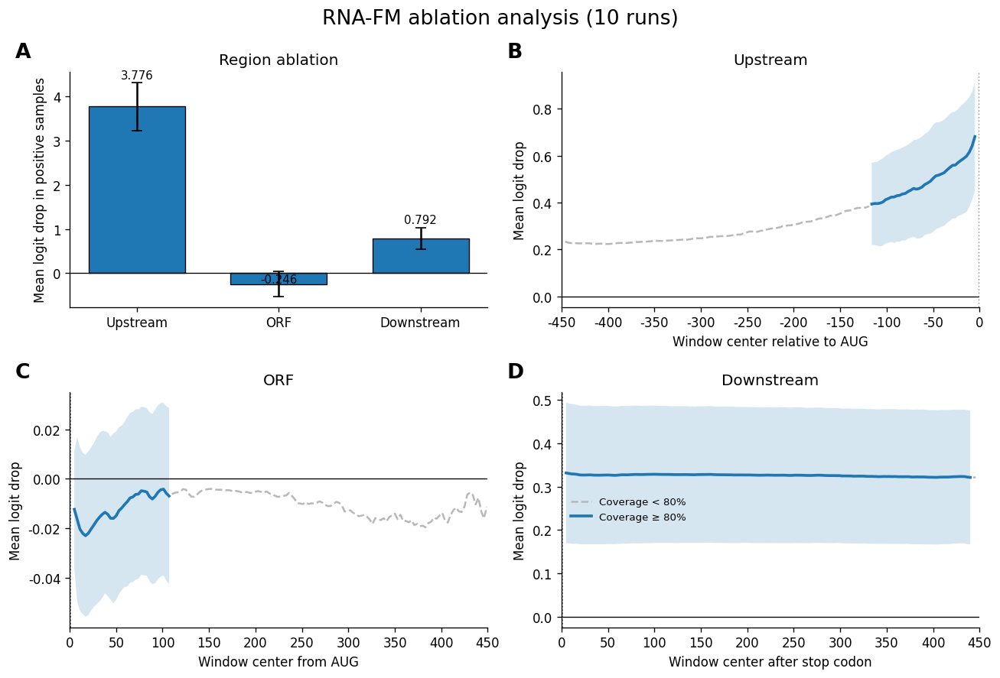

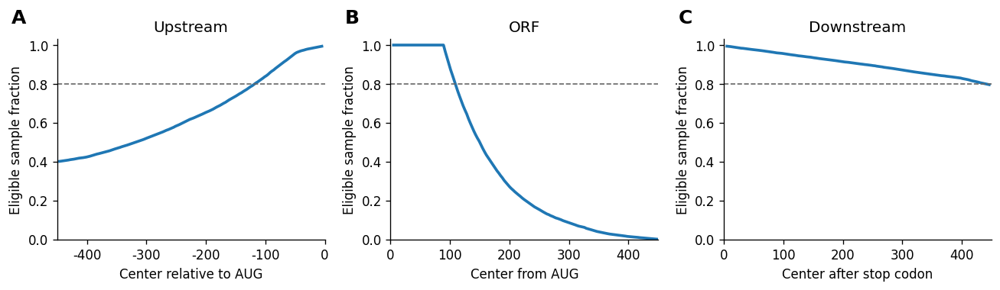

Saved to: /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/ablation_rnafm_selfattention_v2_ffmult2_wd5e4_ws9_nrun10_subsettest/publication_figures


In [36]:
###450版本###
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# ==================== 路径 ====================
base = "/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/ablation_rnafm_selfattention_v2_ffmult2_wd5e4_ws9_nrun10_subsettest"
out = os.path.join(base, "publication_figures")
os.makedirs(out, exist_ok=True)

# ==================== 绘图设置 ====================
mpl.rcParams.update({
    "pdf.fonttype": 42,          # AI中保留可编辑文字
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "font.family": "DejaVu Sans",
    "axes.unicode_minus": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 120,
    "savefig.dpi": 300
})

# ==================== 读取结果 ====================
reg = pd.read_csv(os.path.join(base, "region_ablation_summary.csv"))
pos = pd.read_csv(os.path.join(base, "position_ablation_summary.csv"))

regions = ["upstream", "orf", "downstream"]
names = {"upstream": "Upstream", "orf": "ORF", "downstream": "Downstream"}

ycol = "delta_logit_mean_pos_mean"
sdcol = "delta_logit_mean_pos_std"
covcol = "coverage_rate_mean"
min_cov = 0.80

reg[sdcol] = reg[sdcol].fillna(0)
pos[sdcol] = pos[sdcol].fillna(0)

nrun = int(pos["n_runs"].max()) if "n_runs" in pos.columns else 1

# 95% CI
reg["err"] = 1.96 * reg[sdcol] / np.sqrt(nrun) if nrun > 1 else 0
pos["err"] = 1.96 * pos[sdcol] / np.sqrt(nrun) if nrun > 1 else 0

# ==================== 主图 ====================
fig, axes = plt.subplots(2, 2, figsize=(11, 7.5))
axes = axes.ravel()

# A. Region ablation
r = reg.set_index("region").reindex(regions).reset_index()
x = np.arange(3)

axes[0].bar(
    x, r[ycol], yerr=r["err"],
    capsize=4, width=0.68,
    edgecolor="black", linewidth=0.8
)
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels([names[r] for r in regions])
axes[0].set_ylabel("Mean logit drop in positive samples")
axes[0].set_title("Region ablation")
axes[0].text(-0.13, 1.06, "A", transform=axes[0].transAxes,
             fontsize=16, fontweight="bold")

# 标注柱子数值
for xi, yi, ei in zip(x, r[ycol], r["err"]):
    axes[0].text(
        xi, yi + ei + (0.04 if yi >= 0 else -0.04),
        f"{yi:.3f}", ha="center",
        va="bottom" if yi >= 0 else "top",
        fontsize=9
    )

# B-D. Position ablation
for ax, region, label in zip(axes[1:], regions, ["B", "C", "D"]):

    s = pos[pos["region"] == region].sort_values("center_pos").copy()
    good = s[covcol] >= min_cov

    # 低覆盖率：灰色虚线
    ax.plot(
        s.loc[~good, "center_pos"],
        s.loc[~good, ycol],
        color="0.72", lw=1.5, ls="--",
        label="Coverage < 80%"
    )

    # 高覆盖率：蓝色实线
    ax.plot(
        s.loc[good, "center_pos"],
        s.loc[good, ycol],
        lw=2.2,
        label="Coverage ≥ 80%"
    )

    # 10 runs时加入95% CI
    if nrun > 1:
        xg = s.loc[good, "center_pos"].to_numpy()
        yg = s.loc[good, ycol].to_numpy()
        eg = s.loc[good, "err"].to_numpy()

        ax.fill_between(
            xg, yg-eg, yg+eg,
            alpha=0.18, linewidth=0
        )

    ax.axhline(0, color="black", lw=0.8)
    ax.set_title(names[region])
    ax.set_ylabel("Mean logit drop")
    ax.text(-0.13, 1.06, label, transform=ax.transAxes,
            fontsize=16, fontweight="bold")

    if region == "upstream":
        ax.set_xlim(-450, 0)
        ax.axvline(0, color="0.4", ls=":", lw=1)
        ax.set_xlabel("Window center relative to AUG")

    elif region == "orf":
        ax.set_xlim(0, 450)
        ax.axvline(1, color="0.4", ls=":", lw=1)
        ax.set_xlabel("Window center from AUG")

    else:
        ax.set_xlim(0, 450)
        ax.axvline(1, color="0.4", ls=":", lw=1)
        ax.set_xlabel("Window center after stop codon")

axes[3].legend(frameon=False, fontsize=8)

fig.suptitle(
    f"RNA-FM ablation analysis ({nrun} run{'s' if nrun > 1 else ''})",
    fontsize=16
)
fig.tight_layout()

for ext in ["pdf", "png"]:
    fig.savefig(
        os.path.join(out, f"Fig_ablation_450_summary.{ext}"),
        dpi=300, bbox_inches="tight"
    )

plt.show()
plt.close(fig)

# ==================== Coverage图 ====================
fig, axes = plt.subplots(1, 3, figsize=(11, 3.3))

for ax, region, label in zip(axes, regions, ["A", "B", "C"]):

    s = pos[pos["region"] == region].sort_values("center_pos")

    ax.plot(s["center_pos"], s[covcol], lw=2.2)
    ax.axhline(min_cov, color="0.4", ls="--", lw=1)
    ax.set_ylim(0, 1.03)
    ax.set_title(names[region])
    ax.set_ylabel("Eligible sample fraction")
    ax.text(-0.17, 1.08, label, transform=ax.transAxes,
            fontsize=15, fontweight="bold")

    if region == "upstream":
        ax.set_xlim(-450, 0)
        ax.set_xlabel("Center relative to AUG")
    elif region == "orf":
        ax.set_xlim(0, 450)
        ax.set_xlabel("Center from AUG")
    else:
        ax.set_xlim(0, 450)
        ax.set_xlabel("Center after stop codon")

fig.tight_layout()

for ext in ["pdf", "png"]:
    fig.savefig(
        os.path.join(out, f"Fig_ablation_450_coverage.{ext}"),
        dpi=300, bbox_inches="tight"
    )

plt.show()
plt.close(fig)

print("Saved to:", out)

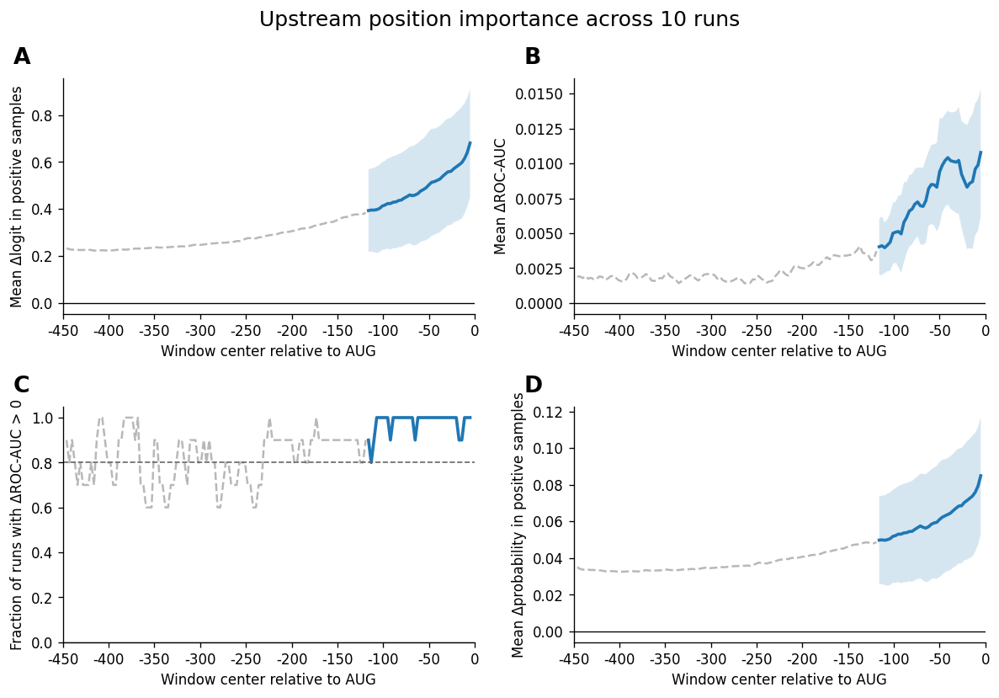

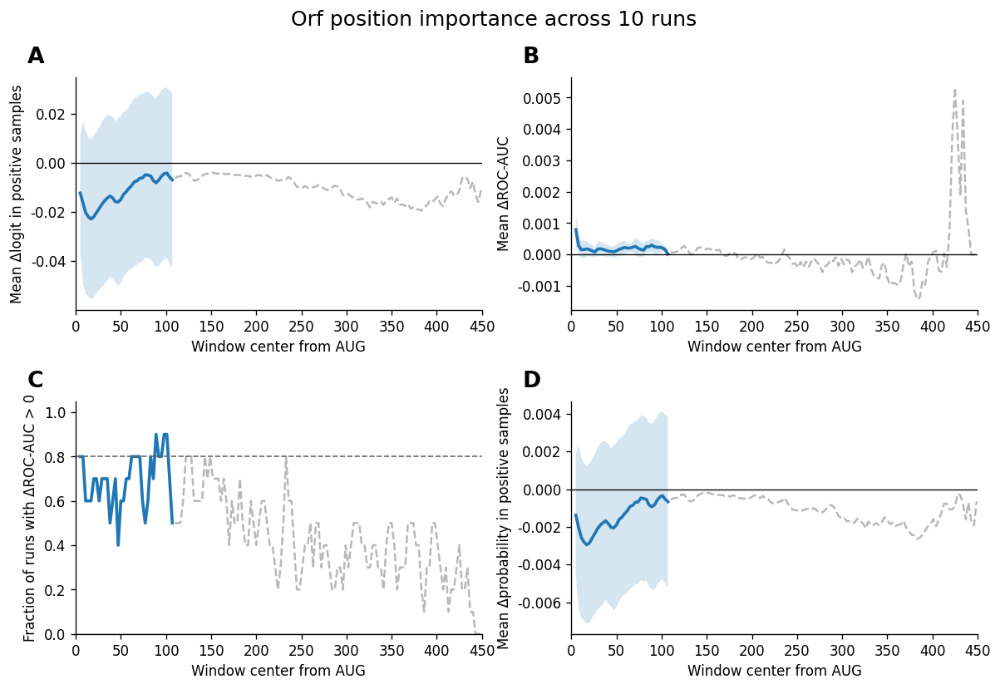

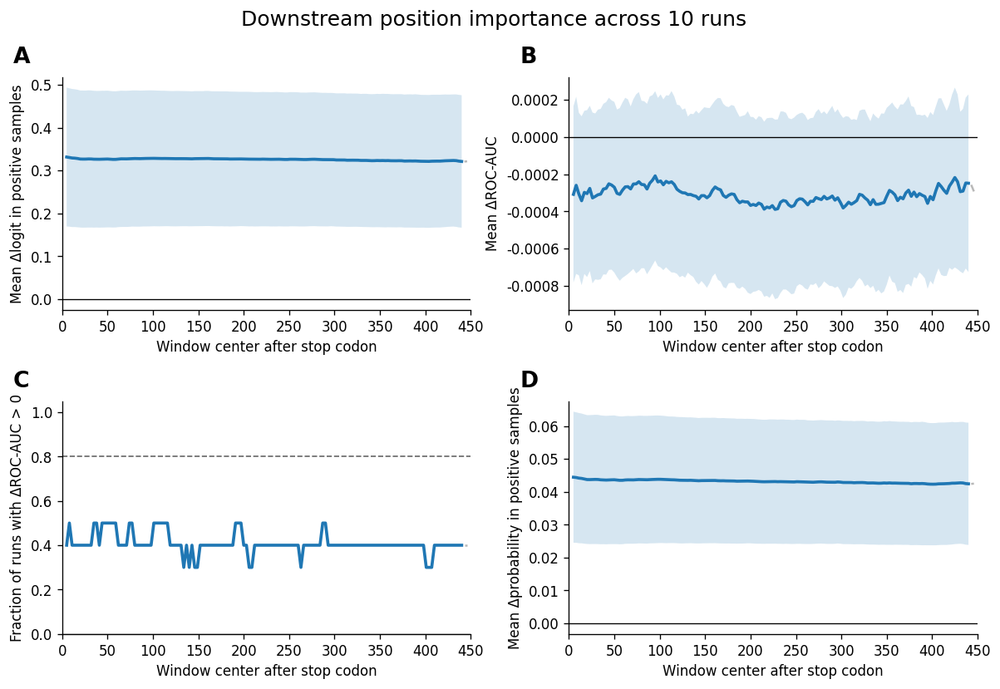

Saved to: /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/ablation_rnafm_selfattention_v2_ffmult2_wd5e4_ws9_nrun10_subsettest/importance_metrics


In [38]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

base = "/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/ablation_rnafm_selfattention_v2_ffmult2_wd5e4_ws9_nrun10_subsettest"
out = os.path.join(base, "importance_metrics")
os.makedirs(out, exist_ok=True)

mpl.rcParams.update({
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.unicode_minus": False
})

df = pd.read_csv(os.path.join(base, "position_ablation_by_run.csv"))

settings = {
    "upstream":   (-450, 0, "Window center relative to AUG"),
    "orf":        (0, 450, "Window center from AUG"),
    "downstream": (0, 450, "Window center after stop codon")
}

for region, (xmin, xmax, xlabel) in settings.items():

    d = df[df["region"] == region]

    g = d.groupby(
        ["center_pos", "window_start", "window_end"]
    ).agg(
        coverage=("coverage_rate", "mean"),
        dlogit=("delta_logit_mean_pos", "mean"),
        dlogit_sd=("delta_logit_mean_pos", "std"),
        dauc=("drop_roc_auc", "mean"),
        dauc_sd=("drop_roc_auc", "std"),
        dprob=("delta_prob_mean_pos", "mean"),
        dprob_sd=("delta_prob_mean_pos", "std"),
        consistency=("drop_roc_auc", lambda x: (x > 0).mean()),
        nrun=("run", "nunique")
    ).reset_index().sort_values("center_pos")

    for x in ["dlogit", "dauc", "dprob"]:
        g[x + "_ci"] = 1.96 * g[x + "_sd"] / np.sqrt(g["nrun"])

    good = g["coverage"] >= 0.8

    fig, ax = plt.subplots(2, 2, figsize=(10, 7))
    ax = ax.ravel()

    plots = [
        ("dlogit", "dlogit_ci", "Mean Δlogit in positive samples", "A"),
        ("dauc", "dauc_ci", "Mean ΔROC-AUC", "B"),
        ("consistency", None, "Fraction of runs with ΔROC-AUC > 0", "C"),
        ("dprob", "dprob_ci", "Mean Δprobability in positive samples", "D")
    ]

    for a, (y, ci, ylabel, label) in zip(ax, plots):

        a.plot(g.loc[~good, "center_pos"], g.loc[~good, y],
               color="0.72", ls="--", lw=1.5)

        a.plot(g.loc[good, "center_pos"], g.loc[good, y], lw=2.2)

        if ci:
            x = g.loc[good, "center_pos"].to_numpy()
            m = g.loc[good, y].to_numpy()
            e = g.loc[good, ci].fillna(0).to_numpy()
            a.fill_between(x, m-e, m+e, alpha=0.18)

        a.axhline(0, color="black", lw=0.8)

        if y == "consistency":
            a.axhline(0.8, color="0.4", ls="--", lw=1)
            a.set_ylim(0, 1.05)

        a.set_xlim(xmin, xmax)
        a.set_xlabel(xlabel)
        a.set_ylabel(ylabel)
        a.text(-0.12, 1.06, label, transform=a.transAxes,
               fontsize=16, fontweight="bold")

    fig.suptitle(f"{region.capitalize()} position importance across 10 runs",
                 fontsize=15)
    fig.tight_layout()

    for ext in ["pdf", "png"]:
        fig.savefig(
            os.path.join(out, f"Fig_{region}_ABCD.{ext}"),
            dpi=300, bbox_inches="tight"
        )

    plt.show()
    plt.close(fig)

    # 候选窗口
    g["dauc_low95"] = g["dauc"] - g["dauc_ci"]

    candidate = g[
        (g["coverage"] >= 0.8) &
        (g["dauc"] > 0) &
        (g["dauc_low95"] > 0) &
        (g["consistency"] >= 0.8)
    ].copy()

    candidate.to_csv(
        os.path.join(out, f"candidate_windows_{region}.csv"),
        index=False
    )

print("Saved to:", out)

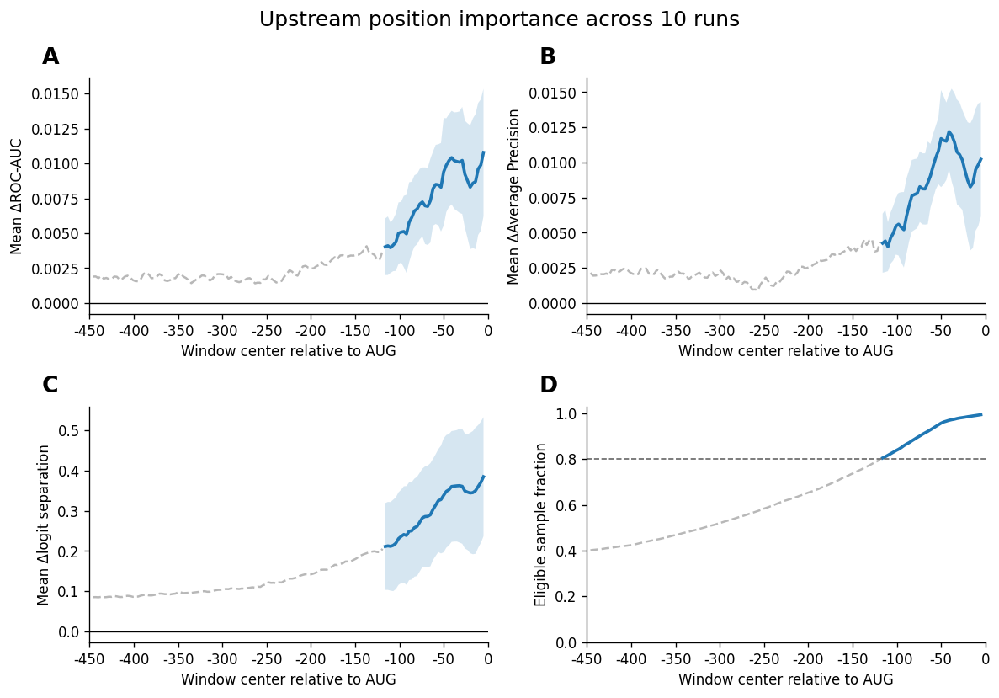

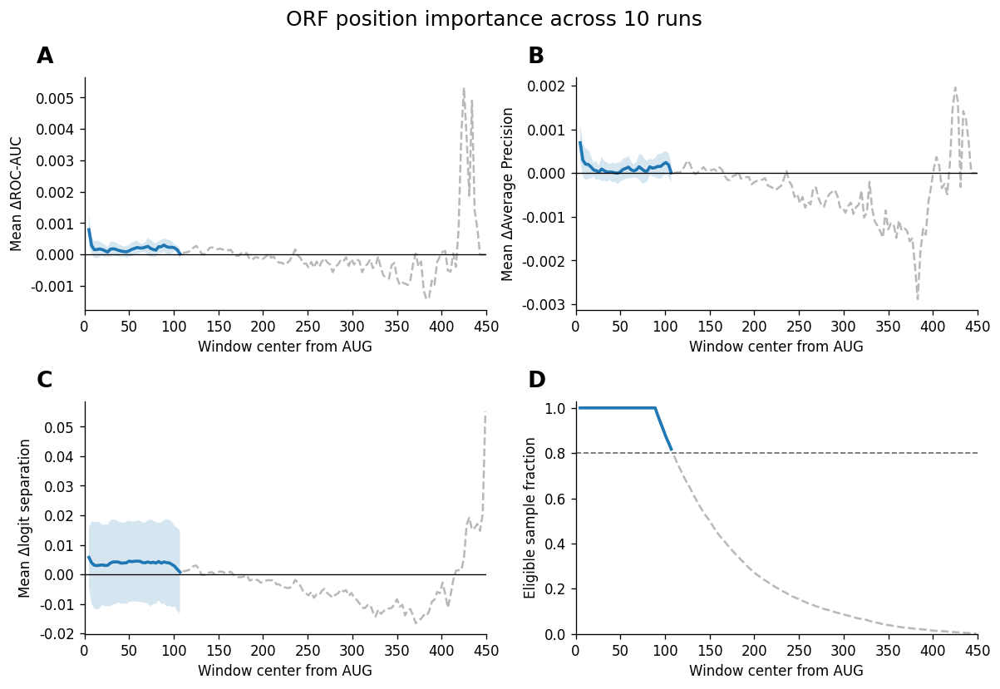

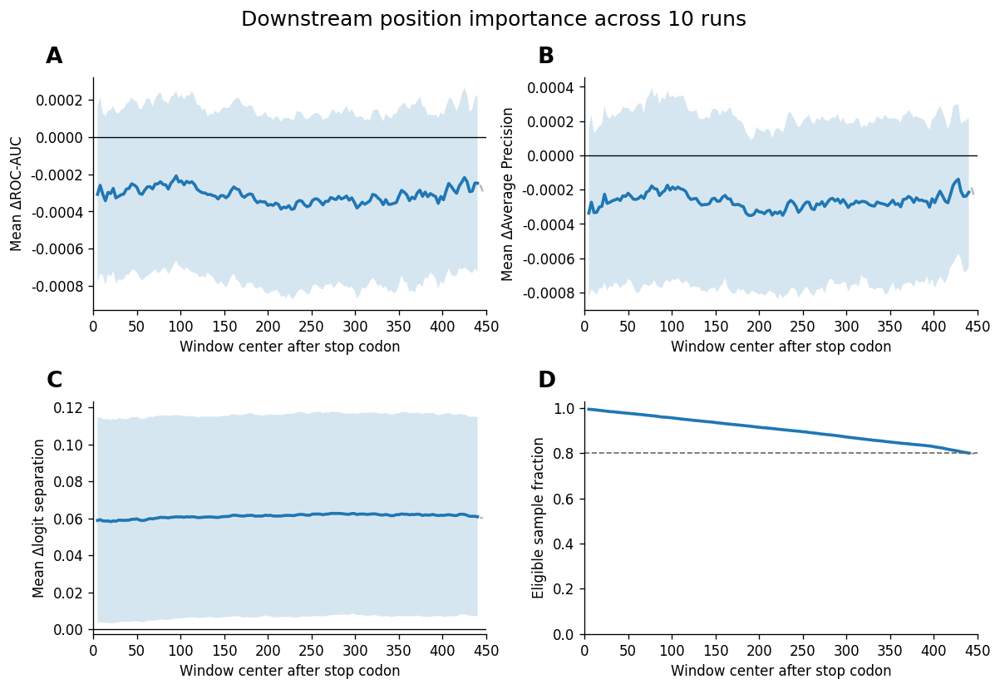

区域,阳性样本平均 logit 下降,Δlogit separation,ROC-AUC 下降,AP 下降,ΔAUC 为正的 run
Upstream,3.776,2.787,0.223,0.233,10/10
ORF,-0.246,0.285,0.017,0.017,10/10
Downstream,0.792,0.492,0.011,0.012,10/10


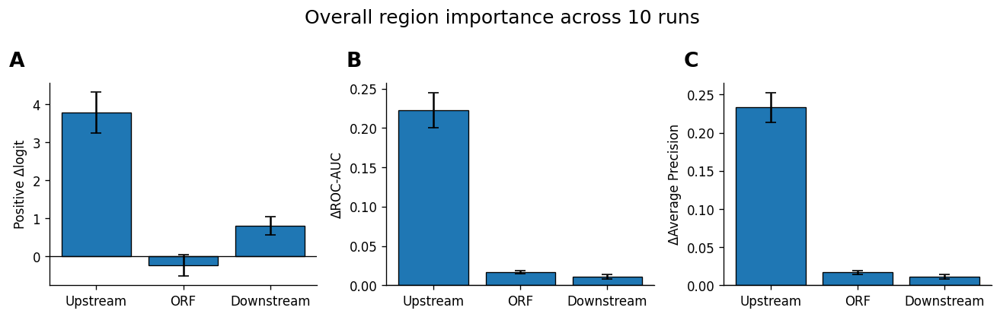

Saved to: /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/ablation_rnafm_selfattention_v2_ffmult2_wd5e4_ws9_nrun10_subsettest/importance_metrics_v2


In [39]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

base = "/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/ablation_rnafm_selfattention_v2_ffmult2_wd5e4_ws9_nrun10_subsettest"
out = os.path.join(base, "importance_metrics_v2")
os.makedirs(out, exist_ok=True)

mpl.rcParams.update({
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.unicode_minus": False
})

pos = pd.read_csv(os.path.join(base, "position_ablation_by_run.csv"))
reg = pd.read_csv(os.path.join(base, "region_ablation_by_run.csv"))

regions = ["upstream", "orf", "downstream"]
names = {"upstream": "Upstream", "orf": "ORF", "downstream": "Downstream"}
settings = {
    "upstream": (-450, 0, "Window center relative to AUG"),
    "orf": (0, 450, "Window center from AUG"),
    "downstream": (0, 450, "Window center after stop codon")
}

# =========================================================
# 1. 每个区域分别画 ABCD
# =========================================================
for region in regions:

    d = pos[pos["region"] == region].copy()
    d["dsep"] = d["delta_logit_mean_pos"] - d["delta_logit_mean_neg"]

    g = d.groupby(["center_pos", "window_start", "window_end"]).agg(
        coverage=("coverage_rate", "mean"),
        dauc=("drop_roc_auc", "mean"),
        dauc_sd=("drop_roc_auc", "std"),
        dap=("drop_average_precision", "mean"),
        dap_sd=("drop_average_precision", "std"),
        dsep=("dsep", "mean"),
        dsep_sd=("dsep", "std"),
        auc_consistency=("drop_roc_auc", lambda x: (x > 0).mean()),
        nrun=("run", "nunique")
    ).reset_index().sort_values("center_pos")

    for x in ["dauc", "dap", "dsep"]:
        g[x + "_ci"] = 1.96 * g[x + "_sd"] / np.sqrt(g["nrun"])

    good = g["coverage"] >= 0.8
    xmin, xmax, xlabel = settings[region]

    fig, ax = plt.subplots(2, 2, figsize=(10, 7))
    ax = ax.ravel()

    plots = [
        ("dauc", "dauc_ci", "Mean ΔROC-AUC", "A"),
        ("dap", "dap_ci", "Mean ΔAverage Precision", "B"),
        ("dsep", "dsep_ci", "Mean Δlogit separation", "C"),
        ("coverage", None, "Eligible sample fraction", "D")
    ]

    for a, (y, ci, ylabel, label) in zip(ax, plots):

        a.plot(
            g.loc[~good, "center_pos"],
            g.loc[~good, y],
            color="0.72", ls="--", lw=1.5
        )

        a.plot(
            g.loc[good, "center_pos"],
            g.loc[good, y],
            lw=2.2
        )

        if ci:
            x = g.loc[good, "center_pos"].to_numpy()
            m = g.loc[good, y].to_numpy()
            e = g.loc[good, ci].fillna(0).to_numpy()
            a.fill_between(x, m-e, m+e, alpha=0.18)

        if y != "coverage":
            a.axhline(0, color="black", lw=0.8)
        else:
            a.axhline(0.8, color="0.4", ls="--", lw=1)
            a.set_ylim(0, 1.03)

        a.set_xlim(xmin, xmax)
        a.set_xlabel(xlabel)
        a.set_ylabel(ylabel)
        a.text(
            -0.12, 1.06, label,
            transform=a.transAxes,
            fontsize=16, fontweight="bold"
        )

    fig.suptitle(f"{names[region]} position importance across 10 runs", fontsize=15)
    fig.tight_layout()

    for ext in ["pdf", "png"]:
        fig.savefig(
            os.path.join(out, f"Fig_{region}_ABCD.{ext}"),
            dpi=300, bbox_inches="tight"
        )

    plt.show()
    plt.close(fig)

# =========================================================
# 2. 区域汇总表
# =========================================================
reg["dsep"] = reg["delta_logit_mean_pos"] - reg["delta_logit_mean_neg"]

summary = reg.groupby("region").agg(
    delta_logit_pos=("delta_logit_mean_pos", "mean"),
    delta_logit_sep=("dsep", "mean"),
    delta_auc=("drop_roc_auc", "mean"),
    delta_ap=("drop_average_precision", "mean"),
    positive_runs=("drop_roc_auc", lambda x: f"{(x > 0).sum()}/{len(x)}")
).reindex(regions).reset_index()

summary["region"] = summary["region"].map(names)

summary_show = summary.copy()
for c in ["delta_logit_pos", "delta_logit_sep", "delta_auc", "delta_ap"]:
    summary_show[c] = summary_show[c].map(lambda x: f"{x:.3f}")

summary_show.columns = [
    "区域",
    "阳性样本平均 logit 下降",
    "Δlogit separation",
    "ROC-AUC 下降",
    "AP 下降",
    "ΔAUC 为正的 run"
]

display(
    summary_show.style
    .hide(axis="index")
    .set_properties(**{"text-align": "center"})
    .set_table_styles([
        {"selector": "th", "props": [
            ("font-weight", "bold"),
            ("text-align", "center")
        ]}
    ])
)

summary_show.to_csv(
    os.path.join(out, "region_importance_summary.csv"),
    index=False
)

# =========================================================
# 3. 总体重要性图
# =========================================================
fig, ax = plt.subplots(1, 3, figsize=(11, 3.5))

metrics = [
    ("delta_logit_mean_pos", "Positive Δlogit", "A"),
    ("drop_roc_auc", "ΔROC-AUC", "B"),
    ("drop_average_precision", "ΔAverage Precision", "C")
]

for a, (metric, ylabel, label) in zip(ax, metrics):

    g = reg.groupby("region")[metric].agg(["mean", "std"]).reindex(regions)
    err = 1.96 * g["std"] / np.sqrt(10)

    a.bar(
        range(3), g["mean"], yerr=err,
        capsize=4, edgecolor="black", linewidth=0.8
    )
    a.axhline(0, color="black", lw=0.8)
    a.set_xticks(range(3))
    a.set_xticklabels([names[r] for r in regions])
    a.set_ylabel(ylabel)
    a.text(
        -0.15, 1.08, label,
        transform=a.transAxes,
        fontsize=16, fontweight="bold"
    )

fig.suptitle("Overall region importance across 10 runs", fontsize=15)
fig.tight_layout()

for ext in ["pdf", "png"]:
    fig.savefig(
        os.path.join(out, f"Fig_region_importance_overall.{ext}"),
        dpi=300, bbox_inches="tight"
    )

plt.show()
plt.close(fig)

print("Saved to:", out)

In [41]:
###区域选择###
import os, numpy as np, pandas as pd

base = "/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/ablation_rnafm_selfattention_v2_ffmult2_wd5e4_ws9_nrun10_subsettest"
out = os.path.join(base, "importance_metrics_v2")
os.makedirs(out, exist_ok=True)

df = pd.read_csv(os.path.join(base, "position_ablation_by_run.csv"))
df = df[df["region"].eq("upstream")].copy()
df["dsep"] = df["delta_logit_mean_pos"] - df["delta_logit_mean_neg"]

g = df.groupby(["center_pos", "window_start", "window_end"]).agg(
    coverage=("coverage_rate", "mean"),
    dauc=("drop_roc_auc", "mean"),
    dauc_sd=("drop_roc_auc", "std"),
    dap=("drop_average_precision", "mean"),
    dap_sd=("drop_average_precision", "std"),
    dsep=("dsep", "mean"),
    dsep_sd=("dsep", "std"),
    auc_consistency=("drop_roc_auc", lambda x: (x > 0).mean()),
    ap_consistency=("drop_average_precision", lambda x: (x > 0).mean()),
    sep_consistency=("dsep", lambda x: (x > 0).mean()),
    nrun=("run", "nunique")
).reset_index().sort_values("window_start")

for m in ["dauc", "dap", "dsep"]:
    g[m + "_ci"] = 1.96 * g[m + "_sd"] / np.sqrt(g["nrun"])
    g[m + "_low95"] = g[m] - g[m + "_ci"]

# 核心筛选标准
cand = g[
    (g["coverage"] >= 0.8) &
    (g["dauc"] > 0) & (g["dauc_low95"] > 0) &
    (g["dap"] > 0) & (g["dap_low95"] > 0) &
    (g["dsep"] > 0) &
    (g["auc_consistency"] >= 0.8) &
    (g["ap_consistency"] >= 0.8) &
    (g["sep_consistency"] >= 0.8)
].copy()

# 合并连续/重叠窗口
regions = []
for _, r in cand.iterrows():
    s, e = int(r["window_start"]), int(r["window_end"])
    if not regions or s > regions[-1]["end"] + 3:
        regions.append({"start": s, "end": e})
    else:
        regions[-1]["end"] = max(regions[-1]["end"], e)

merged = []
for rg in regions:
    sub = cand[(cand["window_start"] >= rg["start"]) & (cand["window_end"] <= rg["end"])]
    merged.append({
        "region_start": rg["start"],
        "region_end": rg["end"],
        "length": rg["end"] - rg["start"] + 1,
        "n_windows": len(sub),
        "mean_dauc": sub["dauc"].mean(),
        "mean_dap": sub["dap"].mean(),
        "mean_dsep": sub["dsep"].mean(),
        "mean_coverage": sub["coverage"].mean(),
        "mean_auc_consistency": sub["auc_consistency"].mean()
    })

merged = pd.DataFrame(merged).sort_values("mean_dauc", ascending=False)

cand.to_csv(os.path.join(out, "upstream_candidate_windows_strict.csv"), index=False)
merged.to_csv(os.path.join(out, "upstream_candidate_regions_merged.csv"), index=False)

display(cand[[
    "center_pos", "window_start", "window_end",
    "coverage", "dauc", "dauc_low95",
    "dap", "dap_low95",
    "dsep", "dsep_low95",
    "auc_consistency", "ap_consistency", "sep_consistency"
]].sort_values("dauc", ascending=False).head(30))

display(merged)

,center_pos,window_start,window_end,coverage,dauc,dauc_low95,dap,dap_low95,dsep,dsep_low95,auc_consistency,ap_consistency,sep_consistency
147,-5,-9,-1,0.993772,0.010785,0.006222,0.010226,0.006165,0.384684,0.236580,1.0,1.0,1.0
135,-41,-45,-37,0.969137,0.010415,0.007065,0.012195,0.009502,0.360346,0.222611,1.0,1.0,1.0
139,-29,-33,-25,0.979367,0.010214,0.006380,0.010554,0.006843,0.360778,0.217963,1.0,1.0,1.0
134,-44,-48,-40,0.965588,0.010203,0.006882,0.011512,0.008762,0.352275,0.213825,1.0,1.0,1.0
136,-38,-42,-34,0.971886,0.010199,0.006745,0.011943,0.008644,0.361284,0.223434,1.0,1.0,1.0
137,-35,-39,-31,0.974078,0.010139,0.006604,0.011472,0.007992,0.362026,0.223478,1.0,1.0,1.0
138,-32,-36,-28,0.977001,0.010090,0.006456,0.010744,0.007016,0.362445,0.220745,1.0,1.0,1.0
146,-8,-12,-4,0.991858,0.009887,0.005181,0.009831,0.005468,0.370572,0.219856,1.0,0.9,1.0
133,-47,-51,-43,0.962074,0.009871,0.006509,0.011567,0.008437,0.348140,0.208091,1.0,1.0,1.0
145,-11,-15,-7,0.990084,0.009604,0.004878,0.009482,0.005146,0.360376,0.207834,1.0,0.9,1.0


,region_start,region_end,length,n_windows,mean_dauc,mean_dap,mean_dsep,mean_coverage,mean_auc_consistency
0,-120,-1,120,38,0.007615,0.008409,0.300413,0.919045,0.978947


In [ ]:
%%bash

SCRIPT=/disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/model_explanable/rnafm_selfattention_ablation/extract_ablation_v2_fixed_region_sequences.py
DATA_DIR=/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only
OUT_BASE=/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/ablation_rnafm_selfattention_v2_ffmult2_wd5e4_ws9_nrun10_subsettest/motif_schemeA_fasta_v2

mkdir -p ${OUT_BASE}

for i in $(seq 0 9); do
    RUN=$(printf "%02d" ${i})
    SEED=$((42 + i))
    PKL=${DATA_DIR}/translation_strict_lenmatched_run${RUN}.pkl

    echo "========== run${RUN} =========="

    # 1. Distal upstream: -120 ~ -61
    python ${SCRIPT} \
      --dataset_pkl ${PKL} \
      --out_dir ${OUT_BASE}/distal_m120_m61/run${RUN} \
      --region upstream \
      --start_pos -120 \
      --length 60 \
      --subset test \
      --seed ${SEED} \
      --alphabet rna \
      --seq_col upstream_seq_50nt

    # 2. Discovery region: -60 ~ -25
    python ${SCRIPT} \
      --dataset_pkl ${PKL} \
      --out_dir ${OUT_BASE}/discovery_m60_m25/run${RUN} \
      --region upstream \
      --start_pos -60 \
      --length 36 \
      --subset test \
      --seed ${SEED} \
      --alphabet rna \
      --seq_col upstream_seq_50nt

    # 3. AUG-proximal benchmark: -24 ~ -1
    python ${SCRIPT} \
      --dataset_pkl ${PKL} \
      --out_dir ${OUT_BASE}/benchmark_m24_m1/run${RUN} \
      --region upstream \
      --start_pos -24 \
      --length 24 \
      --subset test \
      --seed ${SEED} \
      --alphabet rna \
      --seq_col upstream_seq_50nt

    # 4. Full significant upstream region: -120 ~ -1
    python ${SCRIPT} \
      --dataset_pkl ${PKL} \
      --out_dir ${OUT_BASE}/full_m120_m1/run${RUN} \
      --region upstream \
      --start_pos -120 \
      --length 120 \
      --subset test \
      --seed ${SEED} \
      --alphabet rna \
      --seq_col upstream_seq_50nt

done

In [ ]:
###跑streme###
%%bash

BASE=/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/ablation_rnafm_selfattention_v2_ffmult2_wd5e4_ws9_nrun10_subsettest/motif_schemeA_fasta_v2

for REGION in distal_m120_m61 discovery_m60_m25 benchmark_m24_m1 full_m120_m1; do
  echo "================ ${REGION} ================"

  for i in $(seq 0 9); do
    RUN=$(printf "run%02d" ${i})
    IN_DIR=${BASE}/${REGION}/${RUN}
    OUT_DIR=${IN_DIR}/streme

    echo "Running STREME: ${REGION} ${RUN}"

    streme \
      --p ${IN_DIR}/upstream_foreground.fa \
      --n ${IN_DIR}/upstream_background.fa \
      --rna \
      --minw 5 \
      --maxw 10 \
      --nmotifs 10 \
      --oc ${OUT_DIR}
  done
done

In [ ]:
###跑streme 不限制 nmotifs ###
%%bash

BASE=/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/ablation_rnafm_selfattention_v2_ffmult2_wd5e4_ws9_nrun10_subsettest/motif_schemeA_fasta_v2_all

for REGION in distal_m120_m61 discovery_m60_m25 benchmark_m24_m1 full_m120_m1; do
  echo "================ ${REGION} ================"

  for i in $(seq 0 9); do
    RUN=$(printf "run%02d" ${i})
    IN_DIR=${BASE}/${REGION}/${RUN}
    OUT_DIR=${IN_DIR}/streme

    echo "Running STREME: ${REGION} ${RUN}"

    streme \
      --p ${IN_DIR}/upstream_foreground.fa \
      --n ${IN_DIR}/upstream_background.fa \
      --rna \
      --minw 5 \
      --maxw 15 \
      --oc ${OUT_DIR}
  done
done

,region_label,run,motif_key,seed,test_evalue,fg_rate,bg_rate
0,Benchmark (-24~-1),run00,GCCGGCBCBG,GCCGGCUCCG,0.00017,0.221429,0.049645
1,Benchmark (-24~-1),run01,GCGCGG,GCGCGG,0.75000,0.128571,0.070423
2,Benchmark (-24~-1),run02,CCKGAG,CCUGAG,0.49000,0.248227,0.161972
3,Benchmark (-24~-1),run03,UCGKU,UCGUU,0.00770,0.070922,0.000000
4,Benchmark (-24~-1),run04,GSCGSCSSGG,GGCGCCGGGG,0.00280,0.185714,0.049296
5,Benchmark (-24~-1),run05,SCGGS,GCGGC,0.23000,0.307143,0.197183
6,Benchmark (-24~-1),run06,CGSSGCSS,CGCCGCCG,0.04400,0.335714,0.191489
7,Benchmark (-24~-1),run07,BCGVBBB,GCGGGGG,0.17000,0.361702,0.239437
8,Benchmark (-24~-1),run08,CBCGCG,CCCGCG,0.00610,0.250000,0.098592
9,Benchmark (-24~-1),run09,NCGBB,CCGGG,0.02200,0.314286,0.163121


,region,region_label,motif_key,n_runs,runs,median_test_evalue,best_test_evalue,mean_fg_rate,mean_bg_rate,mean_enrichment,width,example_seed,key_motif
82,benchmark_m24_m1,Benchmark (-24~-1),UAAAAUA,2,"run01,run09",8.40000,6.80000,0.007143,0.010588,0.507143,7.0,UAAAAUA,False
65,benchmark_m24_m1,Benchmark (-24~-1),GCCGGCBCBG,1,run00,0.00017,0.00017,0.221429,0.049645,4.460204,10.0,GCCGGCUCCG,False
73,benchmark_m24_m1,Benchmark (-24~-1),GSCGSCSSGG,1,run04,0.00280,0.00280,0.185714,0.049296,3.767347,10.0,GGCGCCGGGG,False
35,benchmark_m24_m1,Benchmark (-24~-1),CBCGCG,1,run08,0.00610,0.00610,0.250000,0.098592,2.535714,6.0,CCCGCG,False
86,benchmark_m24_m1,Benchmark (-24~-1),UCGKU,1,run03,0.00770,0.00770,0.070922,0.000000,NaN,5.0,UCGUU,False
78,benchmark_m24_m1,Benchmark (-24~-1),NCGBB,1,run09,0.02200,0.02200,0.314286,0.163121,1.926708,5.0,CCGGG,False
48,benchmark_m24_m1,Benchmark (-24~-1),CGSSGCSS,1,run06,0.04400,0.04400,0.335714,0.191489,1.753175,8.0,CGCCGCCG,False
39,benchmark_m24_m1,Benchmark (-24~-1),CCGGCG,1,run03,0.05700,0.05700,0.212766,0.097902,2.173252,6.0,CCGGCG,False
30,benchmark_m24_m1,Benchmark (-24~-1),BCGVBBB,1,run07,0.17000,0.17000,0.361702,0.239437,1.510638,7.0,GCGGGGG,False
45,benchmark_m24_m1,Benchmark (-24~-1),CGCGGNG,1,run09,0.20000,0.20000,0.192857,0.099291,1.942347,7.0,CGCGGGG,False


,motif_key,Benchmark (-24~-1),Discovery (-60~-25),Distal (-120~-61),Full (-120~-1),Distal (-120~-61) key,Discovery (-60~-25) key,Benchmark (-24~-1) key,Full (-120~-1) key,n_regions_key(3sub),example_seed,median_test_evalue,best_test_evalue,mean_enrichment
199,CSSGCCGCG,0.0,0.0,1.0,0.0,0.0,False,False,False,0,CCCGCCGCC,4.400000e-09,4.400000e-09,17.451327
326,SCCGCGSCSG,0.0,0.0,0.0,1.0,False,False,False,0.0,0,CCCGCGCCGG,2.100000e-06,2.100000e-06,5.934783
331,SCGCGSCGS,0.0,0.0,0.0,1.0,False,False,False,0.0,0,GCGCGCCGG,3.000000e-06,3.000000e-06,5.279393
241,DVGCGG,0.0,0.0,0.0,1.0,False,False,False,0.0,0,AAGCGG,1.100000e-04,1.100000e-04,2.230769
170,CGGCCCG,0.0,1.0,0.0,0.0,False,0.0,False,False,0,CGGCCCG,1.200000e-04,1.200000e-04,4.186567
262,GCCGGCBCBG,1.0,0.0,0.0,0.0,False,False,0.0,False,0,GCCGGCUCCG,1.700000e-04,1.700000e-04,4.460204
285,GGCGCGG,0.0,0.0,0.0,1.0,False,False,False,0.0,0,GGCGCGG,1.900000e-04,1.900000e-04,2.269565
332,SCGGCGCG,0.0,0.0,0.0,1.0,False,False,False,0.0,0,GCGGCGCG,3.100000e-04,3.100000e-04,3.137906
312,KCGGCGCB,0.0,1.0,0.0,0.0,False,0.0,False,False,0,GCGGCGCC,3.300000e-04,3.300000e-04,2.202429
328,SCGCCGCG,0.0,0.0,1.0,0.0,0.0,False,False,False,0,GCGCCGCG,3.700000e-04,3.700000e-04,4.215539


/home/hejp/anaconda3/envs/smorf_lmm/lib/python3.10/site-packages/matplotlib_venn/layout/venn3/pairwise.py:97: UserWarning: All circles have zero area.
  warnings.warn("All circles have zero area.")


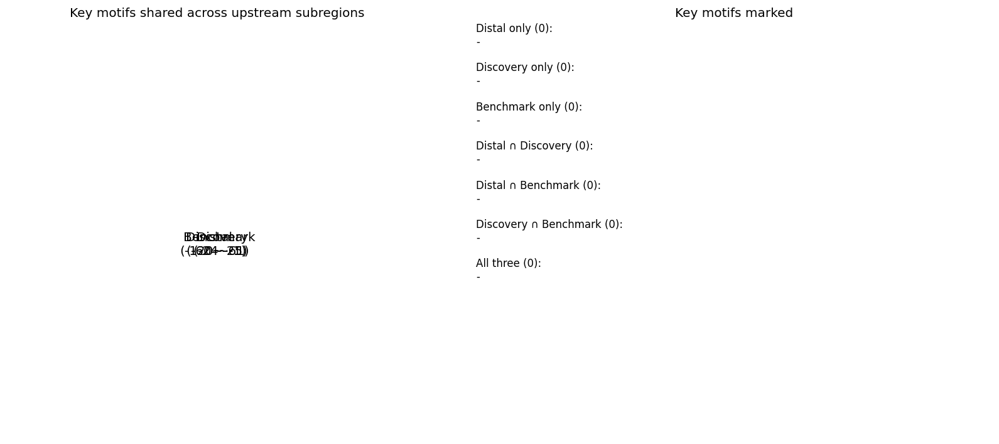

Saved to: /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/ablation_rnafm_selfattention_v2_ffmult2_wd5e4_ws9_nrun10_subsettest/motif_schemeA_fasta_v2/streme_summary


In [47]:
###找交集，找关键的motif###
import os, glob, numpy as np, pandas as pd
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import matplotlib as mpl

from matplotlib_venn import venn3

# ======================
# 路径与参数
# ======================
base = "/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/ablation_rnafm_selfattention_v2_ffmult2_wd5e4_ws9_nrun10_subsettest/motif_schemeA_fasta_v2"
out = os.path.join(base, "streme_summary")
os.makedirs(out, exist_ok=True)

regions = {
    "distal_m120_m61":   "Distal (-120~-61)",
    "discovery_m60_m25": "Discovery (-60~-25)",
    "benchmark_m24_m1":  "Benchmark (-24~-1)",
    "full_m120_m1":      "Full (-120~-1)"
}

# 关键motif定义：至少7/10个run出现，且中位test E-value < 0.05，且foreground命中率 > background命中率
min_runs_key = 7
max_evalue_key = 0.05

mpl.rcParams.update({
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False
})

# ======================
# 解析单个 streme.xml
# ======================
def parse_streme_xml(xml_file, region, run):
    root = ET.parse(xml_file).getroot()
    model = root.find("model")
    motifs = root.find("motifs")

    test_pos_total = int(model.find("test_positives").attrib["count"])
    test_neg_total = int(model.find("test_negatives").attrib["count"])

    rows = []
    for m in motifs.findall("motif"):
        # motif_key：去掉前面的"1-"、"2-"这类编号，只保留真正的motif字符串
        motif_id = m.attrib.get("id", "")
        motif_key = motif_id.split("-", 1)[1] if "-" in motif_id else motif_id

        tp = int(m.attrib.get("test_pos_count", 0))
        tn = int(m.attrib.get("test_neg_count", 0))
        fg_rate = tp / test_pos_total if test_pos_total else np.nan
        bg_rate = tn / test_neg_total if test_neg_total else np.nan

        rows.append({
            "region": region,
            "region_label": regions[region],
            "run": run,
            "motif_alt": m.attrib.get("alt", ""),
            "motif_id": motif_id,
            "motif_key": motif_key,
            "seed": m.attrib.get("seed", ""),
            "width": int(m.attrib.get("width", 0)),
            "test_pos_count": tp,
            "test_neg_count": tn,
            "test_pos_total": test_pos_total,
            "test_neg_total": test_neg_total,
            "fg_rate": fg_rate,
            "bg_rate": bg_rate,
            "enrichment": fg_rate / bg_rate if bg_rate and bg_rate > 0 else np.nan,
            "test_pvalue": float(m.attrib.get("test_pvalue", "nan")),
            "test_evalue": float(m.attrib.get("test_evalue", "nan")),
            "train_pos_count": int(m.attrib.get("train_pos_count", 0)),
            "train_neg_count": int(m.attrib.get("train_neg_count", 0)),
        })
    return pd.DataFrame(rows)

# ======================
# 读取全部结果
# ======================
dfs = []
for region in regions:
    for xml_file in glob.glob(os.path.join(base, region, "run*", "streme", "streme.xml")):
        run = os.path.basename(os.path.dirname(os.path.dirname(xml_file)))  # run00
        dfs.append(parse_streme_xml(xml_file, region, run))

detail = pd.concat(dfs, ignore_index=True)
detail.to_csv(os.path.join(out, "streme_motif_detail_all_runs.csv"), index=False)

# 每个region+run取top1 motif（按test_evalue最小）
top1 = (detail.sort_values(["region", "run", "test_evalue"])
              .groupby(["region", "run"], as_index=False)
              .first())
top1.to_csv(os.path.join(out, "streme_top1_per_run.csv"), index=False)

# ======================
# 区域内汇总
# ======================
summary = (
    detail.groupby(["region", "region_label", "motif_key"], as_index=False)
    .agg(
        n_runs=("run", "nunique"),
        runs=("run", lambda x: ",".join(sorted(x.unique()))),
        median_test_evalue=("test_evalue", "median"),
        best_test_evalue=("test_evalue", "min"),
        mean_fg_rate=("fg_rate", "mean"),
        mean_bg_rate=("bg_rate", "mean"),
        mean_enrichment=("enrichment", "mean"),
        width=("width", "median"),
        example_seed=("seed", lambda x: x.iloc[0])
    )
)

summary["key_motif"] = (
    (summary["n_runs"] >= min_runs_key) &
    (summary["median_test_evalue"] < max_evalue_key) &
    (summary["mean_fg_rate"] > summary["mean_bg_rate"])
)

summary = summary.sort_values(
    ["region", "key_motif", "n_runs", "median_test_evalue"],
    ascending=[True, False, False, True]
)
summary.to_csv(os.path.join(out, "streme_region_summary.csv"), index=False)

# 关键motif表（长表）
key_long = summary[summary["key_motif"]].copy()
key_long.to_csv(os.path.join(out, "streme_key_motifs_long.csv"), index=False)

# 关键motif表（宽表）
wide = summary.pivot_table(index="motif_key", columns="region", values="n_runs", fill_value=0)
wide = wide.rename(columns=regions).reset_index()

# full区也标出来
key_flags = summary.pivot_table(index="motif_key", columns="region", values="key_motif", fill_value=False)
for r in regions:
    if r not in key_flags.columns:
        key_flags[r] = False

key_table = wide.copy()
for r, label in regions.items():
    key_table[f"{label} key"] = key_table["motif_key"].map(key_flags[r].to_dict()).fillna(False)

key_table["n_regions_key(3sub)"] = (
    key_table["Distal (-120~-61) key"].astype(int) +
    key_table["Discovery (-60~-25) key"].astype(int) +
    key_table["Benchmark (-24~-1) key"].astype(int)
)

# 再拼一些代表性统计
best_stats = (
    summary.sort_values("median_test_evalue")
    .drop_duplicates("motif_key")
    [["motif_key", "example_seed", "median_test_evalue", "best_test_evalue", "mean_enrichment"]]
)
key_table = key_table.merge(best_stats, on="motif_key", how="left")
key_table = key_table.sort_values(
    ["n_regions_key(3sub)", "Full (-120~-1) key", "median_test_evalue"],
    ascending=[False, False, True]
)
key_table.to_csv(os.path.join(out, "streme_key_motifs_wide.csv"), index=False)

# notebook里看一下
display(top1[["region_label", "run", "motif_key", "seed", "test_evalue", "fg_rate", "bg_rate"]].head(20))
display(summary.head(20))
display(key_table.head(30))

# ======================
# 3区域韦恩图（只画 distal / discovery / benchmark）
# ======================
sets = {}
for r in ["distal_m120_m61", "discovery_m60_m25", "benchmark_m24_m1"]:
    sets[r] = set(summary[(summary["region"] == r) & (summary["key_motif"])]["motif_key"])

A, B, C = sets["distal_m120_m61"], sets["discovery_m60_m25"], sets["benchmark_m24_m1"]

venn_text = {
    "Distal only": sorted(A - B - C),
    "Discovery only": sorted(B - A - C),
    "Benchmark only": sorted(C - A - B),
    "Distal ∩ Discovery": sorted((A & B) - C),
    "Distal ∩ Benchmark": sorted((A & C) - B),
    "Discovery ∩ Benchmark": sorted((B & C) - A),
    "All three": sorted(A & B & C),
}

# 保存文本版本
rows = []
for k, v in venn_text.items():
    rows.append({"group": k, "motifs": "; ".join(v) if len(v) else ""})
pd.DataFrame(rows).to_csv(os.path.join(out, "venn_key_motif_groups.csv"), index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 左：venn
venn3(
    [A, B, C],
    set_labels=("Distal\n(-120~-61)", "Discovery\n(-60~-25)", "Benchmark\n(-24~-1)"),
    ax=axes[0]
)
axes[0].set_title("Key motifs shared across upstream subregions")

# 右：关键motif列表
axes[1].axis("off")
txt = []
for k, v in venn_text.items():
    show = ", ".join(v[:8]) if len(v) else "-"
    if len(v) > 8:
        show += " ..."
    txt.append(f"{k} ({len(v)}):\n{show}\n")
axes[1].text(0, 1, "\n".join(txt), va="top", fontsize=10)
axes[1].set_title("Key motifs marked")

fig.tight_layout()
for ext in ["pdf", "png"]:
    fig.savefig(os.path.join(out, f"Fig_key_motif_venn.{ext}"), dpi=300, bbox_inches="tight")
plt.show()

print("Saved to:", out)

,motif_family,n_runs,runs,n_motifs,example_motifs,median_evalue,best_evalue,mean_fg_rate,mean_bg_rate,mean_enrichment,region,region_label,stable_level
0,CG-rich,8,"run00,run01,run02,run03,run04,run06,run07,run08",11,CSSGCCGCG; SCGCCG; SCGGCGSS; CGGVDM; SCGCCGCG;...,0.0022,4.400000e-09,0.359354,0.155372,3.946561,distal_m120_m61,Distal (-120~-61),stable >=7/10


/tmp/ipykernel_5705/3983029683.py:175: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


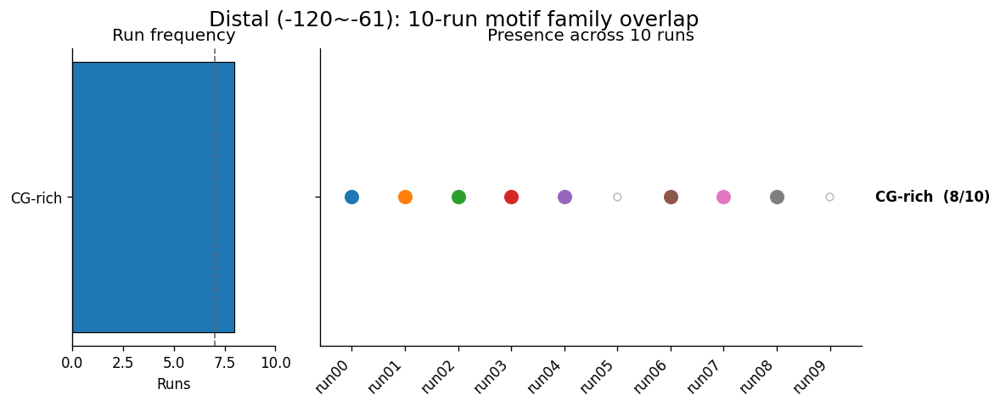

,motif_family,n_runs,runs,n_motifs,example_motifs,median_evalue,best_evalue,mean_fg_rate,mean_bg_rate,mean_enrichment,region,region_label,stable_level
0,CG-rich,7,"run00,run03,run04,run05,run06,run07,run08",9,KCGGCGCB; CGYUG; CGCBGCSGSS; CGGCG; CGCVGC; SC...,0.0063,0.00012,0.295303,0.131698,2.686086,discovery_m60_m25,Discovery (-60~-25),stable >=7/10


/tmp/ipykernel_5705/3983029683.py:175: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


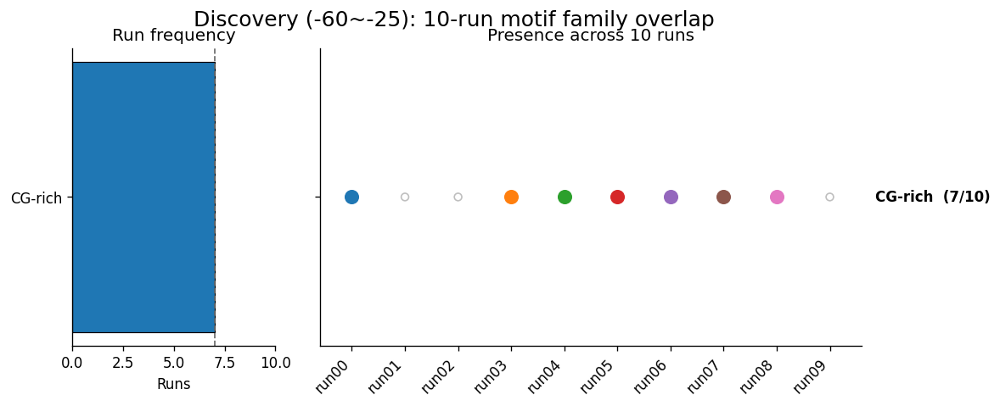

,motif_family,n_runs,runs,n_motifs,example_motifs,median_evalue,best_evalue,mean_fg_rate,mean_bg_rate,mean_enrichment,region,region_label,stable_level
0,CG-rich,6,"run00,run03,run04,run06,run08,run09",6,GCCGGCBCBG; NCGBB; GSCGSCSSGG; CBCGCG; CGSSGCS...,0.0069,0.00017,0.229677,0.092024,2.88863,benchmark_m24_m1,Benchmark (-24~-1),moderate 5-6/10


/tmp/ipykernel_5705/3983029683.py:175: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


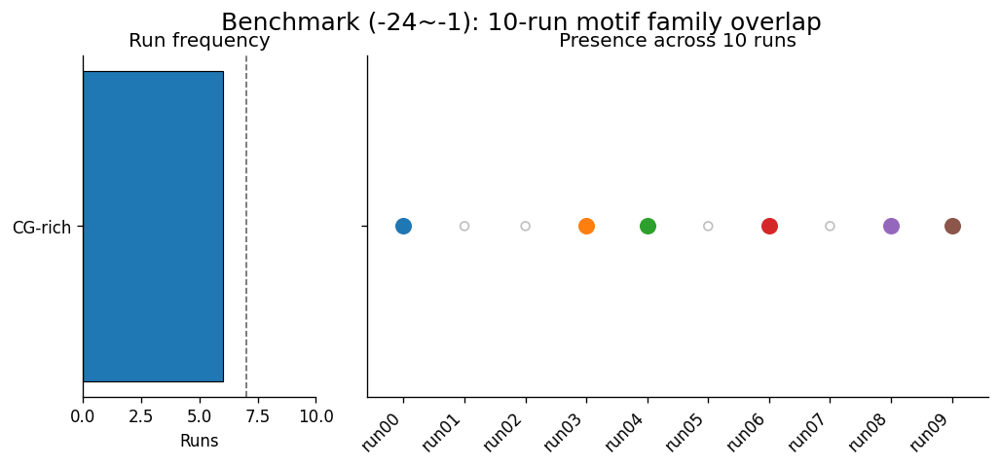

,region_label,motif_family,n_runs,stable_level,runs,median_evalue,best_evalue,mean_fg_rate,mean_bg_rate,mean_enrichment,example_motifs
0,Distal (-120~-61),CG-rich,8,stable >=7/10,"run00,run01,run02,run03,run04,run06,run07,run08",0.0022,4.400000e-09,0.359354,0.155372,3.946561,CSSGCCGCG; SCGCCG; SCGGCGSS; CGGVDM; SCGCCGCG;...
1,Discovery (-60~-25),CG-rich,7,stable >=7/10,"run00,run03,run04,run05,run06,run07,run08",0.0063,1.200000e-04,0.295303,0.131698,2.686086,KCGGCGCB; CGYUG; CGCBGCSGSS; CGGCG; CGCVGC; SC...


Saved to: /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/ablation_rnafm_selfattention_v2_ffmult2_wd5e4_ws9_nrun10_subsettest/motif_schemeA_fasta_v2/streme_10run_overlap


In [48]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# ======================
# 路径
# ======================
base = "/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/ablation_rnafm_selfattention_v2_ffmult2_wd5e4_ws9_nrun10_subsettest/motif_schemeA_fasta_v2"
in_csv = os.path.join(base, "streme_summary", "streme_motif_detail_all_runs.csv")
out = os.path.join(base, "streme_10run_overlap")
os.makedirs(out, exist_ok=True)

detail = pd.read_csv(in_csv)

mpl.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.unicode_minus": False
})

# ======================
# 区域
# ======================
regions = {
    "distal_m120_m61": "Distal (-120~-61)",
    "discovery_m60_m25": "Discovery (-60~-25)",
    "benchmark_m24_m1": "Benchmark (-24~-1)"
}

runs = [f"run{i:02d}" for i in range(10)]

# ======================
# motif family 简单分类
# ======================
def motif_family(x):
    x = str(x).upper().replace("T", "U")
    cg = sum(x.count(b) for b in "CGS")
    au = sum(x.count(b) for b in "AUW")
    n = max(len(x), 1)

    cg_patterns = ["CG", "GC", "GCG", "CGC", "CCG", "CGG", "GCC", "GGC"]
    au_patterns = ["AAAA", "UUUU", "AU", "UA", "AAU", "UAA"]

    if cg / n >= 0.60 or any(p in x for p in cg_patterns):
        return "CG-rich"
    elif au / n >= 0.60 or any(p in x for p in au_patterns):
        return "AU-rich"
    else:
        return "Mixed"

detail["motif_family"] = detail["motif_key"].apply(motif_family)

# 只保留显著且前景富集的 motif
sig = detail[
    (detail["test_evalue"] < 0.05) &
    (detail["fg_rate"] > detail["bg_rate"])
].copy()

# ======================
# 每个区域画 10-run overlap 图
# ======================
all_summary = []

for region, region_title in regions.items():

    d = sig[sig["region"] == region].copy()

    # family × run 矩阵
    mat = (
        d.groupby(["motif_family", "run"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=runs, fill_value=0)
    )

    mat = (mat > 0).astype(int)
    mat["n_runs"] = mat.sum(axis=1)

    # 汇总统计
    stat = (
        d.groupby("motif_family")
        .agg(
            n_runs=("run", "nunique"),
            runs=("run", lambda x: ",".join(sorted(x.unique()))),
            n_motifs=("motif_key", "count"),
            example_motifs=("motif_key", lambda x: "; ".join(pd.Series(x).drop_duplicates().head(10))),
            median_evalue=("test_evalue", "median"),
            best_evalue=("test_evalue", "min"),
            mean_fg_rate=("fg_rate", "mean"),
            mean_bg_rate=("bg_rate", "mean"),
            mean_enrichment=("enrichment", "mean")
        )
        .reset_index()
        .sort_values(["n_runs", "median_evalue"], ascending=[False, True])
    )

    stat["region"] = region
    stat["region_label"] = region_title
    stat["stable_level"] = np.select(
        [
            stat["n_runs"] == 10,
            stat["n_runs"] >= 7,
            stat["n_runs"] >= 5
        ],
        [
            "10/10 shared",
            "stable >=7/10",
            "moderate 5-6/10"
        ],
        default="low <5/10"
    )

    stat.to_csv(os.path.join(out, f"{region}_10run_motif_family_summary.csv"), index=False)
    all_summary.append(stat)

    display(stat)

    # 只画至少出现过的 family
    plot_mat = mat[mat["n_runs"] > 0].sort_values("n_runs", ascending=True)
    if plot_mat.empty:
        print(region_title, "没有显著 foreground-enriched motif family")
        continue

    families = plot_mat.index.tolist()
    n = len(families)

    fig = plt.figure(figsize=(10, max(3.8, 0.55 * n + 2.2)))
    gs = fig.add_gridspec(1, 2, width_ratios=[1.2, 3.2], wspace=0.12)

    ax_bar = fig.add_subplot(gs[0, 0])
    ax_mat = fig.add_subplot(gs[0, 1])

    y = np.arange(n)

    # 左侧：出现run数
    ax_bar.barh(y, plot_mat["n_runs"], edgecolor="black", linewidth=0.7)
    ax_bar.axvline(7, color="0.4", ls="--", lw=1)
    ax_bar.set_yticks(y)
    ax_bar.set_yticklabels(families)
    ax_bar.set_xlabel("Runs")
    ax_bar.set_xlim(0, 10)
    ax_bar.set_title("Run frequency")

    # 右侧：run矩阵
    for yi, fam in enumerate(families):
        for xi, run in enumerate(runs):
            if plot_mat.loc[fam, run] == 1:
                ax_mat.scatter(xi, yi, s=85)
            else:
                ax_mat.scatter(xi, yi, s=28, facecolors="none", edgecolors="0.75")

    ax_mat.set_xticks(range(10))
    ax_mat.set_xticklabels(runs, rotation=45, ha="right")
    ax_mat.set_yticks(y)
    ax_mat.set_yticklabels([])
    ax_mat.set_xlim(-0.6, 9.6)
    ax_mat.set_ylim(-0.6, n - 0.4)
    ax_mat.set_title("Presence across 10 runs")

    # 标出 stable motif
    for yi, fam in enumerate(families):
        nr = int(plot_mat.loc[fam, "n_runs"])
        if nr >= 7:
            ax_mat.text(
                9.85, yi, f"{fam}  ({nr}/10)",
                va="center", fontsize=10, fontweight="bold"
            )

    fig.suptitle(f"{region_title}: 10-run motif family overlap", fontsize=15)
    fig.tight_layout()

    for ext in ["pdf", "png"]:
        fig.savefig(
            os.path.join(out, f"Fig_{region}_10run_overlap.{ext}"),
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()
    plt.close(fig)

# ======================
# 总表
# ======================
all_summary = pd.concat(all_summary, ignore_index=True)
all_summary.to_csv(os.path.join(out, "all_regions_10run_motif_family_summary.csv"), index=False)

stable = all_summary[all_summary["n_runs"] >= 7].copy()
stable.to_csv(os.path.join(out, "stable_motif_families_ge7runs.csv"), index=False)

display(stable[[
    "region_label", "motif_family", "n_runs", "stable_level",
    "runs", "median_evalue", "best_evalue",
    "mean_fg_rate", "mean_bg_rate", "mean_enrichment",
    "example_motifs"
]])

print("Saved to:", out)

In [49]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# ======================
# 路径
# ======================
base = "/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/ablation_rnafm_selfattention_v2_ffmult2_wd5e4_ws9_nrun10_subsettest/motif_schemeA_fasta_v2"
in_csv = os.path.join(base, "streme_summary", "streme_motif_detail_all_runs.csv")
out = os.path.join(base, "streme_10run_overlap_exact")
os.makedirs(out, exist_ok=True)

detail = pd.read_csv(in_csv)

mpl.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.unicode_minus": False
})

regions = {
    "distal_m120_m61": "Distal (-120~-61)",
    "discovery_m60_m25": "Discovery (-60~-25)",
    "benchmark_m24_m1": "Benchmark (-24~-1)"
}

runs = [f"run{i:02d}" for i in range(10)]

# ======================
# exact motif 清理
# ======================
def clean_motif(x):
    x = str(x).upper().replace("T", "U")
    return x

detail["exact_motif"] = detail["motif_key"].apply(clean_motif)

# 只保留显著且前景富集的 motif
sig = detail[
    (detail["test_evalue"] < 0.05) &
    (detail["fg_rate"] > detail["bg_rate"])
].copy()

# ======================
# 每个区域做 exact motif overlap
# ======================
all_summary = []

for region, region_title in regions.items():

    d = sig[sig["region"] == region].copy()

    stat = (
        d.groupby("exact_motif")
        .agg(
            n_runs=("run", "nunique"),
            runs=("run", lambda x: ",".join(sorted(x.unique()))),
            n_records=("exact_motif", "count"),
            median_evalue=("test_evalue", "median"),
            best_evalue=("test_evalue", "min"),
            mean_fg_rate=("fg_rate", "mean"),
            mean_bg_rate=("bg_rate", "mean"),
            mean_enrichment=("enrichment", "mean"),
            example_seed=("seed", lambda x: x.iloc[0])
        )
        .reset_index()
        .sort_values(["n_runs", "median_evalue"], ascending=[False, True])
    )

    stat["region"] = region
    stat["region_label"] = region_title

    stat["stable_level"] = np.select(
        [
            stat["n_runs"] >= 7,
            stat["n_runs"] >= 5,
            stat["n_runs"] >= 3
        ],
        [
            "strong >=7/10",
            "moderate >=5/10",
            "weak >=3/10"
        ],
        default="low <3/10"
    )

    stat.to_csv(os.path.join(out, f"{region}_exact_motif_summary.csv"), index=False)
    all_summary.append(stat)

    display(stat.head(30))

    # exact motif × run 矩阵
    mat = (
        d.groupby(["exact_motif", "run"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=runs, fill_value=0)
    )
    mat = (mat > 0).astype(int)
    mat["n_runs"] = mat.sum(axis=1)

    # 只画至少2个run出现的exact motif，避免图太长
    plot_mat = mat[mat["n_runs"] >= 2].sort_values("n_runs", ascending=True)

    if plot_mat.empty:
        print(region_title, "没有 exact motif 在 ≥2 个 run 中重复出现")
        continue

    motifs = plot_mat.index.tolist()
    n = len(motifs)

    fig = plt.figure(figsize=(11, max(4.2, 0.38 * n + 2.4)))
    gs = fig.add_gridspec(1, 2, width_ratios=[1.4, 3.4], wspace=0.10)

    ax_bar = fig.add_subplot(gs[0, 0])
    ax_mat = fig.add_subplot(gs[0, 1])

    y = np.arange(n)

    # 左边：出现 run 数
    ax_bar.barh(y, plot_mat["n_runs"], edgecolor="black", linewidth=0.7)
    ax_bar.axvline(3, color="0.6", ls="--", lw=1)
    ax_bar.axvline(5, color="0.4", ls="--", lw=1)
    ax_bar.axvline(7, color="0.2", ls="--", lw=1)
    ax_bar.set_yticks(y)
    ax_bar.set_yticklabels(motifs, fontsize=9)
    ax_bar.set_xlabel("Runs")
    ax_bar.set_xlim(0, 10)
    ax_bar.set_title("Exact motif frequency")

    # 右边：run矩阵
    for yi, motif in enumerate(motifs):
        for xi, run in enumerate(runs):
            if plot_mat.loc[motif, run] == 1:
                ax_mat.scatter(xi, yi, s=70)
            else:
                ax_mat.scatter(xi, yi, s=24, facecolors="none", edgecolors="0.75")

    ax_mat.set_xticks(range(10))
    ax_mat.set_xticklabels(runs, rotation=45, ha="right")
    ax_mat.set_yticks(y)
    ax_mat.set_yticklabels([])
    ax_mat.set_xlim(-0.6, 9.6)
    ax_mat.set_ylim(-0.6, n - 0.4)
    ax_mat.set_title("Presence across 10 runs")

    # 标出 >=3/10 的 exact motif
    for yi, motif in enumerate(motifs):
        nr = int(plot_mat.loc[motif, "n_runs"])
        if nr >= 3:
            ax_mat.text(
                9.85, yi, f"{motif} ({nr}/10)",
                va="center", fontsize=9, fontweight="bold"
            )

    fig.suptitle(f"{region_title}: exact motif overlap across 10 runs", fontsize=15)
    fig.tight_layout()

    for ext in ["pdf", "png"]:
        fig.savefig(
            os.path.join(out, f"Fig_{region}_exact_motif_overlap.{ext}"),
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()
    plt.close(fig)

# ======================
# 总表
# ======================
all_summary = pd.concat(all_summary, ignore_index=True)
all_summary.to_csv(os.path.join(out, "all_regions_exact_motif_summary.csv"), index=False)

stable3 = all_summary[all_summary["n_runs"] >= 3].copy()
stable5 = all_summary[all_summary["n_runs"] >= 5].copy()
stable7 = all_summary[all_summary["n_runs"] >= 7].copy()

stable3.to_csv(os.path.join(out, "stable_exact_motifs_ge3runs.csv"), index=False)
stable5.to_csv(os.path.join(out, "stable_exact_motifs_ge5runs.csv"), index=False)
stable7.to_csv(os.path.join(out, "stable_exact_motifs_ge7runs.csv"), index=False)

display(stable3[[
    "region_label", "exact_motif", "n_runs", "stable_level",
    "runs", "median_evalue", "best_evalue",
    "mean_fg_rate", "mean_bg_rate", "mean_enrichment",
    "example_seed"
]])

print("Saved to:", out)

,exact_motif,n_runs,runs,n_records,median_evalue,best_evalue,mean_fg_rate,mean_bg_rate,mean_enrichment,example_seed,region,region_label,stable_level
6,CSSGCCGCG,1,run00,1,4.400000e-09,4.400000e-09,0.300885,0.017241,17.451327,CCCGCCGCC,distal_m120_m61,Distal (-120~-61),low <3/10
9,SCGCCGCG,1,run08,1,3.700000e-04,3.700000e-04,0.254386,0.060345,4.215539,GCGCCGCG,distal_m120_m61,Distal (-120~-61),low <3/10
3,CGGCGG,1,run08,1,5.000000e-04,5.000000e-04,0.535088,0.275862,1.939693,CGGCGG,distal_m120_m61,Distal (-120~-61),low <3/10
8,SCGCCG,1,run02,1,1.000000e-03,1.000000e-03,0.393162,0.166667,2.358974,GCGCCG,distal_m120_m61,Distal (-120~-61),low <3/10
0,CCGGC,1,run03,1,1.100000e-03,1.100000e-03,0.339130,0.128205,2.645217,CCGGC,distal_m120_m61,Distal (-120~-61),low <3/10
5,CGGVDM,1,run01,1,2.200000e-03,2.200000e-03,0.447368,0.222222,2.013158,CGGGAC,distal_m120_m61,Distal (-120~-61),low <3/10
4,CGGCSGCGCS,1,run07,1,7.200000e-03,7.200000e-03,0.226087,0.070175,3.221739,CGGCGGCGCC,distal_m120_m61,Distal (-120~-61),low <3/10
7,GCGCGGGGS,1,run06,1,8.500000e-03,8.500000e-03,0.309735,0.130435,2.374631,GCGCGGGGG,distal_m120_m61,Distal (-120~-61),low <3/10
2,CGCCGCGSS,1,run03,1,8.600000e-03,8.600000e-03,0.191304,0.051282,3.730435,CGCCGCGCU,distal_m120_m61,Distal (-120~-61),low <3/10
10,SCGGCGSS,1,run04,1,1.900000e-02,1.900000e-02,0.353982,0.177966,1.989043,GCGGCGCC,distal_m120_m61,Distal (-120~-61),low <3/10


Distal (-120~-61) 没有 exact motif 在 ≥2 个 run 中重复出现


,exact_motif,n_runs,runs,n_records,median_evalue,best_evalue,mean_fg_rate,mean_bg_rate,mean_enrichment,example_seed,region,region_label,stable_level
4,CGGCCCG,1,run07,1,0.00012,0.00012,0.246269,0.058824,4.186567,CGGCCCG,discovery_m60_m25,Discovery (-60~-25),low <3/10
7,KCGGCGCB,1,run00,1,0.00033,0.00033,0.421053,0.191176,2.202429,GCGGCGCC,discovery_m60_m25,Discovery (-60~-25),low <3/10
0,CCGCGGSSS,1,run03,1,0.00320,0.00320,0.266667,0.101449,2.628571,CCGCGGGCC,discovery_m60_m25,Discovery (-60~-25),low <3/10
5,CGGCG,1,run04,1,0.00460,0.00460,0.624060,0.414815,1.504431,CGGCG,discovery_m60_m25,Discovery (-60~-25),low <3/10
3,CGGAC,1,run06,1,0.00630,0.00630,0.250000,0.095588,2.615385,CGGAC,discovery_m60_m25,Discovery (-60~-25),low <3/10
8,SCGCGBCSGS,1,run08,1,0.01000,0.01000,0.229630,0.087591,2.621605,GCGCGCCCGC,discovery_m60_m25,Discovery (-60~-25),low <3/10
1,CGCBGCSGSS,1,run05,1,0.01400,0.01400,0.266667,0.117647,2.266667,GGCGGCGGGC,discovery_m60_m25,Discovery (-60~-25),low <3/10
2,CGCVGC,1,run04,1,0.01800,0.01800,0.203008,0.074074,2.740602,CGCAGC,discovery_m60_m25,Discovery (-60~-25),low <3/10
6,CGYUG,1,run00,1,0.02600,0.02600,0.150376,0.044118,3.408521,CGCUG,discovery_m60_m25,Discovery (-60~-25),low <3/10


Discovery (-60~-25) 没有 exact motif 在 ≥2 个 run 中重复出现


,exact_motif,n_runs,runs,n_records,median_evalue,best_evalue,mean_fg_rate,mean_bg_rate,mean_enrichment,example_seed,region,region_label,stable_level
2,GCCGGCBCBG,1,run00,1,0.00017,0.00017,0.221429,0.049645,4.460204,GCCGGCUCCG,benchmark_m24_m1,Benchmark (-24~-1),low <3/10
3,GSCGSCSSGG,1,run04,1,0.00280,0.00280,0.185714,0.049296,3.767347,GGCGCCGGGG,benchmark_m24_m1,Benchmark (-24~-1),low <3/10
0,CBCGCG,1,run08,1,0.00610,0.00610,0.250000,0.098592,2.535714,CCCGCG,benchmark_m24_m1,Benchmark (-24~-1),low <3/10
5,UCGKU,1,run03,1,0.00770,0.00770,0.070922,0.000000,NaN,UCGUU,benchmark_m24_m1,Benchmark (-24~-1),low <3/10
4,NCGBB,1,run09,1,0.02200,0.02200,0.314286,0.163121,1.926708,CCGGG,benchmark_m24_m1,Benchmark (-24~-1),low <3/10
1,CGSSGCSS,1,run06,1,0.04400,0.04400,0.335714,0.191489,1.753175,CGCCGCCG,benchmark_m24_m1,Benchmark (-24~-1),low <3/10


Benchmark (-24~-1) 没有 exact motif 在 ≥2 个 run 中重复出现


,region_label,exact_motif,n_runs,stable_level,runs,median_evalue,best_evalue,mean_fg_rate,mean_bg_rate,mean_enrichment,example_seed


Saved to: /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/ablation_rnafm_selfattention_v2_ffmult2_wd5e4_ws9_nrun10_subsettest/motif_schemeA_fasta_v2/streme_10run_overlap_exact


In [ ]:
###用 全部数据集来做 ###

In [ ]:
%%bash

SCRIPT=/disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/model_explanable/rnafm_selfattention_ablation/extract_ablation_v2_fixed_region_sequences.py
DATA_DIR=/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only

OUT_BASE=/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/ablation_rnafm_selfattention_v2_ffmult2_wd5e4_ws9_nrun10_subsettest/motif_schemeA_fasta_v3_all

mkdir -p ${OUT_BASE}

for i in $(seq 0 9); do
    RUN=$(printf "%02d" ${i})
    SEED=$((42 + i))
    PKL=${DATA_DIR}/translation_strict_lenmatched_run${RUN}.pkl

    echo "========== run${RUN} =========="

    # 1. Distal upstream: -120 ~ -61
    python ${SCRIPT} \
      --dataset_pkl ${PKL} \
      --out_dir ${OUT_BASE}/distal_m120_m61/run${RUN} \
      --region upstream \
      --start_pos -120 \
      --length 60 \
      --subset all \
      --seed ${SEED} \
      --alphabet rna \
      --seq_col upstream_seq_50nt

    # 2. Discovery region: -60 ~ -25
    python ${SCRIPT} \
      --dataset_pkl ${PKL} \
      --out_dir ${OUT_BASE}/discovery_m60_m25/run${RUN} \
      --region upstream \
      --start_pos -60 \
      --length 36 \
      --subset all \
      --seed ${SEED} \
      --alphabet rna \
      --seq_col upstream_seq_50nt

    # 3. AUG-proximal benchmark: -24 ~ -1
    python ${SCRIPT} \
      --dataset_pkl ${PKL} \
      --out_dir ${OUT_BASE}/benchmark_m24_m1/run${RUN} \
      --region upstream \
      --start_pos -24 \
      --length 24 \
      --subset all \
      --seed ${SEED} \
      --alphabet rna \
      --seq_col upstream_seq_50nt

    # 4. Full significant upstream region: -120 ~ -1
    python ${SCRIPT} \
      --dataset_pkl ${PKL} \
      --out_dir ${OUT_BASE}/full_m120_m1/run${RUN} \
      --region upstream \
      --start_pos -120 \
      --length 120 \
      --subset all \
      --seed ${SEED} \
      --alphabet rna \
      --seq_col upstream_seq_50nt

done

In [ ]:
%%bash

BASE=/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/ablation_rnafm_selfattention_v2_ffmult2_wd5e4_ws9_nrun10_subsettest/motif_schemeA_fasta_v3_all

for REGION in distal_m120_m61 discovery_m60_m25 benchmark_m24_m1 full_m120_m1; do
  echo "================ ${REGION} ================"

  for i in $(seq 0 9); do
    RUN=$(printf "run%02d" ${i})
    IN_DIR=${BASE}/${REGION}/${RUN}
    OUT_DIR=${IN_DIR}/streme

    echo "Running STREME: ${REGION} ${RUN}"

    streme \
      --p ${IN_DIR}/upstream_foreground.fa \
      --n ${IN_DIR}/upstream_background.fa \
      --rna \
      --minw 5 \
      --maxw 10 \
      --nmotifs 10 \
      --oc ${OUT_DIR}
  done
done

,region,region_label,exact_motif,n_runs,runs,n_records,median_evalue,best_evalue,mean_fg_rate,mean_bg_rate,mean_enrichment,example_seed,stable_level
20,benchmark_m24_m1,Benchmark (-24~-1),SCGCG,2,"run02,run05",2,1.100038e-12,7.600000e-17,0.353255,0.191456,1.847342,GCGCG,low <3/10
8,benchmark_m24_m1,Benchmark (-24~-1),CGSVGSBSSS,1,run06,1,1.300000e-14,1.300000e-14,0.312700,0.158228,1.976265,CGCCGCCGCG,low <3/10
11,benchmark_m24_m1,Benchmark (-24~-1),CSGSCGCGS,1,run03,1,2.100000e-13,2.100000e-13,0.283582,0.141350,2.006237,CCGCCGCGG,low <3/10
13,benchmark_m24_m1,Benchmark (-24~-1),GCGCG,1,run09,1,5.800000e-12,5.800000e-12,0.397012,0.243671,1.629295,GCGCG,low <3/10
4,benchmark_m24_m1,Benchmark (-24~-1),CGCGG,1,run01,1,7.200000e-12,7.200000e-12,0.420043,0.264768,1.586456,CGCGG,low <3/10
7,benchmark_m24_m1,Benchmark (-24~-1),CGSSSS,1,run07,1,2.000000e-11,2.000000e-11,0.360341,0.215190,1.674527,CGCGGC,low <3/10
6,benchmark_m24_m1,Benchmark (-24~-1),CGGCCGCGS,1,run08,1,8.300000e-11,8.300000e-11,0.315902,0.181435,1.741133,CGGCCGCGC,low <3/10
21,benchmark_m24_m1,Benchmark (-24~-1),SSCGCGG,1,run04,1,8.700000e-11,8.700000e-11,0.226837,0.110759,2.048015,GGCGCGG,low <3/10
19,benchmark_m24_m1,Benchmark (-24~-1),SCGCCGSGS,1,run00,1,1.700000e-07,1.700000e-07,0.207889,0.113924,1.824805,CCGCCGGGC,low <3/10
3,benchmark_m24_m1,Benchmark (-24~-1),CCUGA,1,run02,1,9.400000e-06,9.400000e-06,0.322305,0.223629,1.441252,CCUGA,low <3/10


,region,region_label,motif_family,n_runs,runs,n_records,example_motifs,median_evalue,best_evalue,mean_fg_rate,mean_bg_rate,mean_enrichment,stable_level
1,benchmark_m24_m1,Benchmark (-24~-1),CG-rich,10,"run00,run01,run02,run03,run04,run05,run06,run0...",17,SCGCCGSGS; CCUAG; CGCYU; SCGCG; CCUGA; CGYAG; ...,8.700000e-11,7.600000e-17,0.233480,0.133780,1.868207,10/10 shared
2,benchmark_m24_m1,Benchmark (-24~-1),Mixed,5,"run00,run04,run06,run07,run09",6,RSCURA; AVCUGA; CYURA; SBKMG; MSCURA; RVBUGA,2.250000e-03,9.900000e-06,0.228849,0.161920,1.466112,moderate >=5/10
0,benchmark_m24_m1,Benchmark (-24~-1),AU-rich,2,"run02,run03",2,UAARR; CBUAR,2.345000e-02,2.900000e-03,0.209027,0.154536,1.368928,low <5/10
3,discovery_m60_m25,Discovery (-60~-25),CG-rich,10,"run00,run01,run02,run03,run04,run05,run06,run0...",21,CGCGGCSSS; CCGGH; GCGGCSSCSS; CCGBN; SCGGCGCSS...,3.800000e-08,3.700000e-25,0.315625,0.182045,1.965622,10/10 shared
4,distal_m120_m61,Distal (-120~-61),CG-rich,10,"run00,run01,run02,run03,run04,run05,run06,run0...",29,CGCGSCGG; BCGGNG; CCGCC; CCGGB; CGCGGCGB; BYCG...,2.500000e-08,1.000000e-26,0.374243,0.225800,1.937753,10/10 shared
5,full_m120_m1,Full (-120~-1),CG-rich,10,"run00,run01,run02,run03,run04,run05,run06,run0...",53,CGCCGCGS; CCGSGCG; CCGGM; CGNGK; AGCUAGAG; GHC...,3.500000e-08,2.300000e-29,0.405427,0.267932,2.003355,10/10 shared
6,full_m120_m1,Full (-120~-1),Mixed,3,"run01,run02,run09",3,YUKAAG; CUGAAG,1.500000e-02,8.100000e-03,0.205462,0.147207,1.415657,low <5/10


/tmp/ipykernel_5705/2417502929.py:232: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


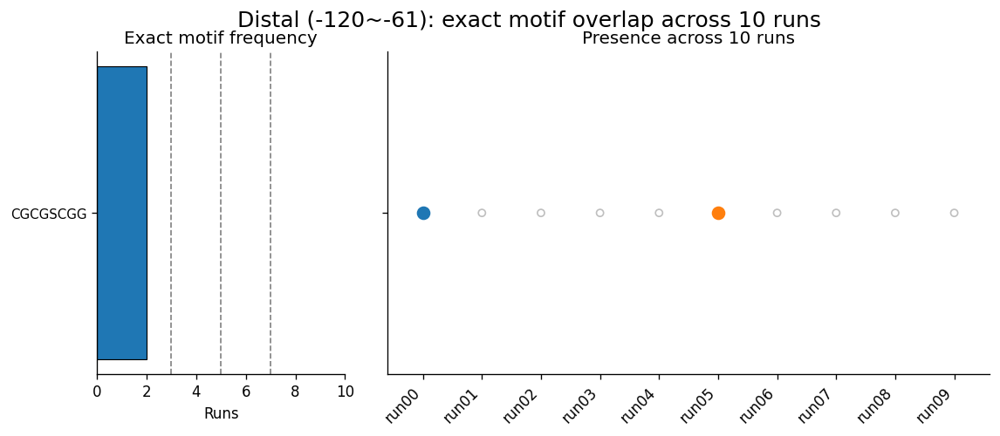

/tmp/ipykernel_5705/2417502929.py:232: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


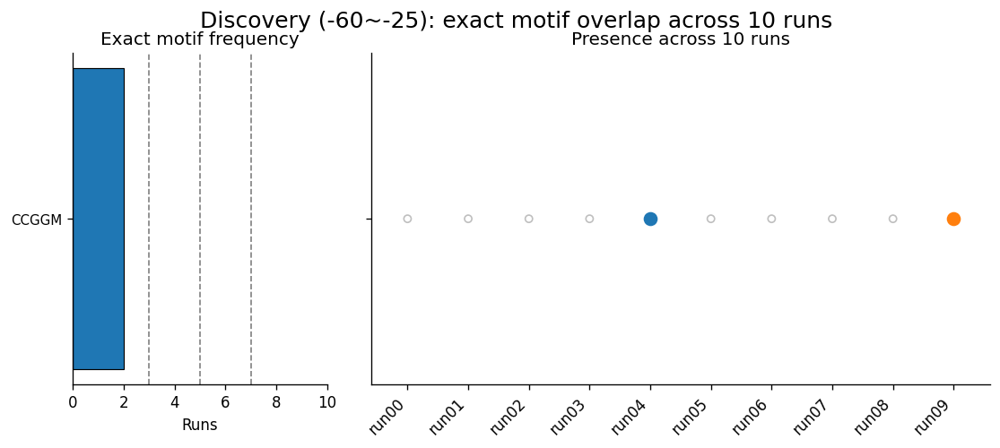

/tmp/ipykernel_5705/2417502929.py:232: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


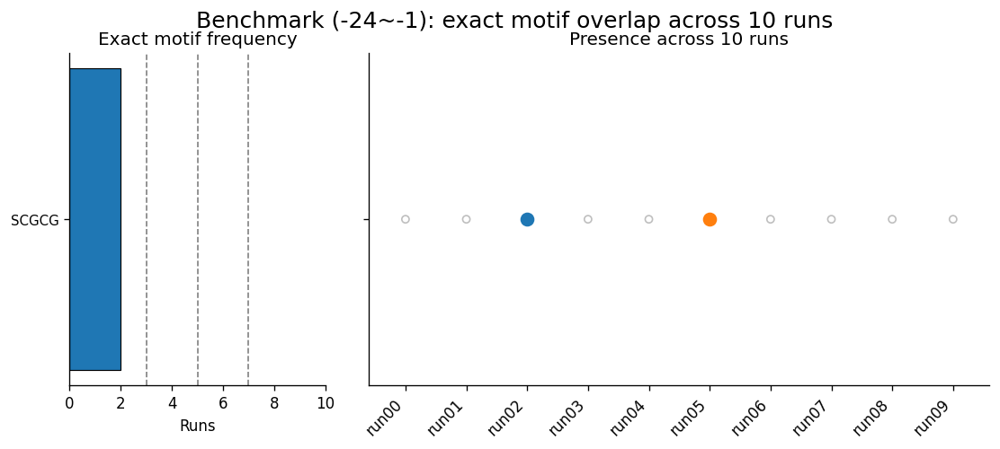

,region_label,exact_motif,n_runs,stable_level,runs,median_evalue,best_evalue,mean_fg_rate,mean_bg_rate,mean_enrichment,example_seed
79,Full (-120~-1),CCGCCG,3,weak >=3/10,"run02,run04,run05",6.700000e-25,5.600000e-29,0.393151,0.177543,2.602519,CCGCCG


Saved to: /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/ablation_rnafm_selfattention_v2_ffmult2_wd5e4_ws9_nrun10_subsettest/motif_schemeA_fasta_v3_all/streme_summary_all


In [50]:
import os, glob, numpy as np, pandas as pd
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import matplotlib as mpl

base = "/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/ablation_rnafm_selfattention_v2_ffmult2_wd5e4_ws9_nrun10_subsettest/motif_schemeA_fasta_v3_all"
out = os.path.join(base, "streme_summary_all")
os.makedirs(out, exist_ok=True)

mpl.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.unicode_minus": False
})

regions = {
    "distal_m120_m61": "Distal (-120~-61)",
    "discovery_m60_m25": "Discovery (-60~-25)",
    "benchmark_m24_m1": "Benchmark (-24~-1)",
    "full_m120_m1": "Full (-120~-1)"
}
runs = [f"run{i:02d}" for i in range(10)]

def parse_xml(xml_file, region, run):
    root = ET.parse(xml_file).getroot()
    model = root.find("model")
    tp_total = int(model.find("test_positives").attrib["count"])
    tn_total = int(model.find("test_negatives").attrib["count"])
    rows = []
    for m in root.find("motifs").findall("motif"):
        motif_id = m.attrib.get("id", "")
        motif = motif_id.split("-", 1)[1] if "-" in motif_id else motif_id
        tp = int(m.attrib.get("test_pos_count", 0))
        tn = int(m.attrib.get("test_neg_count", 0))
        fg = tp / tp_total if tp_total else np.nan
        bg = tn / tn_total if tn_total else np.nan
        rows.append({
            "region": region,
            "region_label": regions[region],
            "run": run,
            "motif_alt": m.attrib.get("alt", ""),
            "motif_id": motif_id,
            "exact_motif": motif.upper().replace("T", "U"),
            "seed": m.attrib.get("seed", "").upper().replace("T", "U"),
            "width": int(m.attrib.get("width", 0)),
            "test_pos_count": tp,
            "test_neg_count": tn,
            "test_pos_total": tp_total,
            "test_neg_total": tn_total,
            "fg_rate": fg,
            "bg_rate": bg,
            "enrichment": fg / bg if bg > 0 else np.nan,
            "test_pvalue": float(m.attrib.get("test_pvalue", "nan")),
            "test_evalue": float(m.attrib.get("test_evalue", "nan"))
        })
    return pd.DataFrame(rows)

# 1. 解析全部 STREME
dfs = []
for region in regions:
    for xml in glob.glob(os.path.join(base, region, "run*", "streme", "streme.xml")):
        run = os.path.basename(os.path.dirname(os.path.dirname(xml)))
        dfs.append(parse_xml(xml, region, run))

detail = pd.concat(dfs, ignore_index=True)
detail.to_csv(os.path.join(out, "streme_motif_detail_all.csv"), index=False)

# 2. 只保留显著且 foreground 富集的 motif
sig = detail[(detail["test_evalue"] < 0.05) & (detail["fg_rate"] > detail["bg_rate"])].copy()

# 3. exact motif 汇总
exact_summary = (
    sig.groupby(["region", "region_label", "exact_motif"], as_index=False)
    .agg(
        n_runs=("run", "nunique"),
        runs=("run", lambda x: ",".join(sorted(x.unique()))),
        n_records=("exact_motif", "count"),
        median_evalue=("test_evalue", "median"),
        best_evalue=("test_evalue", "min"),
        mean_fg_rate=("fg_rate", "mean"),
        mean_bg_rate=("bg_rate", "mean"),
        mean_enrichment=("enrichment", "mean"),
        example_seed=("seed", lambda x: x.iloc[0])
    )
)

exact_summary["stable_level"] = np.select(
    [
        exact_summary["n_runs"] >= 7,
        exact_summary["n_runs"] >= 5,
        exact_summary["n_runs"] >= 3
    ],
    [
        "strong >=7/10",
        "moderate >=5/10",
        "weak >=3/10"
    ],
    default="low <3/10"
)

exact_summary = exact_summary.sort_values(
    ["region", "n_runs", "median_evalue"],
    ascending=[True, False, True]
)

exact_summary.to_csv(os.path.join(out, "exact_motif_summary_all.csv"), index=False)

# 4. motif family 汇总
def motif_family(x):
    x = str(x).upper().replace("T", "U")
    cg = sum(x.count(b) for b in "CGS")
    au = sum(x.count(b) for b in "AUW")
    n = max(len(x), 1)
    if cg / n >= 0.60 or any(p in x for p in ["CG", "GC", "GCG", "CGC", "CCG", "CGG", "GCC", "GGC"]):
        return "CG-rich"
    elif au / n >= 0.60 or any(p in x for p in ["AAAA", "UUUU", "AU", "UA", "AAU", "UAA"]):
        return "AU-rich"
    else:
        return "Mixed"

sig["motif_family"] = sig["exact_motif"].apply(motif_family)

family_summary = (
    sig.groupby(["region", "region_label", "motif_family"], as_index=False)
    .agg(
        n_runs=("run", "nunique"),
        runs=("run", lambda x: ",".join(sorted(x.unique()))),
        n_records=("exact_motif", "count"),
        example_motifs=("exact_motif", lambda x: "; ".join(pd.Series(x).drop_duplicates().head(10))),
        median_evalue=("test_evalue", "median"),
        best_evalue=("test_evalue", "min"),
        mean_fg_rate=("fg_rate", "mean"),
        mean_bg_rate=("bg_rate", "mean"),
        mean_enrichment=("enrichment", "mean")
    )
)

family_summary["stable_level"] = np.select(
    [
        family_summary["n_runs"] == 10,
        family_summary["n_runs"] >= 7,
        family_summary["n_runs"] >= 5
    ],
    [
        "10/10 shared",
        "stable >=7/10",
        "moderate >=5/10"
    ],
    default="low <5/10"
)

family_summary = family_summary.sort_values(
    ["region", "n_runs", "median_evalue"],
    ascending=[True, False, True]
)

family_summary.to_csv(os.path.join(out, "motif_family_summary_all.csv"), index=False)

display(exact_summary.head(30))
display(family_summary)

# 5. 画 3 个主要区域的 exact motif 10-run overlap
plot_regions = {
    "distal_m120_m61": "Distal (-120~-61)",
    "discovery_m60_m25": "Discovery (-60~-25)",
    "benchmark_m24_m1": "Benchmark (-24~-1)"
}

for region, title in plot_regions.items():
    d = sig[sig["region"] == region].copy()

    mat = (
        d.groupby(["exact_motif", "run"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=runs, fill_value=0)
    )
    mat = (mat > 0).astype(int)
    mat["n_runs"] = mat.sum(axis=1)

    plot_mat = mat[mat["n_runs"] >= 2].sort_values("n_runs", ascending=True)

    if plot_mat.empty:
        print(title, "no exact motif repeated in >=2 runs")
        continue

    motifs = plot_mat.index.tolist()
    n = len(motifs)

    fig = plt.figure(figsize=(11, max(4, 0.38 * n + 2.3)))
    gs = fig.add_gridspec(1, 2, width_ratios=[1.4, 3.4], wspace=0.10)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])

    y = np.arange(n)

    ax1.barh(y, plot_mat["n_runs"], edgecolor="black", linewidth=0.7)
    for x in [3, 5, 7]:
        ax1.axvline(x, color="0.5", ls="--", lw=1)
    ax1.set_yticks(y)
    ax1.set_yticklabels(motifs, fontsize=9)
    ax1.set_xlabel("Runs")
    ax1.set_xlim(0, 10)
    ax1.set_title("Exact motif frequency")

    for yi, motif in enumerate(motifs):
        for xi, run in enumerate(runs):
            if plot_mat.loc[motif, run] == 1:
                ax2.scatter(xi, yi, s=70)
            else:
                ax2.scatter(xi, yi, s=24, facecolors="none", edgecolors="0.75")

    ax2.set_xticks(range(10))
    ax2.set_xticklabels(runs, rotation=45, ha="right")
    ax2.set_yticks(y)
    ax2.set_yticklabels([])
    ax2.set_xlim(-0.6, 9.6)
    ax2.set_ylim(-0.6, n - 0.4)
    ax2.set_title("Presence across 10 runs")

    for yi, motif in enumerate(motifs):
        nr = int(plot_mat.loc[motif, "n_runs"])
        if nr >= 3:
            ax2.text(9.85, yi, f"{motif} ({nr}/10)",
                     va="center", fontsize=9, fontweight="bold")

    fig.suptitle(f"{title}: exact motif overlap across 10 runs", fontsize=15)
    fig.tight_layout()

    for ext in ["pdf", "png"]:
        fig.savefig(os.path.join(out, f"Fig_{region}_exact_motif_overlap.{ext}"),
                    dpi=300, bbox_inches="tight")

    plt.show()
    plt.close(fig)

# 6. 输出稳定 motif 表
stable_exact = exact_summary[exact_summary["n_runs"] >= 3].copy()
stable_family = family_summary[family_summary["n_runs"] >= 5].copy()

stable_exact.to_csv(os.path.join(out, "stable_exact_motifs_ge3runs_all.csv"), index=False)
stable_family.to_csv(os.path.join(out, "stable_motif_families_ge5runs_all.csv"), index=False)

display(stable_exact[[
    "region_label", "exact_motif", "n_runs", "stable_level",
    "runs", "median_evalue", "best_evalue",
    "mean_fg_rate", "mean_bg_rate", "mean_enrichment", "example_seed"
]])

print("Saved to:", out)

/tmp/ipykernel_5705/275977175.py:223: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.96])


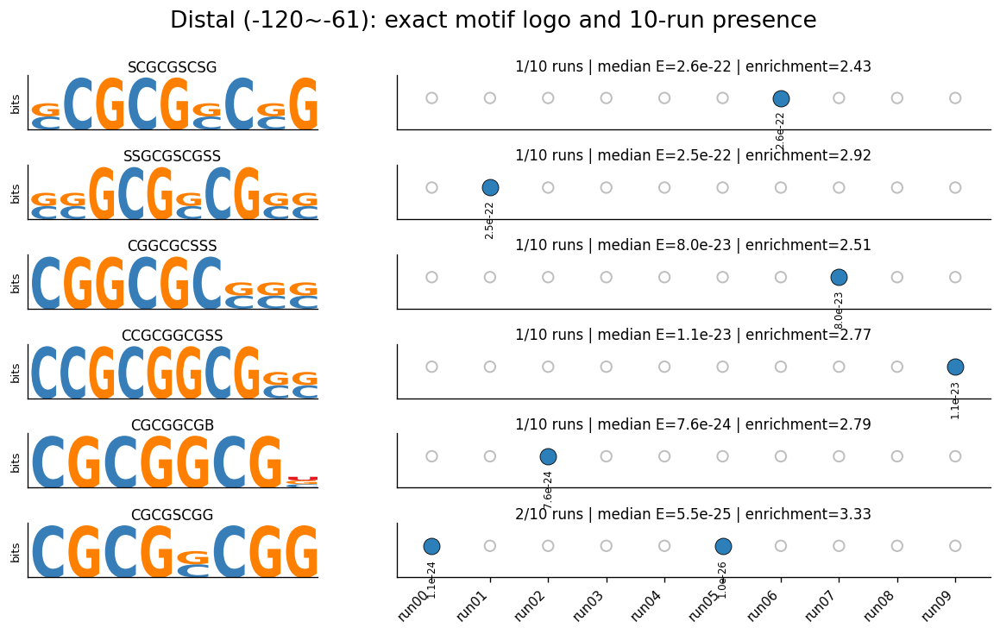

/tmp/ipykernel_5705/275977175.py:223: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.96])


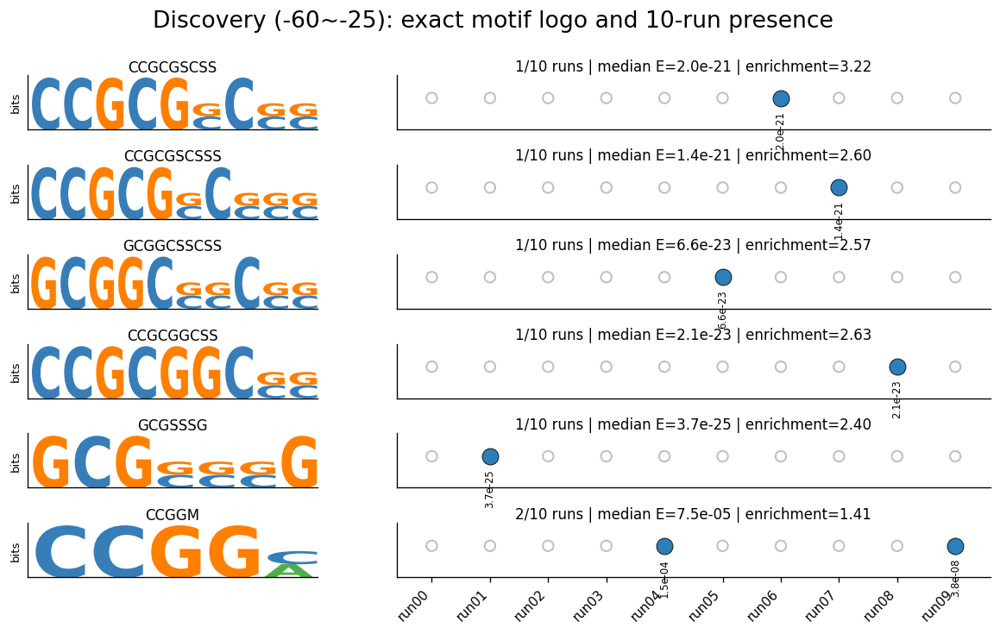

/tmp/ipykernel_5705/275977175.py:223: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.96])


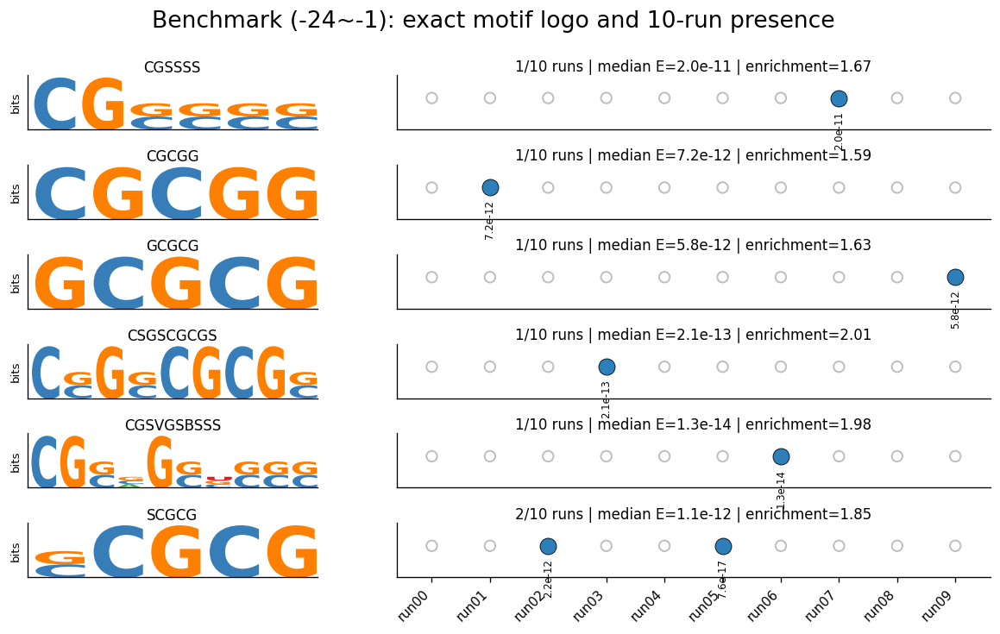

/tmp/ipykernel_5705/275977175.py:223: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.96])


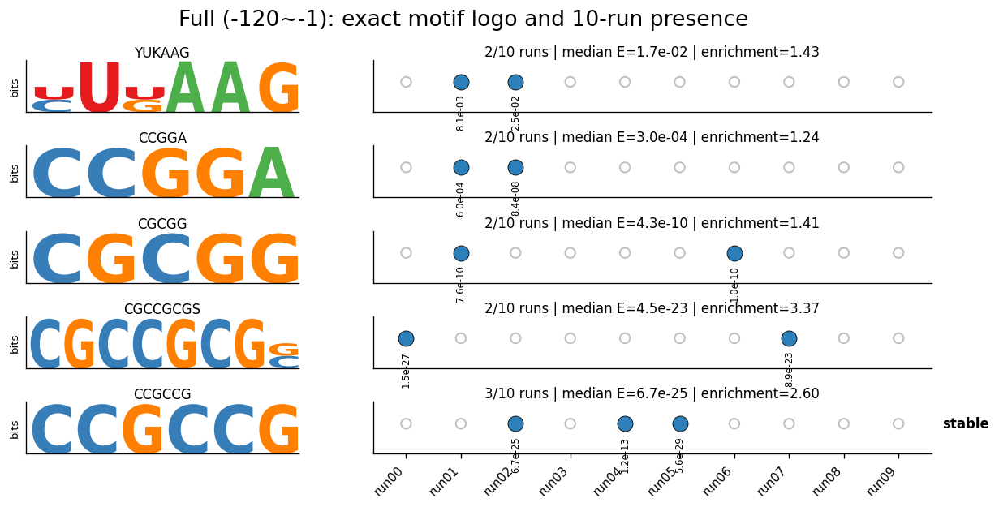

Saved to: /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/ablation_rnafm_selfattention_v2_ffmult2_wd5e4_ws9_nrun10_subsettest/motif_schemeA_fasta_v3_all/motif_logo_run_presence_v2


In [52]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.textpath import TextPath
from matplotlib.patches import PathPatch
from matplotlib.transforms import Affine2D
from matplotlib.font_manager import FontProperties

# ======================
# path
# ======================
base = "/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/ablation_rnafm_selfattention_v2_ffmult2_wd5e4_ws9_nrun10_subsettest/motif_schemeA_fasta_v3_all"
summary_dir = os.path.join(base, "streme_summary_all")
out = os.path.join(base, "motif_logo_run_presence_v2")
os.makedirs(out, exist_ok=True)

detail = pd.read_csv(os.path.join(summary_dir, "streme_motif_detail_all.csv"))
exact = pd.read_csv(os.path.join(summary_dir, "exact_motif_summary_all.csv"))

mpl.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.unicode_minus": False
})

regions = {
    "distal_m120_m61": "Distal (-120~-61)",
    "discovery_m60_m25": "Discovery (-60~-25)",
    "benchmark_m24_m1": "Benchmark (-24~-1)",
    "full_m120_m1": "Full (-120~-1)"
}

runs = [f"run{i:02d}" for i in range(10)]

# ======================
# IUPAC -> PWM
# ======================
iupac = {
    "A": {"A": 1},
    "C": {"C": 1},
    "G": {"G": 1},
    "U": {"U": 1},
    "T": {"U": 1},
    "R": {"A": 0.5, "G": 0.5},
    "Y": {"C": 0.5, "U": 0.5},
    "S": {"C": 0.5, "G": 0.5},
    "W": {"A": 0.5, "U": 0.5},
    "K": {"G": 0.5, "U": 0.5},
    "M": {"A": 0.5, "C": 0.5},
    "B": {"C": 1/3, "G": 1/3, "U": 1/3},
    "D": {"A": 1/3, "G": 1/3, "U": 1/3},
    "H": {"A": 1/3, "C": 1/3, "U": 1/3},
    "V": {"A": 1/3, "C": 1/3, "G": 1/3},
    "N": {"A": 0.25, "C": 0.25, "G": 0.25, "U": 0.25}
}

colors = {
    "A": "#4daf4a",
    "C": "#377eb8",
    "G": "#ff7f00",
    "U": "#e41a1c"
}

fp = FontProperties(family="DejaVu Sans", weight="bold")

def pwm_from_iupac(motif):
    motif = str(motif).upper().replace("T", "U")
    rows = []
    for ch in motif:
        p = {b: 0 for b in "ACGU"}
        p.update(iupac.get(ch, iupac["N"]))
        rows.append(p)
    return pd.DataFrame(rows)

def draw_letter(ax, letter, x, y, height, color):
    if height <= 0:
        return
    tp = TextPath((0, 0), letter, size=1, prop=fp)
    bb = tp.get_extents()
    sx = 0.85 / bb.width
    sy = height / bb.height
    trans = Affine2D().scale(sx, sy).translate(x + 0.075, y)
    patch = PathPatch(tp, transform=trans + ax.transData, color=color, lw=0)
    ax.add_patch(patch)

def draw_logo(ax, motif):
    pwm = pwm_from_iupac(motif)
    for i, row in pwm.iterrows():
        probs = np.array([row[b] for b in "ACGU"], dtype=float)
        probs = probs / probs.sum()
        entropy = -np.sum([p * np.log2(p) for p in probs if p > 0])
        info = 2 - entropy
        heights = {b: row[b] * info for b in "ACGU"}
        y = 0
        for b, h in sorted(heights.items(), key=lambda x: x[1]):
            draw_letter(ax, b, i, y, h, colors[b])
            y += h

    ax.set_xlim(0, len(motif))
    ax.set_ylim(0, 2.05)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_ylabel("bits", fontsize=8)
    ax.set_title(motif, fontsize=10, pad=2)

# ======================
# significant motifs
# ======================
sig = detail[
    (detail["test_evalue"] < 0.05) &
    (detail["fg_rate"] > detail["bg_rate"])
].copy()

# ======================
# plot: logo + run presence
# ======================
for region, title in regions.items():

    stat = exact[exact["region"] == region].copy()
    stat = stat.sort_values(["n_runs", "median_evalue"], ascending=[False, True])

    keep = stat[stat["n_runs"] >= 2].copy()
    if len(keep) < 3:
        keep = pd.concat([keep, stat.head(6)], axis=0).drop_duplicates("exact_motif")

    keep = keep.sort_values(["n_runs", "median_evalue"], ascending=[True, False])
    motifs = keep["exact_motif"].tolist()

    if len(motifs) == 0:
        print(title, "no motif to plot")
        continue

    n = len(motifs)
    fig = plt.figure(figsize=(12, max(4, 1.05 * n)))
    gs = fig.add_gridspec(
        nrows=n,
        ncols=2,
        width_ratios=[2.2, 4.5],
        wspace=0.18,
        hspace=0.65
    )

    for yi, motif in enumerate(motifs):

        # left: motif logo
        ax_logo = fig.add_subplot(gs[yi, 0])
        draw_logo(ax_logo, motif)

        # right: run presence
        ax_run = fig.add_subplot(gs[yi, 1])

        d = sig[
            (sig["region"] == region) &
            (sig["exact_motif"] == motif)
        ].copy()

        present_runs = set(d["run"])

        for xi, run in enumerate(runs):
            if run in present_runs:
                tmp = d[d["run"] == run].sort_values("test_evalue").iloc[0]
                ax_run.scatter(
                    xi, 0,
                    s=130,
                    color="#2c7fb8",
                    edgecolor="black",
                    linewidth=0.5
                )
                ax_run.text(
                    xi, -0.25,
                    f"{tmp['test_evalue']:.1e}",
                    ha="center",
                    va="top",
                    rotation=90,
                    fontsize=7
                )
            else:
                ax_run.scatter(
                    xi, 0,
                    s=55,
                    facecolors="none",
                    edgecolors="0.75",
                    linewidth=1.2
                )

        nr = int(stat.loc[stat["exact_motif"] == motif, "n_runs"].iloc[0])
        med_e = float(stat.loc[stat["exact_motif"] == motif, "median_evalue"].iloc[0])
        enrich = float(stat.loc[stat["exact_motif"] == motif, "mean_enrichment"].iloc[0])

        ax_run.set_xlim(-0.6, 9.6)
        ax_run.set_ylim(-0.62, 0.45)
        ax_run.set_yticks([])

        # 只有最底下一行显示 run 标签
        ax_run.set_xticks(range(10))
        if yi == n - 1:
            ax_run.set_xticklabels(runs, rotation=45, ha="right", fontsize=9)
        else:
            ax_run.set_xticklabels([])
            ax_run.tick_params(axis="x", length=0)

        ax_run.set_title(
            f"{nr}/10 runs | median E={med_e:.1e} | enrichment={enrich:.2f}",
            fontsize=10,
            pad=3
        )

        if nr >= 3:
            ax_run.text(
                9.8, 0,
                "stable",
                va="center",
                fontsize=10,
                fontweight="bold"
            )

    fig.suptitle(f"{title}: exact motif logo and 10-run presence", fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.96])

    for ext in ["pdf", "png"]:
        fig.savefig(
            os.path.join(out, f"Fig_{region}_exact_motif_logo_presence_v2.{ext}"),
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()
    plt.close(fig)

print("Saved to:", out)

In [ ]:
###找出所有的motif，而不是nmotifs=10###

%%bash

BASE=/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/ablation_rnafm_selfattention_v2_ffmult2_wd5e4_ws9_nrun10_subsettest/motif_schemeA_fasta_v3_all

for REGION in distal_m120_m61 discovery_m60_m25 benchmark_m24_m1 full_m120_m1; do
  echo "================ ${REGION} ================"

  for i in $(seq 0 9); do
    RUN=$(printf "run%02d" ${i})
    IN_DIR=${BASE}/${REGION}/${RUN}
    OUT_DIR=${IN_DIR}/streme_nmotifs_all

    echo "Running STREME: ${REGION} ${RUN}"

    streme \
      --p ${IN_DIR}/upstream_foreground.fa \
      --n ${IN_DIR}/upstream_background.fa \
      --rna \
      --minw 5 \
      --maxw 10 \
      --oc ${OUT_DIR}
  done
done

,region,region_label,exact_motif,n_runs,runs,n_records,median_evalue,best_evalue,mean_fg_rate,mean_bg_rate,mean_enrichment,example_seed,stable_level
22,benchmark_m24_m1,Benchmark (-24~-1),SCGCG,2,"run02,run05",2,9.000230e-13,4.600000e-17,0.353255,0.191456,1.847342,GCGCG,low <3/10
4,benchmark_m24_m1,Benchmark (-24~-1),CCUAG,2,"run00,run02",2,1.335000e-02,7.700000e-03,0.072524,0.040084,1.840549,CCUAG,low <3/10
5,benchmark_m24_m1,Benchmark (-24~-1),CCUGA,2,"run01,run02",2,2.400375e-02,7.500000e-06,0.253903,0.183017,1.371941,CCUGA,low <3/10
12,benchmark_m24_m1,Benchmark (-24~-1),CGYCU,2,"run03,run08",2,3.650000e-02,3.200000e-02,0.051735,0.027426,1.895767,CGCCU,low <3/10
10,benchmark_m24_m1,Benchmark (-24~-1),CGSVGSBSSS,1,run06,1,7.900000e-15,7.900000e-15,0.312700,0.158228,1.976265,CGCCGCCGCG,low <3/10
13,benchmark_m24_m1,Benchmark (-24~-1),CSGSCGCGS,1,run03,1,1.700000e-13,1.700000e-13,0.283582,0.141350,2.006237,CCGCCGCGG,low <3/10
16,benchmark_m24_m1,Benchmark (-24~-1),GCGCG,1,run09,1,3.500000e-12,3.500000e-12,0.397012,0.243671,1.629295,GCGCG,low <3/10
6,benchmark_m24_m1,Benchmark (-24~-1),CGCGG,1,run01,1,5.100000e-12,5.100000e-12,0.420043,0.264768,1.586456,CGCGG,low <3/10
9,benchmark_m24_m1,Benchmark (-24~-1),CGSSSS,1,run07,1,1.600000e-11,1.600000e-11,0.360341,0.215190,1.674527,CGCGGC,low <3/10
23,benchmark_m24_m1,Benchmark (-24~-1),SSCGCGG,1,run04,1,6.100000e-11,6.100000e-11,0.226837,0.110759,2.048015,GGCGCGG,low <3/10


,region,region_label,motif_family,n_runs,runs,n_records,example_motifs,median_evalue,best_evalue,mean_fg_rate,mean_bg_rate,mean_enrichment,stable_level
1,benchmark_m24_m1,Benchmark (-24~-1),CG-rich,10,"run00,run01,run02,run03,run04,run05,run06,run0...",21,SCGCCGSGS; CCUAG; CGCYU; SCGCG; CCUGA; CGYAG; ...,7.500000e-06,4.600000e-17,0.202866,0.116888,1.881060,10/10 shared
2,benchmark_m24_m1,Benchmark (-24~-1),Mixed,5,"run00,run04,run06,run07,run09",6,RSCURA; AVCUGA; CYURA; SBKMG; MSCURA; RVBUGA,1.750000e-03,5.900000e-06,0.228849,0.161920,1.466112,moderate >=5/10
0,benchmark_m24_m1,Benchmark (-24~-1),AU-rich,1,run03,1,CBUAR,2.300000e-03,2.300000e-03,0.282516,0.213080,1.325867,low <5/10
3,discovery_m60_m25,Discovery (-60~-25),CG-rich,10,"run00,run01,run02,run03,run04,run05,run06,run0...",23,CGCGGCSSS; CCGGH; GCGGCSSCSS; CCGBN; SCGGCGCSS...,5.500000e-08,2.900000e-25,0.292242,0.168896,1.976037,10/10 shared
4,distal_m120_m61,Distal (-120~-61),CG-rich,10,"run00,run01,run02,run03,run04,run05,run06,run0...",30,CGCGSCGG; BCGGNG; CCGCC; CCGGB; CGCGGCGB; BYCG...,4.200000e-08,8.200000e-27,0.363372,0.219047,1.942215,10/10 shared
6,full_m120_m1,Full (-120~-1),CG-rich,10,"run00,run01,run02,run03,run04,run05,run06,run0...",55,CGCCGCGS; CCGSGCG; CCGGM; CGNGK; AGCUAGAG; GHC...,1.000000e-07,2.500000e-29,0.396075,0.261823,1.825755,10/10 shared
7,full_m120_m1,Full (-120~-1),Mixed,4,"run01,run02,run06,run09",4,YUKAAG; CUGAAG,1.350000e-02,4.100000e-03,0.199935,0.140152,1.447654,low <5/10
5,full_m120_m1,Full (-120~-1),AU-rich,1,run05,1,CUGAA,4.400000e-02,4.400000e-02,0.265280,0.206718,1.283290,low <5/10


/tmp/ipykernel_141396/395427300.py:232: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


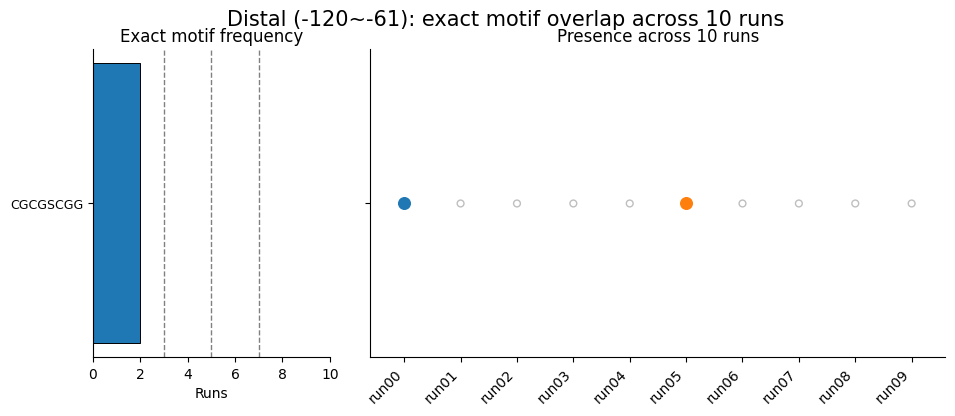

/tmp/ipykernel_141396/395427300.py:232: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


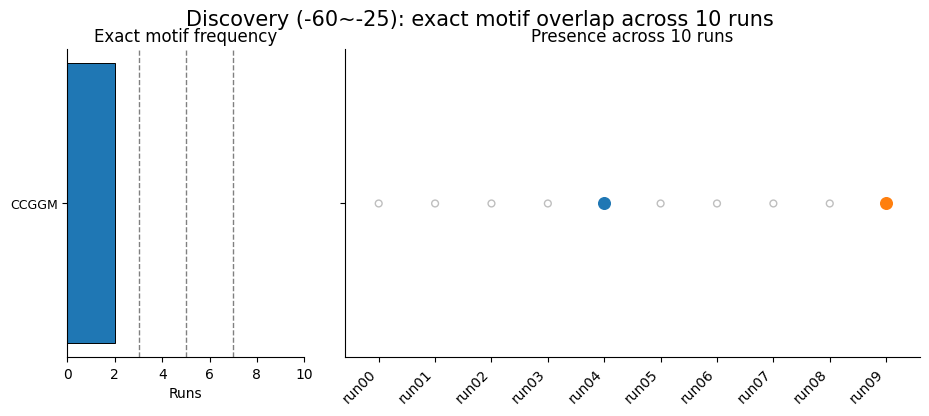

/tmp/ipykernel_141396/395427300.py:232: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


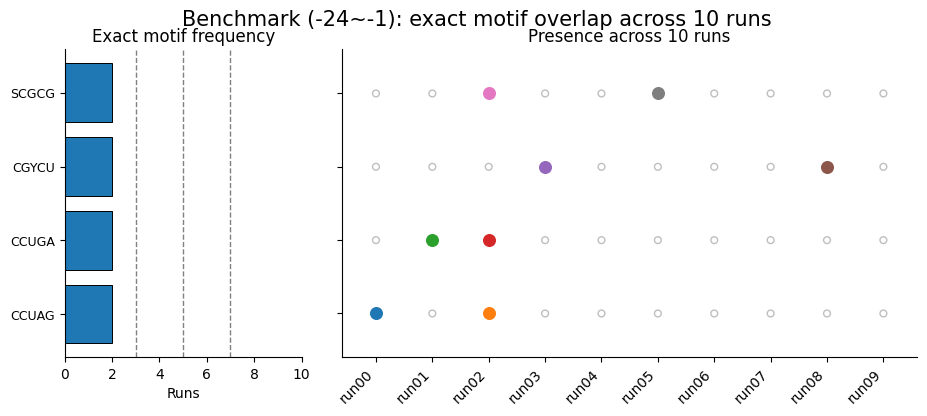

,region_label,exact_motif,n_runs,stable_level,runs,median_evalue,best_evalue,mean_fg_rate,mean_bg_rate,mean_enrichment,example_seed
84,Full (-120~-1),CCGCCG,3,weak >=3/10,"run02,run04,run05",8.100000e-25,6.100000e-29,0.393151,0.177543,2.602519,CCGCCG
117,Full (-120~-1),CUGAAG,3,weak >=3/10,"run01,run06,run09",1.200000e-02,4.100000e-03,0.185089,0.125364,1.488558,CUGAAG


Saved to: /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/ablation_rnafm_selfattention_v2_ffmult2_wd5e4_ws9_nrun10_subsettest/motif_schemeA_fasta_v3_all/streme_nmotifs_all_summary_all


In [1]:
import os, glob, numpy as np, pandas as pd
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import matplotlib as mpl

base = "/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/ablation_rnafm_selfattention_v2_ffmult2_wd5e4_ws9_nrun10_subsettest/motif_schemeA_fasta_v3_all"
out = os.path.join(base, "streme_nmotifs_all_summary_all")
os.makedirs(out, exist_ok=True)

mpl.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.unicode_minus": False
})

regions = {
    "distal_m120_m61": "Distal (-120~-61)",
    "discovery_m60_m25": "Discovery (-60~-25)",
    "benchmark_m24_m1": "Benchmark (-24~-1)",
    "full_m120_m1": "Full (-120~-1)"
}
runs = [f"run{i:02d}" for i in range(10)]

def parse_xml(xml_file, region, run):
    root = ET.parse(xml_file).getroot()
    model = root.find("model")
    tp_total = int(model.find("test_positives").attrib["count"])
    tn_total = int(model.find("test_negatives").attrib["count"])
    rows = []
    for m in root.find("motifs").findall("motif"):
        motif_id = m.attrib.get("id", "")
        motif = motif_id.split("-", 1)[1] if "-" in motif_id else motif_id
        tp = int(m.attrib.get("test_pos_count", 0))
        tn = int(m.attrib.get("test_neg_count", 0))
        fg = tp / tp_total if tp_total else np.nan
        bg = tn / tn_total if tn_total else np.nan
        rows.append({
            "region": region,
            "region_label": regions[region],
            "run": run,
            "motif_alt": m.attrib.get("alt", ""),
            "motif_id": motif_id,
            "exact_motif": motif.upper().replace("T", "U"),
            "seed": m.attrib.get("seed", "").upper().replace("T", "U"),
            "width": int(m.attrib.get("width", 0)),
            "test_pos_count": tp,
            "test_neg_count": tn,
            "test_pos_total": tp_total,
            "test_neg_total": tn_total,
            "fg_rate": fg,
            "bg_rate": bg,
            "enrichment": fg / bg if bg > 0 else np.nan,
            "test_pvalue": float(m.attrib.get("test_pvalue", "nan")),
            "test_evalue": float(m.attrib.get("test_evalue", "nan"))
        })
    return pd.DataFrame(rows)

# 1. 解析全部 STREME
dfs = []
for region in regions:
    for xml in glob.glob(os.path.join(base, region, "run*", "streme_nmotifs_all", "streme.xml")):
        run = os.path.basename(os.path.dirname(os.path.dirname(xml)))
        dfs.append(parse_xml(xml, region, run))

detail = pd.concat(dfs, ignore_index=True)
detail.to_csv(os.path.join(out, "streme_motif_detail_all.csv"), index=False)

# 2. 只保留显著且 foreground 富集的 motif
sig = detail[(detail["test_evalue"] < 0.05) & (detail["fg_rate"] > detail["bg_rate"])].copy()

# 3. exact motif 汇总
exact_summary = (
    sig.groupby(["region", "region_label", "exact_motif"], as_index=False)
    .agg(
        n_runs=("run", "nunique"),
        runs=("run", lambda x: ",".join(sorted(x.unique()))),
        n_records=("exact_motif", "count"),
        median_evalue=("test_evalue", "median"),
        best_evalue=("test_evalue", "min"),
        mean_fg_rate=("fg_rate", "mean"),
        mean_bg_rate=("bg_rate", "mean"),
        mean_enrichment=("enrichment", "mean"),
        example_seed=("seed", lambda x: x.iloc[0])
    )
)

exact_summary["stable_level"] = np.select(
    [
        exact_summary["n_runs"] >= 7,
        exact_summary["n_runs"] >= 5,
        exact_summary["n_runs"] >= 3
    ],
    [
        "strong >=7/10",
        "moderate >=5/10",
        "weak >=3/10"
    ],
    default="low <3/10"
)

exact_summary = exact_summary.sort_values(
    ["region", "n_runs", "median_evalue"],
    ascending=[True, False, True]
)

exact_summary.to_csv(os.path.join(out, "exact_motif_summary_all.csv"), index=False)

# 4. motif family 汇总
def motif_family(x):
    x = str(x).upper().replace("T", "U")
    cg = sum(x.count(b) for b in "CGS")
    au = sum(x.count(b) for b in "AUW")
    n = max(len(x), 1)
    if cg / n >= 0.60 or any(p in x for p in ["CG", "GC", "GCG", "CGC", "CCG", "CGG", "GCC", "GGC"]):
        return "CG-rich"
    elif au / n >= 0.60 or any(p in x for p in ["AAAA", "UUUU", "AU", "UA", "AAU", "UAA"]):
        return "AU-rich"
    else:
        return "Mixed"

sig["motif_family"] = sig["exact_motif"].apply(motif_family)

family_summary = (
    sig.groupby(["region", "region_label", "motif_family"], as_index=False)
    .agg(
        n_runs=("run", "nunique"),
        runs=("run", lambda x: ",".join(sorted(x.unique()))),
        n_records=("exact_motif", "count"),
        example_motifs=("exact_motif", lambda x: "; ".join(pd.Series(x).drop_duplicates().head(10))),
        median_evalue=("test_evalue", "median"),
        best_evalue=("test_evalue", "min"),
        mean_fg_rate=("fg_rate", "mean"),
        mean_bg_rate=("bg_rate", "mean"),
        mean_enrichment=("enrichment", "mean")
    )
)

family_summary["stable_level"] = np.select(
    [
        family_summary["n_runs"] == 10,
        family_summary["n_runs"] >= 7,
        family_summary["n_runs"] >= 5
    ],
    [
        "10/10 shared",
        "stable >=7/10",
        "moderate >=5/10"
    ],
    default="low <5/10"
)

family_summary = family_summary.sort_values(
    ["region", "n_runs", "median_evalue"],
    ascending=[True, False, True]
)

family_summary.to_csv(os.path.join(out, "motif_family_summary_all.csv"), index=False)

display(exact_summary.head(30))
display(family_summary)

# 5. 画 3 个主要区域的 exact motif 10-run overlap
plot_regions = {
    "distal_m120_m61": "Distal (-120~-61)",
    "discovery_m60_m25": "Discovery (-60~-25)",
    "benchmark_m24_m1": "Benchmark (-24~-1)"
}

for region, title in plot_regions.items():
    d = sig[sig["region"] == region].copy()

    mat = (
        d.groupby(["exact_motif", "run"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=runs, fill_value=0)
    )
    mat = (mat > 0).astype(int)
    mat["n_runs"] = mat.sum(axis=1)

    plot_mat = mat[mat["n_runs"] >= 2].sort_values("n_runs", ascending=True)

    if plot_mat.empty:
        print(title, "no exact motif repeated in >=2 runs")
        continue

    motifs = plot_mat.index.tolist()
    n = len(motifs)

    fig = plt.figure(figsize=(11, max(4, 0.38 * n + 2.3)))
    gs = fig.add_gridspec(1, 2, width_ratios=[1.4, 3.4], wspace=0.10)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])

    y = np.arange(n)

    ax1.barh(y, plot_mat["n_runs"], edgecolor="black", linewidth=0.7)
    for x in [3, 5, 7]:
        ax1.axvline(x, color="0.5", ls="--", lw=1)
    ax1.set_yticks(y)
    ax1.set_yticklabels(motifs, fontsize=9)
    ax1.set_xlabel("Runs")
    ax1.set_xlim(0, 10)
    ax1.set_title("Exact motif frequency")

    for yi, motif in enumerate(motifs):
        for xi, run in enumerate(runs):
            if plot_mat.loc[motif, run] == 1:
                ax2.scatter(xi, yi, s=70)
            else:
                ax2.scatter(xi, yi, s=24, facecolors="none", edgecolors="0.75")

    ax2.set_xticks(range(10))
    ax2.set_xticklabels(runs, rotation=45, ha="right")
    ax2.set_yticks(y)
    ax2.set_yticklabels([])
    ax2.set_xlim(-0.6, 9.6)
    ax2.set_ylim(-0.6, n - 0.4)
    ax2.set_title("Presence across 10 runs")

    for yi, motif in enumerate(motifs):
        nr = int(plot_mat.loc[motif, "n_runs"])
        if nr >= 3:
            ax2.text(9.85, yi, f"{motif} ({nr}/10)",
                     va="center", fontsize=9, fontweight="bold")

    fig.suptitle(f"{title}: exact motif overlap across 10 runs", fontsize=15)
    fig.tight_layout()

    for ext in ["pdf", "png"]:
        fig.savefig(os.path.join(out, f"Fig_{region}_exact_motif_overlap.{ext}"),
                    dpi=300, bbox_inches="tight")

    plt.show()
    plt.close(fig)

# 6. 输出稳定 motif 表
stable_exact = exact_summary[exact_summary["n_runs"] >= 3].copy()
stable_family = family_summary[family_summary["n_runs"] >= 5].copy()

stable_exact.to_csv(os.path.join(out, "stable_exact_motifs_ge3runs_all.csv"), index=False)
stable_family.to_csv(os.path.join(out, "stable_motif_families_ge5runs_all.csv"), index=False)

display(stable_exact[[
    "region_label", "exact_motif", "n_runs", "stable_level",
    "runs", "median_evalue", "best_evalue",
    "mean_fg_rate", "mean_bg_rate", "mean_enrichment", "example_seed"
]])

print("Saved to:", out)

/tmp/ipykernel_141396/3901029075.py:223: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.96])


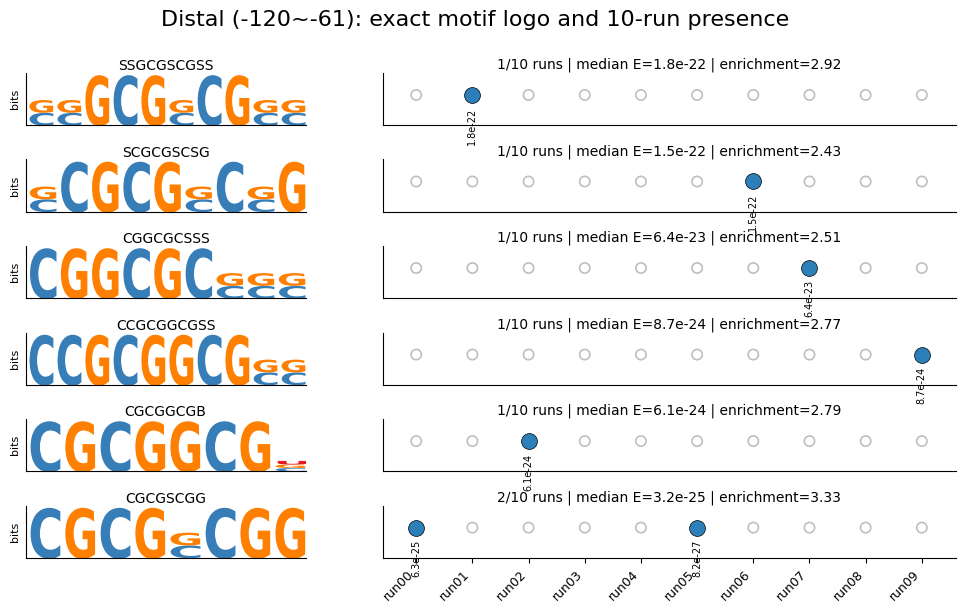

/tmp/ipykernel_141396/3901029075.py:223: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.96])


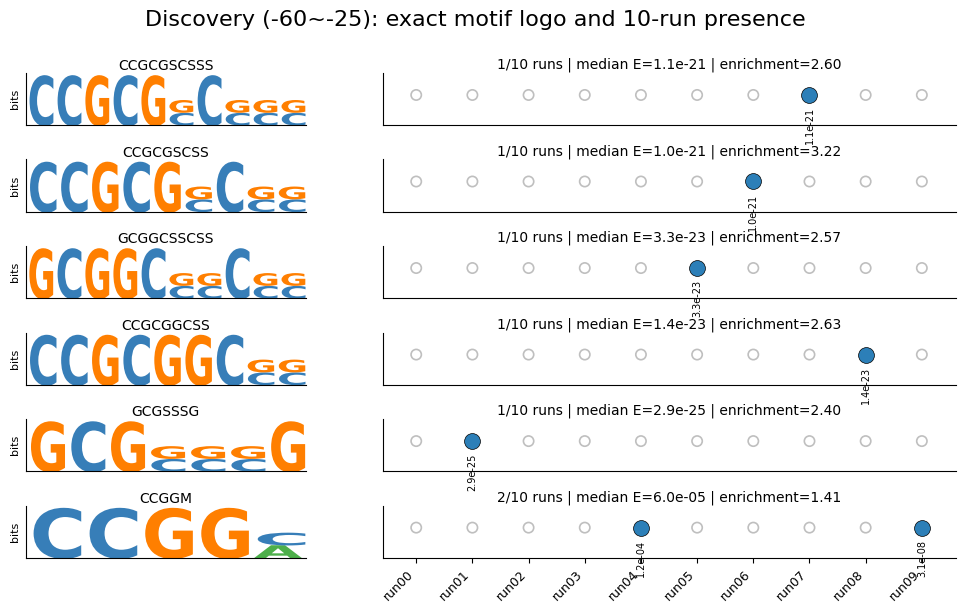

/tmp/ipykernel_141396/3901029075.py:223: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.96])


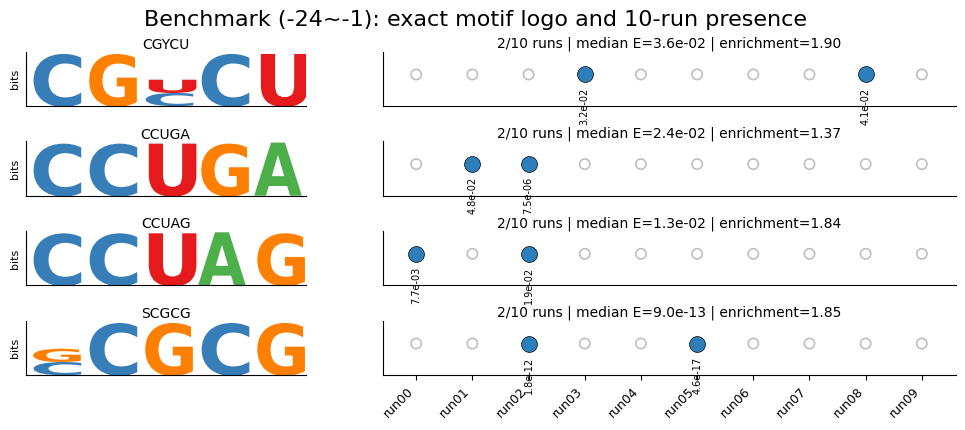

/tmp/ipykernel_141396/3901029075.py:223: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.96])


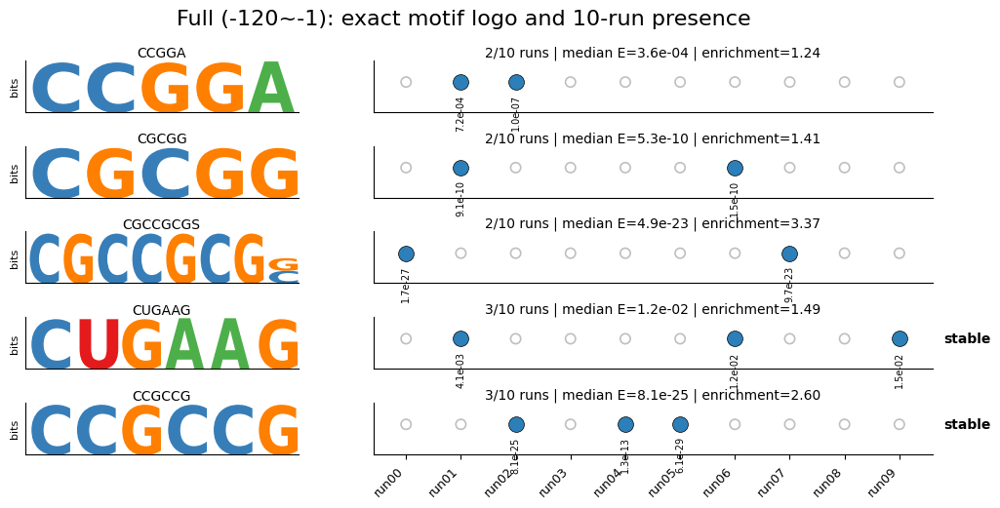

Saved to: /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/ablation_rnafm_selfattention_v2_ffmult2_wd5e4_ws9_nrun10_subsettest/motif_schemeA_fasta_v3_all/motif_logo_run_presence_v3_nmotifs_all


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.textpath import TextPath
from matplotlib.patches import PathPatch
from matplotlib.transforms import Affine2D
from matplotlib.font_manager import FontProperties

# ======================
# path
# ======================
base = "/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/ablation_rnafm_selfattention_v2_ffmult2_wd5e4_ws9_nrun10_subsettest/motif_schemeA_fasta_v3_all"
summary_dir = os.path.join(base, "streme_nmotifs_all_summary_all")
out = os.path.join(base, "motif_logo_run_presence_v3_nmotifs_all")
os.makedirs(out, exist_ok=True)

detail = pd.read_csv(os.path.join(summary_dir, "streme_motif_detail_all.csv"))
exact = pd.read_csv(os.path.join(summary_dir, "exact_motif_summary_all.csv"))

mpl.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.unicode_minus": False
})

regions = {
    "distal_m120_m61": "Distal (-120~-61)",
    "discovery_m60_m25": "Discovery (-60~-25)",
    "benchmark_m24_m1": "Benchmark (-24~-1)",
    "full_m120_m1": "Full (-120~-1)"
}

runs = [f"run{i:02d}" for i in range(10)]

# ======================
# IUPAC -> PWM
# ======================
iupac = {
    "A": {"A": 1},
    "C": {"C": 1},
    "G": {"G": 1},
    "U": {"U": 1},
    "T": {"U": 1},
    "R": {"A": 0.5, "G": 0.5},
    "Y": {"C": 0.5, "U": 0.5},
    "S": {"C": 0.5, "G": 0.5},
    "W": {"A": 0.5, "U": 0.5},
    "K": {"G": 0.5, "U": 0.5},
    "M": {"A": 0.5, "C": 0.5},
    "B": {"C": 1/3, "G": 1/3, "U": 1/3},
    "D": {"A": 1/3, "G": 1/3, "U": 1/3},
    "H": {"A": 1/3, "C": 1/3, "U": 1/3},
    "V": {"A": 1/3, "C": 1/3, "G": 1/3},
    "N": {"A": 0.25, "C": 0.25, "G": 0.25, "U": 0.25}
}

colors = {
    "A": "#4daf4a",
    "C": "#377eb8",
    "G": "#ff7f00",
    "U": "#e41a1c"
}

fp = FontProperties(family="DejaVu Sans", weight="bold")

def pwm_from_iupac(motif):
    motif = str(motif).upper().replace("T", "U")
    rows = []
    for ch in motif:
        p = {b: 0 for b in "ACGU"}
        p.update(iupac.get(ch, iupac["N"]))
        rows.append(p)
    return pd.DataFrame(rows)

def draw_letter(ax, letter, x, y, height, color):
    if height <= 0:
        return
    tp = TextPath((0, 0), letter, size=1, prop=fp)
    bb = tp.get_extents()
    sx = 0.85 / bb.width
    sy = height / bb.height
    trans = Affine2D().scale(sx, sy).translate(x + 0.075, y)
    patch = PathPatch(tp, transform=trans + ax.transData, color=color, lw=0)
    ax.add_patch(patch)

def draw_logo(ax, motif):
    pwm = pwm_from_iupac(motif)
    for i, row in pwm.iterrows():
        probs = np.array([row[b] for b in "ACGU"], dtype=float)
        probs = probs / probs.sum()
        entropy = -np.sum([p * np.log2(p) for p in probs if p > 0])
        info = 2 - entropy
        heights = {b: row[b] * info for b in "ACGU"}
        y = 0
        for b, h in sorted(heights.items(), key=lambda x: x[1]):
            draw_letter(ax, b, i, y, h, colors[b])
            y += h

    ax.set_xlim(0, len(motif))
    ax.set_ylim(0, 2.05)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_ylabel("bits", fontsize=8)
    ax.set_title(motif, fontsize=10, pad=2)

# ======================
# significant motifs
# ======================
sig = detail[
    (detail["test_evalue"] < 0.05) &
    (detail["fg_rate"] > detail["bg_rate"])
].copy()

# ======================
# plot: logo + run presence
# ======================
for region, title in regions.items():

    stat = exact[exact["region"] == region].copy()
    stat = stat.sort_values(["n_runs", "median_evalue"], ascending=[False, True])

    keep = stat[stat["n_runs"] >= 2].copy()
    if len(keep) < 3:
        keep = pd.concat([keep, stat.head(6)], axis=0).drop_duplicates("exact_motif")

    keep = keep.sort_values(["n_runs", "median_evalue"], ascending=[True, False])
    motifs = keep["exact_motif"].tolist()

    if len(motifs) == 0:
        print(title, "no motif to plot")
        continue

    n = len(motifs)
    fig = plt.figure(figsize=(12, max(4, 1.05 * n)))
    gs = fig.add_gridspec(
        nrows=n,
        ncols=2,
        width_ratios=[2.2, 4.5],
        wspace=0.18,
        hspace=0.65
    )

    for yi, motif in enumerate(motifs):

        # left: motif logo
        ax_logo = fig.add_subplot(gs[yi, 0])
        draw_logo(ax_logo, motif)

        # right: run presence
        ax_run = fig.add_subplot(gs[yi, 1])

        d = sig[
            (sig["region"] == region) &
            (sig["exact_motif"] == motif)
        ].copy()

        present_runs = set(d["run"])

        for xi, run in enumerate(runs):
            if run in present_runs:
                tmp = d[d["run"] == run].sort_values("test_evalue").iloc[0]
                ax_run.scatter(
                    xi, 0,
                    s=130,
                    color="#2c7fb8",
                    edgecolor="black",
                    linewidth=0.5
                )
                ax_run.text(
                    xi, -0.25,
                    f"{tmp['test_evalue']:.1e}",
                    ha="center",
                    va="top",
                    rotation=90,
                    fontsize=7
                )
            else:
                ax_run.scatter(
                    xi, 0,
                    s=55,
                    facecolors="none",
                    edgecolors="0.75",
                    linewidth=1.2
                )

        nr = int(stat.loc[stat["exact_motif"] == motif, "n_runs"].iloc[0])
        med_e = float(stat.loc[stat["exact_motif"] == motif, "median_evalue"].iloc[0])
        enrich = float(stat.loc[stat["exact_motif"] == motif, "mean_enrichment"].iloc[0])

        ax_run.set_xlim(-0.6, 9.6)
        ax_run.set_ylim(-0.62, 0.45)
        ax_run.set_yticks([])

        # 只有最底下一行显示 run 标签
        ax_run.set_xticks(range(10))
        if yi == n - 1:
            ax_run.set_xticklabels(runs, rotation=45, ha="right", fontsize=9)
        else:
            ax_run.set_xticklabels([])
            ax_run.tick_params(axis="x", length=0)

        ax_run.set_title(
            f"{nr}/10 runs | median E={med_e:.1e} | enrichment={enrich:.2f}",
            fontsize=10,
            pad=3
        )

        if nr >= 3:
            ax_run.text(
                9.8, 0,
                "stable",
                va="center",
                fontsize=10,
                fontweight="bold"
            )

    fig.suptitle(f"{title}: exact motif logo and 10-run presence", fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.96])

    for ext in ["pdf", "png"]:
        fig.savefig(
            os.path.join(out, f"Fig_{region}_exact_motif_logo_presence_v2.{ext}"),
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()
    plt.close(fig)

print("Saved to:", out)

In [8]:
###lgbm baseline###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/run_10runs_and_summary.py \
  --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_rnafm_lgbm_baseline.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only \
  --dataset_prefix translation_strict_lenmatched \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_lgbm_10runs \
  --run_name_prefix rnafm_lgbm \
  --n_runs 10 \
  --batch_size 64 \
  --epochs 50 \
  --dropout 0.2 \
  --lr 1e-4 \
  --weight_decay 5e-4 \
  --ff_mult 2


Running: rnafm_lgbm_run00
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_rnafm_lgbm_baseline.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only/translation_strict_lenmatched_run00.pkl --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_lgbm_10runs/rnafm_lgbm_run00 --run_name rnafm_lgbm_run00 --seed 42 --epochs 50 --batch_size 64 --lr 0.0001 --weight_decay 0.0005 --patience 10 --num_workers 2 --dropout 0.2 --branch_hidden_dim 256 --fusion_hidden_dim 256 --num_heads 16 --num_layers 2 --ff_mult 2 --valid_size 0.15 --test_size 0.15 --grad_clip 1.0
2026-06-28 16:58:21,386 | INFO | args: {'dataset_pkl': '/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only/translation_strict_lenmatched_run00.pkl', 'out_dir': '/disk4hu

In [12]:
##CNN baseline##
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/run_10runs_and_summary.py \
  --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_rnafm_cnn_baseline.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only \
  --dataset_prefix translation_strict_lenmatched \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_cnn_10runs \
  --run_name_prefix rnafm_cnn \
  --n_runs 10 \
  --batch_size 512 \
  --epochs 50 \
  --dropout 0.2 \
  --lr 1e-4 \
  --weight_decay 5e-4 \
  --branch_hidden_dim 128 \
  --fusion_hidden_dim 256 \
  --ff_mult 2


Running: rnafm_cnn_run00
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_rnafm_cnn_baseline.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only/translation_strict_lenmatched_run00.pkl --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_cnn_10runs/rnafm_cnn_run00 --run_name rnafm_cnn_run00 --seed 42 --epochs 50 --batch_size 512 --lr 0.0001 --weight_decay 0.0005 --patience 10 --num_workers 2 --dropout 0.2 --branch_hidden_dim 128 --fusion_hidden_dim 256 --num_heads 16 --num_layers 2 --ff_mult 2 --valid_size 0.15 --test_size 0.15 --grad_clip 1.0
2026-06-28 21:31:30,080 | INFO | args: {'dataset_pkl': '/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only/translation_strict_lenmatched_run00.pkl', 'out_dir': '/disk4hu/hej

In [ ]:
### add more baseline ###
#LR原版，慢#
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/run_10runs_and_summary.py \
  --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_rnafm_lr_baseline.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only \
  --dataset_prefix translation_strict_lenmatched \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_lr_10runs \
  --run_name_prefix rnafm_lr \
  --n_runs 10 \
  --batch_size 64 \
  --epochs 50 \
  --dropout 0.2 \
  --lr 1e-4 \
  --weight_decay 5e-4 \
  --ff_mult 2


Running: rnafm_lr_run00
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_rnafm_lr_baseline.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only/translation_strict_lenmatched_run00.pkl --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_lr_10runs/rnafm_lr_run00 --run_name rnafm_lr_run00 --seed 42 --epochs 50 --batch_size 64 --lr 0.0001 --weight_decay 0.0005 --patience 10 --num_workers 2 --dropout 0.2 --branch_hidden_dim 256 --fusion_hidden_dim 256 --num_heads 16 --num_layers 2 --ff_mult 2 --valid_size 0.15 --test_size 0.15 --grad_clip 1.0
2026-07-09 13:28:37,402 | INFO | args: {'dataset_pkl': '/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only/translation_strict_lenmatched_run00.pkl', 'out_dir': '/disk4hu/hejp/00_t

In [ ]:
#多线程LR#
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/run_10runs_and_summary.py \
  --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_rnafm_lr_fast_sgd_parallel_baseline.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only \
  --dataset_prefix translation_strict_lenmatched \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_lr_fast_sgd_parallel_10runs \
  --run_name_prefix rnafm_lr_fast_sgd_parallel \
  --n_runs 10 \
  --batch_size 64 \
  --epochs 50 \
  --dropout 0.2 \
  --lr 1e-4 \
  --weight_decay 5e-4 \
  --ff_mult 2 \
  --num_workers 82


Running: rnafm_lr_fast_sgd_parallel_run00
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_rnafm_lr_fast_sgd_parallel_baseline.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only/translation_strict_lenmatched_run00.pkl --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_lr_fast_sgd_parallel_10runs/rnafm_lr_fast_sgd_parallel_run00 --run_name rnafm_lr_fast_sgd_parallel_run00 --seed 42 --epochs 50 --batch_size 64 --lr 0.0001 --weight_decay 0.0005 --patience 10 --num_workers 82 --dropout 0.2 --branch_hidden_dim 256 --fusion_hidden_dim 256 --num_heads 16 --num_layers 2 --ff_mult 2 --valid_size 0.15 --test_size 0.15 --grad_clip 1.0
2026-07-09 14:56:55,328 | INFO | args: {'dataset_pkl': '/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/traini

In [ ]:
#多线程MLP#
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/run_10runs_and_summary.py \
  --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_rnafm_mlp_pool_gpu_baseline.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only \
  --dataset_prefix translation_strict_lenmatched \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_mlp_pool_gpu_10runs \
  --run_name_prefix rnafm_mlp_pool_gpu \
  --n_runs 10 \
  --batch_size 512 \
  --epochs 50 \
  --dropout 0.2 \
  --lr 1e-4 \
  --weight_decay 5e-4 \
  --fusion_hidden_dim 256 \
  --ff_mult 2 \
  --num_workers 32


Running: rnafm_mlp_pool_gpu_run00
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_rnafm_mlp_pool_gpu_baseline.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only/translation_strict_lenmatched_run00.pkl --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_mlp_pool_gpu_10runs/rnafm_mlp_pool_gpu_run00 --run_name rnafm_mlp_pool_gpu_run00 --seed 42 --epochs 50 --batch_size 512 --lr 0.0001 --weight_decay 0.0005 --patience 10 --num_workers 32 --dropout 0.2 --branch_hidden_dim 256 --fusion_hidden_dim 256 --num_heads 16 --num_layers 2 --ff_mult 2 --valid_size 0.15 --test_size 0.15 --grad_clip 1.0
2026-07-09 15:27:22,351 | INFO | args: {'dataset_pkl': '/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only/translation_strict_l

In [ ]:
#多线程SVM#
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/run_10runs_and_summary.py \
  --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_rnafm_svm_parallel_baseline.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only \
  --dataset_prefix translation_strict_lenmatched \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_svm_parallel_10runs \
  --run_name_prefix rnafm_svm_parallel \
  --n_runs 10 \
  --batch_size 64 \
  --epochs 50 \
  --dropout 0.2 \
  --lr 1e-4 \
  --weight_decay 5e-4 \
  --ff_mult 2 \
  --num_workers 82


Running: rnafm_svm_parallel_run00
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_rnafm_svm_parallel_baseline.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only/translation_strict_lenmatched_run00.pkl --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_svm_parallel_10runs/rnafm_svm_parallel_run00 --run_name rnafm_svm_parallel_run00 --seed 42 --epochs 50 --batch_size 64 --lr 0.0001 --weight_decay 0.0005 --patience 10 --num_workers 82 --dropout 0.2 --branch_hidden_dim 256 --fusion_hidden_dim 256 --num_heads 16 --num_layers 2 --ff_mult 2 --valid_size 0.15 --test_size 0.15 --grad_clip 1.0
2026-07-09 16:27:17,793 | INFO | args: {'dataset_pkl': '/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only/translation_strict_le

In [9]:
##LGBM##
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/run_10runs_and_summary.py \
  --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_rnafm_lgbm_parallel_baseline.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only \
  --dataset_prefix translation_strict_lenmatched \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_lgbm_v2_parallel_10runs \
  --run_name_prefix rnafm_lgbm_parallel \
  --n_runs 10 \
  --batch_size 64 \
  --epochs 50 \
  --dropout 0.2 \
  --lr 1e-4 \
  --weight_decay 5e-4 \
  --ff_mult 2 \
  --num_workers 72


Running: rnafm_lgbm_parallel_run00
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_rnafm_lgbm_parallel_baseline.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only/translation_strict_lenmatched_run00.pkl --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_lgbm_v2_parallel_10runs/rnafm_lgbm_parallel_run00 --run_name rnafm_lgbm_parallel_run00 --seed 42 --epochs 50 --batch_size 64 --lr 0.0001 --weight_decay 0.0005 --patience 10 --num_workers 72 --dropout 0.2 --branch_hidden_dim 256 --fusion_hidden_dim 256 --num_heads 16 --num_layers 2 --ff_mult 2 --valid_size 0.15 --test_size 0.15 --grad_clip 1.0
2026-07-09 21:00:28,314 | INFO | args: {'dataset_pkl': '/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only/translation_s

In [10]:
##Random Forest##
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/run_10runs_and_summary.py \
  --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_rnafm_rf_parallel_baseline.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only \
  --dataset_prefix translation_strict_lenmatched \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_rf_parallel_10runs \
  --run_name_prefix rnafm_rf_parallel \
  --n_runs 10 \
  --batch_size 64 \
  --epochs 50 \
  --dropout 0.2 \
  --lr 1e-4 \
  --weight_decay 5e-4 \
  --ff_mult 2 \
  --num_workers 72


Running: rnafm_rf_parallel_run00
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_rnafm_rf_parallel_baseline.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only/translation_strict_lenmatched_run00.pkl --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_rf_parallel_10runs/rnafm_rf_parallel_run00 --run_name rnafm_rf_parallel_run00 --seed 42 --epochs 50 --batch_size 64 --lr 0.0001 --weight_decay 0.0005 --patience 10 --num_workers 72 --dropout 0.2 --branch_hidden_dim 256 --fusion_hidden_dim 256 --num_heads 16 --num_layers 2 --ff_mult 2 --valid_size 0.15 --test_size 0.15 --grad_clip 1.0
2026-07-09 21:16:39,332 | INFO | args: {'dataset_pkl': '/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only/translation_strict_lenmatc

In [13]:
##CNN V2##
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/run_10runs_and_summary.py \
  --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_rnafm_cnn_baseline.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only \
  --dataset_prefix translation_strict_lenmatched \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_cnn_v2_10runs \
  --run_name_prefix rnafm_cnn \
  --n_runs 10 \
  --batch_size 512 \
  --epochs 50 \
  --dropout 0.2 \
  --lr 1e-4 \
  --weight_decay 5e-4 \
  --branch_hidden_dim 128 \
  --fusion_hidden_dim 256 \
  --ff_mult 2 \
  --num_workers 2


Running: rnafm_cnn_run00
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_rnafm_cnn_baseline.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only/translation_strict_lenmatched_run00.pkl --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_cnn_v2_10runs/rnafm_cnn_run00 --run_name rnafm_cnn_run00 --seed 42 --epochs 50 --batch_size 512 --lr 0.0001 --weight_decay 0.0005 --patience 10 --num_workers 2 --dropout 0.2 --branch_hidden_dim 128 --fusion_hidden_dim 256 --num_heads 16 --num_layers 2 --ff_mult 2 --valid_size 0.15 --test_size 0.15 --grad_clip 1.0
2026-07-09 21:51:45,325 | INFO | args: {'dataset_pkl': '/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only/translation_strict_lenmatched_run00.pkl', 'out_dir': '/disk4hu/

In [2]:
###在gencode中测试基线模型###
#lgbm#
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/predict_external_rnafm_pool_sklearn_parallel.py \
  --dataset_table /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/gencode_pos_ribotricer_neg1w_merged_cdhit80_noOpenProt_with_rnafm_paths.csv.gz \
  --model_glob "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_lgbm_v2_parallel_10runs/rnafm_lgbm_parallel_run*/rnafm_lgbm_parallel_run*_model.pkl" \
  --out_csv /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/baseline_models/our_baseline/rnafm_lgbm_parallel_gencode_predictions.csv.gz \
  --pos_label gencode \
  --label_col label_raw \
  --num_workers 16

Loaded dataset: (14490, 19)
Matched models: 10
   /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_lgbm_v2_parallel_10runs/rnafm_lgbm_parallel_run00/rnafm_lgbm_parallel_run00_model.pkl
   /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_lgbm_v2_parallel_10runs/rnafm_lgbm_parallel_run01/rnafm_lgbm_parallel_run01_model.pkl
   /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_lgbm_v2_parallel_10runs/rnafm_lgbm_parallel_run02/rnafm_lgbm_parallel_run02_model.pkl
   /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_lgbm_v2_parallel_10runs/rnafm_lgbm_parallel_run03/rnafm_lgbm_parallel_run03_model.pkl
   /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_lgbm_v2_parallel_10runs/rnafm_lgbm_parallel_run04/rnafm_lgbm_parallel_run04_model.pkl
Build po

In [3]:
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/predict_external_rnafm_pool_sklearn_parallel.py \
  --dataset_table /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/gencode_pos_ribotricer_neg1w_merged_cdhit80_noOpenProt_with_rnafm_paths.csv.gz \
  --model_glob "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_lr_fast_sgd_parallel_10runs/rnafm_lr_fast_sgd_parallel_run*/rnafm_lr_fast_sgd_parallel_run*_model.pkl" \
  --out_csv /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/baseline_models/our_baseline/rnafm_lr_fast_sgd_parallel_gencode_predictions.csv.gz \
  --pos_label gencode \
  --label_col label_raw \
  --num_workers 16

Loaded dataset: (14490, 19)
Matched models: 10
   /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_lr_fast_sgd_parallel_10runs/rnafm_lr_fast_sgd_parallel_run00/rnafm_lr_fast_sgd_parallel_run00_model.pkl
   /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_lr_fast_sgd_parallel_10runs/rnafm_lr_fast_sgd_parallel_run01/rnafm_lr_fast_sgd_parallel_run01_model.pkl
   /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_lr_fast_sgd_parallel_10runs/rnafm_lr_fast_sgd_parallel_run02/rnafm_lr_fast_sgd_parallel_run02_model.pkl
   /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_lr_fast_sgd_parallel_10runs/rnafm_lr_fast_sgd_parallel_run03/rnafm_lr_fast_sgd_parallel_run03_model.pkl
   /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_lr_fast_sgd_parallel_1

In [4]:
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/predict_external_rnafm_pool_sklearn_parallel.py \
  --dataset_table /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/gencode_pos_ribotricer_neg1w_merged_cdhit80_noOpenProt_with_rnafm_paths.csv.gz \
  --model_glob "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_svm_parallel_10runs/rnafm_svm_parallel_run*/rnafm_svm_parallel_run*_model.pkl" \
  --out_csv /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/baseline_models/our_baseline/rnafm_svm_parallel_gencode_predictions.csv.gz \
  --pos_label gencode \
  --label_col label_raw \
  --num_workers 16

Loaded dataset: (14490, 19)
Matched models: 10
   /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_svm_parallel_10runs/rnafm_svm_parallel_run00/rnafm_svm_parallel_run00_model.pkl
   /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_svm_parallel_10runs/rnafm_svm_parallel_run01/rnafm_svm_parallel_run01_model.pkl
   /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_svm_parallel_10runs/rnafm_svm_parallel_run02/rnafm_svm_parallel_run02_model.pkl
   /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_svm_parallel_10runs/rnafm_svm_parallel_run03/rnafm_svm_parallel_run03_model.pkl
   /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_svm_parallel_10runs/rnafm_svm_parallel_run04/rnafm_svm_parallel_run04_model.pkl
Build pooled RNA-FM features...
[Paral

In [5]:
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/predict_external_rnafm_pool_sklearn_parallel.py \
  --dataset_table /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/gencode_pos_ribotricer_neg1w_merged_cdhit80_noOpenProt_with_rnafm_paths.csv.gz \
  --model_glob "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_rf_parallel_10runs/rnafm_rf_parallel_run*/rnafm_rf_parallel_run*_model.pkl" \
  --out_csv /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/baseline_models/our_baseline/rnafm_rf_parallel_gencode_predictions.csv.gz \
  --pos_label gencode \
  --label_col label_raw \
  --num_workers 16

Loaded dataset: (14490, 19)
Matched models: 10
   /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_rf_parallel_10runs/rnafm_rf_parallel_run00/rnafm_rf_parallel_run00_model.pkl
   /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_rf_parallel_10runs/rnafm_rf_parallel_run01/rnafm_rf_parallel_run01_model.pkl
   /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_rf_parallel_10runs/rnafm_rf_parallel_run02/rnafm_rf_parallel_run02_model.pkl
   /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_rf_parallel_10runs/rnafm_rf_parallel_run03/rnafm_rf_parallel_run03_model.pkl
   /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_rf_parallel_10runs/rnafm_rf_parallel_run04/rnafm_rf_parallel_run04_model.pkl
Build pooled RNA-FM features...
[Parallel(n_jobs=16)]

In [6]:
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/predict_external_rnafm_mlp_pool_gpu.py \
  --dataset_table /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/gencode_pos_ribotricer_neg1w_merged_cdhit80_noOpenProt_with_rnafm_paths.csv.gz \
  --model_glob "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_mlp_pool_gpu_10runs/rnafm_mlp_pool_gpu_run*/rnafm_mlp_pool_gpu_run*_model.pt" \
  --out_csv /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/baseline_models/our_baseline/rnafm_mlp_pool_gpu_gencode_predictions.csv.gz \
  --batch_size 1024 \
  --pos_label gencode \
  --label_col label_raw \
  --num_workers 16

device: cuda
Loaded dataset: (14490, 19)
Matched models: 10
Build pooled RNA-FM features...
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  40 tasks      | elapsed:    0.2s
[Parallel(n_jobs=16)]: Done 130 tasks      | elapsed:    0.4s
[Parallel(n_jobs=16)]: Done 256 tasks      | elapsed:    0.8s
[Parallel(n_jobs=16)]: Done 418 tasks      | elapsed:    1.3s
[Parallel(n_jobs=16)]: Done 616 tasks      | elapsed:    1.8s
[Parallel(n_jobs=16)]: Done 850 tasks      | elapsed:    2.5s
[Parallel(n_jobs=16)]: Done 1120 tasks      | elapsed:    3.3s
[Parallel(n_jobs=16)]: Done 1426 tasks      | elapsed:    4.1s
[Parallel(n_jobs=16)]: Done 1768 tasks      | elapsed:    5.1s
[Parallel(n_jobs=16)]: Done 2146 tasks      | elapsed:    6.2s
[Parallel(n_jobs=16)]: Done 2560 tasks      | elapsed:    7.4s
[Parallel(n_jobs=16)]: Done 3010 tasks      | elapsed:    8.8s
[Parallel(n_jobs=16)]: Done 3496 tasks      | elapsed:   10.2s
[Parallel(n_j

In [11]:
###self attention testing the new gencode###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_external_gencode_prediction_scripts/predict_external_rnafm_self_attention.py \
  --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/gencode_pos_ribotricer_neg1w_merged_cdhit80_noOpenProt_with_rnafm_paths.pkl \
  --model_py_dir /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4 \
  --model_glob "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/afteroptimize/ffmult2_wd5e4_10runs/rnafm_self_attention_strict_run*/rnafm_self_attention_strict_run*_best_model.pt" \
  --out_csv /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/baseline_models/our_baseline/rnafm_self_attention_gencode_cdhit80_noOpenProt_predictions.csv.gz \
  --batch_size 64 \
  --num_heads 8 \
  --num_layers 2 \
  --dropout 0.2 \
  --ff_mult 2

Checkpoints:
  /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/afteroptimize/ffmult2_wd5e4_10runs/rnafm_self_attention_strict_run00/rnafm_self_attention_strict_run00_best_model.pt
  /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/afteroptimize/ffmult2_wd5e4_10runs/rnafm_self_attention_strict_run01/rnafm_self_attention_strict_run01_best_model.pt
  /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/afteroptimize/ffmult2_wd5e4_10runs/rnafm_self_attention_strict_run02/rnafm_self_attention_strict_run02_best_model.pt
  /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/afteroptimize/ffmult2_wd5e4_10runs/rnafm_self_attention_strict_run03/rnafm_self_attention_strict_run03_best_model.pt
  /disk4hu/hejp/00_thesis/4_predict

In [12]:
#CNN#
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/predict_external_rnafm_cnn.py \
  --dataset_table /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/gencode_pos_ribotricer_neg1w_merged_cdhit80_noOpenProt_with_rnafm_paths.pkl \
  --model_glob "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_cnn_v2_10runs/rnafm_cnn_run*/rnafm_cnn_run*_best_model.pt" \
  --out_csv /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/baseline_models/our_baseline/rnafm_cnn_v2_gencode_cdhit80_noOpenProt_predictions.csv.gz \
  --branch_hidden_dim 128 \
  --fusion_hidden_dim 256 \
  --dropout 0.2 \
  --batch_size 512 \
  --pos_label gencode \
  --label_col label_raw

device: cuda
Loaded dataset: (14490, 19)
binary_label:
binary_label
0    10000
1     4490
Matched models: 10
  /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_cnn_v2_10runs/rnafm_cnn_run00/rnafm_cnn_run00_best_model.pt
  /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_cnn_v2_10runs/rnafm_cnn_run01/rnafm_cnn_run01_best_model.pt
  /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_cnn_v2_10runs/rnafm_cnn_run02/rnafm_cnn_run02_best_model.pt
  /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_cnn_v2_10runs/rnafm_cnn_run03/rnafm_cnn_run03_best_model.pt
  /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_cnn_v2_10runs/rnafm_cnn_run04/rnafm_cnn_run04_best_model.pt
rna_dim: 640
Predict 1/10: /disk4hu/hejp/00_thesis/4_predict_translation/results/

In [7]:
###trans enhanced position roc测试gencode###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/predict_external_rnafm_trans_eproc.py \
  --dataset_table /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/gencode_pos_ribotricer_neg1w_merged_cdhit80_noOpenProt_with_rnafm_paths.pkl \
  --model_glob "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/afteroptimize/enhanced_position_ffmult2_wd5e4_10runs_roc/rnafm_self_attention_enhanced_position_select_strict_roc_run*/rnafm_self_attention_enhanced_position_select_strict_roc_run*_best_model.pt" \
  --model_py_dir /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage1_rnafm_trans_position_v1_roc \
  --out_csv /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/baseline_models/our_model/rnafm_self_attention_eproc_gencode_cdhit80_noOpenProt_predictions.csv.gz \
  --branch_hidden_dim 256 \
  --fusion_hidden_dim 256 \
  --dropout 0.2 \
  --num_heads 8 \
  --num_layers 2 \
  --ff_mult 2 \
  --position_mode enhanced \
  --batch_size 64 \
  --expected_models 10 \
  --pos_label gencode \
  --label_col label_raw

device: cuda
Loaded dataset: (14490, 19)
binary_label:
binary_label
0    10000
1     4490
Matched models: 10
  /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/afteroptimize/enhanced_position_ffmult2_wd5e4_10runs_roc/rnafm_self_attention_enhanced_position_select_strict_roc_run00/rnafm_self_attention_enhanced_position_select_strict_roc_run00_best_model.pt
  /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/afteroptimize/enhanced_position_ffmult2_wd5e4_10runs_roc/rnafm_self_attention_enhanced_position_select_strict_roc_run01/rnafm_self_attention_enhanced_position_select_strict_roc_run01_best_model.pt
  /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/afteroptimize/enhanced_position_ffmult2_wd5e4_10runs_roc/rnafm_self_attention_enhanced_position_select_strict_roc_run02/rnafm_self_att

In [26]:
import pandas as pd

p = "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/baseline_models/socp_eval/socp_score_with_label.tsv"

df = pd.read_csv(p, sep="\t")
df["socp_score_reversed"] = 1 - df["socp_score"].astype(float)

out = p.replace(".tsv", "_with_reversed.tsv")
df.to_csv(out, sep="\t", index=False)

print(out)
print(df[["fasta_id", "socp_label", "socp_score", "socp_score_reversed"]].head())

/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/baseline_models/socp_eval/socp_score_with_label_with_reversed.tsv
            fasta_id  socp_label  socp_score  socp_score_reversed
0  c1riboseqorf663_0           1        0.02                 0.98
1  c1riboseqorf678_0           1        0.23                 0.77
2  c1riboseqorf688_0           1        0.23                 0.77
3  c1riboseqorf694_0           1        0.07                 0.93
4  c1riboseqorf700_0           1        0.10                 0.90


In [12]:
import pandas as pd
import os
###优化使用Transformer enhanced position 用ROC筛选###
manifest = [
    # ======================
    # Part 1: 自己训练集内部 test split
    # ======================
    {
        "dataset": "internal_test",
        "model": "RNA-FM Self-attention ep roc",
        "pred_file": "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/afteroptimize/enhanced_position_ffmult2_wd5e4_10runs_roc/rnafm_self_attention_enhanced_position_select_strict_roc_run*/rnafm_self_attention_enhanced_position_select_strict_roc_run*_test_predictions.csv",
        "true_col": "y_true",
        "score_col": "y_prob",
    },
    {
        "dataset": "internal_test",
        "model": "RNA-FM Self-attention",
        "pred_file": "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/afteroptimize/ffmult2_wd5e4_10runs/rnafm_self_attention_strict_run*/rnafm_self_attention_strict_run*_test_predictions.csv",
        "true_col": "y_true",
        "score_col": "y_prob",
    },
    {
        "dataset": "internal_test",
        "model": "RNA-FM LGBM",
        "pred_file": "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_lgbm_v2_parallel_10runs/rnafm_lgbm_parallel_run*/rnafm_lgbm_parallel_run*_test_predictions.csv",
        "true_col": "y_true",
        "score_col": "y_prob",
    },
    {
        "dataset": "internal_test",
        "model": "RNA-FM CNN",
        "pred_file": "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_cnn_v2_10runs/rnafm_cnn_run*/rnafm_cnn_run*_test_predictions.csv",
        "true_col": "y_true",
        "score_col": "y_prob",
    },
    {
        "dataset": "internal_test",
        "model": "RNA-FM LR",
        "pred_file": "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_lr_fast_sgd_parallel_10runs/rnafm_lr_fast_sgd_parallel_run*/rnafm_lr_fast_sgd_parallel_run*_test_predictions.csv",
        "true_col": "y_true",
        "score_col": "y_prob",
    },
    {
        "dataset": "internal_test",
        "model": "RNA-FM RF",
        "pred_file": "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_rf_parallel_10runs/rnafm_rf_parallel_run*/rnafm_rf_parallel_run*_test_predictions.csv",
        "true_col": "y_true",
        "score_col": "y_prob",
    },
    {
        "dataset": "internal_test",
        "model": "RNA-FM pooled MLP",
        "pred_file": "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/baselines/rnafm_mlp_pool_gpu_10runs/rnafm_mlp_pool_gpu_run*/rnafm_mlp_pool_gpu_run*_test_predictions.csv",
        "true_col": "y_true",
        "score_col": "y_prob",
    },
    {
        "dataset": "internal_test",
        "model": "MiPepid",
        "pred_file": "/disk3/hejp/00_thesis/4_predict_translation/results/result_baseline_v3/mipepid/mipepid_test/mipepid_eval_merged_MSpp_vs_rtorfs_30_150aa.tsv",
        "true_col": "mipepid_label",
        "score_col": "coding_score",
        "sep": "\t",
    },
    {
        "dataset": "internal_test",
        "model": "sOCP",
        "pred_file": "/disk3/hejp/00_thesis/4_predict_translation/results/result_baseline_v3/sOCP/sOCP_test/evaluation_ssimple/socp_score_with_label.tsv",
        "true_col": "socp_label",
        "score_col": "socp_score",
        "sep": "\t",
    },
    {
        "dataset": "internal_test",
        "model": "DeepCPP",
        "pred_file": "/disk3/hejp/00_thesis/4_predict_translation/results/result_baseline_v3/DeepCPP/DeepCPP_test/evaluate/deepcpp_pred_with_label.tsv",
        "true_col": "true_label",
        "score_col": "deepcpp_pred",
        "sep": "\t",
    },

    # ======================
    # Part 2: GENCODE external test
    # ======================
    {
        "dataset": "gencode_external",
        "model": "RNA-FM Self-attention eproc",
        "pred_file": "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/baseline_models/our_model/rnafm_self_attention_eproc_gencode_cdhit80_noOpenProt_predictions.csv.gz",
        "true_col": "y_true",
        "score_col": "y_prob",
    },
    {
        "dataset": "gencode_external",
        "model": "RNA-FM Self-attention",
        "pred_file": "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/baseline_models/our_baseline/rnafm_self_attention_gencode_cdhit80_noOpenProt_predictions.csv.gz",
        "true_col": "binary_label",
        "score_col": "translation_score",
    },
    {
        "dataset": "gencode_external",
        "model": "RNA-FM LGBM",
        "pred_file": "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/baseline_models/our_baseline/rnafm_lgbm_parallel_gencode_predictions.csv.gz",
        "true_col": "y_true",
        "score_col": "y_prob",
    },
    {
        "dataset": "gencode_external",
        "model": "RNA-FM CNN",
        "pred_file": "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/baseline_models/our_baseline/rnafm_cnn_v2_gencode_cdhit80_noOpenProt_predictions.csv.gz",
        "true_col": "y_true",
        "score_col": "y_prob",
    },
    {
        "dataset": "gencode_external",
        "model": "RNA-FM LR",
        "pred_file": "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/baseline_models/our_baseline/rnafm_lr_fast_sgd_parallel_gencode_predictions.csv.gz",
        "true_col": "y_true",
        "score_col": "y_prob",
    },
    {
        "dataset": "gencode_external",
        "model": "RNA-FM RF",
        "pred_file": "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/baseline_models/our_baseline/rnafm_rf_parallel_gencode_predictions.csv.gz",
        "true_col": "y_true",
        "score_col": "y_prob",
    },
    {
        "dataset": "gencode_external",
        "model": "RNA-FM pooled MLP",
        "pred_file": "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/baseline_models/our_baseline/rnafm_mlp_pool_gpu_gencode_predictions.csv.gz",
        "true_col": "y_true",
        "score_col": "y_prob",
    },
    {
        "dataset": "gencode_external",
        "model": "MiPepid",
        "pred_file": "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/baseline_models/mipepid_eval/mipepid_score_with_label.tsv",
        "true_col": "mipepid_label",
        "score_col": "coding_score",
        "sep": "\t",
    },
    {
        "dataset": "gencode_external",
        "model": "sOCP",
        "pred_file": "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/baseline_models/socp_eval/socp_score_with_label_with_reversed.tsv",
        "true_col": "socp_label",
        "score_col": "socp_score_reversed",
        "sep": "\t",
    },
    {
        "dataset": "gencode_external",
        "model": "DeepCPP",
        "pred_file": "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/baseline_models/deepcpp_eval/deepcpp_pred_with_label.tsv",
        "true_col": "true_label",
        "score_col": "deepcpp_pred",
        "sep": "\t",
    },
]

outdir = "/disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/model_comparison_all_v2"
os.makedirs(outdir, exist_ok=True)

manifest_csv = f"{outdir}/model_prediction_manifest.csv"
pd.DataFrame(manifest).to_csv(manifest_csv, index=False)

print(manifest_csv)

/disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/model_comparison_all_v2/model_prediction_manifest.csv


In [13]:
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/make_all_model_summary_and_roc_biofusion_style.py \
  --manifest /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/model_comparison_all_v2/model_prediction_manifest.csv \
  --outdir /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/model_comparison_all_v2 \
  --threshold 0.5 \
  --title_prefix "Microprotein translation prediction"

Saved outputs to: /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/model_comparison_all_v2
         dataset                        model     n      Accuracy     Precision        Recall            F1         AUROC          AUPR           MCC
   internal_test RNA-FM Self-attention ep roc 28740 0.782 ± 0.017 0.834 ± 0.032 0.710 ± 0.078 0.763 ± 0.035 0.870 ± 0.005 0.874 ± 0.005 0.574 ± 0.023
   internal_test        RNA-FM Self-attention 28740 0.769 ± 0.011 0.855 ± 0.037 0.653 ± 0.057 0.738 ± 0.024 0.864 ± 0.007 0.867 ± 0.009 0.556 ± 0.016
   internal_test                  RNA-FM LGBM 28740 0.748 ± 0.009 0.773 ± 0.012 0.702 ± 0.013 0.735 ± 0.010 0.824 ± 0.008 0.824 ± 0.012 0.497 ± 0.018
   internal_test                   RNA-FM CNN 28740 0.786 ± 0.013 0.818 ± 0.046 0.747 ± 0.087 0.776 ± 0.030 0.875 ± 0.006 0.876 ± 0.007 0.581 ± 0.017
   internal_test                    RNA-FM LR 28740 0.671 ± 0.010 0.673 ± 0.014 0.668 ± 0.008 0.6

In [32]:
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/make_all_model_summary_and_roc_biofusion_style.py \
  --manifest /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/model_comparison_all/model_prediction_manifest.csv \
  --outdir /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/model_comparison_all \
  --threshold 0.5 \
  --title_prefix "Microprotein translation prediction"

Saved outputs to: /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/model_comparison_all
         dataset                 model     n      Accuracy     Precision        Recall            F1         AUROC          AUPR           MCC
   internal_test RNA-FM Self-attention 28740 0.769 ± 0.011 0.855 ± 0.037 0.653 ± 0.057 0.738 ± 0.024 0.864 ± 0.007 0.867 ± 0.009 0.556 ± 0.016
   internal_test           RNA-FM LGBM 28740 0.748 ± 0.009 0.773 ± 0.012 0.702 ± 0.013 0.735 ± 0.010 0.824 ± 0.008 0.824 ± 0.012 0.497 ± 0.018
   internal_test            RNA-FM CNN 28740 0.786 ± 0.013 0.818 ± 0.046 0.747 ± 0.087 0.776 ± 0.030 0.875 ± 0.006 0.876 ± 0.007 0.581 ± 0.017
   internal_test             RNA-FM LR 28740 0.671 ± 0.010 0.673 ± 0.014 0.668 ± 0.008 0.670 ± 0.007 0.733 ± 0.013 0.722 ± 0.017 0.343 ± 0.020
   internal_test             RNA-FM RF 28740 0.731 ± 0.006 0.782 ± 0.013 0.642 ± 0.014 0.705 ± 0.007 0.806 ± 0.005 0.808 ± 0.007 0.470 

In [25]:
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score

p = "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/baseline_models/socp_eval/socp_score_with_label.tsv"

df = pd.read_csv(p, sep="\t")

y = df["socp_label"].astype(int)
s = df["socp_score"].astype(float)

print("AUC original:", roc_auc_score(y, s))
print("AUC reversed 1-score:", roc_auc_score(y, 1 - s))
print("AP original:", average_precision_score(y, s))
print("AP reversed:", average_precision_score(y, 1 - s))

print(df.groupby("socp_label")["socp_score"].describe())

AUC original: 0.0917829866421715
AUC reversed 1-score: 0.9082170133578285
AP original: 0.18885659938754104
AP reversed: 0.7788014547184722
             count     mean       std  min   25%   50%  75%   max
socp_label                                                       
0           9998.0  0.47473  0.323524  0.0  0.19  0.39  0.8  1.00
1           4460.0  0.07497  0.079031  0.0  0.02  0.05  0.1  0.87


In [ ]:
###第二阶段的模型###
#第一阶段的selfattention作为基础，提取矩阵，与esm2的特征进行cross attention#

In [ ]:
###第二阶段的模型 提取数据集###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/build_stage2_ms_ribo_from_stage1.py \
  --stage1_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only \
  --stage1_dataset_prefix translation_strict_lenmatched \
  --esm2_token_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_esm2_token_pos_neg \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_ms_ribo_rnaesm_v2_dataset \
  --prefix stage2_ms_ribo_lenmatched \
  --n_runs 10 \
  --seed 42

run00: n=11516 pos=5758 neg=5758 saved=/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_ms_ribo_rnaesm_v2_dataset/stage2_ms_ribo_lenmatched_run00.pkl
run01: n=11490 pos=5745 neg=5745 saved=/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_ms_ribo_rnaesm_v2_dataset/stage2_ms_ribo_lenmatched_run01.pkl
run02: n=11500 pos=5750 neg=5750 saved=/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_ms_ribo_rnaesm_v2_dataset/stage2_ms_ribo_lenmatched_run02.pkl
run03: n=11520 pos=5760 neg=5760 saved=/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_ms_ribo_rnaesm_v2_dataset/stage2_ms_ribo_lenmatched_run03.pkl
run04: n=11490 pos=5745 neg=5745 saved=/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_ms_ribo_rnaesm_v2_dataset/stage2_ms_ribo_lenmatched_run04.pkl
run05: n=11538 pos=5769 neg=5769 saved=/

In [11]:
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/run_10runs_stage2_rnaesm_cross.py \
  --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_stage2_rnaesm_cross.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_ms_ribo_rnaesm_v2_dataset \
  --dataset_prefix stage2_ms_ribo_lenmatched \
  --stage1_model_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/afteroptimize/ffmult2_wd5e4_10runs \
  --stage1_run_name_prefix rnafm_self_attention_strict \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_ms_ribo_rnaesm_cross_v2_10runs \
  --run_name_prefix stage2_rnaesm_cross \
  --n_runs 10 \
  --batch_size 64 \
  --epochs 50 \
  --num_heads 8 \
  --rna_layers 2 \
  --esm_layers 1 \
  --cross_layers 1 \
  --dropout 0.2 \
  --lr 1e-4 \
  --weight_decay 5e-4 \
  --ff_mult 2


Running: stage2_rnaesm_cross_run00 
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_stage2_rnaesm_cross.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_ms_ribo_rnaesm_v2_dataset/stage2_ms_ribo_lenmatched_run00.pkl --stage1_ckpt /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/afteroptimize/ffmult2_wd5e4_10runs/rnafm_self_attention_strict_run00/rnafm_self_attention_strict_run00_best_model.pt --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_ms_ribo_rnaesm_cross_v2_10runs/stage2_rnaesm_cross_run00 --run_name stage2_rnaesm_cross_run00 --seed 42 --batch_size 64 --epochs 50 --lr 0.0001 --weight_decay 0.0005 --patience 10 --dropout 0.2 --hidden_dim 256 --fusion_hidden_dim 256 --num_heads 8 --rna_lay

In [10]:
##第二阶段尝试不用stage1的预训练token，直接selfattention 和 crossattention##
###用RNA FM + ESM2 self attention and cross attention###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_ESM2_self_cross_attention_package/build_translation_lenmatched_rnafm_esm2_10runs_stage2.py \
  --metadata_csv /disk3/hejp/00_thesis/4_predict_translation/data/processed/dataset_nt450_v3/train_pos_neg_merged.csv.gz \
  --rnafm_token_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_rnafm_token_pos_neg \
  --esm2_token_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_esm2_token_pos_neg \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2 \
  --prefix translation_strict_lenmatched_rnafm_esm2 \
  --match_mode strict_pair \
  --n_runs 10 \
  --seed 42


Before ORF filter
Shape: (83411, 15)

Binary label counts:
binary_label
0    76700
1     6711

label_raw counts:
label_raw
ribotricer     76700
MS++|Ribo+      1845
MS+|Ribo+       1787
MS++|Ribo++     1580
MS+|Ribo++      1499

Length summary by binary_label:
             orf_len                                  up_len                                   down_len                                  
               count     mean     std median min  max  count     mean      std median min  max    count     mean      std median min  max
binary_label                                                                                                                             
0              76700  185.701  99.324  150.0   0  453  76700  385.922  117.544  450.0   0  450    76700  347.458  151.995  450.0   0  450
1               6711  184.998  79.380  162.0  93  453   6711  256.517  170.644  253.0   0  450     6711  410.381  101.102  450.0   0  450

After ORF filter and length binning
Shape: (825

In [11]:
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_ESM2_self_cross_attention_package/run_10runs_cross_attention.py \
  --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_ESM2_self_cross_attention_package/train_rnafm_esm2_cross_attention.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2 \
  --dataset_prefix translation_strict_lenmatched_rnafm_esm2 \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_10runs_v2 \
  --run_name_prefix rnafm_esm2_cross_attention \
  --n_runs 10 \
  --batch_size 16 \
  --epochs 50 \
  --hidden_dim 256 \
  --num_heads 8 \
  --rna_num_layers 2 \
  --protein_num_layers 1 \
  --cross_layers 1 \
  --dropout 0.2


Running: rnafm_esm2_cross_attention_run00
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_ESM2_self_cross_attention_package/train_rnafm_esm2_cross_attention.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2/translation_strict_lenmatched_rnafm_esm2_run00.pkl --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_10runs_v2/rnafm_esm2_cross_attention_run00 --run_name rnafm_esm2_cross_attention_run00 --seed 42 --epochs 50 --batch_size 16 --lr 0.0001 --weight_decay 0.0001 --patience 8 --num_workers 2 --dropout 0.2 --hidden_dim 256 --fusion_hidden_dim 256 --num_heads 8 --rna_num_layers 2 --protein_num_layers 1 --cross_layers 1 --ff_mult 4 --valid_size 0.15 --test_size 0.15 --grad_clip 1.0
2026-06-30 19:

In [1]:
##第二阶段 用stage1的预训练token，ESM2 selfattention 和 crossattention##
###用RNA FM 预训练+ ESM2 self attention and cross attention###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/run_10runs_stage2_pretrained_rnaesm_cross.py \
  --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_stage2_pretrained_rnaesm_cross.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2 \
  --dataset_prefix translation_strict_lenmatched_rnafm_esm2 \
  --stage1_model_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/afteroptimize/ffmult2_wd5e4_10runs \
  --stage1_run_name_prefix rnafm_self_attention_strict \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_pretrained_cross_10runs \
  --run_name_prefix stage2_pretrained_rnaesm_cross \
  --n_runs 10 \
  --batch_size 64 \
  --epochs 50 \
  --hidden_dim 256 \
  --fusion_hidden_dim 256 \
  --num_heads 8 \
  --rna_num_layers 2 \
  --protein_num_layers 1 \
  --cross_layers 1 \
  --dropout 0.2 \
  --lr 1e-4 \
  --weight_decay 5e-4 \
  --ff_mult 2


Running: stage2_pretrained_rnaesm_cross_run00
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_stage2_pretrained_rnaesm_cross.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2/translation_strict_lenmatched_rnafm_esm2_run00.pkl --stage1_ckpt /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/afteroptimize/ffmult2_wd5e4_10runs/rnafm_self_attention_strict_run00/rnafm_self_attention_strict_run00_best_model.pt --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_pretrained_cross_10runs/stage2_pretrained_rnaesm_cross_run00 --run_name stage2_pretrained_rnaesm_cross_run00 --seed 42 --epochs 50 --batch_size 64 --lr 0.0001 --weight_decay 0.0005 

In [ ]:
##第二阶段 用stage1的预训练token，ESM2 selfattention 和 crossattention##
#这一次是更严格的版本，加入防止泄露的脚本#
#（run_10runs_stage2_pretrained_rnaesm_cross_noleak.py这个脚本是一步法）#
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/run_10runs_stage2_pretrained_rnaesm_cross_noleak.py \
  --stage1_train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_rnafm_self_attention.py \
  --stage2_train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_stage2_pretrained_rnaesm_cross_fixedsplit.py \
  --stage1_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only \
  --stage1_dataset_prefix translation_strict_lenmatched \
  --stage2_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2 \
  --stage2_dataset_prefix translation_strict_lenmatched_rnafm_esm2 \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnaesm_cross_noleak_10runs \
  --n_runs 10 \
  --seed 42 \
  --stage1_batch_size 64 \
  --stage1_epochs 50 \
  --stage1_num_heads 8 \
  --stage1_num_layers 2 \
  --stage1_dropout 0.2 \
  --stage1_lr 1e-4 \
  --stage1_weight_decay 5e-4 \
  --stage1_ff_mult 2 \
  --stage2_batch_size 16 \
  --stage2_epochs 50 \
  --stage2_hidden_dim 256 \
  --stage2_fusion_hidden_dim 256 \
  --stage2_num_heads 8 \
  --stage2_rna_num_layers 2 \
  --stage2_protein_num_layers 1 \
  --stage2_cross_layers 1 \
  --stage2_dropout 0.2 \
  --stage2_lr 1e-4 \
  --stage2_weight_decay 5e-4 \
  --stage2_ff_mult 2


In [2]:
##第二阶段 用stage1的预训练token，ESM2 selfattention 和 crossattention##
#这一次是更严格的版本，加入防止泄露的脚本#
#分两步，step1是预训练rna模型#
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/step1_prepare_splits_train_stage1_noleak.py \
  --stage1_train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_rnafm_self_attention.py \
  --stage1_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_only \
  --stage1_dataset_prefix translation_strict_lenmatched \
  --stage2_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2 \
  --stage2_dataset_prefix translation_strict_lenmatched_rnafm_esm2 \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise \
  --n_runs 10 \
  --seed 42 \
  --batch_size 64 \
  --epochs 50 \
  --num_heads 8 \
  --num_layers 2 \
  --dropout 0.2 \
  --lr 1e-4 \
  --weight_decay 5e-4 \
  --ff_mult 2
 


[Run 00] Step1: fixed split + train no-leak Stage1
Stage1 samples: 19158 -> 15700; excluded Stage2 IDs: 3527
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_rnafm_self_attention.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/filtered_stage1_datasets/translation_strict_lenmatched_noleak_run00.pkl --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/stage1_noleak_models/stage1_noleak_rnafm_run00 --run_name stage1_noleak_rnafm_run00 --seed 42 --epochs 50 --batch_size 64 --lr 0.0001 --weight_decay 0.0005 --patience 10 --num_workers 2 --dropout 0.2 --branch_hidden_dim 256 --fusion_hidden_dim 256 --num_heads 8 --num_layers 2 --ff_mult 2 --valid_size 0.15 --test_size 0.15 --grad_clip 1.

In [3]:
###检查是否有泄露###
# 1 检查对应的数据集#
import os
import pandas as pd

root = "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise"

for i in range(10):
    split_dir = f"{root}/fixed_stage2_splits/run{i:02d}"
    stage1_pkl = f"{root}/filtered_stage1_datasets/translation_strict_lenmatched_noleak_run{i:02d}.pkl"

    stage1_df = pd.read_pickle(stage1_pkl)
    stage1_ids = set(stage1_df["sample_id"].astype(str))

    valid_ids = set(pd.read_csv(f"{split_dir}/valid_ids.csv")["sample_id"].astype(str))
    test_ids = set(pd.read_csv(f"{split_dir}/test_ids.csv")["sample_id"].astype(str))

    overlap_valid = stage1_ids & valid_ids
    overlap_test = stage1_ids & test_ids

    print(
        f"run{i:02d}",
        "overlap_valid =", len(overlap_valid),
        "overlap_test =", len(overlap_test)
    )

# 2 检查全局 （但不必要，因为后续的训练都是一对一，step 1 的00模型对应step 2 的00模型）#
import os
import pandas as pd

root = "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise"

global_holdout = set()

for i in range(10):
    split_dir = f"{root}/fixed_stage2_splits/run{i:02d}"
    valid_ids = set(pd.read_csv(f"{split_dir}/valid_ids.csv")["sample_id"].astype(str))
    test_ids = set(pd.read_csv(f"{split_dir}/test_ids.csv")["sample_id"].astype(str))
    global_holdout |= valid_ids | test_ids

print("global Stage2 valid/test unique IDs:", len(global_holdout))

for i in range(10):
    stage1_pkl = f"{root}/filtered_stage1_datasets/translation_strict_lenmatched_noleak_run{i:02d}.pkl"
    stage1_df = pd.read_pickle(stage1_pkl)
    stage1_ids = set(stage1_df["sample_id"].astype(str))

    overlap = stage1_ids & global_holdout
    print(f"run{i:02d}", "global_overlap =", len(overlap))

run00 overlap_valid = 0 overlap_test = 0
run01 overlap_valid = 0 overlap_test = 0
run02 overlap_valid = 0 overlap_test = 0
run03 overlap_valid = 0 overlap_test = 0
run04 overlap_valid = 0 overlap_test = 0
run05 overlap_valid = 0 overlap_test = 0
run06 overlap_valid = 0 overlap_test = 0
run07 overlap_valid = 0 overlap_test = 0
run08 overlap_valid = 0 overlap_test = 0
run09 overlap_valid = 0 overlap_test = 0
global Stage2 valid/test unique IDs: 19441
run00 global_overlap = 6830
run01 global_overlap = 6811
run02 global_overlap = 6793
run03 global_overlap = 6816
run04 global_overlap = 6801
run05 global_overlap = 6775
run06 global_overlap = 6879
run07 global_overlap = 6797
run08 global_overlap = 6806
run09 global_overlap = 6819


In [64]:
###类似于baseline，使用RNA transformer，RNA CNN，protein CNN三合一从头训练###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_without_pretrain_rnatransformer_rnacnn_proteincnn_v1/run_stage2_scratch_3in1_10runs.py \
  --stage2_train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_without_pretrain_rnatransformer_rnacnn_proteincnn_v1/train_stage2_scratch_3in1_fixedsplit.py \
  --stage2_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2 \
  --stage2_dataset_prefix translation_strict_lenmatched_rnafm_esm2 \
  --split_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/fixed_stage2_splits \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_scratch_rnatransformer_rnacnn_proteincnn/v1 \
  --stage2_run_name_prefix stage2_scratch_rnatransformer_rnacnn_proteincnn \
  --start_run 0 \
  --n_runs 10 \
  --seed 42 \
  --batch_size 32 \
  --epochs 50 \
  --patience 10 \
  --num_workers 2 \
  --lr 1e-4 \
  --weight_decay 5e-4 \
  --grad_clip 1.0 \
  --gradient_accumulation_steps 1 \
  --monitor_metric roc_auc \
  --transformer_hidden_dim 128 \
  --transformer_output_dim 256 \
  --transformer_num_heads 8 \
  --transformer_num_layers 2 \
  --transformer_ff_mult 2 \
  --transformer_dropout 0.3 \
  --rna_cnn_hidden_dim 128 \
  --rna_cnn_kernels 3 5 7 \
  --rna_cnn_dropout 0.5 \
  --protein_cnn_hidden_dim 128 \
  --protein_cnn_kernels 3 5 7 \
  --protein_cnn_dropout 0.5 \
  --branch_output_dim 256 \
  --fusion_hidden_dim 256 \
  --fusion_dropout 0.5 \
  --amp

Resolved Stage2 dataset root: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2
Resolved fixed Stage2 split root: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/fixed_stage2_splits
Stage1 checkpoint: None (training from scratch)
Model: RNA Transformer + RNA CNN + Protein CNN; all parameters trainable

[Run 00] scratch three-branch model; seed=42; batch=32; AMP=True
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_without_pretrain_rnatransformer_rnacnn_proteincnn_v1/train_stage2_scratch_3in1_fixedsplit.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2/translation_strict_lenmatched

In [65]:
###给stage2做一些单通道的baseline###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_cnn_baseline_part2/run_stage2_scratch_singlemodality_cnn_10runs.py \
  --stage2_train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_cnn_baseline_part2/train_stage2_scratch_singlemodality_cnn_fixedsplit.py \
  --stage2_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2 \
  --stage2_dataset_prefix translation_strict_lenmatched_rnafm_esm2 \
  --split_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/fixed_stage2_splits \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_cnn_baseline_part2/RNA_CNN \
  --model_variant rna_cnn \
  --stage2_run_name_prefix stage2_scratch_rna_cnn_only \
  --start_run 0 \
  --n_runs 10 \
  --seed 42 \
  --batch_size 64 \
  --epochs 50 \
  --patience 10 \
  --num_workers 2 \
  --lr 1e-4 \
  --weight_decay 5e-4 \
  --grad_clip 1.0 \
  --monitor_metric roc_auc \
  --rna_cnn_hidden_dim 128 \
  --rna_cnn_kernels 3 5 7 \
  --rna_cnn_dropout 0.5 \
  --branch_output_dim 256 \
  --classifier_hidden_dim 256 \
  --classifier_dropout 0.5 \
  --amp

Resolved Stage2 dataset root: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2
Resolved fixed Stage2 split root: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/fixed_stage2_splits
Stage1 checkpoint: None (training from scratch)
Model: RNA CNN only; RNA-FM upstream/ORF/downstream; protein embeddings are not loaded

[Run 00] rna_cnn only; seed=42; batch=64; AMP=True
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_cnn_baseline_part2/train_stage2_scratch_singlemodality_cnn_fixedsplit.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2/translation_strict_lenmatched_rnafm_esm2_run00.pk

In [66]:
###给stage2做一些单通道的baseline###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_cnn_baseline_part2/run_stage2_scratch_singlemodality_cnn_10runs.py \
  --stage2_train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_cnn_baseline_part2/train_stage2_scratch_singlemodality_cnn_fixedsplit.py \
  --stage2_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2 \
  --stage2_dataset_prefix translation_strict_lenmatched_rnafm_esm2 \
  --split_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/fixed_stage2_splits \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_cnn_baseline_part2/protein_CNN \
  --model_variant protein_cnn \
  --stage2_run_name_prefix stage2_scratch_rna_cnn_only \
  --start_run 0 \
  --n_runs 10 \
  --seed 42 \
  --batch_size 512 \
  --epochs 50 \
  --patience 10 \
  --num_workers 2 \
  --lr 1e-4 \
  --weight_decay 5e-4 \
  --grad_clip 1.0 \
  --monitor_metric roc_auc \
  --rna_cnn_hidden_dim 128 \
  --rna_cnn_kernels 3 5 7 \
  --rna_cnn_dropout 0.5 \
  --branch_output_dim 256 \
  --classifier_hidden_dim 256 \
  --classifier_dropout 0.5 \
  --amp

Resolved Stage2 dataset root: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2
Resolved fixed Stage2 split root: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/fixed_stage2_splits
Stage1 checkpoint: None (training from scratch)
Model: Protein CNN only; ESM2 protein tokens; RNA embeddings are not loaded

[Run 00] protein_cnn only; seed=42; batch=512; AMP=True
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_cnn_baseline_part2/train_stage2_scratch_singlemodality_cnn_fixedsplit.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2/translation_strict_lenmatched_rnafm_esm2_run00.pkl --sp

In [69]:
###给stage2做一些单通道 且RNA区域分别组合的baseline###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_cnn_baselines_part3_UOD/run_all_stage2_scratch_rna_region_combinations.py \
  --region_run_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_cnn_baselines_part3_UOD/run_stage2_scratch_rna_region_cnn_10runs.py \
  --stage2_train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_cnn_baselines_part3_UOD/train_stage2_scratch_rna_region_cnn_fixedsplit.py \
  --stage2_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2 \
  --stage2_dataset_prefix translation_strict_lenmatched_rnafm_esm2 \
  --split_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/fixed_stage2_splits \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_cnn_baseline_part3_UOD \
#  --existing_uod_metrics /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_cnn_baseline_part3_UOD/all_runs_test_metrics.csv \
  --stage2_run_name_prefix stage2_scratch_rna_region_cnn \
  --start_run 0 \
  --n_runs 10 \
  --seed 42 \
  --batch_size 1024 \
  --epochs 50 \
  --patience 10 \
  --num_workers 2 \
  --lr 1e-4 \
  --weight_decay 5e-4 \
  --grad_clip 1.0 \
  --gradient_accumulation_steps 1 \
  --monitor_metric roc_auc \
  --rna_cnn_hidden_dim 128 \
  --rna_cnn_kernels 3 5 7 \
  --rna_cnn_dropout 0.5 \
  --branch_output_dim 256 \
  --classifier_hidden_dim 256 \
  --classifier_dropout 0.5 \
  --amp \
  --skip_existing

RNA combinations: U, O, D, UO, UD, OD, UOD
Total new trainings: 70
Stage1 checkpoint: None (training from scratch)
Protein embeddings are not loaded

####################################################################################################
Combination U: upstream; runs=00-09
####################################################################################################
Resolved Stage2 dataset root: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2
Resolved fixed Stage2 split root: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/fixed_stage2_splits
Stage1 checkpoint: None (training from scratch)
Model: RNA region CNN only; combination=U; regions=upstream
Protein embeddings are not loaded

[Run 00] RNA U only; seed=42; batch=64; AMP=True
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/h

In [70]:
###给stage2做一些单通道 且RNA区域分别组合的baseline###
##UPD 使用上游 蛋白 下游 这个组合##
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_cnn_baselines_part4_UPD/run_stage2_scratch_upstream_protein_downstream_cnn_10runs.py \
  --stage2_train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_cnn_baselines_part4_UPD/train_stage2_scratch_upstream_protein_downstream_cnn_fixedsplit.py \
  --stage2_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2 \
  --stage2_dataset_prefix translation_strict_lenmatched_rnafm_esm2 \
  --split_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/fixed_stage2_splits \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_cnn_baseline_part4_UPD \
  --stage2_run_name_prefix stage2_scratch_upstream_protein_downstream_cnn \
  --start_run 0 \
  --n_runs 10 \
  --seed 42 \
  --batch_size 512 \
  --epochs 50 \
  --patience 10 \
  --num_workers 2 \
  --lr 1e-4 \
  --weight_decay 5e-4 \
  --grad_clip 1.0 \
  --gradient_accumulation_steps 1 \
  --monitor_metric roc_auc \
  --rna_cnn_hidden_dim 128 \
  --rna_cnn_kernels 3 5 7 \
  --rna_cnn_dropout 0.5 \
  --protein_cnn_hidden_dim 128 \
  --protein_cnn_kernels 3 5 7 \
  --protein_cnn_dropout 0.5 \
  --branch_output_dim 256 \
  --fusion_hidden_dim 256 \
  --fusion_dropout 0.5 \
  --amp \
  --skip_existing

Resolved Stage2 dataset root: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2
Resolved fixed Stage2 split root: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/fixed_stage2_splits
Stage1 checkpoint: None (training from scratch)
Model: upstream RNA CNN + protein CNN + downstream RNA CNN
ORF RNA embedding loaded: False
Padding: upstream=left; downstream=right; protein=right

[Run 00] upstream+protein+downstream CNN; seed=42; batch=512; AMP=True
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_cnn_baselines_part4_UPD/train_stage2_scratch_upstream_protein_downstream_cnn_fixedsplit.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_e

In [4]:
###给stage2做一些baseline###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_ESM2_self_cross_attention_package/stage2_baseline/run_stage2_rnaesm_baselines_10runs_v2.py \
  --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_ESM2_self_cross_attention_package/stage2_baseline/train_stage2_rnaesm_baseline_v2.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2 \
  --dataset_prefix translation_strict_lenmatched_rnafm_esm2 \
  --split_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/fixed_stage2_splits \
  --out_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_noleak_baseline/internal_rnaesm_baselines_10runs \
  --models mlp lr rf lgbm \
  --start_run 0 \
  --n_runs 10 \
  --epochs 50 \
  --batch_size 64 \
  --lr 1e-4 \
  --weight_decay 5e-4 \
  --patience 10 \
  --dropout 0.5 \
  --branch_hidden 256 \
  --fusion_hidden 256


Running mlp, run00
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_ESM2_self_cross_attention_package/stage2_baseline/train_stage2_rnaesm_baseline_v2.py --model mlp --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2/translation_strict_lenmatched_rnafm_esm2_run00.pkl --split_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/fixed_stage2_splits/run00 --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_noleak_baseline/internal_rnaesm_baselines_10runs/mlp/mlp_run00 --run_name mlp_run00 --seed 42 --feature_cache /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_noleak_baseline/internal_rnaesm_baselines_10runs/pooled

In [1]:
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_ESM2_self_cross_attention_package/stage2_baseline/run_stage2_rnaesm_baselines_10runs_v2.py \
  --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_ESM2_self_cross_attention_package/stage2_baseline/train_stage2_rnaesm_baseline_v3.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2 \
  --dataset_prefix translation_strict_lenmatched_rnafm_esm2 \
  --split_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/fixed_stage2_splits \
  --out_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_noleak_baseline/internal_rnaesm_baselines_10runs \
  --models transformer cnn mlp lr rf lgbm \
  --start_run 0 \
  --n_runs 10 \
  --epochs 50 \
  --batch_size 64 \
  --cnn_batch_size 16 \
  --transformer_batch_size 16 \
  --transformer_hidden 256 \
  --num_heads 8 \
  --rna_num_layers 2 \
  --protein_num_layers 1 \
  --ff_mult 2 \
  --lr 1e-4 \
  --weight_decay 5e-4 \
  --patience 10 \
  --dropout 0.5 \
  --conv_hidden 128 \
  --branch_hidden 256 \
  --fusion_hidden 256 \
  --skip_existing

Skip existing: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_noleak_baseline/internal_rnaesm_baselines_10runs/transformer/transformer_run00/transformer_run00_test_metrics.json
Skip existing: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_noleak_baseline/internal_rnaesm_baselines_10runs/transformer/transformer_run01/transformer_run01_test_metrics.json
Skip existing: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_noleak_baseline/internal_rnaesm_baselines_10runs/transformer/transformer_run02/transformer_run02_test_metrics.json
Skip existing: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_noleak_baseline/internal_rnaesm_baselines_10runs/transformer/transformer_run03/transformer_run03_test_metrics.json
Skip existing: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_noleak_bas

,Model,ROC-AUC,AUPR,Balanced accuracy,Accuracy,Precision,Recall,F1,MCC
0,Transformer,0.8614 ± 0.0155,0.8589 ± 0.0202,0.7791 ± 0.0211,0.7791 ± 0.0211,0.7780 ± 0.0576,0.7948 ± 0.0575,0.7827 ± 0.0109,0.5640 ± 0.0391
1,CNN,0.8890 ± 0.0085,0.8879 ± 0.0084,0.8005 ± 0.0156,0.8005 ± 0.0156,0.7906 ± 0.0373,0.8236 ± 0.0519,0.8048 ± 0.0152,0.6050 ± 0.0277
2,MLP,0.8624 ± 0.0120,0.8606 ± 0.0137,0.7775 ± 0.0111,0.7775 ± 0.0111,0.7732 ± 0.0208,0.7884 ± 0.0571,0.7791 ± 0.0199,0.5576 ± 0.0231
3,LR,0.7906 ± 0.0112,0.7810 ± 0.0102,0.7145 ± 0.0108,0.7145 ± 0.0108,0.7133 ± 0.0141,0.7179 ± 0.0145,0.7155 ± 0.0101,0.4292 ± 0.0215
4,RF,0.8400 ± 0.0153,0.8364 ± 0.0171,0.7603 ± 0.0166,0.7603 ± 0.0166,0.7822 ± 0.0145,0.7214 ± 0.0243,0.7505 ± 0.0191,0.5223 ± 0.0328
5,LightGBM,0.8543 ± 0.0140,0.8523 ± 0.0159,0.7726 ± 0.0149,0.7726 ± 0.0149,0.7860 ± 0.0128,0.7490 ± 0.0233,0.7669 ± 0.0169,0.5458 ± 0.0296


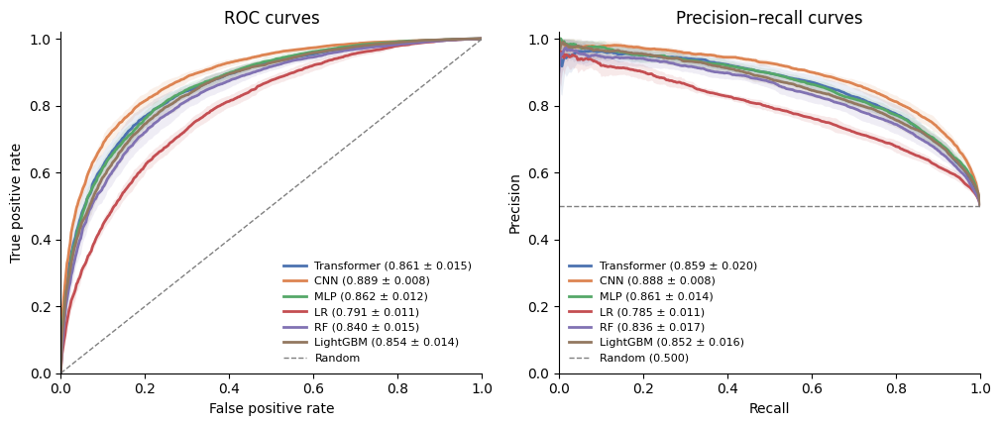

,Model,n_runs,ROC-AUC_mean,ROC-AUC_std,AUPR_mean,AUPR_std
0,Transformer,10,0.861449,0.015490,0.858924,0.020233
1,CNN,10,0.888999,0.008499,0.887881,0.008424
2,MLP,10,0.862351,0.012017,0.860597,0.013654
3,LR,10,0.791089,0.011220,0.784596,0.010579
4,RF,10,0.839988,0.015287,0.836415,0.017055
5,LightGBM,10,0.854260,0.014024,0.852339,0.015910



Saved:
/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_noleak_baseline/internal_rnaesm_baselines_10runs/model_comparison/baseline_all_runs_metrics.csv
/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_noleak_baseline/internal_rnaesm_baselines_10runs/model_comparison/baseline_summary_numeric.csv
/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_noleak_baseline/internal_rnaesm_baselines_10runs/model_comparison/baseline_summary_mean_std.csv
/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_noleak_baseline/internal_rnaesm_baselines_10runs/model_comparison/baseline_curve_summary.csv
/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_noleak_baseline/internal_rnaesm_baselines_10runs/model_comparison/baseline_mean_ROC_PR_curves.pdf


In [9]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, average_precision_score

root = Path("/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_noleak_baseline/internal_rnaesm_baselines_10runs")
out = root / "model_comparison"
out.mkdir(parents=True, exist_ok=True)

models = {
    "transformer": "Transformer",
    "cnn": "CNN",
    "mlp": "MLP",
    "lr": "LR",
    "rf": "RF",
    "lgbm": "LightGBM"
}
colors = {
    "transformer": "#4C72B0",
    "cnn": "#DD8452",
    "mlp": "#55A868",
    "lr": "#C44E52",
    "rf": "#8172B3",
    "lgbm": "#937860"
}
metrics = {
    "roc_auc": "ROC-AUC",
    "average_precision": "AUPR",
    "balanced_accuracy": "Balanced accuracy",
    "accuracy": "Accuracy",
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1",
    "mcc": "MCC"
}

# 1. 汇总10-run指标
all_tables, numeric_rows, show_rows = [], [], []
for key, name in models.items():
    f = root / key / "all_runs_test_metrics.csv"
    if not f.exists():
        print("Missing metrics:", f)
        continue
    d = pd.read_csv(f)
    d["model"] = name
    all_tables.append(d)
    numeric_row, show_row = {"Model": name}, {"Model": name}
    for col, label in metrics.items():
        if col not in d.columns:
            continue
        mean, std = d[col].mean(), d[col].std(ddof=1)
        numeric_row[f"{label}_mean"] = mean
        numeric_row[f"{label}_std"] = std
        show_row[label] = f"{mean:.4f} ± {std:.4f}"
    numeric_rows.append(numeric_row)
    show_rows.append(show_row)

all_runs = pd.concat(all_tables, ignore_index=True)
model_order = list(models.values())
all_runs["model"] = pd.Categorical(all_runs["model"], categories=model_order, ordered=True)
all_runs = all_runs.sort_values(["model", "run"]).reset_index(drop=True)
all_runs = all_runs[["model"] + [c for c in all_runs.columns if c != "model"]]

summary_numeric = pd.DataFrame(numeric_rows)
summary_show = pd.DataFrame(show_rows)
summary_numeric["Model"] = pd.Categorical(summary_numeric["Model"], categories=model_order, ordered=True)
summary_show["Model"] = pd.Categorical(summary_show["Model"], categories=model_order, ordered=True)
summary_numeric = summary_numeric.sort_values("Model").reset_index(drop=True)
summary_show = summary_show.sort_values("Model").reset_index(drop=True)

all_runs.to_csv(out / "baseline_all_runs_metrics.csv", index=False)
summary_numeric.to_csv(out / "baseline_summary_numeric.csv", index=False)
summary_show.to_csv(out / "baseline_summary_mean_std.csv", index=False)
display(summary_show)

# 2. 自动识别预测文件中的真实标签列和概率列
def get_prediction_columns(df):
    y_col = next((c for c in ["y_true", "label", "binary_label", "true_label", "target"] if c in df.columns), None)
    p_col = next((c for c in ["y_prob", "probability", "score", "pred_prob", "positive_probability"] if c in df.columns), None)
    if y_col is None or p_col is None:
        raise ValueError(f"无法识别预测列，当前列为：{df.columns.tolist()}")
    return y_col, p_col

# 3. 绘制10-run平均ROC和PR曲线
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 10,
    "axes.linewidth": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

grid = np.linspace(0, 1, 401)
fig, ax = plt.subplots(1, 2, figsize=(10.2, 4.4))
prevalences = []
curve_summary = []

for key, name in models.items():
    files = sorted((root / key).glob("**/*_test_predictions.csv"))
    if not files:
        print("Missing predictions:", key)
        continue

    roc_curves, pr_curves, aucs, auprs = [], [], [], []
    for f in files:
        d = pd.read_csv(f)
        y_col, p_col = get_prediction_columns(d)
        y = pd.to_numeric(d[y_col], errors="coerce").to_numpy()
        p = pd.to_numeric(d[p_col], errors="coerce").to_numpy()
        valid = np.isfinite(y) & np.isfinite(p)
        y, p = y[valid].astype(int), p[valid].astype(float)

        fpr, tpr, _ = roc_curve(y, p)
        precision, recall, _ = precision_recall_curve(y, p)

        roc_i = np.interp(grid, fpr, tpr)
        roc_i[0], roc_i[-1] = 0, 1
        order = np.argsort(recall)
        pr_i = np.interp(grid, recall[order], precision[order])

        roc_curves.append(roc_i)
        pr_curves.append(pr_i)
        aucs.append(roc_auc_score(y, p))
        auprs.append(average_precision_score(y, p))
        prevalences.append(y.mean())

    roc_curves, pr_curves = np.asarray(roc_curves), np.asarray(pr_curves)
    roc_mean, roc_std = roc_curves.mean(axis=0), roc_curves.std(axis=0)
    pr_mean, pr_std = pr_curves.mean(axis=0), pr_curves.std(axis=0)
    auc_mean, auc_std = np.mean(aucs), np.std(aucs, ddof=1)
    aupr_mean, aupr_std = np.mean(auprs), np.std(auprs, ddof=1)

    ax[0].plot(grid, roc_mean, lw=2, color=colors[key], label=f"{name} ({auc_mean:.3f} ± {auc_std:.3f})")
    ax[0].fill_between(grid, np.clip(roc_mean-roc_std, 0, 1), np.clip(roc_mean+roc_std, 0, 1),
                       color=colors[key], alpha=0.12, linewidth=0)

    ax[1].plot(grid, pr_mean, lw=2, color=colors[key], label=f"{name} ({aupr_mean:.3f} ± {aupr_std:.3f})")
    ax[1].fill_between(grid, np.clip(pr_mean-pr_std, 0, 1), np.clip(pr_mean+pr_std, 0, 1),
                       color=colors[key], alpha=0.12, linewidth=0)

    curve_summary.append({
        "Model": name,
        "n_runs": len(files),
        "ROC-AUC_mean": auc_mean,
        "ROC-AUC_std": auc_std,
        "AUPR_mean": aupr_mean,
        "AUPR_std": aupr_std
    })

ax[0].plot([0, 1], [0, 1], ls="--", lw=1, color="grey", label="Random")
ax[1].axhline(np.mean(prevalences), ls="--", lw=1, color="grey", label=f"Random ({np.mean(prevalences):.3f})")

ax[0].set_xlabel("False positive rate")
ax[0].set_ylabel("True positive rate")
ax[0].set_title("ROC curves")
ax[1].set_xlabel("Recall")
ax[1].set_ylabel("Precision")
ax[1].set_title("Precision–recall curves")

for a in ax:
    a.set_xlim(0, 1)
    a.set_ylim(0, 1.02)
    a.set_xticks(np.arange(0, 1.01, 0.2))
    a.set_yticks(np.arange(0, 1.01, 0.2))
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.tick_params(direction="out", width=0.8)

ax[0].legend(frameon=False, fontsize=8, loc="lower right")
ax[1].legend(frameon=False, fontsize=8, loc="lower left")
plt.tight_layout()

pdf_file = out / "baseline_mean_ROC_PR_curves.pdf"
plt.savefig(pdf_file, format="pdf", bbox_inches="tight")
plt.show()

curve_summary = pd.DataFrame(curve_summary)
curve_summary["Model"] = pd.Categorical(curve_summary["Model"], categories=model_order, ordered=True)
curve_summary = curve_summary.sort_values("Model").reset_index(drop=True)
curve_summary.to_csv(out / "baseline_curve_summary.csv", index=False)
display(curve_summary)

print("\nSaved:")
for f in [
    out / "baseline_all_runs_metrics.csv",
    out / "baseline_summary_numeric.csv",
    out / "baseline_summary_mean_std.csv",
    out / "baseline_curve_summary.csv",
    pdf_file
]:
    print(f)

In [51]:
###沿用stage1数据集，然后使用CNN做stage1###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage1_cnn_reuse_existing_split_v7/step1_train_stage1_cnn_reuse_filtered.py \
  --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage1_cnn_reuse_existing_split_v7/train_rnafm_cnn_pretrain_noleak.py \
  --filtered_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/filtered_stage1_datasets \
  --filtered_dataset_prefix translation_strict_lenmatched_noleak \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage1_cnn_pretrained_fixedsplit_noleak \
  --stage1_run_name_prefix stage1_noleak_rnafm_cnn \
  --start_run 0 \
  --n_runs 10 \
  --seed 42 \
  --batch_size 512 \
  --epochs 50 \
  --patience 10 \
  --dropout 0.2 \
  --lr 1e-4 \
  --weight_decay 5e-4 \
  --branch_hidden_dim 128 \
  --fusion_hidden_dim 256 \
  --cnn_kernels 3 5 7 \
  --valid_size 0.15 \
  --test_size 0.15 \
  --num_workers 2 \
  --grad_clip 1.0
#--skip_existing


[Run 00] Stage1 CNN from existing filtered no-leak dataset
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage1_cnn_reuse_existing_split_v7/train_rnafm_cnn_pretrain_noleak.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/filtered_stage1_datasets/translation_strict_lenmatched_noleak_run00.pkl --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage1_cnn_pretrained_fixedsplit_noleak/stage1_noleak_models/stage1_noleak_rnafm_cnn_run00 --run_name stage1_noleak_rnafm_cnn_run00 --seed 42 --epochs 50 --batch_size 512 --lr 0.0001 --weight_decay 0.0005 --patience 10 --num_workers 2 --dropout 0.2 --branch_hidden_dim 128 --fusion_hidden_dim 256 --cnn_kernels 3 5 7 --valid_size 0.15 --test_size 0.15 --grad_clip 1.0 --num_heads 8 --num_layers 2 -

In [52]:
###这次用stage1 CNN pretrain + protein CNN做stage2模型###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_frozen_stage1cnn_cnn_mlp256_protein_cnn/step2_train_stage2_frozen_stage1_cnn_mlp256_protein_cnn.py \
  --stage2_train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_frozen_stage1cnn_cnn_mlp256_protein_cnn/train_stage2_frozen_stage1_cnn_mlp256_protein_cnn_fixedsplit.py \
  --stage2_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2 \
  --stage2_dataset_prefix translation_strict_lenmatched_rnafm_esm2 \
  --split_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/fixed_stage2_splits \
  --stage1_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage1_cnn_pretrained_fixedsplit_noleak \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_stage1cnn_mlp256_proteincnn_noleak/no_adapter \
  --stage1_run_name_prefix stage1_noleak_rnafm_cnn \
  --stage2_run_name_prefix stage2_frozen_stage1cnn_mlp256_proteincnn \
  --start_run 0 \
  --n_runs 10 \
  --seed 42 \
  --batch_size 64 \
  --epochs 50 \
  --patience 10 \
  --num_workers 2 \
  --stage1_branch_hidden_dim 128 \
  --stage1_fusion_hidden_dim 256 \
  --stage1_cnn_kernels 3 5 7 \
  --stage1_dropout 0.2 \
  --stage2_hidden_dim 256 \
  --stage2_fusion_hidden_dim 256 \
  --stage2_cnn_hidden_dim 128 \
  --stage2_cnn_kernels 3 5 7 \
  --stage2_dropout 0.5 \
  --stage2_lr 1e-4 \
  --stage2_weight_decay 5e-4 \
  --stage2_grad_clip 1.0


[Run 00] Frozen Stage1 CNN MLP-256 feature + ESM2 protein CNN
Stage1 checkpoint: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage1_cnn_pretrained_fixedsplit_noleak/stage1_noleak_models/stage1_noleak_rnafm_cnn_run00/stage1_noleak_rnafm_cnn_run00_best_model.pt
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_frozen_stage1cnn_cnn_mlp256_protein_cnn/train_stage2_frozen_stage1_cnn_mlp256_protein_cnn_fixedsplit.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2/translation_strict_lenmatched_rnafm_esm2_run00.pkl --stage1_ckpt /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage1_cnn_pretrained_fixedsplit_noleak/stage1_noleak_models/stage1_noleak_rnafm_cnn_run00/stage1_noleak_rnafm_cnn_run00

In [ ]:
###这次用stage1 CNN pretrain + protein CNN做stage2模型###
#调参1#
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_frozen_stage1cnn_cnn_mlp256_protein_cnn/step2_train_stage2_frozen_stage1_cnn_mlp256_protein_cnn.py \
  --stage2_train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_frozen_stage1cnn_cnn_mlp256_protein_cnn/train_stage2_frozen_stage1_cnn_mlp256_protein_cnn_fixedsplit.py \
  --stage2_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2 \
  --stage2_dataset_prefix translation_strict_lenmatched_rnafm_esm2 \
  --split_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/fixed_stage2_splits \
  --stage1_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage1_cnn_pretrained_fixedsplit_noleak \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_stage1cnn_mlp256_proteincnn_noleak/optimize/test1 \
  --stage1_run_name_prefix stage1_noleak_rnafm_cnn \
  --stage2_run_name_prefix stage2_frozen_stage1cnn_mlp256_proteincnn \
  --start_run 0 \
  --n_runs 10 \
  --seed 42 \
  --batch_size 64 \
  --epochs 50 \
  --patience 10 \
  --num_workers 2 \
  --stage1_branch_hidden_dim 128 \
  --stage1_fusion_hidden_dim 256 \
  --stage1_cnn_kernels 3 5 7 \
  --stage1_dropout 0.2 \
  --stage2_hidden_dim 64 \
  --stage2_fusion_hidden_dim 128 \
  --stage2_cnn_hidden_dim 128 \
  --stage2_cnn_kernels 3 5 7 \
  --stage2_dropout 0.6 \
  --stage2_lr 5e-5 \
  --stage2_weight_decay 1e-3 \
  --stage2_grad_clip 1.0 \
  --use_rna_adapter


[Run 00] Frozen Stage1 CNN MLP-256 feature + ESM2 protein CNN + RNA adapter
Stage1 checkpoint: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage1_cnn_pretrained_fixedsplit_noleak/stage1_noleak_models/stage1_noleak_rnafm_cnn_run00/stage1_noleak_rnafm_cnn_run00_best_model.pt
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_frozen_stage1cnn_cnn_mlp256_protein_cnn/train_stage2_frozen_stage1_cnn_mlp256_protein_cnn_fixedsplit.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2/translation_strict_lenmatched_rnafm_esm2_run00.pkl --stage1_ckpt /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage1_cnn_pretrained_fixedsplit_noleak/stage1_noleak_models/stage1_noleak_rnafm_cnn_run00/stage1_noleak_r

In [61]:
###这次用stage1 CNN pretrain + protein CNN做stage2模型###
#这次更改模型结构，使用PRG模型#
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_frozen_stage1cnn_cnn_mlp256_protein_cnn/step2_run_stage2_frozen_stage1cnn_protein_prg.py \
  --stage2_train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_frozen_stage1cnn_cnn_mlp256_protein_cnn/train_stage2_frozen_stage1cnn_protein_prg_fixedsplit.py \
  --stage2_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2 \
  --stage2_dataset_prefix translation_strict_lenmatched_rnafm_esm2 \
  --split_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/fixed_stage2_splits \
  --stage1_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage1_cnn_pretrained_fixedsplit_noleak/stage1_noleak_models \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_stage1cnn_mlp256_proteincnn_noleak/optimize/stage2_model_PRG \
  --model_variant PRG \
  --stage1_run_name_prefix stage1_noleak_rnafm_cnn \
  --stage2_run_name_prefix stage2_frozen_stage1cnn_protein_prg \
  --start_run 0 \
  --n_runs 10 \
  --seed 42 \
  --batch_size 64 \
  --epochs 50 \
  --patience 10 \
  --num_workers 2 \
  --stage1_branch_hidden_dim 128 \
  --stage1_fusion_hidden_dim 256 \
  --stage1_cnn_kernels 3 5 7 \
  --stage1_dropout 0.2 \
  --protein_projection_dim 256 \
  --protein_projection_dropout 0.25 \
  --protein_cnn_hidden_dim 64 \
  --protein_cnn_kernels 3 5 7 \
  --protein_cnn_dropout 0.4 \
  --branch_output_dim 256 \
  --rna_adapter_bottleneck_dim 64 \
  --rna_adapter_dropout 0.3 \
  --rna_adapter_initial_scale 0.1 \
  --modality_projection_dim 128 \
  --fusion_hidden_dim 128 \
  --fusion_dropout 0.5 \
  --lr 5e-5 \
  --weight_decay 1e-3 \
  --grad_clip 1.0 \
  --monitor_metric roc_auc

Resolved fixed Stage2 split root: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/fixed_stage2_splits
Resolved Stage1 checkpoint root: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage1_cnn_pretrained_fixedsplit_noleak/stage1_noleak_models

[Run 00] Model PRG: adapter=True, fusion=gated_interaction
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_frozen_stage1cnn_cnn_mlp256_protein_cnn/train_stage2_frozen_stage1cnn_protein_prg_fixedsplit.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2/translation_strict_lenmatched_rnafm_esm2_run00.pkl --stage1_ckpt /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/sta

In [62]:
###这次用stage1 CNN pretrain + protein CNN做stage2模型###
#这次更改模型结构，使用AG模型#
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_frozen_stage1cnn_protein_AG/step2_run_stage2_frozen_stage1cnn_protein_prg.py \
  --stage2_train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_frozen_stage1cnn_protein_AG/train_stage2_frozen_stage1cnn_protein_prg_fixedsplit.py \
  --stage2_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2 \
  --stage2_dataset_prefix translation_strict_lenmatched_rnafm_esm2 \
  --split_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/fixed_stage2_splits \
  --stage1_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage1_cnn_pretrained_fixedsplit_noleak/stage1_noleak_models \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_stage1cnn_mlp256_proteincnn_noleak/optimize/stage2_model_AG \
  --model_variant AG \
  --stage1_run_name_prefix stage1_noleak_rnafm_cnn \
  --stage2_run_name_prefix stage2_frozen_stage1cnn_protein_ag \
  --start_run 0 \
  --n_runs 10 \
  --seed 42 \
  --batch_size 64 \
  --epochs 50 \
  --patience 10 \
  --num_workers 2 \
  --stage1_branch_hidden_dim 128 \
  --stage1_fusion_hidden_dim 256 \
  --stage1_cnn_kernels 3 5 7 \
  --stage1_dropout 0.2 \
  --protein_cnn_hidden_dim 128 \
  --protein_cnn_kernels 3 5 7 \
  --protein_cnn_dropout 0.6 \
  --branch_output_dim 256 \
  --rna_adapter_bottleneck_dim 64 \
  --rna_adapter_dropout 0.3 \
  --rna_adapter_initial_scale 0.1 \
  --fusion_hidden_dim 128 \
  --fusion_dropout 0.6 \
  --lr 5e-5 \
  --weight_decay 1e-3 \
  --grad_clip 1.0 \
  --monitor_metric roc_auc

Resolved fixed Stage2 split root: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/fixed_stage2_splits
Resolved Stage1 checkpoint root: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage1_cnn_pretrained_fixedsplit_noleak/stage1_noleak_models

[Run 00] Model AG: adapter=True, protein_projection=False, protein_cnn_hidden=128, fusion=gated_concat
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_frozen_stage1cnn_protein_AG/train_stage2_frozen_stage1cnn_protein_prg_fixedsplit.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2/translation_strict_lenmatched_rnafm_esm2_run00.pkl --stage1_ckpt /disk4hu/hejp/00_thesis/4_predict_translation/results/t

In [53]:
###这次用stage1 CNN pretrain + protein CNN做stage2模型###
###加一个adapter在stage1的预训练模型后面
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_frozen_stage1cnn_cnn_mlp256_protein_cnn/step2_train_stage2_frozen_stage1_cnn_mlp256_protein_cnn.py \
  --stage2_train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_frozen_stage1cnn_cnn_mlp256_protein_cnn/train_stage2_frozen_stage1_cnn_mlp256_protein_cnn_fixedsplit.py \
  --stage2_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2 \
  --stage2_dataset_prefix translation_strict_lenmatched_rnafm_esm2 \
  --split_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/fixed_stage2_splits \
  --stage1_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage1_cnn_pretrained_fixedsplit_noleak \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_stage1cnn_mlp256_proteincnn_noleak/with_adapter \
  --stage1_run_name_prefix stage1_noleak_rnafm_cnn \
  --stage2_run_name_prefix stage2_frozen_stage1cnn_mlp256_proteincnn \
  --start_run 0 \
  --n_runs 10 \
  --seed 42 \
  --batch_size 64 \
  --epochs 50 \
  --patience 10 \
  --num_workers 2 \
  --stage1_branch_hidden_dim 128 \
  --stage1_fusion_hidden_dim 256 \
  --stage1_cnn_kernels 3 5 7 \
  --stage1_dropout 0.2 \
  --stage2_hidden_dim 256 \
  --stage2_fusion_hidden_dim 256 \
  --stage2_cnn_hidden_dim 128 \
  --stage2_cnn_kernels 3 5 7 \
  --stage2_dropout 0.5 \
  --stage2_lr 1e-4 \
  --stage2_weight_decay 5e-4 \
  --stage2_grad_clip 1.0 \
  --use_rna_adapter


[Run 00] Frozen Stage1 CNN MLP-256 feature + ESM2 protein CNN + RNA adapter
Stage1 checkpoint: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage1_cnn_pretrained_fixedsplit_noleak/stage1_noleak_models/stage1_noleak_rnafm_cnn_run00/stage1_noleak_rnafm_cnn_run00_best_model.pt
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_frozen_stage1cnn_cnn_mlp256_protein_cnn/train_stage2_frozen_stage1_cnn_mlp256_protein_cnn_fixedsplit.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2/translation_strict_lenmatched_rnafm_esm2_run00.pkl --stage1_ckpt /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage1_cnn_pretrained_fixedsplit_noleak/stage1_noleak_models/stage1_noleak_rnafm_cnn_run00/stage1_noleak_r

In [57]:
###这次用stage1 CNN pretrain + protein CNN做stage2模型###
###加一个adapter在stage1的预训练模型后面
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_frozen_stage1cnn_cnn_mlp256_protein_cnn/step2_train_stage2_frozen_stage1_cnn_mlp256_protein_cnn.py \
  --stage2_train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_frozen_stage1cnn_cnn_mlp256_protein_cnn/train_stage2_frozen_stage1_cnn_mlp256_protein_cnn_fixedsplit.py \
  --stage2_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2 \
  --stage2_dataset_prefix translation_strict_lenmatched_rnafm_esm2 \
  --split_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/fixed_stage2_splits \
  --stage1_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage1_cnn_pretrained_fixedsplit_noleak \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_stage1cnn_mlp256_proteincnn_noleak/optimize/test2_pat3 \
  --stage1_run_name_prefix stage1_noleak_rnafm_cnn \
  --stage2_run_name_prefix stage2_frozen_stage1cnn_mlp256_proteincnn \
  --start_run 0 \
  --n_runs 10 \
  --seed 42 \
  --batch_size 64 \
  --epochs 50 \
  --patience 3 \
  --num_workers 2 \
  --stage1_branch_hidden_dim 128 \
  --stage1_fusion_hidden_dim 256 \
  --stage1_cnn_kernels 3 5 7 \
  --stage1_dropout 0.2 \
  --stage2_hidden_dim 256 \
  --stage2_fusion_hidden_dim 256 \
  --stage2_cnn_hidden_dim 128 \
  --stage2_cnn_kernels 3 5 7 \
  --stage2_dropout 0.5 \
  --stage2_lr 1e-4 \
  --stage2_weight_decay 5e-4 \
  --stage2_grad_clip 1.0 \
  --use_rna_adapter


[Run 00] Frozen Stage1 CNN MLP-256 feature + ESM2 protein CNN + RNA adapter
Stage1 checkpoint: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage1_cnn_pretrained_fixedsplit_noleak/stage1_noleak_models/stage1_noleak_rnafm_cnn_run00/stage1_noleak_rnafm_cnn_run00_best_model.pt
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_frozen_stage1cnn_cnn_mlp256_protein_cnn/train_stage2_frozen_stage1_cnn_mlp256_protein_cnn_fixedsplit.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2/translation_strict_lenmatched_rnafm_esm2_run00.pkl --stage1_ckpt /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage1_cnn_pretrained_fixedsplit_noleak/stage1_noleak_models/stage1_noleak_rnafm_cnn_run00/stage1_noleak_r

In [5]:
#step2 基于预训练模型
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/step2_train_stage2_with_noleak_stage1.py \
  --stage2_train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_stage2_pretrained_rnaesm_cross_fixedsplit.py \
  --stage2_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2 \
  --stage2_dataset_prefix translation_strict_lenmatched_rnafm_esm2 \
  --noleak_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/stage2_noleak_models \
  --n_runs 10 \
  --seed 42 \
  --batch_size 64 \
  --epochs 50 \
  --hidden_dim 256 \
  --fusion_hidden_dim 256 \
  --num_heads 8 \
  --rna_num_layers 2 \
  --protein_num_layers 1 \
  --cross_layers 1 \
  --dropout 0.5 \
  --lr 1e-4 \
  --weight_decay 5e-4 \
  --ff_mult 2


[Run 00] Step2: train strict no-leak Stage2
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_stage2_pretrained_rnaesm_cross_fixedsplit.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2/translation_strict_lenmatched_rnafm_esm2_run00.pkl --stage1_ckpt /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/stage1_noleak_models/stage1_noleak_rnafm_run00/stage1_noleak_rnafm_run00_best_model.pt --split_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/fixed_stage2_splits/run00 --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross

In [6]:
#step2 基于预训练模型 调参 降低学习率#
#调参 调参 调参 调参 调参 调参 调参 调参 调参 调参#
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/step2_train_stage2_with_noleak_stage1.py \
  --stage2_train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_stage2_pretrained_rnaesm_cross_fixedsplit.py \
  --stage2_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2 \
  --stage2_dataset_prefix translation_strict_lenmatched_rnafm_esm2 \
  --noleak_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/stage2_noleak_models_para_adjusting/hd256_fhd256_head8_rlayer2_player2_clayer1_do05_lr5e5_wd5e4_fm2 \
  --n_runs 10 \
  --seed 42 \
  --batch_size 64 \
  --epochs 50 \
  --hidden_dim 256 \
  --fusion_hidden_dim 256 \
  --num_heads 8 \
  --rna_num_layers 2 \
  --protein_num_layers 1 \
  --cross_layers 1 \
  --dropout 0.5 \
  --lr 5e-5 \
  --weight_decay 5e-4 \
  --ff_mult 2


[Run 00] Step2: train strict no-leak Stage2
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_stage2_pretrained_rnaesm_cross_fixedsplit.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2/translation_strict_lenmatched_rnafm_esm2_run00.pkl --stage1_ckpt /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/stage1_noleak_models/stage1_noleak_rnafm_run00/stage1_noleak_rnafm_run00_best_model.pt --split_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/fixed_stage2_splits/run00 --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross

In [ ]:
#step2 基于预训练模型 调参 降低学习率#
#调参 调参 调参 调参 调参 调参 调参 调参 调参 调参#
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/step2_train_stage2_with_noleak_stage1.py \
  --stage2_train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_stage2_pretrained_rnaesm_cross_fixedsplit.py \
  --stage2_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2 \
  --stage2_dataset_prefix translation_strict_lenmatched_rnafm_esm2 \
  --noleak_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/stage2_noleak_models_para_adjusting/hd128_fhd256_head8_rlayer2_player1_clayer1_do05_lr5e5_wd5e4_fm2 \
  --n_runs 10 \
  --seed 42 \
  --batch_size 64 \
  --epochs 50 \
  --hidden_dim 128 \
  --fusion_hidden_dim 256 \
  --num_heads 8 \
  --rna_num_layers 2 \
  --protein_num_layers 1 \
  --cross_layers 1 \
  --dropout 0.5 \
  --lr 5e-5 \
  --weight_decay 5e-4 \
  --ff_mult 2


[Run 00] Step2: train strict no-leak Stage2
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_stage2_pretrained_rnaesm_cross_fixedsplit.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2/translation_strict_lenmatched_rnafm_esm2_run00.pkl --stage1_ckpt /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/stage1_noleak_models/stage1_noleak_rnafm_run00/stage1_noleak_rnafm_run00_best_model.pt --split_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/fixed_stage2_splits/run00 --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross

In [ ]:
###  step2 基于预训练模型 CNN  ###
### 冻结stage1（selfattention）MLP 256，然后蛋白结构分支用CNN###
#加RNA adapter#
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_frozen_stage1_mlp256_feature_protein_cnn_v2/step2_train_stage2_with_frozen_stage1_mlp_feature_protein_cnn.py \
  --stage2_train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_frozen_stage1_mlp256_feature_protein_cnn_v2/train_stage2_pretrained_rna_protein_cnn_fixedsplit_mlp_feature.py \
  --stage2_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2 \
  --stage2_dataset_prefix translation_strict_lenmatched_rnafm_esm2 \
  --noleak_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_stage1_mlp256_protein_cnn_noleak_stepwise/hd256_fhd256_cnn128_k357_do05_lr1e4_wd5e4 \
  --stage2_run_name_prefix stage2_frozen_stage1_mlp256_feature_protein_cnn \
  --start_run 0 \
  --n_runs 10 \
  --seed 42 \
  --batch_size 64 \
  --epochs 50 \
  --patience 10 \
  --num_workers 2 \
  --stage1_hidden_dim 256 \
  --stage1_fusion_hidden_dim 256 \
  --stage1_num_heads 8 \
  --stage1_num_layers 2 \
  --stage1_ff_mult 2 \
  --stage2_hidden_dim 256 \
  --stage2_fusion_hidden_dim 256 \
  --stage2_cnn_hidden_dim 128 \
  --stage2_cnn_kernels 3 5 7 \
  --stage2_dropout 0.5 \
  --stage2_lr 1e-4 \
  --stage2_weight_decay 5e-4 \
  --stage2_grad_clip 1.0 \
  --use_rna_adapter


[Run 00] Frozen Stage1 MLP-256 feature + ESM2 protein CNN
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_frozen_stage1_mlp256_feature_protein_cnn_v2/train_stage2_pretrained_rna_protein_cnn_fixedsplit_mlp_feature.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2/translation_strict_lenmatched_rnafm_esm2_run00.pkl --stage1_ckpt /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/stage1_noleak_models/stage1_noleak_rnafm_run00/stage1_noleak_rnafm_run00_best_model.pt --split_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/fixed_stage2_splits/run00 --out_dir /disk4hu/hejp/00_thesis/4_predict_tra

In [45]:
###  step2 基于预训练模型 CNN  ###
### 冻结stage1（selfattention）MLP 256，然后蛋白结构分支用CNN###
#无adapter#
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_frozen_stage1_mlp256_feature_protein_cnn_v2/step2_train_stage2_with_frozen_stage1_mlp_feature_protein_cnn.py \
  --stage2_train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_frozen_stage1_mlp256_feature_protein_cnn_v2/train_stage2_pretrained_rna_protein_cnn_fixedsplit_mlp_feature.py \
  --stage2_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2 \
  --stage2_dataset_prefix translation_strict_lenmatched_rnafm_esm2 \
  --noleak_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_stage1_mlp256_protein_cnn_noleak_stepwise/hd256_fhd256_cnn128_k357_do05_lr1e4_wd5e4_noadapter \
  --stage2_run_name_prefix stage2_frozen_stage1_mlp256_feature_protein_cnn \
  --start_run 0 \
  --n_runs 10 \
  --seed 42 \
  --batch_size 64 \
  --epochs 50 \
  --patience 10 \
  --num_workers 2 \
  --stage1_hidden_dim 256 \
  --stage1_fusion_hidden_dim 256 \
  --stage1_num_heads 8 \
  --stage1_num_layers 2 \
  --stage1_ff_mult 2 \
  --stage2_hidden_dim 256 \
  --stage2_fusion_hidden_dim 256 \
  --stage2_cnn_hidden_dim 128 \
  --stage2_cnn_kernels 3 5 7 \
  --stage2_dropout 0.5 \
  --stage2_lr 1e-4 \
  --stage2_weight_decay 5e-4 \
  --stage2_grad_clip 1.0


[Run 00] Frozen Stage1 MLP-256 feature + ESM2 protein CNN
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_frozen_stage1_mlp256_feature_protein_cnn_v2/train_stage2_pretrained_rna_protein_cnn_fixedsplit_mlp_feature.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2/translation_strict_lenmatched_rnafm_esm2_run00.pkl --stage1_ckpt /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/stage1_noleak_models/stage1_noleak_rnafm_run00/stage1_noleak_rnafm_run00_best_model.pt --split_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/fixed_stage2_splits/run00 --out_dir /disk4hu/hejp/00_thesis/4_predict_tra

In [ ]:
###  step2 基于预训练模型 CNN  ###
### 冻结stage1（selfattention），然后蛋白结构分支用CNN###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/step2_train_stage2_with_frozen_stage1_protein_cnn.py \
  --stage2_train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_stage2_pretrained_rna_protein_cnn_fixedsplit.py \
  --stage2_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2 \
  --stage2_dataset_prefix translation_strict_lenmatched_rnafm_esm2 \
  --noleak_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/stage2_frozen_stage1_protein_cnn/hd256_fhd256_cnn128_k357_do05_lr5e5_wd5e4 \
  --stage2_run_name_prefix stage2_frozen_stage1_protein_cnn \
  --start_run 0 \
  --n_runs 10 \
  --seed 42 \
  --batch_size 64 \
  --epochs 50 \
  --patience 10 \
  --num_workers 2 \
  --stage1_hidden_dim 256 \
  --stage1_fusion_hidden_dim 256 \
  --stage1_num_heads 8 \
  --stage1_num_layers 2 \
  --stage1_ff_mult 2 \
  --stage2_hidden_dim 256 \
  --stage2_fusion_hidden_dim 256 \
  --stage2_cnn_hidden_dim 128 \
  --stage2_cnn_kernels 3 5 7 \
  --stage2_dropout 0.5 \
  --stage2_lr 1e-4 \
  --stage2_weight_decay 5e-4 \
  --stage2_grad_clip 1.0
#  --skip_existing


[Run 00] Frozen no-leak Stage1 RNA + ESM2 protein CNN
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_stage2_pretrained_rna_protein_cnn_fixedsplit.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2/translation_strict_lenmatched_rnafm_esm2_run00.pkl --stage1_ckpt /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/stage1_noleak_models/stage1_noleak_rnafm_run00/stage1_noleak_rnafm_run00_best_model.pt --split_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/fixed_stage2_splits/run00 --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rn

In [ ]:
###  step2 基于预训练模型 CNN  ###
### 冻结stage1（selfattention），不做pooling，RNA分支接CNN，然后蛋白结构分支用CNN###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/step2_train_stage2_with_frozen_stage1_dual_cnn.py \
  --stage2_train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_stage2_pretrained_rna_dual_cnn_fixedsplit.py \
  --stage2_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2 \
  --stage2_dataset_prefix translation_strict_lenmatched_rnafm_esm2 \
  --noleak_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/stage2_frozen_stage1_dual_cnn/rna128_protein128_k357_do05_lr1e4 \
  --stage2_run_name_prefix stage2_frozen_stage1_dual_cnn \
  --start_run 0 \
  --n_runs 10 \
  --seed 42 \
  --batch_size 16 \
  --epochs 50 \
  --patience 10 \
  --num_workers 2 \
  --monitor_metric roc_auc \
  --stage1_hidden_dim 256 \
  --stage1_fusion_hidden_dim 256 \
  --stage1_num_heads 8 \
  --stage1_num_layers 2 \
  --stage1_ff_mult 2 \
  --stage2_hidden_dim 256 \
  --stage2_fusion_hidden_dim 256 \
  --stage2_rna_cnn_hidden_dim 128 \
  --stage2_rna_cnn_kernels 3 5 7 \
  --stage2_protein_cnn_hidden_dim 128 \
  --stage2_protein_cnn_kernels 3 5 7 \
  --stage2_dropout 0.5 \
  --stage2_lr 1e-4 \
  --stage2_weight_decay 5e-4 \
  --stage2_grad_clip 1.0 \
  --skip_existing


[Run 00] Frozen Stage1 RNA + contextual RNA CNN + ESM2 protein CNN
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_stage2_pretrained_rna_dual_cnn_fixedsplit.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2/translation_strict_lenmatched_rnafm_esm2_run00.pkl --stage1_ckpt /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/stage1_noleak_models/stage1_noleak_rnafm_run00/stage1_noleak_rnafm_run00_best_model.pt --split_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/fixed_stage2_splits/run00 --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pre

In [6]:
###  step2 基于预训练模型 CNN  ###
### 冻结stage1（selfattention）pooling，然后蛋白结构分支用CNN，再添加一个RNA的CNN分支###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/step2_train_stage2_rawrna_cnn_stage1_aux_protein_cnn.py \
  --stage2_train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_stage2_rawrna_cnn_stage1_aux_protein_cnn_fixedsplit.py \
  --stage2_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2 \
  --stage2_dataset_prefix translation_strict_lenmatched_rnafm_esm2 \
  --noleak_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/stage2_dualcnn_stage1_aux/cnn128_aux128_k357_do05_lr1e4 \
  --stage2_run_name_prefix stage2_dualcnn_stage1_aux \
  --start_run 0 \
  --n_runs 10 \
  --seed 42 \
  --batch_size 16 \
  --epochs 50 \
  --patience 10 \
  --num_workers 2 \
  --monitor_metric roc_auc \
  --cnn_hidden_dim 128 \
  --cnn_kernels 3 5 7 \
  --branch_hidden_dim 256 \
  --fusion_hidden_dim 256 \
  --stage1_aux_hidden_dim 128 \
  --stage1_aux_gate_init 0.0 \
  --stage1_hidden_dim 256 \
  --stage1_fusion_hidden_dim 256 \
  --stage1_num_heads 8 \
  --stage1_num_layers 2 \
  --stage1_ff_mult 2 \
  --dropout 0.5 \
  --lr 1e-4 \
  --weight_decay 5e-4 \
  --grad_clip 1.0 \
  --skip_existing


[Run 00] Dual CNN + gated frozen Stage1 auxiliary branch
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_stage2_rawrna_cnn_stage1_aux_protein_cnn_fixedsplit.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2/translation_strict_lenmatched_rnafm_esm2_run00.pkl --stage1_ckpt /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/stage1_noleak_models/stage1_noleak_rnafm_run00/stage1_noleak_rnafm_run00_best_model.pt --split_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/fixed_stage2_splits/run00 --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pre

In [14]:
###  step2 基于预训练模型 CNN  ###
### 冻结stage1（selfattention）pooling，然后蛋白结构分支用CNN，再添加一个RNA的CNN分支###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/step2_train_stage2_rawrna_cnn_stage1_aux_protein_cnn.py \
  --stage2_train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_stage2_rawrna_cnn_stage1_aux_protein_cnn_fixedsplit_gate0.py \
  --stage2_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2 \
  --stage2_dataset_prefix translation_strict_lenmatched_rnafm_esm2 \
  --noleak_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/stage2_dualcnn_stage1_aux/cnn128_aux128_k357_do05_lr1e4_gatefix0 \
  --stage2_run_name_prefix stage2_dualcnn_stage1_aux \
  --start_run 0 \
  --n_runs 10 \
  --seed 42 \
  --batch_size 16 \
  --epochs 50 \
  --patience 10 \
  --num_workers 2 \
  --monitor_metric roc_auc \
  --cnn_hidden_dim 128 \
  --cnn_kernels 3 5 7 \
  --branch_hidden_dim 256 \
  --fusion_hidden_dim 256 \
  --stage1_aux_hidden_dim 128 \
  --stage1_aux_gate_init 0.0 \
  --stage1_hidden_dim 256 \
  --stage1_fusion_hidden_dim 256 \
  --stage1_num_heads 8 \
  --stage1_num_layers 2 \
  --stage1_ff_mult 2 \
  --dropout 0.5 \
  --lr 1e-4 \
  --weight_decay 5e-4 \
  --grad_clip 1.0 \
  --skip_existing


[Run 00] Dual CNN + gated frozen Stage1 auxiliary branch
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_stage2_rawrna_cnn_stage1_aux_protein_cnn_fixedsplit_gate0.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2/translation_strict_lenmatched_rnafm_esm2_run00.pkl --stage1_ckpt /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/stage1_noleak_models/stage1_noleak_rnafm_run00/stage1_noleak_rnafm_run00_best_model.pt --split_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/fixed_stage2_splits/run00 --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stag

In [10]:
###  step2 基于预训练模型 CNN  ###
### 冻结stage1（selfattention）pooling，然后蛋白结构分支用CNN，再添加一个RNA的CNN分支###
#稍作调整，把 --stage1_aux_gate_init 0.0 改成0.1#
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/step2_train_stage2_rawrna_cnn_stage1_aux_protein_cnn.py \
  --stage2_train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_stage2_rawrna_cnn_stage1_aux_protein_cnn_fixedsplit.py \
  --stage2_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2 \
  --stage2_dataset_prefix translation_strict_lenmatched_rnafm_esm2 \
  --noleak_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/stage2_dualcnn_stage1_aux/cnn128_aux128_k357_do05_lr1e4_gate0.1 \
  --stage2_run_name_prefix stage2_dualcnn_stage1_aux \
  --start_run 0 \
  --n_runs 10 \
  --seed 42 \
  --batch_size 16 \
  --epochs 50 \
  --patience 10 \
  --num_workers 2 \
  --monitor_metric roc_auc \
  --cnn_hidden_dim 128 \
  --cnn_kernels 3 5 7 \
  --branch_hidden_dim 256 \
  --fusion_hidden_dim 256 \
  --stage1_aux_hidden_dim 128 \
  --stage1_aux_gate_init 0.1 \
  --stage1_hidden_dim 256 \
  --stage1_fusion_hidden_dim 256 \
  --stage1_num_heads 8 \
  --stage1_num_layers 2 \
  --stage1_ff_mult 2 \
  --dropout 0.5 \
  --lr 1e-4 \
  --weight_decay 5e-4 \
  --grad_clip 1.0 \
  --skip_existing


[Run 00] Dual CNN + gated frozen Stage1 auxiliary branch
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_stage2_rawrna_cnn_stage1_aux_protein_cnn_fixedsplit.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2/translation_strict_lenmatched_rnafm_esm2_run00.pkl --stage1_ckpt /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/stage1_noleak_models/stage1_noleak_rnafm_run00/stage1_noleak_rnafm_run00_best_model.pt --split_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/fixed_stage2_splits/run00 --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pre

In [ ]:
#step2 基于预训练模型 调参 降低学习率#
#调参 调参 调参 调参 调参 调参 调参 调参 调参 调参#
#这次拆分stage1和stage2参数#
#886
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/step2_train_stage2_with_frozen_stage1_patchv2.py \
  --stage2_train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_stage2_pretrain_rnaesm_cross_fixedsplit_frozen_stage1_patchv2.py \
  --stage2_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2 \
  --stage2_dataset_prefix translation_strict_lenmatched_rnafm_esm2 \
  --noleak_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/stage2_frozen_stage1_models_patchv2/optimizing/hd256_fhd256_head4_rlayer2_player1_clayer1_do05_lr5e5_wd5e4_fm2 \
  --n_runs 10 \
  --seed 42 \
  --batch_size 64 \
  --epochs 50 \
  --stage1_hidden_dim 256 \
  --stage1_fusion_hidden_dim 256 \
  --stage1_num_heads 8 \
  --stage1_num_layers 2 \
  --stage1_ff_mult 2 \
  --hidden_dim 256 \
  --fusion_hidden_dim 256 \
  --num_heads 4 \
  --protein_num_layers 1 \
  --cross_layers 1 \
  --dropout 0.5 \
  --lr 5e-5 \
  --weight_decay 5e-4 \
  --ff_mult 2


[Run 00] Step2: train strict no-leak Stage2 with frozen Stage1 RNA encoder
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_stage2_pretrain_rnaesm_cross_fixedsplit_frozen_stage1_patchv2.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2/translation_strict_lenmatched_rnafm_esm2_run00.pkl --stage1_ckpt /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/stage1_noleak_models/stage1_noleak_rnafm_run00/stage1_noleak_rnafm_run00_best_model.pt --split_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/fixed_stage2_splits/run00 --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_res

In [ ]:
#step2 基于预训练模型 调参 降低学习率#
#调参 调参 调参 调参 调参 调参 调参 调参 调参 调参#
#这次拆分stage1和stage2参数#
#885
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/step2_train_stage2_with_frozen_stage1_patchv2.py \
  --stage2_train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_stage2_pretrain_rnaesm_cross_fixedsplit_frozen_stage1_patchv2.py \
  --stage2_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2 \
  --stage2_dataset_prefix translation_strict_lenmatched_rnafm_esm2 \
  --noleak_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/stage2_frozen_stage1_models_patchv2/optimizing/hd256_fhd256_head4_rlayer2_player2_clayer1_do05_lr5e5_wd5e4_fm2 \
  --n_runs 10 \
  --seed 42 \
  --batch_size 64 \
  --epochs 50 \
  --stage1_hidden_dim 256 \
  --stage1_fusion_hidden_dim 256 \
  --stage1_num_heads 8 \
  --stage1_num_layers 2 \
  --stage1_ff_mult 2 \
  --hidden_dim 256 \
  --fusion_hidden_dim 128 \
  --num_heads 4 \
  --protein_num_layers 1 \
  --cross_layers 1 \
  --dropout 0.5 \
  --lr 5e-5 \
  --weight_decay 5e-4 \
  --ff_mult 2


[Run 00] Step2: train strict no-leak Stage2 with frozen Stage1 RNA encoder
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_stage2_pretrain_rnaesm_cross_fixedsplit_frozen_stage1_patchv2.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2/translation_strict_lenmatched_rnafm_esm2_run00.pkl --stage1_ckpt /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/stage1_noleak_models/stage1_noleak_rnafm_run00/stage1_noleak_rnafm_run00_best_model.pt --split_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/fixed_stage2_splits/run00 --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_res

In [ ]:
#step2 基于预训练模型 调参 降低学习率#
#调参 调参 调参 调参 调参 调参 调参 调参 调参 调参#
#这次拆分stage1和stage2参数#
#883
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/step2_train_stage2_with_frozen_stage1_patchv2.py \
  --stage2_train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_stage2_pretrain_rnaesm_cross_fixedsplit_frozen_stage1_patchv2.py \
  --stage2_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2 \
  --stage2_dataset_prefix translation_strict_lenmatched_rnafm_esm2 \
  --noleak_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/stage2_frozen_stage1_models_patchv2/optimizing/hd256_fhd128_head4_rlayer2_player2_clayer1_do05_lr5e5_wd5e4_fm2 \
  --n_runs 10 \
  --seed 42 \
  --batch_size 64 \
  --epochs 50 \
  --stage1_hidden_dim 256 \
  --stage1_fusion_hidden_dim 256 \
  --stage1_num_heads 8 \
  --stage1_num_layers 2 \
  --stage1_ff_mult 2 \
  --hidden_dim 256 \
  --fusion_hidden_dim 128 \
  --num_heads 4 \
  --protein_num_layers 1 \
  --cross_layers 1 \
  --dropout 0.5 \
  --lr 5e-5 \
  --weight_decay 5e-4 \
  --ff_mult 2


[Run 00] Step2: train strict no-leak Stage2 with frozen Stage1 RNA encoder
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_stage2_pretrain_rnaesm_cross_fixedsplit_frozen_stage1_patchv2.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2/translation_strict_lenmatched_rnafm_esm2_run00.pkl --stage1_ckpt /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/stage1_noleak_models/stage1_noleak_rnafm_run00/stage1_noleak_rnafm_run00_best_model.pt --split_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/fixed_stage2_splits/run00 --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_res

In [ ]:
#step2 基于预训练模型 调参 降低学习率#
#调参 调参 调参 调参 调参 调参 调参 调参 调参 调参#
#这次拆分stage1和stage2参数#
#885
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/step2_train_stage2_with_frozen_stage1_patchv2.py \
  --stage2_train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_stage2_pretrain_rnaesm_cross_fixedsplit_frozen_stage1_patchv2.py \
  --stage2_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2 \
  --stage2_dataset_prefix translation_strict_lenmatched_rnafm_esm2 \
  --noleak_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/stage2_frozen_stage1_models_patchv2/optimizing/hd256_fhd256_head4_rlayer2_player2_clayer1_do05_lr5e5_wd5e4_fm2 \
  --n_runs 10 \
  --seed 42 \
  --batch_size 64 \
  --epochs 50 \
  --stage1_hidden_dim 256 \
  --stage1_fusion_hidden_dim 256 \
  --stage1_num_heads 8 \
  --stage1_num_layers 2 \
  --stage1_ff_mult 2 \
  --hidden_dim 256 \
  --fusion_hidden_dim 256 \
  --num_heads 4 \
  --protein_num_layers 2 \
  --cross_layers 1 \
  --dropout 0.5 \
  --lr 5e-5 \
  --weight_decay 5e-4 \
  --ff_mult 2


[Run 00] Step2: train strict no-leak Stage2 with frozen Stage1 RNA encoder
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_stage2_pretrain_rnaesm_cross_fixedsplit_frozen_stage1_patchv2.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2/translation_strict_lenmatched_rnafm_esm2_run00.pkl --stage1_ckpt /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/stage1_noleak_models/stage1_noleak_rnafm_run00/stage1_noleak_rnafm_run00_best_model.pt --split_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/fixed_stage2_splits/run00 --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_res

In [ ]:
#step2 基于预训练模型 调参 降低学习率#
#调参 调参 调参 调参 调参 调参 调参 调参 调参 调参#
#这次拆分stage1和stage2参数#
#887
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/step2_train_stage2_with_frozen_stage1_patchv2.py \
  --stage2_train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_stage2_pretrain_rnaesm_cross_fixedsplit_frozen_stage1_patchv2.py \
  --stage2_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2 \
  --stage2_dataset_prefix translation_strict_lenmatched_rnafm_esm2 \
  --noleak_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/stage2_frozen_stage1_models_patchv2/optimizing/hd256_fhd256_head4_rlayer2_player2_clayer0_do05_lr5e5_wd5e4_fm2 \
  --n_runs 10 \
  --seed 42 \
  --batch_size 64 \
  --epochs 50 \
  --stage1_hidden_dim 256 \
  --stage1_fusion_hidden_dim 256 \
  --stage1_num_heads 8 \
  --stage1_num_layers 2 \
  --stage1_ff_mult 2 \
  --hidden_dim 256 \
  --fusion_hidden_dim 256 \
  --num_heads 4 \
  --protein_num_layers 2 \
  --cross_layers 0 \
  --dropout 0.5 \
  --lr 5e-5 \
  --weight_decay 5e-4 \
  --ff_mult 2


[Run 00] Step2: train strict no-leak Stage2 with frozen Stage1 RNA encoder
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/train_stage2_pretrain_rnaesm_cross_fixedsplit_frozen_stage1_patchv2.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2/translation_strict_lenmatched_rnafm_esm2_run00.pkl --stage1_ckpt /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/stage1_noleak_models/stage1_noleak_rnafm_run00/stage1_noleak_rnafm_run00_best_model.pt --split_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/fixed_stage2_splits/run00 --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_res

Stage 1-pretrained 10 runs
End-to-end training 10 runs


,ROC-AUC,AUPR
Stage 1-pretrained,0.886 ± 0.012,0.884 ± 0.014
End-to-end training,0.871 ± 0.014,0.871 ± 0.015


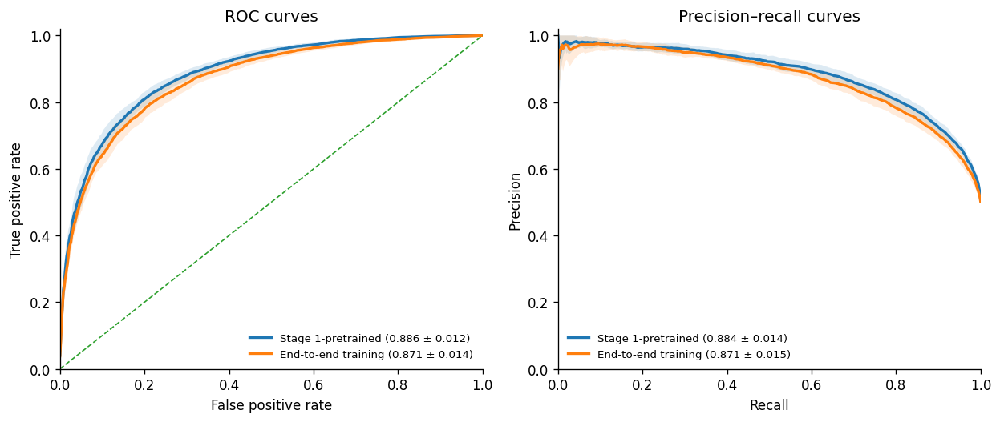

In [53]:
###展示预训练和不预训练的模型区别###
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, average_precision_score
from pathlib import Path

out_dir = Path("/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/model_comparison_pretrain_ornot")
out_dir.mkdir(parents=True, exist_ok=True)
dirs = {
    "Stage 1-pretrained": Path("/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/stage2_frozen_stage1_models_patchv2/optimizing/hd256_fhd256_head4_rlayer2_player1_clayer1_do05_lr5e5_wd5e4_fm2"),
    "End-to-end training": Path("/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_10runs_v2")
}

grid = np.linspace(0, 1, 500)
results = {}

for name, root in dirs.items():
    rocs, prs, aucs, aps = [], [], [], []

    files = sorted(root.rglob("*test_predictions.csv"))
    print(name, len(files), "runs")

    for f in files:
        d = pd.read_csv(f)

        label_col = next(c for c in d.columns if c.lower() in
                         ["label", "labels", "y_true", "true_label", "label_id", "target"])
        score_col = next(c for c in d.columns if c.lower() in
                         ["prob", "probability", "y_score", "y_prob", "pred_prob",
                          "positive_prob", "score", "prediction_score"])

        y = pd.to_numeric(d[label_col], errors="coerce")
        p = pd.to_numeric(d[score_col], errors="coerce")
        keep = y.notna() & p.notna()
        y, p = y[keep].astype(int), p[keep]

        fpr, tpr, _ = roc_curve(y, p)
        precision, recall, _ = precision_recall_curve(y, p)

        rocs.append(np.interp(grid, fpr, tpr))
        order = np.argsort(recall)
        prs.append(np.interp(grid, recall[order], precision[order]))
        aucs.append(roc_auc_score(y, p))
        aps.append(average_precision_score(y, p))

    results[name] = {
        "roc": np.array(rocs), "pr": np.array(prs),
        "auc": np.array(aucs), "ap": np.array(aps)
    }

summary = pd.DataFrame({
    name: {
        "ROC-AUC": f'{r["auc"].mean():.3f} ± {r["auc"].std(ddof=1):.3f}',
        "AUPR": f'{r["ap"].mean():.3f} ± {r["ap"].std(ddof=1):.3f}'
    }
    for name, r in results.items()
}).T

display(summary)

plt.rcParams.update({
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "pdf.fonttype": 42,
    "svg.fonttype": "none"
})

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.5))

for name, r in results.items():
    m, s = r["roc"].mean(0), r["roc"].std(0)
    axes[0].plot(grid, m, lw=2,
                 label=f'{name} ({r["auc"].mean():.3f} ± {r["auc"].std(ddof=1):.3f})')
    axes[0].fill_between(grid, np.clip(m-s, 0, 1), np.clip(m+s, 0, 1), alpha=.15)

    m, s = r["pr"].mean(0), r["pr"].std(0)
    axes[1].plot(grid, m, lw=2,
                 label=f'{name} ({r["ap"].mean():.3f} ± {r["ap"].std(ddof=1):.3f})')
    axes[1].fill_between(grid, np.clip(m-s, 0, 1), np.clip(m+s, 0, 1), alpha=.15)

axes[0].plot([0, 1], [0, 1], "--", lw=1)
axes[0].set(xlabel="False positive rate", ylabel="True positive rate",
            title="ROC curves", xlim=(0, 1), ylim=(0, 1.02))
axes[1].set(xlabel="Recall", ylabel="Precision",
            title="Precision–recall curves", xlim=(0, 1), ylim=(0, 1.02))

for ax in axes:
    ax.legend(frameon=False, fontsize=8)

plt.tight_layout()

plt.savefig(out_dir/"stage2_pretrained_vs_endtoend_curves.pdf", bbox_inches="tight")
plt.savefig(out_dir/"stage2_pretrained_vs_endtoend_curves.svg", bbox_inches="tight")
plt.savefig(out_dir/"stage2_pretrained_vs_endtoend_curves.png", dpi=600, bbox_inches="tight")

plt.show()

In [54]:
from pathlib import Path
import pandas as pd

root = Path("/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2")
out = root / "model_comparison_pretrain_ornot"
out.mkdir(parents=True, exist_ok=True)

files = {
    "Stage 1-pretrained": root / "stage2_pretrained_rnafm_esm_cross_noleak_stepwise/stage2_frozen_stage1_models_patchv2/optimizing/hd256_fhd256_head4_rlayer2_player1_clayer1_do05_lr5e5_wd5e4_fm2/all_runs_test_metrics.csv",
    "End-to-end training": root / "stage2_rnafm_esm2_independent_cross_attention_10runs_v2/all_runs_test_metrics.csv"
}

metrics = ["accuracy", "balanced_accuracy", "precision", "recall",
           "f1", "mcc", "roc_auc", "average_precision"]

table = pd.DataFrame({
    name: {
        m: f"{pd.to_numeric(df[m]).mean():.3f} ± {pd.to_numeric(df[m]).std():.3f}"
        for m in metrics
    }
    for name, file in files.items()
    for df in [pd.read_csv(file)]
}).rename(index={
    "accuracy": "Accuracy",
    "balanced_accuracy": "Balanced accuracy",
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1-score",
    "mcc": "MCC",
    "roc_auc": "ROC-AUC",
    "average_precision": "AUPR"
})

display(table)

table.to_csv(out / "stage2_pretrain_comparison.csv", encoding="utf-8-sig")
table.to_excel(out / "stage2_pretrain_comparison.xlsx")

print("Saved to:", out)

,Stage 1-pretrained,End-to-end training
Accuracy,0.797 ± 0.016,0.781 ± 0.018
Balanced accuracy,0.797 ± 0.016,0.781 ± 0.018
Precision,0.831 ± 0.038,0.788 ± 0.051
Recall,0.750 ± 0.069,0.781 ± 0.078
F1-score,0.786 ± 0.028,0.780 ± 0.023
MCC,0.600 ± 0.027,0.569 ± 0.036
ROC-AUC,0.886 ± 0.012,0.871 ± 0.014
AUPR,0.884 ± 0.014,0.871 ± 0.015


Saved to: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/model_comparison_pretrain_ornot


Transformer: 10 runs
CNN: 10 runs
MLP: 10 runs
LR: 10 runs
RF: 10 runs
LightGBM: 10 runs
End-to-end cross-attention: 10 runs
Stage 1-pretrained cross-attention: 10 runs
Dual CNN + Stage 1 auxiliary: 10 runs


,Model,ROC-AUC,AUPR,Balanced accuracy,Accuracy,Precision,Recall,F1,MCC
0,Transformer,0.8614 ± 0.0155,0.8589 ± 0.0202,0.7791 ± 0.0211,0.7791 ± 0.0211,0.7780 ± 0.0576,0.7948 ± 0.0575,0.7827 ± 0.0109,0.5640 ± 0.0391
1,CNN,0.8890 ± 0.0085,0.8879 ± 0.0084,0.8005 ± 0.0156,0.8005 ± 0.0156,0.7906 ± 0.0373,0.8236 ± 0.0519,0.8048 ± 0.0152,0.6050 ± 0.0277
2,MLP,0.8624 ± 0.0120,0.8606 ± 0.0137,0.7775 ± 0.0111,0.7775 ± 0.0111,0.7732 ± 0.0208,0.7884 ± 0.0571,0.7791 ± 0.0199,0.5576 ± 0.0231
3,LR,0.7911 ± 0.0112,0.7846 ± 0.0106,0.7145 ± 0.0108,0.7145 ± 0.0108,0.7133 ± 0.0141,0.7179 ± 0.0145,0.7155 ± 0.0101,0.4292 ± 0.0215
4,RF,0.8400 ± 0.0153,0.8364 ± 0.0171,0.7603 ± 0.0166,0.7603 ± 0.0166,0.7822 ± 0.0145,0.7214 ± 0.0243,0.7505 ± 0.0191,0.5223 ± 0.0328
5,LightGBM,0.8543 ± 0.0140,0.8523 ± 0.0159,0.7726 ± 0.0149,0.7726 ± 0.0149,0.7860 ± 0.0128,0.7490 ± 0.0233,0.7669 ± 0.0169,0.5458 ± 0.0296
6,End-to-end cross-attention,0.8711 ± 0.0140,0.8711 ± 0.0153,0.7812 ± 0.0178,0.7812 ± 0.0178,0.7880 ± 0.0513,0.7812 ± 0.0785,0.7802 ± 0.0228,0.5690 ± 0.0360
7,Stage 1-pretrained cross-attention,0.8864 ± 0.0117,0.8844 ± 0.0142,0.7969 ± 0.0162,0.7969 ± 0.0162,0.8315 ± 0.0376,0.7503 ± 0.0689,0.7856 ± 0.0281,0.6000 ± 0.0270
8,Dual CNN + Stage 1 auxiliary,0.8918 ± 0.0092,0.8904 ± 0.0104,0.8044 ± 0.0102,0.8044 ± 0.0102,0.8163 ± 0.0423,0.7932 ± 0.0647,0.8015 ± 0.0158,0.6136 ± 0.0193


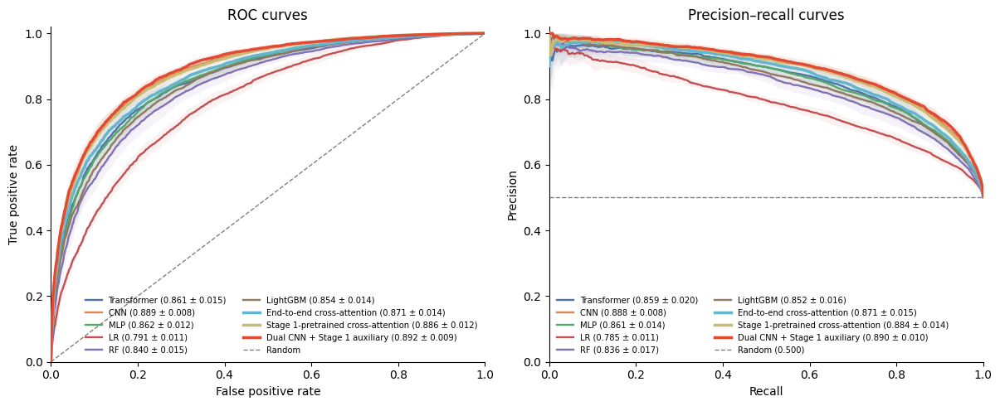


Saved:
/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/model_comparison_all_stage2_models/stage2_all_models_all_runs_metrics.csv
/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/model_comparison_all_stage2_models/stage2_all_models_summary_numeric.csv
/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/model_comparison_all_stage2_models/stage2_all_models_summary_mean_std.csv
/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/model_comparison_all_stage2_models/stage2_all_models_ROC_PR_curves.pdf
/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/model_comparison_all_stage2_models/stage2_all_models_ROC_PR_curves.svg
/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/model_comparison_all_stage2_models/stage2_all_models_ROC_PR_curves.png


In [11]:
###这次合并所有的stage2模型结果###
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_curve, precision_recall_curve, roc_auc_score,
    average_precision_score, accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score, matthews_corrcoef)

base = Path("/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2")
baseline_root = base / "stage2_noleak_baseline/internal_rnaesm_baselines_10runs"
out = base / "model_comparison_all_stage2_models"
out.mkdir(parents=True, exist_ok=True)

model_dirs = {
    "Transformer": baseline_root / "transformer",
    "CNN": baseline_root / "cnn",
    "MLP": baseline_root / "mlp",
    "LR": baseline_root / "lr",
    "RF": baseline_root / "rf",
    "LightGBM": baseline_root / "lgbm",
    "End-to-end cross-attention": base / "stage2_rnafm_esm2_independent_cross_attention_10runs_v2",
    "Stage 1-pretrained cross-attention": base / "stage2_pretrained_rnafm_esm_cross_noleak_stepwise/stage2_frozen_stage1_models_patchv2/optimizing/hd256_fhd256_head4_rlayer2_player1_clayer1_do05_lr5e5_wd5e4_fm2",
    "Dual CNN + Stage 1 auxiliary": base / "stage2_pretrained_rnafm_esm_cross_noleak_stepwise/stage2_dualcnn_stage1_aux/cnn128_aux128_k357_do05_lr1e4"
}

colors = {
    "Transformer": "#4C72B0",
    "CNN": "#DD8452",
    "MLP": "#55A868",
    "LR": "#C44E52",
    "RF": "#8172B3",
    "LightGBM": "#937860",
    "End-to-end cross-attention": "#64B5CD",
    "Stage 1-pretrained cross-attention": "#CCB974",
    "Dual CNN + Stage 1 auxiliary": "#E24A33"
}
highlight = {
    "End-to-end cross-attention",
    "Stage 1-pretrained cross-attention",
    "Dual CNN + Stage 1 auxiliary"
}
metric_cols = ["ROC-AUC", "AUPR", "Balanced accuracy", "Accuracy",
               "Precision", "Recall", "F1", "MCC"]

def find_col(df, candidates):
    cols = {c.lower(): c for c in df.columns}
    for c in candidates:
        if c in cols:
            return cols[c]
    raise ValueError(f"无法识别列名，当前列为：{df.columns.tolist()}")

def run_number(path):
    m = re.findall(r"run[_-]?(\d+)", path.stem.lower())
    if not m:
        m = re.findall(r"run[_-]?(\d+)", str(path).lower())
    return int(m[-1]) if m else 999

def prediction_files(root):
    files = sorted(root.rglob("*test_predictions.csv"), key=run_number)
    by_run = {}
    for f in files:
        r = run_number(f)
        if r != 999 and r not in by_run:
            by_run[r] = f
    return [by_run[r] for r in sorted(by_run)] if by_run else files

grid = np.linspace(0, 1, 501)
rows, curves = [], {}

for name, root in model_dirs.items():
    files = prediction_files(root)
    print(f"{name}: {len(files)} runs")
    if not files:
        print("  Missing:", root)
        continue

    rocs, prs, aucs, aps, prevalence = [], [], [], [], []
    for i, f in enumerate(files):
        d = pd.read_csv(f)
        y_col = find_col(d, ["y_true", "label", "labels", "binary_label",
                             "true_label", "label_id", "target"])
        p_col = find_col(d, ["y_prob", "prob", "probability", "pred_prob",
                             "positive_prob", "positive_probability", "y_score",
                             "score", "prediction_score"])
        y = pd.to_numeric(d[y_col], errors="coerce")
        p = pd.to_numeric(d[p_col], errors="coerce")
        keep = y.notna() & p.notna()
        y, p = y[keep].astype(int).to_numpy(), p[keep].astype(float).to_numpy()
        pred = (p >= 0.5).astype(int)

        auc, ap = roc_auc_score(y, p), average_precision_score(y, p)
        rows.append({
            "Model": name, "Run": run_number(f) if run_number(f) != 999 else i,
            "n_test": len(y), "positive_rate": y.mean(),
            "ROC-AUC": auc, "AUPR": ap,
            "Balanced accuracy": balanced_accuracy_score(y, pred),
            "Accuracy": accuracy_score(y, pred),
            "Precision": precision_score(y, pred, zero_division=0),
            "Recall": recall_score(y, pred, zero_division=0),
            "F1": f1_score(y, pred, zero_division=0),
            "MCC": matthews_corrcoef(y, pred),
            "prediction_file": str(f)
        })

        fpr, tpr, _ = roc_curve(y, p)
        precision, recall, _ = precision_recall_curve(y, p)
        roc_i = np.interp(grid, fpr, tpr)
        roc_i[0], roc_i[-1] = 0, 1
        order = np.argsort(recall)
        rocs.append(roc_i)
        prs.append(np.interp(grid, recall[order], precision[order]))
        aucs.append(auc)
        aps.append(ap)
        prevalence.append(y.mean())

    curves[name] = {
        "roc": np.asarray(rocs), "pr": np.asarray(prs),
        "auc": np.asarray(aucs), "ap": np.asarray(aps),
        "prevalence": np.asarray(prevalence)
    }

order = [m for m in model_dirs if m in curves]
all_runs = pd.DataFrame(rows)
all_runs["Model"] = pd.Categorical(all_runs["Model"], categories=order, ordered=True)
all_runs = all_runs.sort_values(["Model", "Run"]).reset_index(drop=True)

summary_numeric, summary_show = [], []
for name in order:
    d = all_runs[all_runs["Model"] == name]
    num = {"Model": name, "n_runs": len(d),
           "n_test_mean": d["n_test"].mean(),
           "positive_rate_mean": d["positive_rate"].mean()}
    show = {"Model": name}
    for metric in metric_cols:
        mean, std = d[metric].mean(), d[metric].std(ddof=1)
        num[f"{metric}_mean"], num[f"{metric}_std"] = mean, std
        show[metric] = f"{mean:.4f} ± {std:.4f}"
    summary_numeric.append(num)
    summary_show.append(show)

summary_numeric = pd.DataFrame(summary_numeric)
summary_show = pd.DataFrame(summary_show)
all_runs.to_csv(out / "stage2_all_models_all_runs_metrics.csv", index=False)
summary_numeric.to_csv(out / "stage2_all_models_summary_numeric.csv", index=False)
summary_show.to_csv(out / "stage2_all_models_summary_mean_std.csv", index=False)
display(summary_show)

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 10,
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none"
})

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.0))

for name in order:
    r = curves[name]
    roc_mean, roc_std = r["roc"].mean(0), r["roc"].std(0)
    pr_mean, pr_std = r["pr"].mean(0), r["pr"].std(0)
    lw = 2.5 if name in highlight else 1.7
    z = 4 if name in highlight else 2

    axes[0].plot(grid, roc_mean, color=colors[name], lw=lw, zorder=z,
                 label=f'{name} ({r["auc"].mean():.3f} ± {r["auc"].std(ddof=1):.3f})')
    axes[0].fill_between(grid, np.clip(roc_mean-roc_std, 0, 1),
                         np.clip(roc_mean+roc_std, 0, 1),
                         color=colors[name], alpha=.08, linewidth=0)

    axes[1].plot(grid, pr_mean, color=colors[name], lw=lw, zorder=z,
                 label=f'{name} ({r["ap"].mean():.3f} ± {r["ap"].std(ddof=1):.3f})')
    axes[1].fill_between(grid, np.clip(pr_mean-pr_std, 0, 1),
                         np.clip(pr_mean+pr_std, 0, 1),
                         color=colors[name], alpha=.08, linewidth=0)

random_pr = np.mean([x for r in curves.values() for x in r["prevalence"]])
axes[0].plot([0, 1], [0, 1], "--", color="grey", lw=1, label="Random")
axes[1].axhline(random_pr, ls="--", color="grey", lw=1,
                label=f"Random ({random_pr:.3f})")

axes[0].set(xlabel="False positive rate", ylabel="True positive rate",
            title="ROC curves", xlim=(0, 1), ylim=(0, 1.02))
axes[1].set(xlabel="Recall", ylabel="Precision",
            title="Precision–recall curves", xlim=(0, 1), ylim=(0, 1.02))

for ax in axes:
    ax.set_xticks(np.arange(0, 1.01, .2))
    ax.set_yticks(np.arange(0, 1.01, .2))
    ax.tick_params(direction="out")
    ax.legend(frameon=False, fontsize=7.2, ncol=2)

axes[0].legend(frameon=False, fontsize=7.2, ncol=2, loc="lower right")
axes[1].legend(frameon=False, fontsize=7.2, ncol=2, loc="lower left")
plt.tight_layout()

for ext in ["pdf", "svg", "png"]:
    plt.savefig(out / f"stage2_all_models_ROC_PR_curves.{ext}",
                dpi=600 if ext == "png" else None, bbox_inches="tight")
plt.show()

print("\nSaved:")
for f in [
    out / "stage2_all_models_all_runs_metrics.csv",
    out / "stage2_all_models_summary_numeric.csv",
    out / "stage2_all_models_summary_mean_std.csv",
    out / "stage2_all_models_ROC_PR_curves.pdf",
    out / "stage2_all_models_ROC_PR_curves.svg",
    out / "stage2_all_models_ROC_PR_curves.png"
]:
    print(f)

In [ ]:
###景晨的数据作为测试集###

In [72]:
from pathlib import Path
import pandas as pd
from IPython.display import display

INPUT_DIR = Path(r"/disk3/hejp/00_thesis/4_predict_translation/dataset/JC/pd_output")
OUTPUT_DIR = INPUT_DIR / "IP_qvalue_lt_0.01_results"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

files = sorted(f for f in INPUT_DIR.glob("*.xlsx") if not f.name.startswith("~$"))
summary, filtered_tables = [], []

for file in files:
    try:
        df = pd.read_excel(file, sheet_name="Proteins").dropna(how="all")
        df.columns = df.columns.astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
        accession = df["Accession"].astype("string").str.strip()
        qvalue = pd.to_numeric(
            df["Exp. q-value: Combined"].astype("string")
            .str.extract(r"([0-9.eE+-]+)", expand=False),
            errors="coerce"
        )
        keep = accession.str.startswith("IP", na=False) & qvalue.lt(0.01)
        result = df.loc[keep].copy().dropna(how="all")
        result["Accession"] = accession.loc[keep]
        result.insert(0, "source_file", file.name)
        result.to_excel(OUTPUT_DIR / f"{file.stem}_filtered.xlsx", index=False)
        filtered_tables.append(result)
        summary.append({
            "source_file": file.name,
            "total_rows": len(df),
            "filtered_IP_rows": len(result),
            "unique_IP": result["Accession"].nunique(),
            "status": "OK"
        })
        print(f"{file.name}: 筛选出 {len(result)} 条")
    except Exception as e:
        summary.append({
            "source_file": file.name,
            "total_rows": pd.NA,
            "filtered_IP_rows": pd.NA,
            "unique_IP": pd.NA,
            "status": f"FAILED: {e}"
        })

summary_df = pd.DataFrame(summary)
summary_df.to_csv(OUTPUT_DIR / "per_file_summary.csv", index=False, encoding="utf-8-sig")

all_filtered = pd.concat(filtered_tables, ignore_index=True).dropna(how="all")
all_filtered.to_csv(
    OUTPUT_DIR / "all_filtered_IP_before_dedup.csv",
    index=False, encoding="utf-8-sig"
)

deduplicated = all_filtered.drop_duplicates(subset="Accession", keep="first")
deduplicated.to_csv(
    OUTPUT_DIR / "all_filtered_IP_deduplicated.csv",
    index=False, encoding="utf-8-sig"
)

display(summary_df)
print(f"\n筛选后合并记录数：{len(all_filtered)}")
print(f"按Accession去重后：{len(deduplicated)}")
print(f"移除重复记录数：{len(all_filtered) - len(deduplicated)}")
print(f"输出路径：{OUTPUT_DIR}")

C016_20260627_COFSIS_293T_1.xlsx: 筛选出 84 条
C016_20260627_COFSIS_293T_2.xlsx: 筛选出 74 条
C016_20260627_COFSIS_293T_3.xlsx: 筛选出 99 条
C016_20260627_Normal_5ug_293T_1.xlsx: 筛选出 96 条
C016_20260627_Normal_5ug_293T_2.xlsx: 筛选出 113 条
C016_20260627_Normal_5ug_293T_3.xlsx: 筛选出 94 条
C016_20260627_SAX7_293T_1.xlsx: 筛选出 96 条
C016_20260627_SAX7_293T_2.xlsx: 筛选出 103 条
C016_20260627_SAX7_293T_3.xlsx: 筛选出 107 条
C016_20260627_SAX9_293T_1.xlsx: 筛选出 122 条
C016_20260627_SAX9_293T_2.xlsx: 筛选出 130 条
C016_20260627_SAX9_293T_3.xlsx: 筛选出 115 条
C016_20260627_SCX3_293T_1.xlsx: 筛选出 89 条
C016_20260627_SCX3_293T_2.xlsx: 筛选出 86 条
C016_20260627_SCX3_293T_3.xlsx: 筛选出 72 条
C016_20260627_SCX7_293T_1.xlsx: 筛选出 131 条
C016_20260627_SCX7_293T_2.xlsx: 筛选出 124 条
C016_20260627_SCX7_293T_3.xlsx: 筛选出 125 条
C016_20260714_52H_COFSIS_293T_1.xlsx: 筛选出 76 条
C016_20260714_52H_COFSIS_293T_2.xlsx: 筛选出 79 条
C016_20260714_52H_COFSIS_293T_3.xlsx: 筛选出 61 条
C016_20260714_52H_SIS_293T_1.xlsx: 筛选出 101 条
C016_20260714_52H_SIS_293T_2.xlsx: 筛选出 89 条

,source_file,total_rows,filtered_IP_rows,unique_IP,status
0,C016_20260627_COFSIS_293T_1.xlsx,5220,84,84,OK
1,C016_20260627_COFSIS_293T_2.xlsx,5108,74,74,OK
2,C016_20260627_COFSIS_293T_3.xlsx,4753,99,99,OK
3,C016_20260627_Normal_5ug_293T_1.xlsx,5291,96,96,OK
4,C016_20260627_Normal_5ug_293T_2.xlsx,5253,113,113,OK
5,C016_20260627_Normal_5ug_293T_3.xlsx,5314,94,94,OK
6,C016_20260627_SAX7_293T_1.xlsx,4242,96,96,OK
7,C016_20260627_SAX7_293T_2.xlsx,4379,103,103,OK
8,C016_20260627_SAX7_293T_3.xlsx,4325,107,107,OK
9,C016_20260627_SAX9_293T_1.xlsx,4331,122,122,OK



筛选后合并记录数：2881
按Accession去重后：1216
移除重复记录数：1665
输出路径：/disk3/hejp/00_thesis/4_predict_translation/dataset/JC/pd_output/IP_qvalue_lt_0.01_results


In [73]:
####提取想要的分类信息，并提取序列信息####
import pandas as pd
import numpy as np

# 1) 读取 OpenProt 表
openprot_file = "/disk3/hejp/00_thesis/4_predict_translation/dataset/openprot/ensembl/human-openprot-2_2-refprots+altprots+isoforms-GRCh38.106-uniprot2022_06_01.tsv"
df = pd.read_csv(openprot_file, sep="\t", low_memory=False)
print(df.shape)
# 2) 基础清洗
df["protein type"] = df["protein type"].fillna("Unknown")
df["MS score"] = pd.to_numeric(df["MS score"], errors="coerce").fillna(0)
print(df.shape)
df["TE Translation Event score"] = pd.to_numeric(df["TE Translation Event score"], errors="coerce").fillna(0)

# 3) 只保留 AltProt
alt = df[df["protein type"] == "AltProt"].copy()

# 4) 定义你关心的 4 类
def assign_group(row):
    ms = row["MS score"]
    te = row["TE Translation Event score"]
    if ms == 0 and te >= 2:
        return "MS-|Ribo++"
    elif ms == 1 and te >= 2:
        return "MS+|Ribo++"
    elif ms >= 2 and te >= 2:
        return "MS++|Ribo++"
    elif ms >= 2 and te ==1:
        return "MS++|Ribo+"
    elif ms == 1 and te ==1:
        return "MS+|Ribo+"
    elif ms == 0 and te ==1:
        return "MS-|Ribo+"
    elif ms == 0 and te ==0:
        return "MS-|Ribo-"
    elif ms == 1 and te ==0:
        return "MS+|Ribo-"
    elif ms >= 2 and te ==0:
        return "MS++|Ribo-"
    else:
        return "nan"

alt["group"] = alt.apply(assign_group, axis=1)

# 5) 只保留这 4 类
alt4 = alt[alt["group"].notna()].copy()

# 6) 看结果
print("原始表大小:", df.shape)
print("AltProt 数量:", alt.shape)
print("4 类 AltProt 数量:", alt4.shape)
print("\n各组数量：")
print(alt4["group"].value_counts(dropna=False))

# 7) 看后面提序列最关键的列是否存在
need_cols = [
    "protein accession",
    "protein accession (others)",
    "gene symbol",
    "transcript accession",
    "start transcript coordinates",
    "stop transcript coordinates",
    "protein length (a.a.)",
    "MS score",
    "TE Translation Event score",
    "group"
]

print("\n关键列是否都在：")
for c in need_cols:
    print(c, "->", c in alt4.columns)

# 8) 展示前几行
display(alt4[need_cols].head())

(2572995, 22)
(2572995, 22)
原始表大小: (2572995, 22)
AltProt 数量: (2140853, 23)
4 类 AltProt 数量: (2140853, 23)

各组数量：
group
MS-|Ribo-      904864
MS+|Ribo-      634568
MS++|Ribo-     521655
MS-|Ribo+       16898
MS-|Ribo++      14521
MS++|Ribo+      12984
MS+|Ribo+       12355
MS++|Ribo++     11654
MS+|Ribo++      11354
Name: count, dtype: int64

关键列是否都在：
protein accession -> True
protein accession (others) -> True
gene symbol -> True
transcript accession -> True
start transcript coordinates -> True
stop transcript coordinates -> True
protein length (a.a.) -> True
MS score -> True
TE Translation Event score -> True
group -> True


,protein accession,protein accession (others),gene symbol,transcript accession,start transcript coordinates,stop transcript coordinates,protein length (a.a.),MS score,TE Translation Event score,group
1,IP_057216,"IP_057216,IP_057216",OR4F5,NM_001005484.2,480.0,621.0,46,0,0,MS-|Ribo-
2,IP_057216,"IP_057216,IP_057216",OR4F5,ENST00000641515.2,480.0,621.0,46,0,0,MS-|Ribo-
13,IP_057218,"IP_057218,IP_057218,IP_057218,IP_057218,IP_057...",OR4F29,NM_001005221.2,248.0,350.0,33,2,0,MS++|Ribo-
14,IP_057218,"IP_057218,IP_057218,IP_057218,IP_057218,IP_057...",OR4F16,XM_024449992.2,2743.0,2845.0,33,2,0,MS++|Ribo-
15,IP_057218,"IP_057218,IP_057218,IP_057218,IP_057218,IP_057...",OR4F16,XM_017002410.2,2755.0,2857.0,33,2,0,MS++|Ribo-


In [74]:
ip_file = "/disk3/hejp/00_thesis/4_predict_translation/dataset/JC/pd_output/IP_qvalue_lt_0.01_results/all_filtered_IP_deduplicated.csv"
out_file = "/disk3/hejp/00_thesis/4_predict_translation/dataset/JC/openprot_info/alt4_matched_IP.csv"

ids = pd.read_csv(ip_file)["Accession"].astype(str).str.strip().unique()
result = alt4[
    alt4["protein accession"].astype(str).str.strip().isin(ids)
].copy()

result.to_csv(out_file, index=False, encoding="utf-8-sig")

print("输入IP数：", len(ids))
print("匹配IP数：", result["protein accession"].nunique())
print("提取记录数：", len(result))
print("未匹配IP数：", len(set(ids) - set(result["protein accession"].astype(str).str.strip())))
display(result.head())

输入IP数： 1216
匹配IP数： 996
提取记录数： 3534
未匹配IP数： 220


,protein accession,protein accession (others),protein type,protein length (a.a.),molecular weight (kDa),isoelectric point,frame,gene symbol,chr,start genomic coordinates,...,type,localization,start transcript coordinates,stop transcript coordinates,MS score,TE Translation Event score,Kozak motif,High-efficiency TIS motif,Domains,group
23854,IP_060425,"IP_060425,IP_060425,IP_060425,IP_060425,IP_060...",AltProt,42,4.65,12.9,3.0,KDM1A,1,23082664.0,...,mRNA,3'UTR,2796.0,2925.0,1,0,+,-,0,MS+|Ribo-
23855,IP_060425,"IP_060425,IP_060425,IP_060425,IP_060425,IP_060...",AltProt,42,4.65,12.9,3.0,KDM1A,1,23082664.0,...,mRNA,3'UTR,2778.0,2907.0,1,0,+,-,0,MS+|Ribo-
23856,IP_060425,"IP_060425,IP_060425,IP_060425,IP_060425,IP_060...",AltProt,42,4.65,12.9,3.0,KDM1A,1,23082664.0,...,mRNA,3'UTR,2736.0,2865.0,1,0,+,-,0,MS+|Ribo-
23857,IP_060425,"IP_060425,IP_060425,IP_060425,IP_060425,IP_060...",AltProt,42,4.65,12.9,3.0,KDM1A,1,23082664.0,...,mRNA,3'UTR,2718.0,2847.0,1,0,+,-,0,MS+|Ribo-
23858,IP_060425,"IP_060425,IP_060425,IP_060425,IP_060425,IP_060...",AltProt,42,4.65,12.9,3.0,KDM1A,1,23082664.0,...,mRNA,3'UTR,2826.0,2955.0,1,0,+,-,0,MS+|Ribo-


In [75]:
#合并大表alt4和小标2pep的alt4_2pep#
alt4_combined=result

###去重复###
# 1) 只保留 Ensembl transcript
alt4_ens = alt4_combined.copy()
alt4_ens["transcript accession"] = alt4_ens["transcript accession"].astype(str).str.strip()
alt4_ens = alt4_ens[alt4_ens["transcript accession"].str.startswith("ENST", na=False)].copy()

print("只保留 ENST 后行数:", alt4_ens.shape[0])
print("唯一 protein accession 数:", alt4_ens["protein accession"].nunique())
display(alt4_ens[["protein accession", "transcript accession"]].head(10))
alt4_ens["tx_base"] = alt4_ens["transcript accession"].str.split(".").str[0]

##读取cDNA的fasta文件，引入transcript长度，然后去重##
from Bio import SeqIO
import pandas as pd

#cdna_fasta = "/disk3/hejp/00_thesis/4_predict_translation/dataset/openprot/ensembl/Homo_sapiens.GRCh38.cdna.all.fa"
cdna_fasta = "/disk3/hejp/00_thesis/4_predict_translation/dataset/openprot/ensembl/Homo_sapiens.GRCh38.cdna.ncrna.merge.fa"#这个是合并了cdna和ncrna之后的fa文件


# 1) 读取 fasta
tx_seq_dict = {}
tx_len_dict = {}

for record in SeqIO.parse(cdna_fasta, "fasta"):
    tx_id = record.id.split("|")[0]   # 保留完整 ENSTxxxx.x
    seq = str(record.seq).upper().replace("U", "T")
    
    tx_seq_dict[tx_id] = seq
    tx_len_dict[tx_id] = len(seq)

print("fasta中 transcript 数:", len(tx_seq_dict))

# 2) 直接用完整 accession 匹配
alt4_ens["transcript_length"] = alt4_ens["transcript accession"].map(tx_len_dict)

# 3) 检查匹配情况
print("\ntranscript_length 缺失情况：")
print(alt4_ens["transcript_length"].isna().value_counts())

print("\n匹配成功比例：", alt4_ens["transcript_length"].notna().mean())

# 4) 看前几行
display(
    alt4_ens[[
        "protein accession",
        "transcript accession",
        "transcript_length"
    ]].head(10)
)

# 5) 看没匹配到的（理论上应该接近 0）
not_found = alt4_ens[alt4_ens["transcript_length"].isna()]
display(not_found[["protein accession", "transcript accession"]].head(10))

alt4_ens_found=alt4_ens[alt4_ens['transcript_length'].notna()]
display(alt4_ens_found.head(10))

只保留 ENST 后行数: 1639
唯一 protein accession 数: 996


,protein accession,transcript accession
23858,IP_060425,ENST00000692975.1
23859,IP_060425,ENST00000691682.1
23860,IP_060425,ENST00000691404.1
23861,IP_060425,ENST00000688235.1
23862,IP_060425,ENST00000687202.1
23863,IP_060425,ENST00000688943.1
23864,IP_060425,ENST00000690391.1
23865,IP_060425,ENST00000602503.1
35536,IP_062202,ENST00000361328.7
35537,IP_062202,ENST00000684572.1


fasta中 transcript 数: 267165

transcript_length 缺失情况：
transcript_length
False    1632
True        7
Name: count, dtype: int64

匹配成功比例： 0.9957291031116534


,protein accession,transcript accession,transcript_length
23858,IP_060425,ENST00000692975.1,3793.0
23859,IP_060425,ENST00000691682.1,3710.0
23860,IP_060425,ENST00000691404.1,3853.0
23861,IP_060425,ENST00000688235.1,5004.0
23862,IP_060425,ENST00000687202.1,5783.0
23863,IP_060425,ENST00000688943.1,4653.0
23864,IP_060425,ENST00000690391.1,4053.0
23865,IP_060425,ENST00000602503.1,2810.0
35536,IP_062202,ENST00000361328.7,4316.0
35537,IP_062202,ENST00000684572.1,9456.0


,protein accession,transcript accession
732154,IP_155962,ENST00000623032.1
1798719,IP_562313,ENST00000635661.1
1871018,IP_601952,ENST00000624769.1
2037793,IP_690066,ENST00000625085.1
2070050,IP_707627,ENST00000624641.1
2097260,IP_723480,ENST00000624410.1
2118074,IP_734862,ENST00000623096.1


,protein accession,protein accession (others),protein type,protein length (a.a.),molecular weight (kDa),isoelectric point,frame,gene symbol,chr,start genomic coordinates,...,start transcript coordinates,stop transcript coordinates,MS score,TE Translation Event score,Kozak motif,High-efficiency TIS motif,Domains,group,tx_base,transcript_length
23858,IP_060425,"IP_060425,IP_060425,IP_060425,IP_060425,IP_060...",AltProt,42,4.65,12.90,3.0,KDM1A,1,23082664.0,...,2826.0,2955.0,1,0,+,-,0,MS+|Ribo-,ENST00000692975,3793.0
23859,IP_060425,"IP_060425,IP_060425,IP_060425,IP_060425,IP_060...",AltProt,42,4.65,12.90,1.0,KDM1A,1,23082664.0,...,2743.0,2872.0,1,0,+,-,0,MS+|Ribo-,ENST00000691682,3710.0
23860,IP_060425,"IP_060425,IP_060425,IP_060425,IP_060425,IP_060...",AltProt,42,4.65,12.90,3.0,KDM1A,1,23082664.0,...,2886.0,3015.0,1,0,+,-,0,MS+|Ribo-,ENST00000691404,3853.0
23861,IP_060425,"IP_060425,IP_060425,IP_060425,IP_060425,IP_060...",AltProt,42,4.65,12.90,2.0,KDM1A,1,23082664.0,...,4037.0,4166.0,1,0,+,-,0,MS+|Ribo-,ENST00000688235,5004.0
23862,IP_060425,"IP_060425,IP_060425,IP_060425,IP_060425,IP_060...",AltProt,42,4.65,12.90,1.0,KDM1A,1,23082664.0,...,4816.0,4945.0,1,0,+,-,0,MS+|Ribo-,ENST00000687202,5783.0
23863,IP_060425,"IP_060425,IP_060425,IP_060425,IP_060425,IP_060...",AltProt,42,4.65,12.90,3.0,KDM1A,1,23082664.0,...,3741.0,3870.0,1,0,+,-,0,MS+|Ribo-,ENST00000688943,4653.0
23864,IP_060425,"IP_060425,IP_060425,IP_060425,IP_060425,IP_060...",AltProt,42,4.65,12.90,3.0,KDM1A,1,23082664.0,...,3084.0,3213.0,1,0,+,-,0,MS+|Ribo-,ENST00000690391,4053.0
23865,IP_060425,"IP_060425,IP_060425,IP_060425,IP_060425,IP_060...",AltProt,42,4.65,12.90,2.0,KDM1A,1,23082664.0,...,1793.0,1922.0,1,0,+,-,0,MS+|Ribo-,ENST00000602503,2810.0
35536,IP_062202,"IP_062202,IP_062202,IP_062202,IP_062202,IP_062...",AltProt,64,7.53,11.78,2.0,ZSCAN20,1,33494232.0,...,2042.0,2237.0,1,0,-,-,1,MS+|Ribo-,ENST00000361328,4316.0
35537,IP_062202,"IP_062202,IP_062202,IP_062202,IP_062202,IP_062...",AltProt,64,7.53,11.78,3.0,ZSCAN20,1,33494232.0,...,2046.0,2241.0,1,0,-,-,1,MS+|Ribo-,ENST00000684572,9456.0


In [76]:
# 先看去重前
print("去重前行数:", alt4_ens_found.shape[0])
print("唯一 protein accession 数:", alt4_ens_found["protein accession"].nunique())

# 按 transcript_length 从大到小排序，再按 protein accession 去重
alt4_ens_found_dedup = (
    alt4_ens_found
    .sort_values(["protein accession", "transcript_length"], ascending=[True, False])
    .drop_duplicates(subset=["protein accession"], keep="first")
    .copy()
)

# 看去重后
print("去重后行数:", alt4_ens_found_dedup.shape[0])

# 看前几行
display(
    alt4_ens_found_dedup[[
        "protein accession",
        "transcript accession",
        "transcript_length",
        "group"
    ]].head(10)
)
print(alt4_ens_found_dedup['group'].value_counts())

去重前行数: 1632
唯一 protein accession 数: 990
去重后行数: 990


,protein accession,transcript accession,transcript_length,group
23862,IP_060425,ENST00000687202.1,5783.0,MS+|Ribo-
35537,IP_062202,ENST00000684572.1,9456.0,MS+|Ribo-
37938,IP_062563,ENST00000397799.2,4669.0,MS++|Ribo-
38745,IP_062720,ENST00000373091.8,9491.0,MS+|Ribo-
52339,IP_064647,ENST00000371733.8,5163.0,MS-|Ribo-
52545,IP_064664,ENST00000428468.6,3660.0,MS+|Ribo-
59092,IP_065651,ENST00000613538.1,4625.0,MS+|Ribo-
63381,IP_066155,ENST00000370855.5,4406.0,MS++|Ribo-
64668,IP_066312,ENST00000330010.12,3195.0,MS++|Ribo++
68215,IP_066637,ENST00000359242.7,7560.0,MS-|Ribo-


group
MS++|Ribo-     537
MS+|Ribo-      208
MS-|Ribo-      190
MS++|Ribo++     22
MS++|Ribo+      16
MS-|Ribo++       5
MS+|Ribo+        5
MS-|Ribo+        4
MS+|Ribo++       3
Name: count, dtype: int64


In [77]:
# 先复制一份，避免改原表
ml_df = alt4_ens_found_dedup.copy()

# 1) 坐标转成数值
ml_df["start transcript coordinates"] = pd.to_numeric(
    ml_df["start transcript coordinates"], errors="coerce"
)
ml_df["stop transcript coordinates"] = pd.to_numeric(
    ml_df["stop transcript coordinates"], errors="coerce"
)

# 2) 提取序列函数
#UP_LEN = 50
#DOWN_LEN = 50

UP_LEN = 450
DOWN_LEN = 450

def extract_tx_seqs(row):
    tx_id = row["transcript accession"]
    start = row["start transcript coordinates"]
    stop = row["stop transcript coordinates"]
    
    # transcript 序列字典：你前面已经建立过 tx_seq_dict
    tx_seq = tx_seq_dict.get(tx_id, None)
    
    if tx_seq is None or pd.isna(start) or pd.isna(stop):
        return pd.Series({
            "orf_rna_seq": pd.NA,
            "upstream_50nt": pd.NA,
            "downstream_50nt": pd.NA,
            "orf_nt_len": pd.NA,
            "seq_ok": 0
        })
    
    # transcript 坐标通常按 1-based, inclusive 处理
    s = int(min(start, stop))
    e = int(max(start, stop))
    
    # 转成 python 切片
    s0 = s - 1
    e0 = e-1
    
    # 边界检查
    if s0 < 0 or e0 > len(tx_seq):
        return pd.Series({
            "orf_rna_seq": pd.NA,
            "upstream_50nt": pd.NA,
            "downstream_50nt": pd.NA,
            "orf_nt_len": pd.NA,
            "seq_ok": 0
        })
    
    orf_seq = tx_seq[s0:e0]
    up_seq = tx_seq[max(0, s0 - UP_LEN): s0]
    down_seq = tx_seq[e0: min(len(tx_seq), e0 + DOWN_LEN)]
    
    return pd.Series({
        "orf_rna_seq": orf_seq,
        "upstream_50nt": up_seq,
        "downstream_50nt": down_seq,
        "orf_nt_len": len(orf_seq),
        "seq_ok": 1
    })

# 3) 批量提取
seq_df = ml_df.apply(extract_tx_seqs, axis=1)
ml_df = pd.concat([ml_df, seq_df], axis=1)

# 4) 看结果
print("成功提取比例：", ml_df["seq_ok"].mean())
print("\nseq_ok 计数：")
print(ml_df["seq_ok"].value_counts(dropna=False))

display(
    ml_df[[
        "protein accession",
        "transcript accession",
        "start transcript coordinates",
        "stop transcript coordinates",
        "transcript_length",
        "orf_nt_len",
        "orf_rna_seq",
        "upstream_50nt",
        "downstream_50nt",
        "group"
    ]].head(10)
)

成功提取比例： 1.0

seq_ok 计数：
seq_ok
1    990
Name: count, dtype: int64


,protein accession,transcript accession,start transcript coordinates,stop transcript coordinates,transcript_length,orf_nt_len,orf_rna_seq,upstream_50nt,downstream_50nt,group
23862,IP_060425,ENST00000687202.1,4816.0,4945.0,5783.0,129,ATGGCTCATAGGATTGCTGTAAGGTCTCAATTACTAGGGGCTTCCA...,TATCATGGAAAACATAAGTGACGATGTGATTGTTGGCCGATGCCTG...,TGTCATAGCCCAGACCTGCTGAGCTGCGAGGCTTAAGTGTCCCTGA...,MS+|Ribo-
35537,IP_062202,ENST00000684572.1,2046.0,2241.0,9456.0,195,ATGAGGATGAAGACCAGATTTCAGAGCAGGACATTTTTGAGGGTTT...,GTATTGCAGGTGTGCACTGGGGCTATGAGGAGACCAAGGCCTTCCT...,AAAAACTTATTGACCATCAAGGCCTGTACCTTGCAGAGAAACCCTA...,MS+|Ribo-
37938,IP_062563,ENST00000397799.2,3212.0,3680.0,4669.0,468,ATGAGCACTCTTCCCTTTCTCCCCTTCCACCTGCTGCGGGCTGGGC...,AGCTCCCCCTGGGACCTCCAGCATATGACAGTGGACTAAGGACTGT...,GTGCTGGGAGTGGTGGACATTCCTGCTCGTGCAAAGATGGCCACTT...,MS++|Ribo-
38745,IP_062720,ENST00000373091.8,4712.0,4829.0,9491.0,117,ATGGAGGGGCAGGTTTTGAACAGGGGAGGGAGGTTCTGGGGATTCT...,ACAGACTAACTTTGGGCTAGGTGAGGGAAACCAGAAGAGACCAAAA...,GGAAGAGCTTCATTTGGATCTCAAGGGCTTTCTCATCTGGGTGAAG...,MS+|Ribo-
52339,IP_064647,ENST00000371733.8,3189.0,3378.0,5163.0,189,ATGATTGGTGCAAATTGGCTAAAGTGCATTTTTAAATTTCCTCTAC...,TTCTTTGGCAACAATATAGTATTCTTCTTCCTGAATACTGAAACTA...,ATTTTTAAAAAGATTTATCTGGATTTAGAGAATTTTAGATCAACAG...,MS-|Ribo-
52545,IP_064664,ENST00000428468.6,1812.0,1905.0,3660.0,93,ATGGGGGCAAGAAGCACAGAATTACTGCCGAGATTTTTTCTCCAAA...,CAGTTGCCAAAAAGCCATACAATCCCATTTTGGGCGAGATTTTTCA...,TGTATGCAAAATATGCAACAGGGGAAAATACAGTCTTTGTAGATAC...,MS+|Ribo-
59092,IP_065651,ENST00000613538.1,2265.0,2535.0,4625.0,270,ATGTTTTCAGTGTCCTGTGTACATATAGAATTGTTAAAGTTGTCAT...,TTTGCCCTGACTTCTCTACGGCTCTGGCTTCTTCCCGAAGAGATAT...,CAGAACAGTAGCAATAAGTTTTAGGATACCATCTTGAATGTCTAGT...,MS+|Ribo-
63381,IP_066155,ENST00000370855.5,3271.0,3379.0,4406.0,108,ATGAGGGGCATACTGTGGGTTAGGAACTCTCTCTCTGCAGGGCTTA...,AACATAGATGTTAATGTTATATAGGTTCTACGGAGAGCATTACTGG...,GTTTTGAATGGCAGAACAAAGCATGAATCAGACACACATCTTGCCT...,MS++|Ribo-
64668,IP_066312,ENST00000330010.12,33.0,291.0,3195.0,258,ATGCGGGAACAGGCTGCACACCAGGACTTTTATGGAAACTTGCTGC...,AACAGCTGCAGCCGGCGCTGGGCCCGCCTGGA,AGCAAACATGAATGATATTTCCCAAAAGGCTGAGATTAAAGAAATG...,MS++|Ribo++
68215,IP_066637,ENST00000359242.7,6716.0,6923.0,7560.0,207,ATGTTTTATGCTTTTTTTCTGATCAGAGATGGGGGCCTGGTCCCCT...,AGGCTGTCTTCAATTTGTACTCTCTTTTATTCGTTTTATACTAATG...,AAAAAATCTTAGTACTCATCATACTAAAAACATGCTTGACCCTTGC...,MS-|Ribo-


In [79]:
out_csv='/disk3/hejp/00_thesis/4_predict_translation/dataset/JC/openprot_info/test_table_JC.csv.gz'
ml_df.to_csv(out_csv, index=False, compression="gzip")

In [ ]:
df_gencode_pos=pd.read_csv('/disk3/hejp/00_thesis/4_predict_translation/data/processed/dataset_nt450_v3/test_table_gencode.csv.gz')
display(df_gencode_pos.head())

,sample_id,protein_accession,transcript_accession,protein_len_aa,orf_seq,upstream_seq_50nt,downstream_seq_50nt,orf_nt_len,label_raw,protein_len_a,label_id
0,c1riboseqorf663,LINC01128,ENST00000670780,2,ATGGCATGA,GGGCGGGGTCTCGGGCAGGGGCGGGGAGCTTACCGACCTCCCGCCC...,TCTCGGCTCACTGCGACCTCTGCTTCCTGGGTTCAAGGATTCTCCT...,9,gencode,2,8
1,c1riboseqorf678,SDF4,ENST00000465727,4,ATGGCAGTGGCCTGA,GGCGTCCCCTCCGTGAGGTCGCGCCCGTTCGCACCGCCCCCGCCCG...,TCCGGGCCCGTTGGCGGCGTCACTGACGCTTCGCTCCGGTCCTCGG...,15,gencode,4,8
2,c1riboseqorf6,UBE2J2,ENST00000450390,32,ATGTGTGACTGGGCTTTGGAGGAGACTGGAGCCTCAGCCCTGTCCT...,TCCTGAAGTCGTGGAGGAGATTAAACAAAAACAGAAAGCACAAGAC...,CTTATCTTCCGTGTTGTCTTTGGACCTGTTTTAGTAAACCCGTTTT...,99,gencode,32,8
3,c1riboseqorf688,MRPL20,ENST00000482352,9,ATGGCAGCGGCGCTGCGCGTGCGTTGTTGA,TCCGACCCGGGCAAG,GTGTTCGGGACGCCGGCCTGCAGGCGCCATGGTCTTCCTCACCGCG...,30,gencode,9,8
4,c1riboseqorf312,ANKRD65,ENST00000454272,21,ATGGGGGGCTCCAGTTGGCCTGGGACACGGCTGGGGGCAGGCCAGA...,A,GATCCCTGCTCCCCCCCAGATGGACTCCCAGAGGCCTGAGCCCAGA...,66,gencode,21,8


In [82]:
df_gencode_pos=pd.read_csv('/disk3/hejp/00_thesis/4_predict_translation/dataset/JC/openprot_info/test_table_JC.csv.gz')
display(df_gencode_pos.head())

,protein accession,protein accession (others),protein type,protein length (a.a.),molecular weight (kDa),isoelectric point,frame,gene symbol,chr,start genomic coordinates,...,High-efficiency TIS motif,Domains,group,tx_base,transcript_length,orf_rna_seq,upstream_50nt,downstream_50nt,orf_nt_len,seq_ok
0,IP_060425,"IP_060425,IP_060425,IP_060425,IP_060425,IP_060...",AltProt,42,4.65,12.90,1.0,KDM1A,1,23082664.0,...,-,0,MS+|Ribo-,ENST00000687202,5783.0,ATGGCTCATAGGATTGCTGTAAGGTCTCAATTACTAGGGGCTTCCA...,TATCATGGAAAACATAAGTGACGATGTGATTGTTGGCCGATGCCTG...,TGTCATAGCCCAGACCTGCTGAGCTGCGAGGCTTAAGTGTCCCTGA...,129,1
1,IP_062202,"IP_062202,IP_062202,IP_062202,IP_062202,IP_062...",AltProt,64,7.53,11.78,3.0,ZSCAN20,1,33494232.0,...,-,1,MS+|Ribo-,ENST00000684572,9456.0,ATGAGGATGAAGACCAGATTTCAGAGCAGGACATTTTTGAGGGTTT...,GTATTGCAGGTGTGCACTGGGGCTATGAGGAGACCAAGGCCTTCCT...,AAAAACTTATTGACCATCAAGGCCTGTACCTTGCAGAGAAACCCTA...,195,1
2,IP_062563,"IP_062563,IP_062563,IP_062563,IP_062563",AltProt,155,17.44,11.35,2.0,COL8A2,1,36096228.0,...,-,6,MS++|Ribo-,ENST00000397799,4669.0,ATGAGCACTCTTCCCTTTCTCCCCTTCCACCTGCTGCGGGCTGGGC...,AGCTCCCCCTGGGACCTCCAGCATATGACAGTGGACTAAGGACTGT...,GTGCTGGGAGTGGTGGACATTCCTGCTCGTGCAAAGATGGCCACTT...,468,1
3,IP_062720,"IP_062720,IP_062720",AltProt,38,4.29,10.45,2.0,GRIK3,1,36800189.0,...,-,0,MS+|Ribo-,ENST00000373091,9491.0,ATGGAGGGGCAGGTTTTGAACAGGGGAGGGAGGTTCTGGGGATTCT...,ACAGACTAACTTTGGGCTAGGTGAGGGAAACCAGAAGAGACCAAAA...,GGAAGAGCTTCATTTGGATCTCAAGGGCTTTCTCATCTGGGTGAAG...,117,1
4,IP_064647,"IP_064647,IP_064647,IP_064647,IP_064647,IP_064...",AltProt,62,7.45,9.94,3.0,EPS15,1,51356048.0,...,-,0,MS-|Ribo-,ENST00000371733,5163.0,ATGATTGGTGCAAATTGGCTAAAGTGCATTTTTAAATTTCCTCTAC...,TTCTTTGGCAACAATATAGTATTCTTCTTCCTGAATACTGAAACTA...,ATTTTTAAAAAGATTTATCTGGATTTAGAGAATTTTAGATCAACAG...,189,1


In [ ]:
df_gencode_pos=pd.read_csv('/disk3/hejp/00_thesis/4_predict_translation/dataset/JC/openprot_info/test_table_JC.csv.gz')
df_gencode_pos['sample_id']=df_gencode_pos['protein accession']
df_gencode_pos['protein_len_aa']=df_gencode_pos['protein length (a.a.)']
df_gencode_pos['orf_seq']=df_gencode_pos['orf_rna_seq']
df_gencode_pos['upstream_seq_50nt']=df_gencode_pos['upstream_50nt']
df_gencode_pos['downstream_seq_50nt']=df_gencode_pos['downstream_50nt']
df_gencode_pos['label_raw']=df_gencode_pos['group']
df_gencode_pos['label_id']=9
display(df_gencode_pos.head())
groups = ["MS++|Ribo-", "MS+|Ribo-", "MS-|Ribo-"]
df_gencode_pos_part1 = df_gencode_pos[df_gencode_pos["group"].isin(groups)].copy()
display(df_gencode_pos_part1.head())

,protein accession,protein accession (others),protein type,protein length (a.a.),molecular weight (kDa),isoelectric point,frame,gene symbol,chr,start genomic coordinates,...,downstream_50nt,orf_nt_len,seq_ok,sample_id,protein_len_aa,orf_seq,upstream_seq_50nt,downstream_seq_50nt,label_raw,label_id
0,IP_060425,"IP_060425,IP_060425,IP_060425,IP_060425,IP_060...",AltProt,42,4.65,12.90,1.0,KDM1A,1,23082664.0,...,TGTCATAGCCCAGACCTGCTGAGCTGCGAGGCTTAAGTGTCCCTGA...,129,1,IP_060425,42,ATGGCTCATAGGATTGCTGTAAGGTCTCAATTACTAGGGGCTTCCA...,TATCATGGAAAACATAAGTGACGATGTGATTGTTGGCCGATGCCTG...,TGTCATAGCCCAGACCTGCTGAGCTGCGAGGCTTAAGTGTCCCTGA...,MS+|Ribo-,9
1,IP_062202,"IP_062202,IP_062202,IP_062202,IP_062202,IP_062...",AltProt,64,7.53,11.78,3.0,ZSCAN20,1,33494232.0,...,AAAAACTTATTGACCATCAAGGCCTGTACCTTGCAGAGAAACCCTA...,195,1,IP_062202,64,ATGAGGATGAAGACCAGATTTCAGAGCAGGACATTTTTGAGGGTTT...,GTATTGCAGGTGTGCACTGGGGCTATGAGGAGACCAAGGCCTTCCT...,AAAAACTTATTGACCATCAAGGCCTGTACCTTGCAGAGAAACCCTA...,MS+|Ribo-,9
2,IP_062563,"IP_062563,IP_062563,IP_062563,IP_062563",AltProt,155,17.44,11.35,2.0,COL8A2,1,36096228.0,...,GTGCTGGGAGTGGTGGACATTCCTGCTCGTGCAAAGATGGCCACTT...,468,1,IP_062563,155,ATGAGCACTCTTCCCTTTCTCCCCTTCCACCTGCTGCGGGCTGGGC...,AGCTCCCCCTGGGACCTCCAGCATATGACAGTGGACTAAGGACTGT...,GTGCTGGGAGTGGTGGACATTCCTGCTCGTGCAAAGATGGCCACTT...,MS++|Ribo-,9
3,IP_062720,"IP_062720,IP_062720",AltProt,38,4.29,10.45,2.0,GRIK3,1,36800189.0,...,GGAAGAGCTTCATTTGGATCTCAAGGGCTTTCTCATCTGGGTGAAG...,117,1,IP_062720,38,ATGGAGGGGCAGGTTTTGAACAGGGGAGGGAGGTTCTGGGGATTCT...,ACAGACTAACTTTGGGCTAGGTGAGGGAAACCAGAAGAGACCAAAA...,GGAAGAGCTTCATTTGGATCTCAAGGGCTTTCTCATCTGGGTGAAG...,MS+|Ribo-,9
4,IP_064647,"IP_064647,IP_064647,IP_064647,IP_064647,IP_064...",AltProt,62,7.45,9.94,3.0,EPS15,1,51356048.0,...,ATTTTTAAAAAGATTTATCTGGATTTAGAGAATTTTAGATCAACAG...,189,1,IP_064647,62,ATGATTGGTGCAAATTGGCTAAAGTGCATTTTTAAATTTCCTCTAC...,TTCTTTGGCAACAATATAGTATTCTTCTTCCTGAATACTGAAACTA...,ATTTTTAAAAAGATTTATCTGGATTTAGAGAATTTTAGATCAACAG...,MS-|Ribo-,9


,protein accession,protein accession (others),protein type,protein length (a.a.),molecular weight (kDa),isoelectric point,frame,gene symbol,chr,start genomic coordinates,...,downstream_50nt,orf_nt_len,seq_ok,sample_id,protein_len_aa,orf_seq,upstream_seq_50nt,downstream_seq_50nt,label_raw,label_id
0,IP_060425,"IP_060425,IP_060425,IP_060425,IP_060425,IP_060...",AltProt,42,4.65,12.90,1.0,KDM1A,1,23082664.0,...,TGTCATAGCCCAGACCTGCTGAGCTGCGAGGCTTAAGTGTCCCTGA...,129,1,IP_060425,42,ATGGCTCATAGGATTGCTGTAAGGTCTCAATTACTAGGGGCTTCCA...,TATCATGGAAAACATAAGTGACGATGTGATTGTTGGCCGATGCCTG...,TGTCATAGCCCAGACCTGCTGAGCTGCGAGGCTTAAGTGTCCCTGA...,MS+|Ribo-,9
1,IP_062202,"IP_062202,IP_062202,IP_062202,IP_062202,IP_062...",AltProt,64,7.53,11.78,3.0,ZSCAN20,1,33494232.0,...,AAAAACTTATTGACCATCAAGGCCTGTACCTTGCAGAGAAACCCTA...,195,1,IP_062202,64,ATGAGGATGAAGACCAGATTTCAGAGCAGGACATTTTTGAGGGTTT...,GTATTGCAGGTGTGCACTGGGGCTATGAGGAGACCAAGGCCTTCCT...,AAAAACTTATTGACCATCAAGGCCTGTACCTTGCAGAGAAACCCTA...,MS+|Ribo-,9
2,IP_062563,"IP_062563,IP_062563,IP_062563,IP_062563",AltProt,155,17.44,11.35,2.0,COL8A2,1,36096228.0,...,GTGCTGGGAGTGGTGGACATTCCTGCTCGTGCAAAGATGGCCACTT...,468,1,IP_062563,155,ATGAGCACTCTTCCCTTTCTCCCCTTCCACCTGCTGCGGGCTGGGC...,AGCTCCCCCTGGGACCTCCAGCATATGACAGTGGACTAAGGACTGT...,GTGCTGGGAGTGGTGGACATTCCTGCTCGTGCAAAGATGGCCACTT...,MS++|Ribo-,9
3,IP_062720,"IP_062720,IP_062720",AltProt,38,4.29,10.45,2.0,GRIK3,1,36800189.0,...,GGAAGAGCTTCATTTGGATCTCAAGGGCTTTCTCATCTGGGTGAAG...,117,1,IP_062720,38,ATGGAGGGGCAGGTTTTGAACAGGGGAGGGAGGTTCTGGGGATTCT...,ACAGACTAACTTTGGGCTAGGTGAGGGAAACCAGAAGAGACCAAAA...,GGAAGAGCTTCATTTGGATCTCAAGGGCTTTCTCATCTGGGTGAAG...,MS+|Ribo-,9
5,IP_064664,"IP_064664,IP_064664,IP_064664,IP_064664,IP_064...",AltProt,30,3.40,12.22,3.0,OSBPL9,1,51784545.0,...,TGTATGCAAAATATGCAACAGGGGAAAATACAGTCTTTGTAGATAC...,93,1,IP_064664,30,ATGGGGGCAAGAAGCACAGAATTACTGCCGAGATTTTTTCTCCAAA...,CAGTTGCCAAAAAGCCATACAATCCCATTTTGGGCGAGATTTTTCA...,TGTATGCAAAATATGCAACAGGGGAAAATACAGTCTTTGTAGATAC...,MS+|Ribo-,9


In [93]:
import os
import pandas as pd

df_gencode_neg1w=pd.read_csv('/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/ribotricer_clean_unused_sample10000.csv.gz')
df_gencode_pos=pd.read_csv('/disk3/hejp/00_thesis/4_predict_translation/dataset/JC/openprot_info/test_table_JC.csv.gz')
print(df_gencode_pos['group'].value_counts())
print(df_gencode_neg1w['label_id'].value_counts())
print(min(df_gencode_neg1w['protein_len_aa']),max(df_gencode_neg1w['protein_len_aa']))
print(min(df_gencode_pos['protein length (a.a.)']),max(df_gencode_pos['protein length (a.a.)']))
df_gencode_pos['sample_id']=df_gencode_pos['protein accession']
df_gencode_pos['protein_len_aa']=df_gencode_pos['protein length (a.a.)']
df_gencode_pos['orf_seq']=df_gencode_pos['orf_rna_seq']
df_gencode_pos['upstream_seq_50nt']=df_gencode_pos['upstream_50nt']
df_gencode_pos['downstream_seq_50nt']=df_gencode_pos['downstream_50nt']
df_gencode_pos['label_raw']=df_gencode_pos['group']
df_gencode_pos['label_id']=9
groups = ["MS++|Ribo-", "MS+|Ribo-", "MS-|Ribo-"]
df_gencode_pos_part1 = df_gencode_pos[df_gencode_pos["group"].isin(groups)].copy()

df_gencode_pos=df_gencode_pos_part1

cols = [
    "sample_id", "protein_accession", "transcript_accession",
    "protein_len_aa", "orf_seq", "upstream_seq_50nt", "downstream_seq_50nt",
    "orf_nt_len", "label_raw", "protein_len_a", "label_id"
]

out_csv = "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/JC_independent/openprot_info/JC_pos_ribotricer_neg1w_merged.csv.gz"

# 去重复列
df_gencode_pos = df_gencode_pos.loc[:, ~df_gencode_pos.columns.duplicated()].copy()
df_gencode_neg1w = df_gencode_neg1w.loc[:, ~df_gencode_neg1w.columns.duplicated()].copy()

# 统一 protein_len_aa / protein_len_a
for df in [df_gencode_pos, df_gencode_neg1w]:
    if "protein_len_aa" not in df.columns and "protein_len_a" in df.columns:
        df["protein_len_aa"] = df["protein_len_a"]
    if "protein_len_a" not in df.columns and "protein_len_aa" in df.columns:
        df["protein_len_a"] = df["protein_len_aa"]
    if "orf_nt_len" not in df.columns:
        df["orf_nt_len"] = df["orf_seq"].astype(str).str.len()
        
df_merge = pd.concat(
    [
        df_gencode_pos.reindex(columns=cols),
        df_gencode_neg1w.reindex(columns=cols)
    ],
    axis=0,
    ignore_index=True
)
# 去重并保存
df_merge = df_merge.drop_duplicates("sample_id").reset_index(drop=True)

os.makedirs(os.path.dirname(out_csv), exist_ok=True)
df_merge.to_csv(out_csv, index=False, compression="gzip")

print("保存成功:", out_csv)
print("合并后 shape:", df_merge.shape)
print(df_merge["label_raw"].value_counts())
display(df_merge.head())

group
MS++|Ribo-     537
MS+|Ribo-      208
MS-|Ribo-      190
MS++|Ribo++     22
MS++|Ribo+      16
MS-|Ribo++       5
MS+|Ribo+        5
MS-|Ribo+        4
MS+|Ribo++       3
Name: count, dtype: int64
label_id
7    10000
Name: count, dtype: int64
30 150
29 1995
保存成功: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/JC_independent/openprot_info/JC_pos_ribotricer_neg1w_merged.csv.gz
合并后 shape: (10935, 11)
label_raw
ribotricer    10000
MS++|Ribo-      537
MS+|Ribo-       208
MS-|Ribo-       190
Name: count, dtype: int64


,sample_id,protein_accession,transcript_accession,protein_len_aa,orf_seq,upstream_seq_50nt,downstream_seq_50nt,orf_nt_len,label_raw,protein_len_a,label_id
0,IP_060425,NaN,NaN,42,ATGGCTCATAGGATTGCTGTAAGGTCTCAATTACTAGGGGCTTCCA...,TATCATGGAAAACATAAGTGACGATGTGATTGTTGGCCGATGCCTG...,TGTCATAGCCCAGACCTGCTGAGCTGCGAGGCTTAAGTGTCCCTGA...,129,MS+|Ribo-,42,9
1,IP_062202,NaN,NaN,64,ATGAGGATGAAGACCAGATTTCAGAGCAGGACATTTTTGAGGGTTT...,GTATTGCAGGTGTGCACTGGGGCTATGAGGAGACCAAGGCCTTCCT...,AAAAACTTATTGACCATCAAGGCCTGTACCTTGCAGAGAAACCCTA...,195,MS+|Ribo-,64,9
2,IP_062563,NaN,NaN,155,ATGAGCACTCTTCCCTTTCTCCCCTTCCACCTGCTGCGGGCTGGGC...,AGCTCCCCCTGGGACCTCCAGCATATGACAGTGGACTAAGGACTGT...,GTGCTGGGAGTGGTGGACATTCCTGCTCGTGCAAAGATGGCCACTT...,468,MS++|Ribo-,155,9
3,IP_062720,NaN,NaN,38,ATGGAGGGGCAGGTTTTGAACAGGGGAGGGAGGTTCTGGGGATTCT...,ACAGACTAACTTTGGGCTAGGTGAGGGAAACCAGAAGAGACCAAAA...,GGAAGAGCTTCATTTGGATCTCAAGGGCTTTCTCATCTGGGTGAAG...,117,MS+|Ribo-,38,9
4,IP_064647,NaN,NaN,62,ATGATTGGTGCAAATTGGCTAAAGTGCATTTTTAAATTTCCTCTAC...,TTCTTTGGCAACAATATAGTATTCTTCTTCCTGAATACTGAAACTA...,ATTTTTAAAAAGATTTATCTGGATTTAGAGAATTTTAGATCAACAG...,189,MS-|Ribo-,62,9


In [94]:
!python /disk3/hejp/00_thesis/4_predict_translation/src/build_features_rnafm_token_nt450_ribotricer_openprot_transcript_5to3_v2.py \
  --input_table /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/JC_independent/openprot_info/JC_pos_ribotricer_neg1w_merged.csv.gz \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_rnafm_token_test_JC_ribo1w \
  --local_model_dir /disk3/hejp/00_thesis/4_predict_translation/model/rnafm \
  --model_name rna-fm \
  --run_region all \
  --upstream_col upstream_seq_50nt \
  --orf_col orf_seq \
  --downstream_col downstream_seq_50nt \
  --id_col sample_id \
  --label_col label_raw \
  --min_aa 0 \
  --max_aa 500 \
  --dna_source coding \
  --batch_size 1 \
  --too_long skip \
  --device cuda

[INFO] RNA-FM token-level feature extraction
[INFO] input_table: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/JC_independent/openprot_info/JC_pos_ribotricer_neg1w_merged.csv.gz
[INFO] out_dir: /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_rnafm_token_test_JC_ribo1w
[INFO] local_model_dir: /disk3/hejp/00_thesis/4_predict_translation/model/rnafm
[INFO] model_name: rna-fm
[INFO] run_region: all
[INFO] dna_source: coding
[INFO] device: cuda

[INFO] Loading input table...
[INFO] Input shape: (10935, 11)
[INFO] Columns: ['sample_id', 'protein_accession', 'transcript_accession', 'protein_len_aa', 'orf_seq', 'upstream_seq_50nt', 'downstream_seq_50nt', 'orf_nt_len', 'label_raw', 'protein_len_a', 'label_id']
[INFO] Infer aa length from ORF sequence

[INFO] Keep microproteins: 0 <= aa_len <= 500
[INFO] Remaining samples: 10934
[INFO] Filtered rows saved: /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_r

In [95]:
!python /disk3/hejp/00_thesis/4_predict_translation/src/build_features_esm2_token_embedding_nt450_ribotricer_openprot.py \
  --DATA_PATH /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/JC_independent/openprot_info/JC_pos_ribotricer_neg1w_merged.csv.gz \
  --SAVE_DIR /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_esm2_token_test_JC_ribo1w

Loading input table...
Input shape: (10935, 11)
Valid protein count: 10935
Loading ESM2 tokenizer/model...
Loading weights: 100%|███████████████████████| 566/566 [00:01<00:00, 424.14it/s]
EsmModel LOAD REPORT from: /disk3/hejp/00_thesis/4_predict_translation/model/esm2_t33_650M_UR50D
Key                         | Status     | 
----------------------------+------------+-
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
pooler.dense.bias           | MISSING    | 
pooler.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Model loaded on cuda:0
Proc

In [ ]:
###生成带有JC数据集的路径文件，用于测试模型时读取###
import os
import pandas as pd

in_csv = "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/JC_independent/openprot_info/JC_pos_ribotricer_neg1w_merged.csv.gz"

rib_dir = "/disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_rnafm_token_pos_neg"
gen_dir = "/disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_rnafm_token_test_JC_ribo1w"

out_pkl = "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/JC_independent/JC_MS_pos_ribotricer_neg1w_merged_with_rnafm_paths.pkl"
out_csv = out_pkl.replace(".pkl", ".csv.gz")

df = pd.read_csv(in_csv)
df["sample_id"] = df["sample_id"].astype(str)
df["label_raw"] = df["label_raw"].astype(str)

def base_dir(label):
    return gen_dir if label == "gencode" else rib_dir

for region, col in [
    ("upstream", "rnafm_up_path"),
    ("orf", "rnafm_orf_path"),
    ("downstream", "rnafm_down_path"),
]:
    df[col] = [
        os.path.join(base_dir(lab), region, f"{sid}_{region}.pt")
        for sid, lab in zip(df["sample_id"], df["label_raw"])
    ]

df["binary_label"] = (df["label_raw"] == "gencode").astype(int)

path_cols = ["rnafm_up_path", "rnafm_orf_path", "rnafm_down_path"]
ok = df[path_cols].map(os.path.exists).all(axis=1)

print("原始数量:", df.shape)
print("缺失数量:", (~ok).sum())
print("缺失分布:")
print(df.loc[~ok, "label_raw"].value_counts(dropna=False))

df.loc[~ok, ["sample_id", "label_raw"] + path_cols].to_csv(
    out_pkl.replace(".pkl", "_missing_paths.tsv"),
    sep="\t",
    index=False
)

df_ok = df.loc[ok].copy()
df_ok.to_pickle(out_pkl)
df_ok.to_csv(out_csv, index=False)

print("保存数量:", df_ok.shape)
print(df_ok["label_raw"].value_counts(dropna=False))
print("PKL:", out_pkl)
print("CSV:", out_csv)

In [99]:
import os
import pandas as pd

in_csv = "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/JC_independent/openprot_info/JC_pos_ribotricer_neg1w_merged.csv.gz"

rib_rna_dir = "/disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_rnafm_token_pos_neg"
jc_rna_dir = "/disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_rnafm_token_test_JC_ribo1w"
esm2_dir = "/disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_esm2_token_test_JC_ribo1w"

out_pkl = "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/JC_independent/JC_MS_pos_ribotricer_neg1w_with_rnafm_esm2_paths.pkl"

df = pd.read_csv(in_csv, dtype={"sample_id": str, "label_raw": str})

def rna_dir(label):
    return rib_rna_dir if label.lower() == "ribotricer" else jc_rna_dir

for region, col in [
    ("upstream", "rnafm_up_path"),
    ("orf", "rnafm_orf_path"),
    ("downstream", "rnafm_down_path"),
]:
    df[col] = [
        os.path.join(rna_dir(label), region, f"{sid}_{region}.pt")
        for sid, label in zip(df["sample_id"], df["label_raw"])
    ]

df["esm2_path"] = [
    os.path.join(esm2_dir, f"{sid}.pt")
    for sid in df["sample_id"]
]
df["binary_label"] = (df["label_raw"].str.lower() != "ribotricer").astype(int)

path_cols = [
    "rnafm_up_path",
    "rnafm_orf_path",
    "rnafm_down_path",
    "esm2_path",
]

exists = df[path_cols].map(os.path.exists)
ok = exists.all(axis=1)

print("原始数量:", len(df))
print("保留数量:", ok.sum())
print("各路径缺失数:\n", (~exists).sum())

df.loc[~ok, ["sample_id", "label_raw"] + path_cols].to_csv(
    out_pkl.replace(".pkl", "_missing.tsv"),
    sep="\t",
    index=False,
)

df_ok = df.loc[ok].reset_index(drop=True)
df_ok.to_pickle(out_pkl)
df_ok.to_csv(out_pkl.replace(".pkl", ".csv.gz"), index=False)

print("标签分布:\n", df_ok["binary_label"].value_counts())
print("保存至:", out_pkl)

原始数量: 10935
保留数量: 10799
各路径缺失数:
 rnafm_up_path        1
rnafm_orf_path     136
rnafm_down_path      1
esm2_path            0
dtype: int64
标签分布:
 binary_label
0    10000
1      799
Name: count, dtype: int64
保存至: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/JC_independent/JC_MS_pos_ribotricer_neg1w_with_rnafm_esm2_paths.pkl


In [ ]:
###测试各个模型，在JC数据集的表现，先测试主要的模型###


In [100]:
###先测试sORF trans2ms###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_JC_ribotricer_test/predict_external_stage2_dualcnn_stage1_aux.py \
  --dataset_table /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/JC_independent/JC_MS_pos_ribotricer_neg1w_with_rnafm_esm2_paths.pkl \
  --model_glob "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/stage2_dualcnn_stage1_aux/cnn128_aux128_k357_do05_lr1e4/stage2_dualcnn_stage1_aux_run*/stage2_dualcnn_stage1_aux_run*_best_model.pt" \
  --noleak_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise \
  --model_py_dir /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4 \
  --out_csv /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/JC_independent/result/ourmodel/stage2_dualcnn_stage1_aux_JC_predictions.csv.gz \
  --batch_size 64 \
  --num_workers 2 \
  --no_preload

device: cuda
dataset: (10799, 16)
binary_label:
binary_label
0    10000
1      799
matched Stage2 checkpoints: 10
runs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
padding: right for upstream, ORF, downstream, and protein (training match)
[1/10] run00: stage2_dualcnn_stage1_aux_run00_best_model.pt
/disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/build_model_rnafm_self_attention.py:58: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
[2/10] run01: stage2_dualcnn_stage1_aux_run01_best_model.pt
/disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/build_model_rnafm_self_attention.py:58: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
[3/10] run02: st

In [101]:
###测试baseline 在JC数据集中的表现###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4/stage2_JC_ribotricer_test/predict_external_stage2_rnaesm_baselines.py \
  --dataset_table /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/JC_independent/JC_MS_pos_ribotricer_neg1w_with_rnafm_esm2_paths.pkl \
  --model_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_noleak_baseline/internal_rnaesm_baselines_10runs \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/JC_independent/result/ourmodel/stage2_rnaesm_baselines \
  --models transformer cnn mlp lr rf lgbm \
  --start_run 0 \
  --n_runs 10 \
  --batch_size 512 \
  --cnn_batch_size 16 \
  --transformer_batch_size 16 \
  --num_workers 2 \
  --threshold 0.5

External dataset: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/JC_independent/JC_MS_pos_ribotricer_neg1w_with_rnafm_esm2_paths.pkl
Samples: 10799
Labels: {0: 10000, 1: 799}
Embedding columns: {'rna_up': 'rnafm_up_path', 'rna_orf': 'rnafm_orf_path', 'rna_down': 'rnafm_down_path', 'esm2': 'esm2_path'}
Device: cuda
Pooled external features: 1000/10799
Pooled external features: 2000/10799
Pooled external features: 3000/10799
Pooled external features: 4000/10799
Pooled external features: 5000/10799
Pooled external features: 6000/10799
Pooled external features: 7000/10799
Pooled external features: 8000/10799
Pooled external features: 9000/10799
Pooled external features: 10000/10799
Pooled external features: 10799/10799
Saved pooled feature cache: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/JC_independent/result/ourmodel/stage2_rnaesm_baselines/JC_external_meanmax_features.npz
Pooled shapes: (10799, 3840) (10799, 2

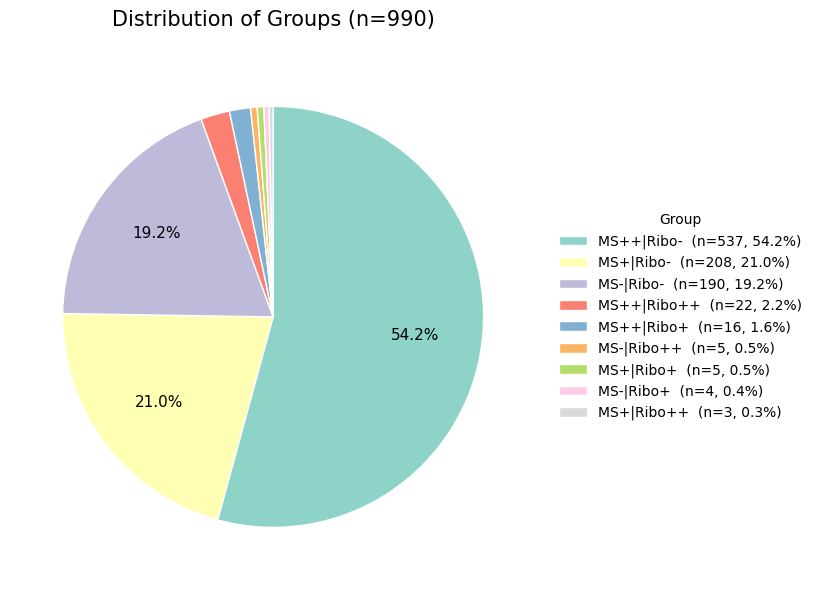

In [103]:
import matplotlib.pyplot as plt

group_counts = {
    "MS++|Ribo-": 537,
    "MS+|Ribo-": 208,
    "MS-|Ribo-": 190,
    "MS++|Ribo++": 22,
    "MS++|Ribo+": 16,
    "MS-|Ribo++": 5,
    "MS+|Ribo+": 5,
    "MS-|Ribo+": 4,
    "MS+|Ribo++": 3
}

labels = list(group_counts.keys())
values = list(group_counts.values())

# 只显示占比 ≥3% 的标签
def show_percentage(pct):
    return f"{pct:.1f}%" if pct >= 3 else ""

fig, ax = plt.subplots(figsize=(9, 6))

wedges, _, autotexts = ax.pie(
    values,
    autopct=show_percentage,
    pctdistance=0.68,
    startangle=90,
    counterclock=False,
    colors=plt.cm.Set3.colors,
    wedgeprops={
        "edgecolor": "white",
        "linewidth": 1
    },
    textprops={
        "fontsize": 11
    }
)

ax.legend(
    wedges,
    [
        f"{label}  (n={value}, {value / sum(values) * 100:.1f}%)"
        for label, value in group_counts.items()
    ],
    title="Group",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=10
)

ax.set_title(
    f"Distribution of Groups (n={sum(values)})",
    fontsize=15,
    pad=20
)

plt.tight_layout()
plt.show()

In [12]:
### stage2 基于蛋白ESM2分支的消融实验###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/model_explanable/stage2_protein_ablation/stage2_dualcnn_stage1_aux_protein_ablation_v2.py \
  --stage2_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2 \
  --stage2_dataset_prefix translation_strict_lenmatched_rnafm_esm2 \
  --model_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/stage2_dualcnn_stage1_aux/cnn128_aux128_k357_do05_lr1e4 \
  --noleak_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise \
  --model_py_dir /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4 \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage2_dualcnn_stage1_aux_protein_ablation_ws5_stride1_test \
  --run_name_prefix stage2_dualcnn_stage1_aux \
  --start_run 0 \
  --n_runs 10 \
  --subset test \
  --label_filter all \
  --batch_size 32 \
  --num_workers 0 \
  --do_region \
  --do_position \
  --alignments nterm,cterm \
  --position_stride 1 \
  --window_size 5 \
  --max_protein_pos 150 \
  --min_coverage 0.8 \
  --plot_group pos \
  --esm_layout auto

device: cuda
subset: test
window_size: 5
position_stride: 1
alignments: ['nterm', 'cterm']
ESM layout: auto

Run 00
dataset: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2/translation_strict_lenmatched_rnafm_esm2_run00.pkl
split: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/fixed_stage2_splits/run00
stage1: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/stage1_noleak_models/stage1_noleak_rnafm_run00/stage1_noleak_rnafm_run00_best_model.pt
stage2: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/stage2_dualcnn_stage1_aux/cnn128_aux128_k357_do05_lr1e4/stage2_dualcnn_stage1_aux_run00/stage2_dualcnn_stage1_aux_run00_best_model.pt
sampl

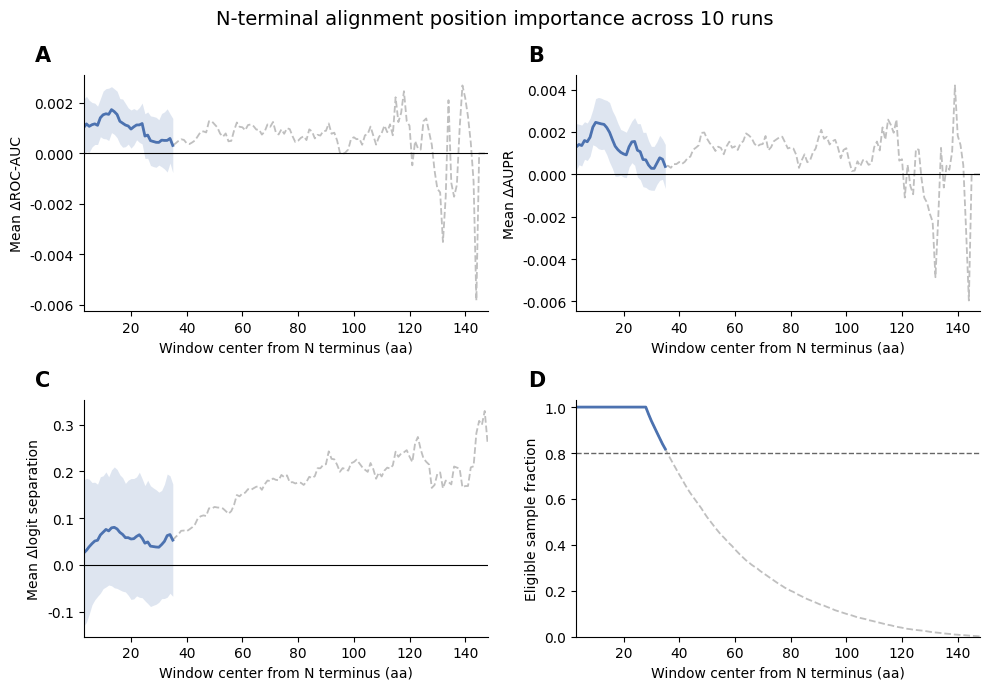

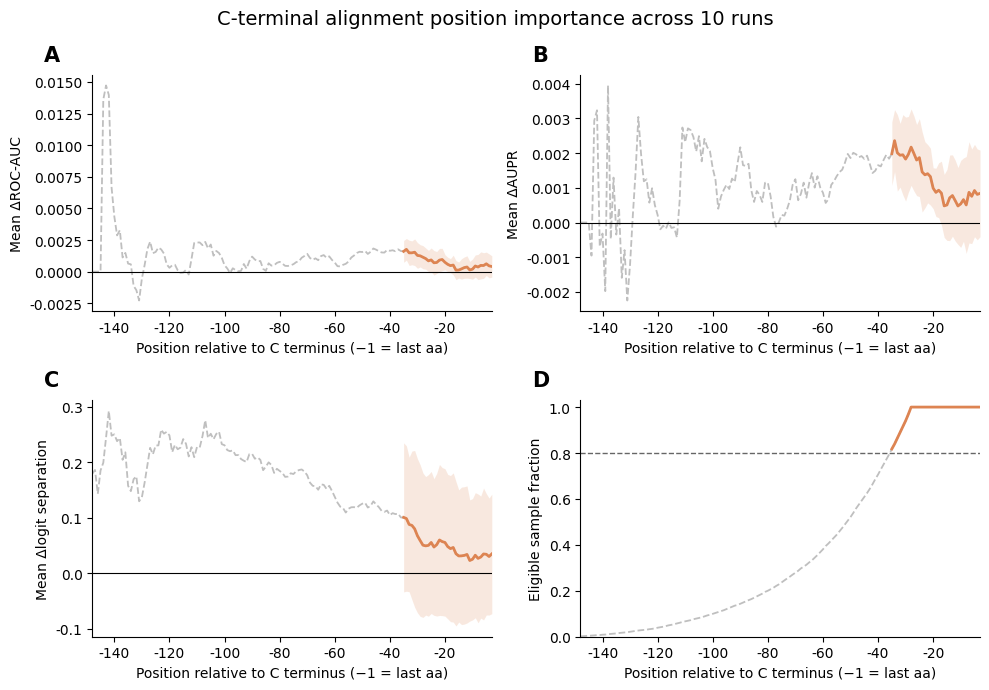

Alignment,Center,Window start,Window end,Coverage,ΔROC-AUC,ΔAUPR,Δlogit separation,Positive ΔAUC fraction,Positive ΔAUPR fraction
N-terminal alignment,13,11,15,1.0000,0.0017,0.0024,0.0793,0.9000,1.0000
N-terminal alignment,14,12,16,1.0000,0.0017,0.0022,0.0804,0.9000,0.9000
N-terminal alignment,11,9,13,1.0000,0.0016,0.0024,0.0759,0.8000,0.9000
N-terminal alignment,12,10,14,1.0000,0.0015,0.0024,0.0728,0.9000,0.9000
N-terminal alignment,15,13,17,1.0000,0.0015,0.0020,0.0770,0.9000,0.8000
N-terminal alignment,10,8,12,1.0000,0.0015,0.0025,0.0700,0.9000,0.9000
N-terminal alignment,9,7,11,1.0000,0.0014,0.0022,0.0641,0.9000,1.0000
N-terminal alignment,16,14,18,1.0000,0.0013,0.0016,0.0697,0.9000,0.8000
N-terminal alignment,17,15,19,1.0000,0.0012,0.0013,0.0652,0.9000,0.9000
N-terminal alignment,24,22,26,1.0000,0.0012,0.0016,0.0573,0.7000,0.8000


Region,Positive Δlogit,Negative Δlogit,Δlogit separation,ΔROC-AUC,ΔAUPR,Positive ΔAUC runs,Positive ΔAUPR runs
Whole protein branch,2.9154 ± 1.6045,1.6033 ± 1.1935,1.3121 ± 1.1156,0.0264 ± 0.0047,0.0256 ± 0.0033,10/10,10/10


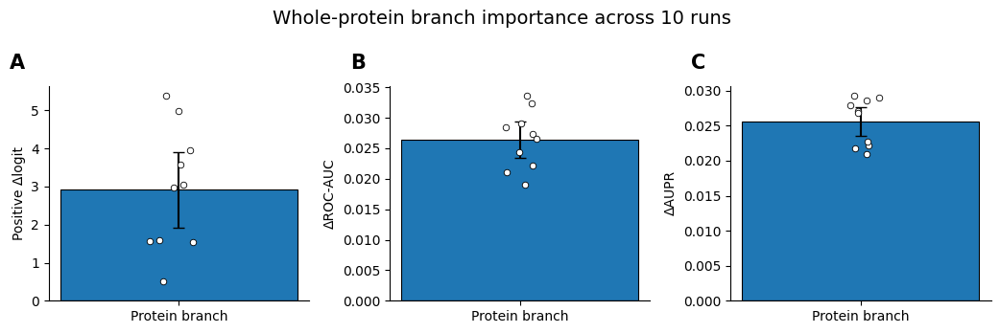

Saved to: /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage2_dualcnn_stage1_aux_protein_ablation_ws5_stride1_test/importance_metrics_v3


In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

base = "/disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage2_dualcnn_stage1_aux_protein_ablation_ws5_stride1_test"
out = os.path.join(base, "importance_metrics_v3")
os.makedirs(out, exist_ok=True)

mpl.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.unicode_minus": False
})

pos = pd.read_csv(os.path.join(base, "protein_position_ablation_by_run.csv"))
reg = pd.read_csv(os.path.join(base, "protein_region_ablation_by_run.csv"))

alignments = ["nterm", "cterm"]
names = {
    "nterm": "N-terminal alignment",
    "cterm": "C-terminal alignment"
}
xlabels = {
    "nterm": "Window center from N terminus (aa)",
    "cterm": "Position relative to C terminus (−1 = last aa)"
}
colors = {
    "nterm": "#4C72B0",
    "cterm": "#DD8452"
}
min_coverage = 0.8
top_tables = []

# =========================================================
# 1. N端和C端位置重要性图
# =========================================================
for alignment in alignments:
    d = pos[pos["alignment"] == alignment].copy()
    d["dsep"] = d["delta_logit_mean_pos"] - d["delta_logit_mean_neg"]

    g = d.groupby(
        ["center_pos", "window_start", "window_end"],
        as_index=False
    ).agg(
        coverage=("coverage_rate", "mean"),
        dauc=("drop_roc_auc", "mean"),
        dauc_sd=("drop_roc_auc", "std"),
        dap=("drop_average_precision", "mean"),
        dap_sd=("drop_average_precision", "std"),
        dsep=("dsep", "mean"),
        dsep_sd=("dsep", "std"),
        auc_consistency=("drop_roc_auc", lambda x: (x > 0).mean()),
        ap_consistency=("drop_average_precision", lambda x: (x > 0).mean()),
        nrun=("run", "nunique")
    ).sort_values("center_pos")

    for metric in ["dauc", "dap", "dsep"]:
        g[f"{metric}_ci"] = (
            1.96 * g[f"{metric}_sd"].fillna(0)
            / np.sqrt(g["nrun"].clip(lower=1))
        )

    good = g["coverage"] >= min_coverage
    x = g["center_pos"].to_numpy()

    fig, axes = plt.subplots(2, 2, figsize=(10, 7))
    axes = axes.ravel()

    plots = [
        ("dauc", "dauc_ci", "Mean ΔROC-AUC", "A"),
        ("dap", "dap_ci", "Mean ΔAUPR", "B"),
        ("dsep", "dsep_ci", "Mean Δlogit separation", "C"),
        ("coverage", None, "Eligible sample fraction", "D")
    ]

    for ax, (metric, ci_col, ylabel, panel) in zip(axes, plots):
        y = g[metric].to_numpy()

        # 所有位置先以灰色显示
        ax.plot(x, y, color="0.75", ls="--", lw=1.3)

        # 覆盖率合格的位置用颜色突出
        ax.plot(
            x,
            np.where(good, y, np.nan),
            color=colors[alignment],
            lw=2
        )

        if ci_col is not None:
            ci = g[ci_col].to_numpy()
            ax.fill_between(
                x,
                np.where(good, y - ci, np.nan),
                np.where(good, y + ci, np.nan),
                color=colors[alignment],
                alpha=0.18,
                linewidth=0
            )
            ax.axhline(0, color="black", lw=0.8)
        else:
            ax.axhline(
                min_coverage,
                color="0.4",
                ls="--",
                lw=1
            )
            ax.set_ylim(0, 1.03)

        ax.set_xlim(x.min(), x.max())
        ax.set_xlabel(xlabels[alignment])
        ax.set_ylabel(ylabel)
        ax.text(
            -0.12, 1.06, panel,
            transform=ax.transAxes,
            fontsize=15,
            fontweight="bold"
        )

    fig.suptitle(
        f"{names[alignment]} position importance across 10 runs",
        fontsize=14
    )
    fig.tight_layout()

    for ext in ["pdf", "png"]:
        fig.savefig(
            os.path.join(out, f"Fig_{alignment}_ABCD.{ext}"),
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()
    plt.close(fig)

    # 每种对齐方式按ΔROC-AUC选择前10个窗口
    top = g[good].nlargest(10, "dauc").copy()
    top.insert(0, "alignment", names[alignment])
    top_tables.append(top)

# =========================================================
# 2. 输出高重要性蛋白位置表
# =========================================================
top_positions = pd.concat(top_tables, ignore_index=True)

top_show = top_positions[[
    "alignment", "center_pos", "window_start", "window_end",
    "coverage", "dauc", "dap", "dsep",
    "auc_consistency", "ap_consistency"
]].copy()

for col in ["coverage", "dauc", "dap", "dsep",
            "auc_consistency", "ap_consistency"]:
    top_show[col] = top_show[col].map(lambda x: f"{x:.4f}")

top_show.columns = [
    "Alignment",
    "Center",
    "Window start",
    "Window end",
    "Coverage",
    "ΔROC-AUC",
    "ΔAUPR",
    "Δlogit separation",
    "Positive ΔAUC fraction",
    "Positive ΔAUPR fraction"
]

display(
    top_show.style
    .hide(axis="index")
    .set_properties(**{"text-align": "center"})
    .set_table_styles([{
        "selector": "th",
        "props": [
            ("font-weight", "bold"),
            ("text-align", "center")
        ]
    }])
)

top_show.to_csv(
    os.path.join(out, "top_position_importance_summary.csv"),
    index=False
)

# =========================================================
# 3. 整个蛋白分支的汇总表
# =========================================================
reg["dsep"] = (
    reg["delta_logit_mean_pos"]
    - reg["delta_logit_mean_neg"]
)

def mean_sd(x):
    return f"{x.mean():.4f} ± {x.std(ddof=1):.4f}"

summary_show = pd.DataFrame([{
    "Region": "Whole protein branch",
    "Positive Δlogit": mean_sd(reg["delta_logit_mean_pos"]),
    "Negative Δlogit": mean_sd(reg["delta_logit_mean_neg"]),
    "Δlogit separation": mean_sd(reg["dsep"]),
    "ΔROC-AUC": mean_sd(reg["drop_roc_auc"]),
    "ΔAUPR": mean_sd(reg["drop_average_precision"]),
    "Positive ΔAUC runs": (
        f'{(reg["drop_roc_auc"] > 0).sum()}/{len(reg)}'
    ),
    "Positive ΔAUPR runs": (
        f'{(reg["drop_average_precision"] > 0).sum()}/{len(reg)}'
    )
}])

display(
    summary_show.style
    .hide(axis="index")
    .set_properties(**{"text-align": "center"})
    .set_table_styles([{
        "selector": "th",
        "props": [
            ("font-weight", "bold"),
            ("text-align", "center")
        ]
    }])
)

summary_show.to_csv(
    os.path.join(out, "whole_protein_importance_summary.csv"),
    index=False
)

# =========================================================
# 4. 整个蛋白分支的重要性图
# =========================================================
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.5))

plot_metrics = [
    ("delta_logit_mean_pos", "Positive Δlogit", "A"),
    ("drop_roc_auc", "ΔROC-AUC", "B"),
    ("drop_average_precision", "ΔAUPR", "C")
]

rng = np.random.default_rng(42)

for ax, (metric, ylabel, panel) in zip(axes, plot_metrics):
    values = reg[metric].dropna().to_numpy()
    mean = values.mean()
    ci95 = 1.96 * values.std(ddof=1) / np.sqrt(len(values))

    ax.bar(
        [0], [mean],
        yerr=[ci95],
        width=0.55,
        capsize=4,
        edgecolor="black",
        linewidth=0.8
    )

    # 显示10个run的实际结果
    jitter = rng.normal(0, 0.035, len(values))
    ax.scatter(
        jitter,
        values,
        s=22,
        facecolor="white",
        edgecolor="black",
        linewidth=0.6,
        zorder=3
    )

    ax.axhline(0, color="black", lw=0.8)
    ax.set_xticks([0])
    ax.set_xticklabels(["Protein branch"])
    ax.set_ylabel(ylabel)
    ax.text(
        -0.15, 1.08, panel,
        transform=ax.transAxes,
        fontsize=15,
        fontweight="bold"
    )

fig.suptitle(
    "Whole-protein branch importance across 10 runs",
    fontsize=14
)
fig.tight_layout()

for ext in ["pdf", "png"]:
    fig.savefig(
        os.path.join(out, f"Fig_whole_protein_importance.{ext}"),
        dpi=300,
        bbox_inches="tight"
    )

plt.show()
plt.close(fig)

print("Saved to:", out)

In [16]:
###用新版脚本，区分N端和C端的相对位置###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/model_explanable/stage2_protein_ablation/stage2_dualcnn_stage1_aux_protein_ablation_relative_v3.py \
  --stage2_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2 \
  --stage2_dataset_prefix translation_strict_lenmatched_rnafm_esm2 \
  --model_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/stage2_dualcnn_stage1_aux/cnn128_aux128_k357_do05_lr1e4 \
  --noleak_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise \
  --model_py_dir /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4 \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage2_dualcnn_stage1_aux_protein_ablation_relative_ws5_test_v3 \
  --run_name_prefix stage2_dualcnn_stage1_aux \
  --start_run 0 \
  --n_runs 10 \
  --subset test \
  --label_filter all \
  --batch_size 32 \
  --num_workers 0 \
  --do_whole \
  --do_half \
  --do_relative \
  --window_size 5 \
  --relative_start 0.05 \
  --relative_end 0.95 \
  --relative_step 0.025 \
  --min_coverage 0.8 \
  --plot_group pos \
  --esm_layout auto

device: cuda
subset: test
window_size: 5
relative positions (%): [5.0, 7.5, 10.0, 12.5, 15.0, 17.5, 20.0, 22.5, 25.0, 27.5, 30.0, 32.5, 35.0, 37.5, 40.0, 42.5, 45.0, 47.5, 50.0, 52.5, 55.0, 57.5, 60.0, 62.5, 65.0, 67.5, 70.0, 72.5, 75.0, 77.5, 80.0, 82.5, 85.0, 87.5, 90.0, 92.5, 95.0]
ESM layout: auto

Run 00
dataset: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2/translation_strict_lenmatched_rnafm_esm2_run00.pkl
split: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/fixed_stage2_splits/run00
stage1: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/stage1_noleak_models/stage1_noleak_rnafm_run00/stage1_noleak_rnafm_run00_best_model.pt
stage2: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training

In [17]:
###用新版脚本，区分N端和C端的相对位置###
#有点bug，稍作修正#
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/model_explanable/stage2_protein_ablation/stage2_dualcnn_stage1_aux_protein_ablation_relative_v4.py \
  --stage2_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2 \
  --stage2_dataset_prefix translation_strict_lenmatched_rnafm_esm2 \
  --model_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/stage2_dualcnn_stage1_aux/cnn128_aux128_k357_do05_lr1e4 \
  --noleak_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise \
  --model_py_dir /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4 \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage2_dualcnn_stage1_aux_protein_ablation_relative_ws5_test_v4 \
  --run_name_prefix stage2_dualcnn_stage1_aux \
  --start_run 0 \
  --n_runs 10 \
  --subset test \
  --label_filter all \
  --batch_size 32 \
  --num_workers 0 \
  --do_whole \
  --do_half \
  --do_relative \
  --window_size 5 \
  --relative_start 0.05 \
  --relative_end 0.95 \
  --relative_step 0.025 \
  --min_coverage 0.8 \
  --plot_group pos \
  --esm_layout auto

device: cuda
subset: test
window_size: 5
relative positions (%): [5.0, 7.5, 10.0, 12.5, 15.0, 17.5, 20.0, 22.5, 25.0, 27.5, 30.0, 32.5, 35.0, 37.5, 40.0, 42.5, 45.0, 47.5, 50.0, 52.5, 55.0, 57.5, 60.0, 62.5, 65.0, 67.5, 70.0, 72.5, 75.0, 77.5, 80.0, 82.5, 85.0, 87.5, 90.0, 92.5, 95.0]
ESM layout: auto

Run 00
dataset: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2/translation_strict_lenmatched_rnafm_esm2_run00.pkl
split: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/fixed_stage2_splits/run00
stage1: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/stage1_noleak_models/stage1_noleak_rnafm_run00/stage1_noleak_rnafm_run00_best_model.pt
stage2: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training

In [ ]:
### Stage2 protein half ablation
### N-terminal half / C-terminal half absolute position scan
### Stage1-style coverage correction
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/model_explanable/stage2_protein_ablation/stage2_dualcnn_stage1_aux_protein_half_ablation_v5.py \
  --stage2_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2 \
  --stage2_dataset_prefix translation_strict_lenmatched_rnafm_esm2 \
  --model_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/stage2_dualcnn_stage1_aux/cnn128_aux128_k357_do05_lr1e4 \
  --noleak_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise \
  --model_py_dir /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4 \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage2_dualcnn_stage1_aux_protein_ws5_test_v5 \
  --run_name_prefix stage2_dualcnn_stage1_aux \
  --start_run 0 \
  --n_runs 10 \
  --subset test \
  --label_filter all \
  --batch_size 32 \
  --num_workers 0 \
  --do_region \
  --do_position \
  --segments n_half,c_half \
  --position_stride 1 \
  --window_size 5 \
  --max_half_pos 75 \
  --min_coverage 0.8 \
  --plot_group pos \
  --esm_layout auto

device: cuda
subset: test
window_size: 5
position_stride: 1
segments: ['n_half', 'c_half']
split rule: N half = 1..ceil(L/2); C half = ceil(L/2)+1..L
alignment: n_half starts at N terminus; c_half starts at C terminus
ESM layout: auto

Run 00
dataset: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2/translation_strict_lenmatched_rnafm_esm2_run00.pkl
split: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/fixed_stage2_splits/run00
stage1: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/stage1_noleak_models/stage1_noleak_rnafm_run00/stage1_noleak_rnafm_run00_best_model.pt
stage2: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/stage2_dualc

In [ ]:
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/model_explanable/stage2_protein_ablation/plot_stage2_protein_half_ablation_v5.py \
  --base /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage2_dualcnn_stage1_aux_protein_ws5_test_v5 \
  --min_coverage 0.8 \
  --top_n 10 \
  --pvalue_test wilcoxon \
  --pvalue_adjust none

Saved to: /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage2_dualcnn_stage1_aux_protein_ws5_test_v5/importance_metrics_terminal_aligned_v4


In [37]:
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/model_explanable/stage2_protein_ablation/plot_stage2_protein_half_ablation_v5.py \
  --base /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage2_dualcnn_stage1_aux_protein_ws5_test_v5 \
  --min_coverage 0.8 \
  --top_n 10 \
  --pvalue_test ttest \
  --pvalue_adjust none

Saved to: /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage2_dualcnn_stage1_aux_protein_ws5_test_v5/importance_metrics_terminal_aligned_v4


In [33]:
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/model_explanable/stage2_protein_ablation/stage2_analyze_nterm_8_17_pos_neg.py \
  --stage2_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2 \
  --stage2_dataset_prefix translation_strict_lenmatched_rnafm_esm2 \
  --noleak_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage2_dualcnn_stage1_aux_protein_ws5_test_v5/stage2_analyze_nterm_8_17_pos_neg_10runs \
  --start_run 0 \
  --n_runs 10 \
  --subset test \
  --seq_col protein_seq \
  --label_col binary_label \
  --id_col sample_id \
  --pos_label 1 \
  --neg_label 0 \
  --dedup sequence \
  --bootstrap 500 \
  --fig_format both


run00
Dataset after filtering/deduplication:
{
  "input_rows": 8227,
  "invalid_sequence_rows_removed": 0,
  "short_rows_removed": 0,
  "conflicting_dedup_keys_removed": 0,
  "deduplication": "sequence",
  "final_rows": 8227,
  "positive_rows": 4114,
  "negative_rows": 4113,
  "min_length": 30,
  "median_length": 53.0,
  "max_length": 150,
  "run": 0,
  "dataset_file": "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2/translation_strict_lenmatched_rnafm_esm2_run00.pkl",
  "subset": "test",
  "split_source": "IDs from /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/fixed_stage2_splits/run00/train_ids.csv (matched 8227)"
}
/disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/model_explanable/stage2_protein_ablation/stage2_analyze_nterm_8_17_pos_neg.py:711: UserWarning: s

In [34]:
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/model_explanable/stage2_protein_ablation/stage2_analyze_nterm_v2_pos_neg.py \
  --stage2_dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2 \
  --stage2_dataset_prefix translation_strict_lenmatched_rnafm_esm2 \
  --noleak_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/model_interpretation/stage2_dualcnn_stage1_aux_protein_ws5_test_v5/stage2_analyze_nterm_1_75_pos_neg_10runs \
  --start_run 0 \
  --n_runs 10 \
  --subset test \
  --seq_col protein_seq \
  --label_col binary_label \
  --id_col sample_id \
  --pos_label 1 \
  --neg_label 0 \
  --dedup sequence \
  --bootstrap 500 \
  --fig_format both \
  --focus_start 1 \
  --focus_end 75 \
  --profile_end 75
  


run00
Dataset after filtering/deduplication:
{
  "input_rows": 8227,
  "invalid_sequence_rows_removed": 0,
  "short_rows_removed": 0,
  "conflicting_dedup_keys_removed": 0,
  "deduplication": "sequence",
  "final_rows": 8227,
  "positive_rows": 4114,
  "negative_rows": 4113,
  "min_length": 30,
  "median_length": 53.0,
  "max_length": 150,
  "run": 0,
  "dataset_file": "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2/translation_strict_lenmatched_rnafm_esm2_run00.pkl",
  "subset": "test",
  "split_source": "IDs from /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/fixed_stage2_splits/run00/train_ids.csv (matched 8227)"
}
/disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/model_explanable/stage2_protein_ablation/stage2_analyze_nterm_v2_pos_neg.py:752: UserWarning: sta

In [5]:
##测试gencode##
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_external_gencode_prediction_scripts/prepare_external_rnafm_eval_table.py \
  --input_table /disk3/hejp/00_thesis/4_predict_translation/data/processed/dataset_nt450_v3/test_table_gencode.pkl \
  --rnafm_token_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_rnafm_token_test_gencode \
  --out_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_external/gencode_rnafm_eval.pkl \
  --out_csv /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_external/gencode_rnafm_eval.csv.gz \
  --id_col sample_id \
  --label_col label_raw

Input rows: 6178
RNA-FM files ok: 6178 / 6178

label_raw counts:
label_raw
gencode    6178

Length summary:
       orf_len_from_seq  up_len_from_seq  down_len_from_seq  orf_nt_len  protein_len_aa
count          6178.000         6178.000           6178.000    6178.000        6178.000
mean             59.010          216.586            436.042      59.010          18.670
std              56.322          159.902             62.595      56.322          18.774
min               6.000            1.000              1.000       6.000           1.000
25%              21.000           73.000            450.000      21.000           6.000
50%              39.000          175.000            450.000      39.000          12.000
75%              78.000          389.000            450.000      78.000          25.000
max             435.000          450.000            450.000     435.000         144.000

saved: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_

In [ ]:
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_external_gencode_prediction_scripts/predict_external_rnafm_self_attention.py \
  --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_external/gencode_rnafm_eval.pkl \
  --model_py_dir /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3 \
  --model_glob "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_5runs/rnafm_self_attention_strict_run*/rnafm_self_attention_strict_run*_best_model.pt" \
  --out_csv /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_external/gencode_translation_score_ensemble.csv.gz \
  --batch_size 32 \
  --num_heads 16 \
  --num_layers 2 \
  --dropout 0.5

Checkpoints:
  /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_5runs/rnafm_self_attention_strict_run00/rnafm_self_attention_strict_run00_best_model.pt
  /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_5runs/rnafm_self_attention_strict_run01/rnafm_self_attention_strict_run01_best_model.pt
  /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_5runs/rnafm_self_attention_strict_run02/rnafm_self_attention_strict_run02_best_model.pt
  /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_5runs/rnafm_self_attention_strict_run03/rnafm_self_attention_strict_run03_best_model.pt
  /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_5runs/rnafm_self_attention_strict_run04/rnafm_self_attention_stri

In [9]:
import pandas as pd
test=pd.read_csv('/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_external/gencode_translation_score_ensemble.csv.gz')
display(test.head(n=10))
print(test['pred_label'].value_counts())


,sample_id,protein_accession,transcript_accession,protein_len_aa,orf_seq,upstream_seq_50nt,downstream_seq_50nt,orf_nt_len,label_raw,protein_len_a,...,down_len_from_seq,prob_model_00,prob_model_01,prob_model_02,prob_model_03,prob_model_04,translation_score,translation_score_std,pred_label,score_rank_desc
0,c8riboseqorf359,ASAH1,ENST00000636691,7,ATGCGTAACGTCCGAGCCTCTTGA,ACAGGGCTACGGACTTCCTAACTGCAAGAGACAGTGAGGGACGAGC...,CGCCCAGTACTCTTTCATAATTCATTTCTTTATAAAGCAATCAGAC...,24,gencode,7,...,450,0.989022,0.990237,0.979095,0.984924,0.985871,0.985830,0.004353,1,1
1,c9riboseqorf16,UBAP1,ENST00000297661,28,ATGGCGGCTGCGGCACTGGCGGTGGCTACGGTGACGGCCTGGCCCG...,GGGAAGTAGGACTTCAAC,GGGCTGTCGGGAGCTCAGCGGGGACCGAGCCTGGGAGGCCGGCCGG...,87,gencode,28,...,450,0.989756,0.990231,0.979879,0.985247,0.983683,0.985759,0.004334,1,2
2,c12riboseqorf233,DIP2B,ENST00000301180,20,ATGGCGGCGGCGGCGGCGGCGGCGGTGCTGGTGGTGCTCGGCGGCC...,ACGTGACCTTTGCTC,CCGGGTGTGGGCCCGTGTCTGTCCGTCCCTCCTTCGGCCCCCTCTC...,63,gencode,20,...,450,0.990213,0.990297,0.979404,0.984292,0.984481,0.985737,0.004599,1,3
3,c8riboseqorf703,PDE7A,ENST00000379419,6,ATGCAGCGGGCTTTTGATTGA,GGAAGGCAGCTGCTTGAGGTCCAAGGCAGTCAGTGTCCCCTCTCTT...,TCCAATGGGAATTACATTGATCTGGTGTCTGGCCTTGGTTCTTATC...,21,gencode,6,...,450,0.989331,0.990241,0.979289,0.984435,0.985041,0.985667,0.004386,1,4
4,c20riboseqorf453,TTI1,ENST00000373448,4,ATGTTTCCTCAATGA,GCGTCACTTCCGGCGAGGCAGAGGAGGCGGGAGAGTGAGAGAAAGG...,GGGGAAGGCTGCTGCACAATGGCAGTTTTTGATACTCCTGAGGAGG...,15,gencode,4,...,450,0.988620,0.990252,0.979133,0.984906,0.985379,0.985658,0.004275,1,5
5,c11riboseqorf364,EI24,ENST00000620753,31,ATGCCCAGTGCGGGCGCAGCGGCCCCGGCCCTGGAAGCGCCCCGAT...,GTGCGGCCCGGGC,TAGTTTGGTGGTGAAGAGATGGCTGACAGTGTCAAAACCTTTCTCC...,96,gencode,31,...,450,0.989409,0.990076,0.979081,0.984319,0.985398,0.985657,0.004436,1,6
6,c16riboseqorf579,IL4R,ENST00000395762,8,ATGGAGCAGGGGCGCGCAGATAATTAA,ACTTCCCGCTTGGGCGCCCGGACGGCGA,AGATTTACACACAGCTGGAAGAAATCATAGAGAAGCCGGGCGTGGT...,27,gencode,8,...,450,0.988999,0.990520,0.978723,0.985094,0.984844,0.985636,0.004579,1,7
7,c1riboseqorf181,S100A6,ENST00000368720,20,ATGAGGGGAGACTCGTCACCAGGCGTGCAGTGGGCACTGCTGGGCT...,GAGCTGCGCAG,CCCGGAACAGCCCCGGGCAGGAGGCGTGGAAAGTCGAGGGGGTAAA...,63,gencode,20,...,450,0.990139,0.990314,0.979084,0.983558,0.984966,0.985612,0.004739,1,8
8,c19riboseqorf198,REXO1,ENST00000170168,17,ATGGCGGCGGCGGGGTCCGTGAGGCGCGGGCGGCGGCGACCGCGGC...,GGGGGCCTCGGAGCAAG,GGGGGCCCTGGGGCCCGGGCGGCTCCGGGCCGGGGCCCCGCCGCGG...,54,gencode,17,...,450,0.989731,0.990317,0.979306,0.983667,0.984939,0.985592,0.004558,1,9
9,c7riboseqorf610,GARS1-DT,ENST00000426529,5,ATGCACAGGGAGATATGA,CCCGCCGAAGGTTTTCTCCGGTTCGGGAGAGAGACGGAGTCCCGCT...,GACATCAATCAATATATGTAAGATGTACATCAGTTTCGTCTGGAAA...,18,gencode,5,...,450,0.988836,0.990269,0.978185,0.984879,0.985699,0.985574,0.004685,1,10


pred_label
1    5175
0    1003
Name: count, dtype: int64


In [7]:
##测试gencode 第二次，有阴性数据加进去##
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_external_gencode_prediction_scripts/prepare_external_rnafm_eval_table.py \
  --input_table /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/gencode_pos_ribotricer_neg1w_merged.csv.gz \
  --rnafm_token_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_rnafm_token_test_gencode_ribo1w \
  --out_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/selfattention/gencode_ribo1w_rnafm_eval.pkl \
  --out_csv /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/selfattention/gencode_ribo1w_rnafm_eval.csv.gz \
  --id_col sample_id \
  --label_col label_raw

Input rows: 16178
RNA-FM files ok: 16178 / 16178

label_raw counts:
label_raw
ribotricer    10000
gencode        6178

Length summary:
       orf_len_from_seq  up_len_from_seq  down_len_from_seq  orf_nt_len  protein_len_aa
count         16178.000        16178.000          16178.000   16178.000       16178.000
mean            146.904          336.963            358.030     146.904          47.968
std             118.918          153.288            146.897     118.918          39.639
min               6.000            0.000              0.000       6.000           1.000
25%              60.000          205.000            269.000      60.000          19.000
50%             114.000          450.000            450.000     114.000          37.000
75%             183.000          450.000            450.000     183.000          60.000
max             453.000          450.000            450.000     453.000         150.000

saved: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_re

In [8]:
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_external_gencode_prediction_scripts/predict_external_rnafm_self_attention.py \
  --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/selfattention/gencode_ribo1w_rnafm_eval.csv.gz \
  --model_py_dir /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_10run_strict_v4 \
  --model_glob "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/afteroptimize/ffmult2_wd5e4_10runs/rnafm_self_attention_strict_run*/rnafm_self_attention_strict_run*_best_model.pt" \
  --out_csv /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/selfattention/gencode_translation_score_ensemble.csv.gz \
  --batch_size 64 \
  --num_heads 8 \
  --num_layers 2 \
  --dropout 0.2 \
  --ff_mult 2



Checkpoints:
  /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/afteroptimize/ffmult2_wd5e4_10runs/rnafm_self_attention_strict_run00/rnafm_self_attention_strict_run00_best_model.pt
  /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/afteroptimize/ffmult2_wd5e4_10runs/rnafm_self_attention_strict_run01/rnafm_self_attention_strict_run01_best_model.pt
  /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/afteroptimize/ffmult2_wd5e4_10runs/rnafm_self_attention_strict_run02/rnafm_self_attention_strict_run02_best_model.pt
  /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_self_attention_strict_10runs/afteroptimize/ffmult2_wd5e4_10runs/rnafm_self_attention_strict_run03/rnafm_self_attention_strict_run03_best_model.pt
  /disk4hu/hejp/00_thesis/4_predict

In [9]:
import pandas as pd
test=pd.read_csv('/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/selfattention/gencode_translation_score_ensemble.csv.gz')
display(test.head(n=10))
print(test['pred_label'].value_counts())

,sample_id,protein_accession,transcript_accession,protein_len_aa,orf_seq,upstream_seq_50nt,downstream_seq_50nt,orf_nt_len,label_raw,protein_len_a,...,prob_model_04,prob_model_05,prob_model_06,prob_model_07,prob_model_08,prob_model_09,translation_score,translation_score_std,pred_label,score_rank_desc
0,c1riboseqorf20,CENPS,ENST00000477755,64,ATGAATCCTCGGTTTCCCCTTCTCAGATGGGGTTTTCGTGAGGGTA...,GAAGCGGTTCTAGGGGAGCGTGCGGGCGCCGGGGTCCGGCGGCGAG...,ATGTGGGTTCGAATCTCTGCCCCGCCAACTTGTGATCGTATCGACT...,195,gencode,64,...,0.994694,0.988931,0.987669,0.996577,0.997146,0.997430,0.993076,0.005214,1,1
1,c15riboseqorf485,MAPK6,ENST00000558100,43,ATGGCGGCGACTGCGGCAAAGCGAGAGCCTCGGAGACGCCGCTGCC...,GGGTCGGGGTTAC,CTTTACAGTGTACATTTATCAGAAATGTAAAACATGACTGAGCTTT...,132,gencode,43,...,0.995719,0.986640,0.989059,0.996677,0.996175,0.997176,0.992432,0.005433,1,2
2,c11riboseqorf42,FJX1,ENST00000317811,28,ATGGGGCCGAAGCGCCCGAAGCCCCGGAGCCCACAAACTGCCGGGC...,AGTTCCCAGCGCCGGGCGGAGCGCCGGACAGAGCCCCGCAGCGCCC...,AGCGGCGGCGGCGCACCGGCACAGCCGCGGGAGCATGGGCAGGAGG...,87,gencode,28,...,0.992579,0.983312,0.989276,0.995574,0.997207,0.996647,0.991859,0.005658,1,3
3,c10riboseqorf90,OLMALINC,ENST00000654233,44,ATGGGGAAAATGCGGACATGCCACTCAGTCCGGCCGCGAACAGTGC...,GGTCCTTCCAGCCTCTTGCTCCTGTGAATCACAGGTCGGCGGGAGC...,GGCGCTTTAGCCGTCTCCACGGCCAGCCCCTCCCTCATAACCCGAG...,135,gencode,44,...,0.981647,0.988460,0.991230,0.996024,0.997030,0.995408,0.991809,0.005927,1,4
4,c12riboseqorf108,BTG1,ENST00000256015,23,ATGCAGCTATTGAGATCTTCGAATGCTGCGGAGCTGGAGGCGGAGG...,CGCCTCTCGGAGCTGGAA,CCAGGCCGCCATCGCTCGTCTCTTCCTCTCTCCTGCCGCCTCCTGT...,72,gencode,23,...,0.992032,0.982451,0.991604,0.997248,0.997379,0.994901,0.991719,0.006434,1,5
5,cXriboseqorf165,ENSG00000287024,ENST00000668487,41,ATGTCTTCTTCCTGGGAAGACGGCCGCTGTCTGCGGCAGTGGGTGG...,GGGCCCGGCTGGCACTGCCCTGCGCCGCCGCCCGTCAGTCCCGGTA...,GCAGCTTAAAAAATGTCGCCTGTGAGGTCTCAGCTCGTACAACAAG...,126,gencode,41,...,0.986955,0.989011,0.988532,0.995619,0.996735,0.997268,0.991671,0.004766,1,6
6,c1riboseqorf599,RASSF5,ENST00000577571,26,ATGGCGCTCTGCACGGCGGCGGAGGGAGGGCGCTGGCGCCGGGGAC...,GAACTGCTTTACGCGAGGGGCAGGAAAGGCGCGGGAGGCGGGGGAG...,GGCGCGAGCCGGGCGCCCGGGGCTCTGCAGGCGCAGGCGGCGCGGG...,81,gencode,26,...,0.993483,0.985924,0.985004,0.996699,0.996979,0.996786,0.991518,0.006210,1,7
7,c2riboseqorf160,EEF1B2,ENST00000460760,41,ATGCCTATTTTATTAATTTACTTCCAAACGCAACGAAAGGTCCATG...,TCCGGCGCTTCTAGGGCTGGTTCCCGTCATCTTCGGGAGCCGTGGA...,CCTTCGGTCCGGCGCGGTGGAGGGAAACGCCTCCGTCTCTATATAA...,126,gencode,41,...,0.991283,0.982756,0.991249,0.997631,0.996884,0.995143,0.991277,0.006992,1,8
8,c20riboseqorf51,NCOA3,ENST00000371998,17,ATGGCGGCGGGAGGATCAAAATACTTGCTGGATGGTGGACTCAGAG...,AGCTGCTGCTGTCTCAGCCGCTCCACAGCGACGGCAGCGGCTGCGG...,AAATAAACTGCTTGAACATCCTTTGACTGGTTAGCCAGTTGCTGAT...,54,gencode,17,...,0.990595,0.984614,0.988633,0.996172,0.996169,0.995943,0.991272,0.006193,1,9
9,c3riboseqorf1048,DCBLD2,ENST00000326840,15,ATGCAGGCAGACTGCCGGCCGCCGCGATGGCGAGCCGGGCGGTGGTGA,GGGCCTGCCTGCCAGCTAGCCGGAGCCGCGGGTGAGCGCGGCGAGC...,GAGCCAGGCGCTGCCCGCAGTGTCCCCAAGTCCGGGCCGCGGCCGC...,48,gencode,15,...,0.991852,0.985386,0.987724,0.994962,0.997411,0.996144,0.991247,0.006285,1,10


pred_label
0    10339
1     5839
Name: count, dtype: int64


In [16]:
###用RNA FM + ESM2 self attention and cross attention###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_ESM2_self_cross_attention_package/build_translation_lenmatched_rnafm_esm2_10runs.py \
  --metadata_csv /disk3/hejp/00_thesis/4_predict_translation/data/processed/dataset_nt450_v3/train_pos_neg_merged.csv.gz \
  --rnafm_token_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_rnafm_token_pos_neg \
  --esm2_token_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_esm2_token_pos_neg \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_esm2_cross_attention_strict_10runs \
  --prefix translation_strict_lenmatched_rnafm_esm2 \
  --match_mode strict_pair \
  --n_runs 10 \
  --seed 42


Before ORF filter
Shape: (87774, 15)

Binary label counts:
binary_label
0    76700
1    11074

label_raw counts:
label_raw
ribotricer     76700
MS-|Ribo+       2451
MS-|Ribo++      1912
MS++|Ribo+      1845
MS+|Ribo+       1787
MS++|Ribo++     1580
MS+|Ribo++      1499

Length summary by binary_label:
             orf_len                                  up_len                                   down_len                                  
               count     mean     std median min  max  count     mean      std median min  max    count     mean      std median min  max
binary_label                                                                                                                             
0              76700  185.701  99.324  150.0   0  453  76700  385.922  117.544  450.0   0  450    76700  347.458  151.995  450.0   0  450
1              11074  174.618  74.432  153.0  93  453  11074  258.235  170.111  256.0   0  450    11074  410.077  101.199  450.0   0  450

After

In [ ]:
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_ESM2_self_cross_attention_package/run_10runs_cross_attention.py \
  --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_ESM2_self_cross_attention_package/train_rnafm_esm2_cross_attention.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_esm2_cross_attention_strict_1runs \
  --dataset_prefix translation_strict_lenmatched_rnafm_esm2 \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_esm2_cross_attention_1runs \
  --run_name_prefix rnafm_esm2_cross_attention \
  --n_runs 1 \
  --batch_size 16 \
  --epochs 25 \
  --hidden_dim 256 \
  --num_heads 8 \
  --rna_num_layers 2 \
  --protein_num_layers 1 \
  --cross_layers 1 \
  --dropout 0.4


Running: rnafm_esm2_cross_attention_run00
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_ESM2_self_cross_attention_package/train_rnafm_esm2_cross_attention.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_esm2_cross_attention_strict_1runs/translation_strict_lenmatched_rnafm_esm2_run00.pkl --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_esm2_cross_attention_5runs/rnafm_esm2_cross_attention_run00 --run_name rnafm_esm2_cross_attention_run00 --seed 42 --epochs 25 --batch_size 16 --lr 0.0001 --weight_decay 0.0001 --patience 8 --num_workers 2 --dropout 0.4 --hidden_dim 256 --fusion_hidden_dim 256 --num_heads 8 --rna_num_layers 2 --protein_num_layers 1 --cross_layers 1 --ff_mult 4 --valid_size 0.15 --test_size 0.15 --grad_clip 1.0
2026-06-24 15:13:31,064 | INFO | args: {'dataset_pkl': '/dis

In [18]:
##随机测试5次 cross attention###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_ESM2_self_cross_attention_package/run_10runs_cross_attention.py \
  --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_ESM2_self_cross_attention_package/train_rnafm_esm2_cross_attention.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_esm2_cross_attention_strict_5runs \
  --dataset_prefix translation_strict_lenmatched_rnafm_esm2 \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_esm2_cross_attention_5runs \
  --run_name_prefix rnafm_esm2_cross_attention \
  --n_runs 5 \
  --batch_size 64 \
  --epochs 25 \
  --hidden_dim 256 \
  --num_heads 8 \
  --rna_num_layers 2 \
  --protein_num_layers 1 \
  --cross_layers 1 \
  --dropout 0.4


Running: rnafm_esm2_cross_attention_run00
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_ESM2_self_cross_attention_package/train_rnafm_esm2_cross_attention.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_esm2_cross_attention_strict_5runs/translation_strict_lenmatched_rnafm_esm2_run00.pkl --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_esm2_cross_attention_5runs/rnafm_esm2_cross_attention_run00 --run_name rnafm_esm2_cross_attention_run00 --seed 42 --epochs 25 --batch_size 64 --lr 0.0001 --weight_decay 0.0001 --patience 8 --num_workers 2 --dropout 0.4 --hidden_dim 256 --fusion_hidden_dim 256 --num_heads 8 --rna_num_layers 2 --protein_num_layers 1 --cross_layers 1 --ff_mult 4 --valid_size 0.15 --test_size 0.15 --grad_clip 1.0
2026-06-24 19:19:42,176 | INFO | args: {'dataset_pkl': '/dis

In [19]:
##随机测试10次 cross attention###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_ESM2_self_cross_attention_package/run_10runs_cross_attention.py \
  --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_ESM2_self_cross_attention_package/train_rnafm_esm2_cross_attention.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_esm2_cross_attention_strict_10runs \
  --dataset_prefix translation_strict_lenmatched_rnafm_esm2 \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_esm2_cross_attention_10runs \
  --run_name_prefix rnafm_esm2_cross_attention \
  --n_runs 10 \
  --batch_size 64 \
  --epochs 25 \
  --hidden_dim 256 \
  --num_heads 8 \
  --rna_num_layers 2 \
  --protein_num_layers 1 \
  --cross_layers 1 \
  --dropout 0.4


Running: rnafm_esm2_cross_attention_run00
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_ESM2_self_cross_attention_package/train_rnafm_esm2_cross_attention.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_esm2_cross_attention_strict_10runs/translation_strict_lenmatched_rnafm_esm2_run00.pkl --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_esm2_cross_attention_10runs/rnafm_esm2_cross_attention_run00 --run_name rnafm_esm2_cross_attention_run00 --seed 42 --epochs 25 --batch_size 64 --lr 0.0001 --weight_decay 0.0001 --patience 8 --num_workers 2 --dropout 0.4 --hidden_dim 256 --fusion_hidden_dim 256 --num_heads 8 --rna_num_layers 2 --protein_num_layers 1 --cross_layers 1 --ff_mult 4 --valid_size 0.15 --test_size 0.15 --grad_clip 1.0
2026-06-24 23:15:27,446 | INFO | args: {'dataset_pkl': '/d

In [21]:
##随机测试10次 cross attention dropout 0.2 head 4###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_ESM2_self_cross_attention_package/run_10runs_cross_attention.py \
  --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_ESM2_self_cross_attention_package/train_rnafm_esm2_cross_attention.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_esm2_cross_attention_strict_10runs \
  --dataset_prefix translation_strict_lenmatched_rnafm_esm2 \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_esm2_cross_attention_10runs_dropout2_head4 \
  --run_name_prefix rnafm_esm2_cross_attention \
  --n_runs 10 \
  --batch_size 128 \
  --epochs 25 \
  --hidden_dim 256 \
  --num_heads 4 \
  --rna_num_layers 2 \
  --protein_num_layers 1 \
  --cross_layers 1 \
  --dropout 0.2


Running: rnafm_esm2_cross_attention_run00
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_ESM2_self_cross_attention_package/train_rnafm_esm2_cross_attention.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_esm2_cross_attention_strict_10runs/translation_strict_lenmatched_rnafm_esm2_run00.pkl --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_esm2_cross_attention_10runs_dropout2_head4/rnafm_esm2_cross_attention_run00 --run_name rnafm_esm2_cross_attention_run00 --seed 42 --epochs 25 --batch_size 128 --lr 0.0001 --weight_decay 0.0001 --patience 8 --num_workers 2 --dropout 0.2 --hidden_dim 256 --fusion_hidden_dim 256 --num_heads 4 --rna_num_layers 2 --protein_num_layers 1 --cross_layers 1 --ff_mult 4 --valid_size 0.15 --test_size 0.15 --grad_clip 1.0
2026-06-26 00:58:49,372 | INFO | args: {'d

In [1]:
###run baseline 1: cnn###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_ESM2_self_cross_attention_package/run_10runs_cnn.py \
  --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_ESM2_self_cross_attention_package/train_rnafm_esm2_cnn.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_esm2_cross_attention_strict_10runs \
  --dataset_prefix translation_strict_lenmatched_rnafm_esm2 \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_esm2_cnn_10runs \
  --run_name_prefix rnafm_esm2_cnn \
  --n_runs 10 \
  --batch_size 512 \
  --epochs 30 \
  --hidden_dim 128 \
  --branch_out_dim 128 \
  --fusion_hidden_dim 256 \
  --kernel_sizes 3 \
  --dropout 0.2


Running: rnafm_esm2_cnn_run00
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_ESM2_self_cross_attention_package/train_rnafm_esm2_cnn.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_esm2_cross_attention_strict_10runs/translation_strict_lenmatched_rnafm_esm2_run00.pkl --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_esm2_cnn_10runs/rnafm_esm2_cnn_run00 --run_name rnafm_esm2_cnn_run00 --seed 42 --epochs 30 --batch_size 512 --eval_batch_size 0 --lr 0.0001 --weight_decay 0.0001 --patience 8 --num_workers 2 --dropout 0.2 --hidden_dim 128 --branch_out_dim 128 --fusion_hidden_dim 256 --kernel_sizes 3 --valid_size 0.15 --test_size 0.15 --grad_clip 1.0
2026-06-25 21:49:03,105 | INFO | args: {'dataset_pkl': '/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnaf

In [ ]:
###预测stability，能稳定存在的小蛋白###
#step 0.1 generate the matrix from stage 1#
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_ESM2_self_cross_attention_package/Stage1_cross_attention_score_preparation_package/build_stage1_score_eval_table.py \
  --metadata_csv /disk3/hejp/00_thesis/4_predict_translation/data/processed/dataset_nt450_v3/train_pos_neg_merged.csv.gz \
  --rnafm_token_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_rnafm_token_pos_neg \
  --esm2_token_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_esm2_token_pos_neg \
  --out_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage1_scores/stage1_eval_ribo_positive.pkl \
  --out_csv /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage1_scores/stage1_eval_ribo_positive.csv.gz \
  --esm2_patterns "{sample_id}.pt" \
  --esm2_subdirs ""

Keep Ribo-positive samples: (11074, 11)
ESM2 search dirs:
  /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_esm2_token_pos_neg
ESM2 patterns: ['{sample_id}.pt']
Token files ok: 11074 / 11074

label_raw counts:
label_raw
MS-|Ribo+      2451
MS-|Ribo++     1912
MS++|Ribo+     1845
MS+|Ribo+      1787
MS++|Ribo++    1580
MS+|Ribo++     1499

Saved: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage1_scores/stage1_eval_ribo_positive.pkl
Saved: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage1_scores/stage1_eval_ribo_positive.csv.gz


In [4]:
#step 0.2 generate the matrix from stage 1#
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_ESM2_self_cross_attention_package/Stage1_cross_attention_score_preparation_package/predict_stage1_cross_attention_scores.py \
  --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage1_scores/stage1_eval_ribo_positive.pkl \
  --model_py_dir /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_ESM2_self_cross_attention_package \
  --model_glob "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_esm2_cross_attention_10runs/rnafm_esm2_cross_attention_run*/rnafm_esm2_cross_attention_run*_best_model.pt" \
  --out_csv /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage1_scores/stage1_translation_scores_all.csv.gz \
  --batch_size 64 \
  --hidden_dim 256 \
  --num_heads 8 \
  --rna_num_layers 2 \
  --protein_num_layers 1 \
  --cross_layers 1 \
  --dropout 0.4


Found checkpoints:
  /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_esm2_cross_attention_10runs/rnafm_esm2_cross_attention_run00/rnafm_esm2_cross_attention_run00_best_model.pt
  /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_esm2_cross_attention_10runs/rnafm_esm2_cross_attention_run01/rnafm_esm2_cross_attention_run01_best_model.pt
  /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_esm2_cross_attention_10runs/rnafm_esm2_cross_attention_run02/rnafm_esm2_cross_attention_run02_best_model.pt
  /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_esm2_cross_attention_10runs/rnafm_esm2_cross_attention_run03/rnafm_esm2_cross_attention_run03_best_model.pt
  /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/rnafm_esm2_cross_attention_10runs/rnafm_esm2_cross_attention_run04/rnafm_esm2_cross_attention_r

In [5]:
#step 0.3 check the result#
import pandas as pd

score = pd.read_csv(
    "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage1_scores/stage1_translation_scores_all.csv.gz"
)

print(score.shape)
print(score[["sample_id", "label_raw", "translation_score", "translation_score_std"]].head())
print(score["translation_score"].describe())
print(score["label_raw"].value_counts())

(11074, 26)
        sample_id   label_raw  translation_score  translation_score_std
0  sample_0020000  MS-|Ribo++           0.945611               0.023471
1  sample_0020001  MS-|Ribo++           0.507288               0.296139
2  sample_0020002  MS-|Ribo++           0.593898               0.140676
3  sample_0020003   MS+|Ribo+           0.113447               0.163069
4  sample_0020004  MS++|Ribo+           0.466796               0.223481
count    11074.000000
mean         0.715579
std          0.278433
min          0.013590
25%          0.515410
50%          0.831367
75%          0.956115
max          0.978482
Name: translation_score, dtype: float64
label_raw
MS-|Ribo+      2451
MS-|Ribo++     1912
MS++|Ribo+     1845
MS+|Ribo+      1787
MS++|Ribo++    1580
MS+|Ribo++     1499
Name: count, dtype: int64


In [6]:

#step 1 generate the dataset#
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_ESM2_self_cross_attention_package/Stage2_ESM2_translation_score_matrix_package/build_stage2_ms_esm2_dataset_10runs.py \
  --metadata_csv /disk3/hejp/00_thesis/4_predict_translation/data/processed/dataset_nt450_v3/train_pos_neg_merged.csv.gz \
  --stage1_score_csv /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage1_scores/stage1_translation_scores_all.csv.gz \
  --esm2_token_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_esm2_token_pos_neg \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_ms_esm2_score_matrix_dataset \
  --prefix stage2_ms_esm2_score_matrix \
  --match_mode strict_pair \
  --protein_bin_size 10 \
  --n_runs 10 \
  --seed 42 \
  --esm2_patterns "{sample_id}.pt" \
  --esm2_subdirs ""

After label + score merge: (11074, 15)
ESM2 files ok: 11074 / 11074
Stage2 label counts before sampling:
binary_label
1    6711
0    4363
label_raw
MS-|Ribo+      2451
MS-|Ribo++     1912
MS++|Ribo+     1845
MS+|Ribo+      1787
MS++|Ribo++    1580
MS+|Ribo++     1499
             protein_len_for_bin                                   translation_score                                         translation_score_std                                        
                           count     mean      std median min  max             count    mean     std  median     min     max                 count    mean     std  median     min     max
binary_label                                                                                                                                                                              
0                           4363  51.8838  20.9494   45.0  30  147              4363  0.6936  0.2885  0.8049  0.0136  0.9785                  4363  0.1233  0.0973  0.1143 

In [9]:
#step 2 run the model#
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_ESM2_self_cross_attention_package/Stage2_ESM2_translation_score_matrix_package/run_10runs_stage2_esm2_score_matrix.py \
  --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_ESM2_self_cross_attention_package/Stage2_ESM2_translation_score_matrix_package/train_stage2_esm2_score_matrix.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_ms_esm2_score_matrix_dataset \
  --dataset_prefix stage2_ms_esm2_score_matrix \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_esm2_score_matrix_10runs \
  --run_name_prefix stage2_esm2_score_matrix \
  --n_runs 10 \
  --batch_size 256 \
  --epochs 25 \
  --hidden_dim 256 \
  --num_heads 8 \
  --num_layers 2 \
  --score_mode matrix \
  --dropout 0.1


Running: stage2_esm2_score_matrix_run00
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_ESM2_self_cross_attention_package/Stage2_ESM2_translation_score_matrix_package/train_stage2_esm2_score_matrix.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_ms_esm2_score_matrix_dataset/stage2_ms_esm2_score_matrix_run00.pkl --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_esm2_score_matrix_10runs/stage2_esm2_score_matrix_run00 --run_name stage2_esm2_score_matrix_run00 --seed 42 --epochs 25 --batch_size 256 --lr 0.0001 --weight_decay 0.0001 --patience 8 --num_workers 2 --dropout 0.1 --hidden_dim 256 --fusion_hidden_dim 256 --num_heads 8 --num_layers 2 --ff_mult 4 --score_mode matrix --valid_size 0.15 --test_size 0.15 --grad_clip 1.0
2026-06-25 23:41:04,204 | INFO | args: {'dataset_pkl': '/disk4hu

In [12]:
#step 2 run the model 换参数#
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_ESM2_self_cross_attention_package/Stage2_ESM2_translation_score_matrix_package/run_10runs_stage2_esm2_score_matrix.py \
  --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_ESM2_self_cross_attention_package/Stage2_ESM2_translation_score_matrix_package/train_stage2_esm2_score_matrix.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_ms_esm2_score_matrix_dataset \
  --dataset_prefix stage2_ms_esm2_score_matrix \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_esm2_score_matrix_10runs \
  --run_name_prefix stage2_esm2_score_matrix \
  --n_runs 10 \
  --batch_size 1024 \
  --epochs 100 \
  --lr 5e-5 \
  --weight_decay 1e-3 \
  --patience 10 \
  --hidden_dim 128 \
  --fusion_hidden_dim 128 \
  --num_heads 8 \
  --num_layers 1 \
  --score_mode matrix \
  --dropout 0.5


Running: stage2_esm2_score_matrix_run00
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_ESM2_self_cross_attention_package/Stage2_ESM2_translation_score_matrix_package/train_stage2_esm2_score_matrix.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_ms_esm2_score_matrix_dataset/stage2_ms_esm2_score_matrix_run00.pkl --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_esm2_score_matrix_10runs/stage2_esm2_score_matrix_run00 --run_name stage2_esm2_score_matrix_run00 --seed 42 --epochs 100 --batch_size 1024 --lr 5e-05 --weight_decay 0.001 --patience 10 --num_workers 2 --dropout 0.5 --hidden_dim 128 --fusion_hidden_dim 128 --num_heads 8 --num_layers 1 --ff_mult 4 --score_mode matrix --valid_size 0.15 --test_size 0.15 --grad_clip 1.0
2026-06-26 00:00:48,509 | INFO | args: {'dataset_pkl': '/disk4h

In [20]:
#step 2 run the model 换参数#
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_ESM2_self_cross_attention_package/Stage2_ESM2_translation_score_matrix_package/run_10runs_stage2_esm2_score_matrix.py \
  --train_script /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_ESM2_self_cross_attention_package/Stage2_ESM2_translation_score_matrix_package/train_stage2_esm2_score_matrix.py \
  --dataset_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_ms_esm2_score_matrix_dataset \
  --dataset_prefix stage2_ms_esm2_score_matrix \
  --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_esm2_score_matrix_1runs \
  --run_name_prefix stage2_esm2_score_matrix \
  --n_runs 1 \
  --batch_size 1024 \
  --epochs 80 \
  --lr 5e-5 \
  --weight_decay 5e-4 \
  --patience 20 \
  --hidden_dim 128 \
  --fusion_hidden_dim 128 \
  --num_heads 8 \
  --num_layers 1 \
  --score_mode none \
  --dropout 0.2


Running: stage2_esm2_score_matrix_run00
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_v3/src_rnafm_self_cross_attention_v3/rnafm_ESM2_self_cross_attention_package/Stage2_ESM2_translation_score_matrix_package/train_stage2_esm2_score_matrix.py --dataset_pkl /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_ms_esm2_score_matrix_dataset/stage2_ms_esm2_score_matrix_run00.pkl --out_dir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_esm2_score_matrix_1runs/stage2_esm2_score_matrix_run00 --run_name stage2_esm2_score_matrix_run00 --seed 42 --epochs 80 --batch_size 1024 --lr 5e-05 --weight_decay 0.0005 --patience 20 --num_workers 2 --dropout 0.2 --hidden_dim 128 --fusion_hidden_dim 128 --num_heads 8 --num_layers 1 --ff_mult 4 --score_mode none --valid_size 0.15 --test_size 0.15 --grad_clip 1.0
2026-06-26 00:52:19,586 | INFO | args: {'dataset_pkl': '/disk4hu/h

In [ ]:
#把分开提取的pos和neg的token特征移动到一个文件夹里#
find /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_rnafm_token_neg/downstream/ \
  -mindepth 1 -maxdepth 1 -exec mv -t ./downstream/ {} +
find /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_rnafm_token_neg/upstream/ \
  -mindepth 1 -maxdepth 1 -exec mv -t ./upstream/ {} +
find /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_rnafm_token_neg/orf/ \
  -mindepth 1 -maxdepth 1 -exec mv -t ./orf/ {} +
  
find /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_rnafm_token_pos/downstream/ \
  -mindepth 1 -maxdepth 1 -exec mv -t ./downstream/ {} +
find /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_rnafm_token_pos/upstream/ \
  -mindepth 1 -maxdepth 1 -exec mv -t ./upstream/ {} +
find /disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_rnafm_token_pos/orf/ \
  -mindepth 1 -maxdepth 1 -exec mv -t ./orf/ {} +